# 📐 Intro to Calculus: Zero to Hero (for Machine Learning)
## A refresher that assumes you have forgotten all of it

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com)
![Python](https://img.shields.io/badge/Python-3.10+-blue.svg)
![No installs](https://img.shields.io/badge/installs-none%20needed-brightgreen.svg)
![Prereqs](https://img.shields.io/badge/prerequisites-none-brightgreen.svg)
![Level](https://img.shields.io/badge/level-zero%20to%20hero-orange.svg)

---
<div style="background: linear-gradient(135deg, #0F2027 0%, #2C5364 100%); padding: 28px; border-radius: 18px; color: white; margin: 12px 0;">


### Two questions. That is the whole subject.

You have a car's position, measured once a second for two minutes. Two questions you might ask about it:

**"How fast is it going right at this instant?"** — Awkward, because speed is distance over time, and at a single instant no time passes and no distance is covered. Zero over zero.

**"How far did it travel in total?"** — Also awkward, because the speed keeps changing. You cannot just multiply speed by time when there is no single speed to multiply.

Calculus is the answer to those two questions. The first is the **derivative**. The second is the **integral**. And the punchline, which you will prove for yourself in Part 7, is that **they are the same question asked backwards** — which is genuinely one of the best things anybody has ever noticed.

Everything in machine learning that involves the word *training* is the first question, asked about a loss instead of a car.


</div>

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📖 Who this is for, and how it works

**For you if** you did some calculus at school, remember the phrase "rise over run", and have since forgotten what a limit was and why anyone cared — and you now want to understand what gradient descent is actually doing.

**No prerequisites.** Part 1 starts at what a function is. If a symbol appears, it gets named in words the first time.

**Every rule is derived before it is used.** You will never be handed a formula to memorise. And every derivation gets **checked numerically in the same cell**, so you never have to take an algebraic step on faith — if the algebra were wrong, the numbers would disagree, and you would see it.

**One example runs through the whole notebook.** The car journey below. You will meet the derivative and the integral as two questions about *the same data*, rather than as two unrelated chapters.

</div>

## 🎯 What you will be able to do

1. **Say what a limit is** without epsilons, and why you need one to talk about an instant.
2. **Derive the derivative** from the difference quotient, and compute one by hand.
3. **Derive** the power, product, quotient and chain rules — and know which one applies when.
4. **Read a function's shape** from its derivatives: where it rises, peaks, and curves.
5. **Explain an integral** as a sum of infinitely many thin slivers, and compute one.
6. **State and use the Fundamental Theorem of Calculus**, and say why it is surprising.
7. **Take partial derivatives** and assemble a **gradient**.
8. **Run gradient descent by hand**, and follow **backpropagation** through a tiny network.

---
## 🗺️ The Ten Parts

This is a **refresher that assumes you have forgotten everything**. Part 1 starts at what a function is. Nothing later depends on anything we did not build earlier, and every rule is derived before it is used.

| Part | What it covers | |
|---|---|---|
| **0** | Why calculus, and the one question behind all of it |  &larr; **you are here**
| **1** | Functions, graphs, and average rate of change |
| **2** | Limits, without the epsilons |
| **3** | The derivative, built from scratch |
| **4** | The rules, each one derived and checked |
| **5** | What a derivative tells you: shape, peaks, and optimisation |
| **6** | Integrals: adding up infinitely many slivers |
| **7** | The Fundamental Theorem: why the two halves are one subject |
| **8** | Many variables: partial derivatives and the gradient |
| **9** | Calculus doing ML: gradient descent and backprop by hand |

Parts 1-3 are the ideas. Parts 4-5 make derivatives usable. Parts 6-7 do the same for integrals and then show the two are one idea. Parts 8-9 are where it becomes machine learning.


## ⚙️ Setup

Nothing to install.

In [1]:
# ============================================================
#  Setup -- no installs, no downloads, no network.
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.grid"]      = True
plt.rcParams["grid.alpha"]     = 0.3
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["font.size"] = 11

C_F, C_SLOPE, C_AREA = "#2563EB", "#DC2626", "#059669"
C_APPROX, C_EXACT, C_GREY, C_SOFT = "#D97706", "#7C3AED", "#6B7280", "#E5E7EB"

# sympy lets us check by hand-free algebra. We use it as a MARKER, never as a
# substitute for understanding: every symbolic result in this notebook is also
# confirmed with numbers.
x, y, h, t = sp.symbols("x y h t", real=True)

print(f"numpy {np.__version__}   sympy {sp.__version__}")


numpy 2.2.6   sympy 1.14.0


---

# 0️⃣ The journey

Below is our running example: **a two-minute drive**, with position recorded
every second. The driver pulls away from a stop, settles into a cruise, slows
for a bend around the one-minute mark, speeds back up, then brakes to a halt.

We generate it rather than downloading it, so this notebook works offline and
the answers are reproducible. It is built from a **speed profile** which is then
added up to give **position** — so the two are exactly consistent with each
other, which matters later: in Part 7 you will recover one from the other and be
able to check your answer against the truth.


In [2]:
# ============================================================
#  The running example -- a two-minute car journey.
#  Position is measured every second. From this ONE dataset we
#  will ask both of calculus's questions:
#     "how fast is it going right now?"      -> derivative
#     "how far has it travelled in total?"   -> integral
# ============================================================
import numpy as np

# time in seconds, 0 to 120
t_sec = np.arange(0, 121, 1.0)

# a smooth, realistic drive: accelerate, cruise, slow for a bend, speed up,
# then brake to a stop. Written as a speed profile, then integrated ONCE
# (numerically) to get position -- so position and speed are exactly consistent.
def speed_mps(tt):
    """Speed in metres per second at time tt (seconds)."""
    accel  = 14 / (1 + np.exp(-(tt - 12) / 3.0))        # pull away, settle ~14
    bend   = -6 * np.exp(-((tt - 55) ** 2) / (2 * 7.0 ** 2))   # slow for a bend
    final  = -13 / (1 + np.exp(-(tt - 100) / 4.0))      # brake to a stop
    return np.clip(accel + bend + final, 0, None)

v_true   = speed_mps(t_sec)
pos_m    = np.concatenate([[0.0], np.cumsum((v_true[:-1] + v_true[1:]) / 2)])

print(f"journey: {len(t_sec)} readings, {t_sec[-1]:.0f} seconds")
print(f"total distance : {pos_m[-1]:,.1f} m")
print(f"top speed      : {v_true.max():.2f} m/s  ({v_true.max() * 3.6:.1f} km/h)")
print(f"average speed  : {pos_m[-1] / t_sec[-1]:.2f} m/s")


journey: 121 readings, 120 seconds
total distance : 1,145.6 m
top speed      : 13.96 m/s  (50.3 km/h)
average speed  : 9.55 m/s


Now look at the same journey two ways.


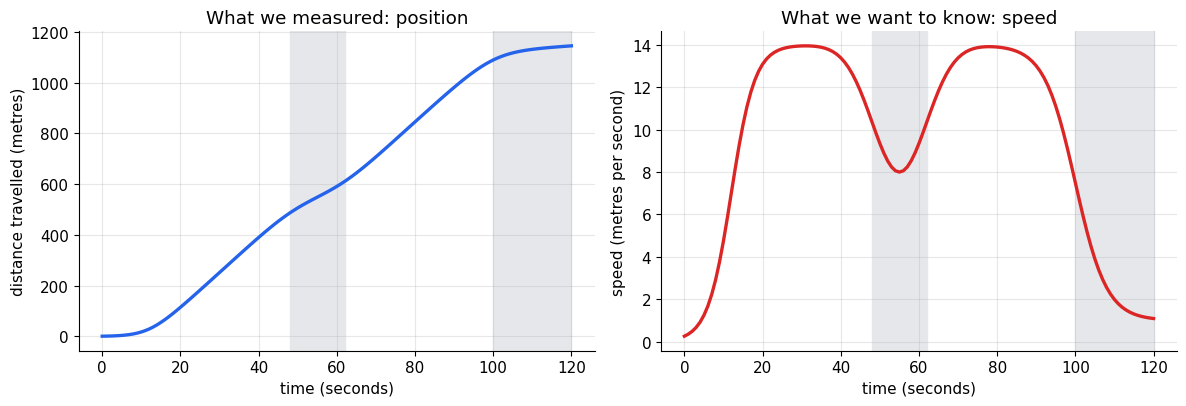

At t = 55 s the car is 548.6 m from the start.
Between t = 54 s and t = 56 s it covers 16.06 m in 2.0 s,
  which is an AVERAGE speed of 8.030 m/s.
The true speed at exactly t = 55 s is 8.000 m/s.

Close, but not equal. Shrinking that 2-second window is the whole
idea of Part 3.


In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))

ax1.plot(t_sec, pos_m, color=C_F, lw=2.4)
ax1.set_xlabel("time (seconds)")
ax1.set_ylabel("distance travelled (metres)")
ax1.set_title("What we measured: position")

ax2.plot(t_sec, v_true, color=C_SLOPE, lw=2.4)
ax2.set_xlabel("time (seconds)")
ax2.set_ylabel("speed (metres per second)")
ax2.set_title("What we want to know: speed")

for a in (ax1, ax2):
    a.axvspan(48, 62, color=C_SOFT, zorder=0)
    a.axvspan(100, 120, color=C_SOFT, zorder=0)
fig.tight_layout()
plt.show()

print(f"At t = 55 s the car is {pos_m[55]:,.1f} m from the start.")
print(f"Between t = 54 s and t = 56 s it covers "
      f"{pos_m[56] - pos_m[54]:.2f} m in 2.0 s,")
print(f"  which is an AVERAGE speed of {(pos_m[56] - pos_m[54]) / 2:.3f} m/s.")
print(f"The true speed at exactly t = 55 s is {v_true[55]:.3f} m/s.")
print()
print(f"Close, but not equal. Shrinking that 2-second window is the whole")
print(f"idea of Part 3.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: distance from the start, which only ever goes up — you cannot un-travel. Right: speed, which rises as the car pulls away, dips in the shaded band where it slows for the bend, recovers, then falls to zero in the second shaded band as it brakes.

The two panels are the same journey. Every steep stretch on the left is a high value on the right; every flat stretch on the left is a low value on the right. **The right-hand panel is the steepness of the left-hand one** — that sentence is the derivative, and by Part 3 you will be able to compute the right panel from the left yourself.

The printed numbers make the difficulty concrete: averaging over a 2-second window gets close to the true instantaneous speed, but not exactly. That gap is what a limit closes.

**The common misread:** thinking the left panel dipping means the car went backwards. It never does — during the bend it is still moving forward, just less quickly, so the line rises more gently. Distance falling would mean reversing.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

**Derivative** = how fast something is changing, right now. Slope of the left panel. Gives you the right panel.

**Integral** = how much has accumulated in total. Area under the right panel. Gives you back the left panel.

That is the entire subject. Everything else is technique for computing those two things without having to draw a picture every time.

</div>

<div style="background-color: #f8d7da; border-left: 5px solid #dc3545; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🤖 Why ML cares

Swap the car for a neural network and the story is identical. Position becomes the **loss** — how wrong the model currently is. Time becomes the **weights** — the numbers you are allowed to change. The derivative tells you which way to nudge each weight to make the loss go down, and by how much. That is gradient descent, and it is Part 9.

Everything between here and there exists so that when you meet $\partial L / \partial w$ you read it as a sentence rather than a hieroglyph: *how much does the loss change when I wiggle this one weight?*

</div>

### One honest warning about notation

Calculus has three or four notations for the same idea, invented by different
people who disliked each other. You will meet:

| Written | Said aloud | Means |
|---|---|---|
| $f'(x)$ | "f prime of x" | the derivative of $f$ |
| $\dfrac{dy}{dx}$ | "d y by d x" | the derivative of $y$ with respect to $x$ |
| $\dfrac{d}{dx}f(x)$ | "d by d x of f of x" | the same thing, as an instruction |
| $\dot{x}$ | "x dot" | derivative with respect to **time**, in physics |
| $\nabla f$ | "grad f" | all the partial derivatives at once (Part 8) |

They mean the same thing. We will mostly use $f'(x)$ when talking about a
function and $\dfrac{dy}{dx}$ when the variables matter, and we will say which
one we are using every time it changes.

---


---

# 1️⃣ Functions, graphs, and average rate of change

Part 0 said the derivative is the steepness of the position curve. Before we can
talk about steepness we need to be completely solid on two words: **function**
and **rate of change**. This part is the floor. No limits, no derivatives — just
two points, subtracted.

By the end of it you will have found the exact crack that calculus exists to fill.

## What a function actually is

A **function** is a rule that takes **one number in** and gives **exactly one
number out**. That is the whole definition. The word "exactly" is doing all the
work: the rule is not allowed to be indecisive.

Think of it as a machine:

```
        x  ───►  ┌─────────┐  ───►  f(x)
    (input)      │    f    │      (output)
                 └─────────┘
```

Two pieces of vocabulary, both of which mean something obvious:

- The **domain** is the set of inputs the machine is allowed to accept. Feeding
  it anything else breaks it. Dividing by zero, the square root of a negative,
  and the log of zero are the three you will meet constantly.
- The **range** is the set of outputs it can actually produce.

And one test you can do with your eyes. Draw the rule as a picture, with inputs
along the horizontal axis and outputs up the vertical axis. Now sweep a vertical
line across it. If that line ever crosses the picture **twice at once**, the rule
gave two different answers for one input, so it is not a function. That is the
**vertical-line test**.

## How to read $f(x)$

The symbol $f(x)$ is read out loud as **"f of x"**. It means *the output of the
machine called $f$ when you feed it the input $x$*. Say it aloud once or twice —
"f of x", "f of two", "f of a plus h" — because the way you say it is the way you
should read it.

| Written | Said aloud | Means |
|---|---|---|
| $f$ | "f" | the rule itself, the machine |
| $f(x)$ | "f of x" | the output when the input is $x$ |
| $f(2)$ | "f of two" | the output when the input is the number 2 |
| $f(a + h)$ | "f of a plus h" | the output when the input is the number $a + h$ |

The letter $f$ is just a name. $g$, $h$, $L$ (for *loss*), $\sigma$ (for the
sigmoid) are all used in exactly the same way. In Part 4 you will meet
$f(g(x))$ — "f of g of x" — and it will mean precisely what it says: run $x$
through $g$, then run the result through $f$.


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**$f(x)$ is not $f$ multiplied by $x$.** This is the single most common beginner error in the whole subject, and it is not a stupid one — every other time you have seen two things written side by side, like $3x$ or $ab$, it *did* mean multiply. Here it does not. The brackets say *'evaluate the rule $f$ at the input $x$'*.

The tell-tale symptom: someone writes $f(a+b) = f(a) + f(b)$, or 'cancels' the $f$ from both sides of $f(x) = f(y)$. Both are the multiplication misreading. With $f(x) = x^2$: $f(1+2) = 9$, but $f(1) + f(2) = 1 + 4 = 5$. Not the same — and the cell below prints both rather than asking you to believe it.

In Python the notation is identical and so is the meaning: `f(3)` *calls* the function `f` on the input `3`. Python would object if you meant multiplication, which is a small mercy that algebra on paper does not give you.

</div>

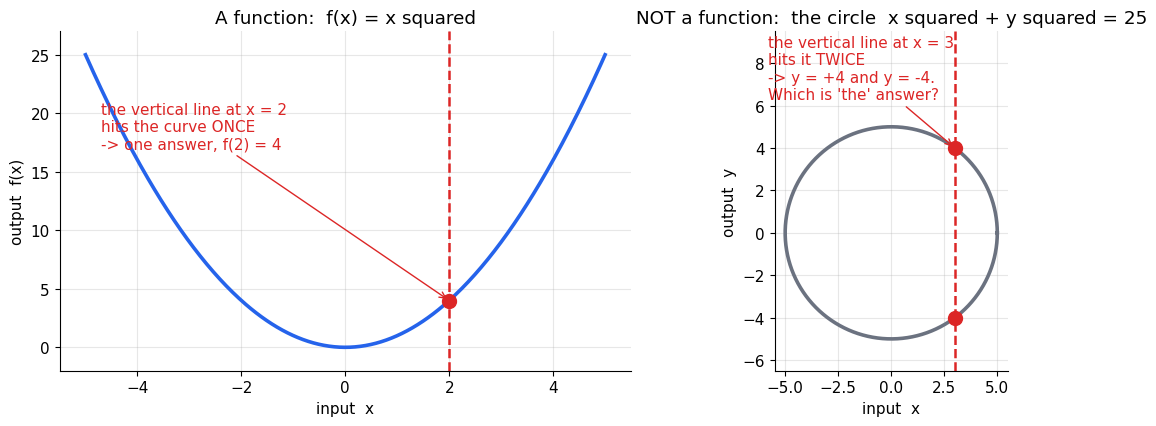

Circle of radius 5, asked for the output when the input is x = 3:
   upper half: y = +4.0
   lower half: y = -4.0
Two answers for one input -> not a function.

f(x) = x^2
   f(2)   = 4
   f(-2)  = 4    <- different input, SAME output. Perfectly allowed.
   f(0.5) = 0.25

Is f(a + b) the same as f(a) + f(b)?  Take a = 1, b = 2:
   f(1 + 2)    = f(3)  = 9
   f(1) + f(2) = 1 + 4 = 5
   equal? False   <- so f(x) is NOT 'f times x'.

Domain -- inputs that break the machine:
   1/x       at x =   0.0 -> refused (ZeroDivisionError)
   sqrt(x)   at x =  -4.0 -> refused (FloatingPointError)
   ln(x)     at x =   0.0 -> refused (FloatingPointError)

Range of f(x) = x^2 over the inputs -6..6: 0.00 to 36.00
   -- never below 0, because no real number squares to a negative.


In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.4))

# --- LEFT: a genuine function. One input, one output, every time. ----------
xs = np.linspace(-5, 5, 400)
ax1.plot(xs, xs ** 2, color=C_F, lw=2.6)
ax1.axvline(2.0, color=C_SLOPE, ls="--", lw=1.8)
ax1.plot([2.0], [4.0], "o", color=C_SLOPE, ms=10, zorder=5)
ax1.annotate("the vertical line at x = 2\nhits the curve ONCE\n-> one answer, f(2) = 4",
             xy=(2.0, 4.0), xytext=(-4.7, 17),
             arrowprops=dict(arrowstyle="->", color=C_SLOPE), color=C_SLOPE)
ax1.set_title("A function:  f(x) = x squared")
ax1.set_xlabel("input  x")
ax1.set_ylabel("output  f(x)")
ax1.set_ylim(-2, 27)

# --- RIGHT: NOT a function. A circle: one input, two outputs. --------------
theta = np.linspace(0, 2 * np.pi, 400)
ax2.plot(5 * np.cos(theta), 5 * np.sin(theta), color=C_GREY, lw=2.6)
ax2.axvline(3.0, color=C_SLOPE, ls="--", lw=1.8)
ax2.plot([3.0, 3.0], [4.0, -4.0], "o", color=C_SLOPE, ms=10, zorder=5)
ax2.annotate("the vertical line at x = 3\nhits it TWICE\n-> y = +4 and y = -4.\nWhich is 'the' answer?",
             xy=(3.0, 4.0), xytext=(-5.8, 6.3),
             arrowprops=dict(arrowstyle="->", color=C_SLOPE), color=C_SLOPE)
ax2.set_title("NOT a function:  the circle  x squared + y squared = 25")
ax2.set_xlabel("input  x")
ax2.set_ylabel("output  y")
ax2.set_ylim(-6.5, 9.5)
ax2.set_aspect("equal", adjustable="box")

fig.tight_layout()
plt.show()

# ---- the failure, in numbers rather than in a picture ----
print("Circle of radius 5, asked for the output when the input is x = 3:")
for sign, lab in [(+1, "upper half"), (-1, "lower half")]:
    print(f"   {lab}: y = {sign * np.sqrt(25 - 3.0 ** 2):+.1f}")
print("Two answers for one input -> not a function.\n")

def f(x):
    """Our first named function. Squares its input."""
    return x ** 2

print("f(x) = x^2")
print(f"   f(2)   = {f(2)}")
print(f"   f(-2)  = {f(-2)}    <- different input, SAME output. Perfectly allowed.")
print(f"   f(0.5) = {f(0.5)}\n")

print("Is f(a + b) the same as f(a) + f(b)?  Take a = 1, b = 2:")
print(f"   f(1 + 2)    = f(3)  = {f(1 + 2)}")
print(f"   f(1) + f(2) = 1 + 4 = {f(1) + f(2)}")
print(f"   equal? {f(1 + 2) == f(1) + f(2)}   <- so f(x) is NOT 'f times x'.\n")

# ---- domain: which inputs is the machine allowed to accept? ----
print("Domain -- inputs that break the machine:")
for name, rule, bad in [("1/x",     lambda z: 1 / z,       0.0),
                        ("sqrt(x)", lambda z: np.sqrt(z), -4.0),
                        ("ln(x)",   lambda z: np.log(z),   0.0)]:
    try:
        with np.errstate(all="raise"):
            out = rule(bad)
        print(f"   {name:9s} at x = {bad:>5.1f} -> {out}")
    except Exception as e:
        print(f"   {name:9s} at x = {bad:>5.1f} -> refused ({type(e).__name__})")

# ---- range: which outputs can actually come out? ----
grid = np.linspace(-6, 6, 2001)
print(f"\nRange of f(x) = x^2 over the inputs -6..6: "
      f"{f(grid).min():.2f} to {f(grid).max():.2f}")
print("   -- never below 0, because no real number squares to a negative.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: the parabola. Slide a vertical line anywhere across it and the line touches the curve in exactly one place, so every input has exactly one output. It is a function.

Right: a circle. The vertical line at $x = 3$ crosses it at $y = +4$ **and** $y = -4$, so the rule 'give me the $y$ on the circle at $x = 3$' has two answers and no way to choose. It is a perfectly good *relation* and a perfectly good *shape* — it simply is not a function.

The printed block turns the picture into arithmetic: both circle answers, the $f(1+2) \neq f(1) + f(2)$ demonstration that kills the multiplication misreading, three inputs that the domain refuses, and the range of $x^2$ measured rather than asserted.

Why any of this matters: calculus asks *'how fast is the output changing?'*, and that question is meaningless if the output cannot make up its mind. Every loss, every activation, every model output in machine learning is a function for exactly this reason.

**The common misread:** thinking the vertical-line test rules out curves that repeat *outputs*. It does not. The parabola returns 4 for both $x = 2$ and $x = -2$, and that is completely fine — many inputs may share one output. The rule is one-output-per-input, never one-input-per-output.

</div>

## The seven shapes you will meet over and over

You do not need a zoo of functions to do machine learning. You need about seven,
and you need to recognise them on sight — the way you recognise a friend's
handwriting.

| Function | Written | What it looks like | Where it shows up in ML |
|---|---|---|---|
| linear | $f(x) = mx + c$ | a straight line | every layer is $Wx + b$ before anything else happens |
| quadratic | $f(x) = x^2$ | a U with one bottom | squared-error loss, $(\text{pred} - \text{truth})^2$ |
| cubic | $f(x) = x^3 - 3x$ | an S with a bump and a dip | loss surfaces with more than one dip |
| exponential | $f(x) = e^{x}$ | flat, then explodes | inside sigmoid and softmax; learning-rate decay |
| logarithm | $f(x) = \ln x$ | shoots up, then crawls | cross-entropy loss is $-\ln(\text{predicted probability})$ |
| reciprocal | $f(x) = 1/x$ | two branches, blows up at 0 | normalising: softmax divides by a sum |
| sigmoid | $f(x) = \dfrac{1}{1 + e^{-x}}$ | a squashed S from 0 to 1 | turns any number into a probability |

Two symbols named before we use them. The number $e \approx 2.718$ is a specific
constant, like $\pi$; for now take it as "the number that makes exponentials
behave nicely", and in Part 4 you will see *why* it is the natural choice in a
one-line reason. And $\ln x$ — said "lon x", or "natural log of x" — is the
question **"e to what power gives me x?"**

Two of these deserve a note in advance. The quadratic's single bottom is exactly
*why* gradient descent works so well on squared error: there is one lowest point
and from anywhere you can tell which way is down. And the logarithm's steep left
end is what makes a confident wrong answer so expensive under cross-entropy.


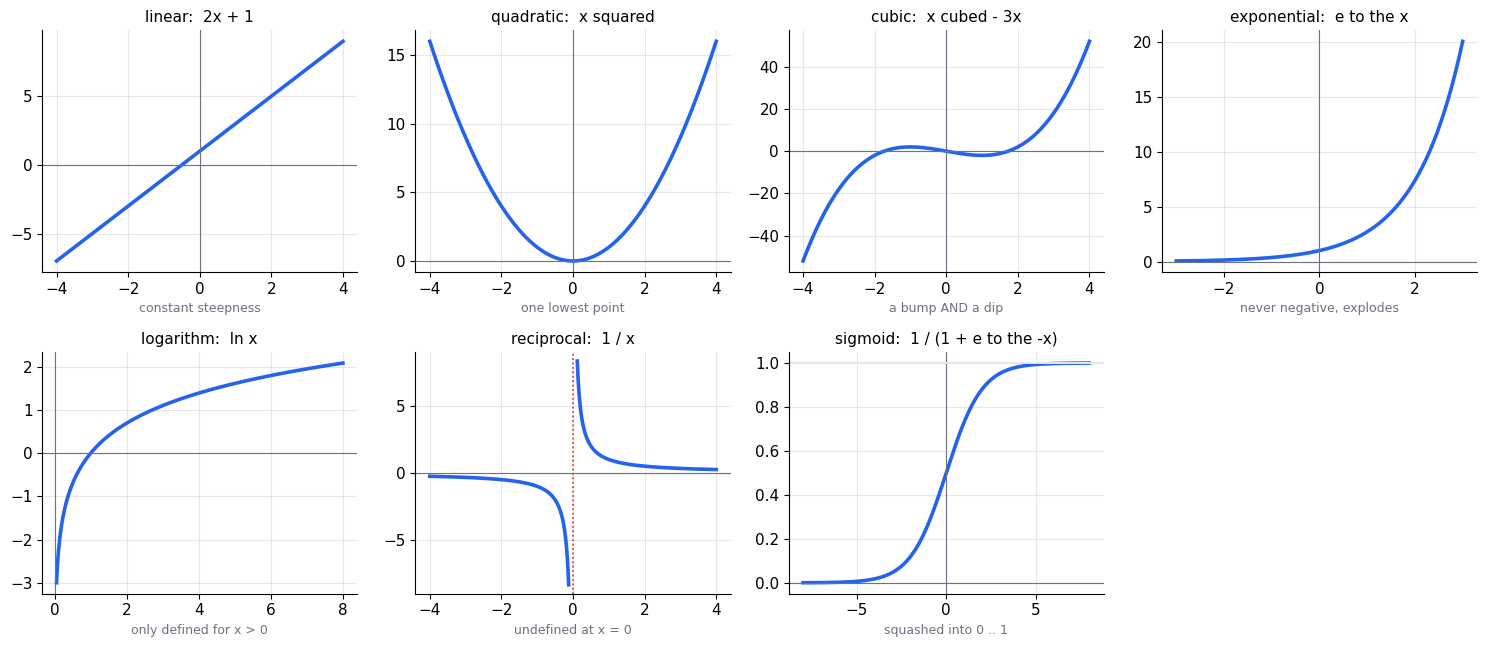

e          = 2.718282
ln(e)      = 1.000000   <- 'e to what power gives e?'  Answer: 1.
exp(ln(7)) = 7.000000   <- ln and exp undo each other.

The sigmoid squashes EVERYTHING into the interval 0 to 1:
   sigmoid( -100) = 0.00000000
   sigmoid(   -3) = 0.04742587
   sigmoid(    0) = 0.50000000
   sigmoid(    3) = 0.95257413
   sigmoid(  100) = 1.00000000

over the inputs -8..8 it ranges 0.00034 .. 0.99966
-- it approaches 0 and 1 but never actually reaches either.


In [5]:
fig, axes = plt.subplots(2, 4, figsize=(15, 6.6))

def panel(ax, xs, ys, title, note):
    ax.plot(xs, ys, color=C_F, lw=2.6)
    ax.axhline(0, color=C_GREY, lw=0.8)
    ax.axvline(0, color=C_GREY, lw=0.8)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(note, fontsize=9, color=C_GREY)

xs = np.linspace(-4, 4, 400)
panel(axes[0, 0], xs, 2 * xs + 1,       "linear:  2x + 1",        "constant steepness")
panel(axes[0, 1], xs, xs ** 2,          "quadratic:  x squared",  "one lowest point")
panel(axes[0, 2], xs, xs ** 3 - 3 * xs, "cubic:  x cubed - 3x",   "a bump AND a dip")

xe = np.linspace(-3, 3, 400)
panel(axes[0, 3], xe, np.exp(xe),       "exponential:  e to the x", "never negative, explodes")

xl = np.linspace(0.05, 8, 400)
panel(axes[1, 0], xl, np.log(xl),       "logarithm:  ln x",       "only defined for x > 0")

# 1/x must be drawn as two separate branches. It is undefined AT zero, so
# joining the halves would draw a vertical wall that is not part of the graph.
axes[1, 1].plot(np.linspace(-4, -0.12, 300), 1 / np.linspace(-4, -0.12, 300),
                color=C_F, lw=2.6)
axes[1, 1].plot(np.linspace(0.12, 4, 300), 1 / np.linspace(0.12, 4, 300),
                color=C_F, lw=2.6)
axes[1, 1].axhline(0, color=C_GREY, lw=0.8)
axes[1, 1].axvline(0, color=C_SLOPE, lw=1.2, ls=":")
axes[1, 1].set_ylim(-9, 9)
axes[1, 1].set_title("reciprocal:  1 / x", fontsize=11)
axes[1, 1].set_xlabel("undefined at x = 0", fontsize=9, color=C_GREY)

xs2 = np.linspace(-8, 8, 400)
sig  = 1 / (1 + np.exp(-xs2))
panel(axes[1, 2], xs2, sig, "sigmoid:  1 / (1 + e to the -x)", "squashed into 0 .. 1")
axes[1, 2].axhline(1, color=C_SOFT, lw=1.4)

axes[1, 3].axis("off")
fig.tight_layout()
plt.show()

# The claims in the table above, checked with numbers rather than trusted.
print(f"e          = {np.e:.6f}")
print(f"ln(e)      = {np.log(np.e):.6f}   <- 'e to what power gives e?'  Answer: 1.")
print(f"exp(ln(7)) = {np.exp(np.log(7)):.6f}   <- ln and exp undo each other.\n")

sg = lambda z: 1 / (1 + np.exp(-z))
print("The sigmoid squashes EVERYTHING into the interval 0 to 1:")
for z in (-100, -3, 0, 3, 100):
    print(f"   sigmoid({z:>5}) = {sg(float(z)):.8f}")
print(f"\nover the inputs -8..8 it ranges {sig.min():.5f} .. {sig.max():.5f}")
print("-- it approaches 0 and 1 but never actually reaches either.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Eight panels, seven shapes. Top row: a straight line (the same steepness everywhere), a parabola (one lowest point), a cubic (a bump *and* a dip), and an exponential (barely moves, then runs away). Bottom row: the logarithm, which only exists to the right of zero and flattens as it goes; the reciprocal, drawn as **two separate branches** because it has no value at $x = 0$; and the sigmoid, pinned between the guide lines at 0 and 1.

The printed numbers settle two claims the picture can only suggest: that $\ln$ and $e^x$ undo one another, and that the sigmoid genuinely never escapes 0 to 1 — not even at an input of minus one hundred.

**The common misread:** joining the two halves of $1/x$ through the middle and treating the vertical dotted line as part of the graph. It is not — at $x = 0$ the function has no value at all. Plotting libraries will happily draw that phantom wall if you hand them one array that straddles zero, and it is among the most common ugly-plot bugs there is.

</div>

## Slope: building "rise over run" instead of quoting it

Now the idea everything else is made of. Take a straight line and two points on
it. Call them $(a,\, f(a))$ and $(b,\, f(b))$ — meaning "at input $a$ the output
was $f(a)$", and likewise for $b$.

Ask: **how much output do I get per unit of input?** That is a division, and to
do a division you need the two things being divided:

- how far the output went — the **rise** — is the second output minus the first:
  $f(b) - f(a)$;
- how far the input went — the **run** — is the second input minus the first:
  $b - a$.

Output gained per input spent, and "per" means divide:

$$\text{slope} \;=\; \frac{\text{rise}}{\text{run}} \;=\; \frac{f(b) - f(a)}{b - a}$$

Nothing was assumed there. We wanted a rate, so we divided the change in one by
the change in the other.

Two sanity notes before we use it. First, it does not matter which point you
call first: swapping $a$ and $b$ flips the sign of the top *and* the sign of the
bottom, and two flips cancel. Second, the run must not be zero — if $b = a$ you
are dividing by nothing, which is exactly the trouble Part 0 warned about.

**The special thing about a straight line** is that this number comes out the
same wherever you measure it. Let us not assume that either. Let us measure it
three times.


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

$\dfrac{f(b) - f(a)}{b - a}$ says: *take how much the output changed, and divide it by how much the input changed*. Nothing more.

In everyday language: if the input is time in seconds and the output is metres travelled, this is metres-per-second. If the input is a model weight and the output is the loss, it is loss-per-unit-of-weight. The formula does not care what the two quantities are — it just reports how much of one you get per unit of the other.

</div>

f(x) = 3x - 2, measured at three completely different pairs of points
------------------------------------------------------------------
       a        b         rise        run     rise/run
  -4.000   -1.000      9.00000      3.000     3.000000
   0.000    5.000     15.00000      5.000     3.000000
   7.000    7.001      0.00300      0.001     3.000000
------------------------------------------------------------------
three measurements: [3.0, 3.0, 3.0]
all identical to 9 decimal places? True

Order does not matter either:
   slope(a=0, b=5) = 3.000000
   slope(a=5, b=0) = 3.000000   <- same


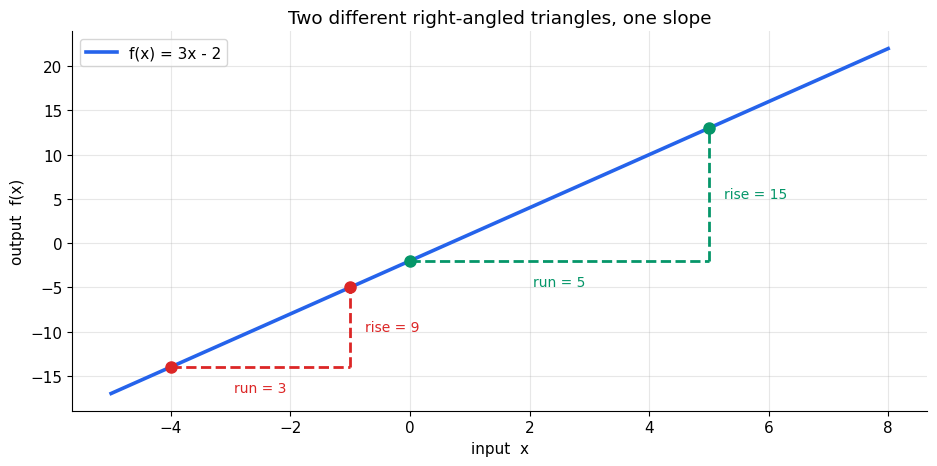

red triangle  : rise 9 / run 3 = 3.0000
green triangle: rise 15 / run 5 = 3.0000


In [6]:
def slope(f, a, b):
    """Rise over run between the points (a, f(a)) and (b, f(b))."""
    rise = f(b) - f(a)
    run  = b - a
    return rise / run

line  = lambda z: 3 * z - 2       # a straight line: f(x) = 3x - 2
pairs = [(-4.0, -1.0), (0.0, 5.0), (7.0, 7.001)]

print("f(x) = 3x - 2, measured at three completely different pairs of points")
print("-" * 66)
print(f"{'a':>8} {'b':>8} {'rise':>12} {'run':>10} {'rise/run':>12}")
for a, b in pairs:
    print(f"{a:>8.3f} {b:>8.3f} {line(b) - line(a):>12.5f} "
          f"{b - a:>10.3f} {slope(line, a, b):>12.6f}")
print("-" * 66)

vals = [slope(line, a, b) for a, b in pairs]
print(f"three measurements: {[round(v, 9) for v in vals]}")
print(f"all identical to 9 decimal places? {np.allclose(vals, vals[0], atol=1e-9)}")
print(f"\nOrder does not matter either:")
print(f"   slope(a=0, b=5) = {slope(line, 0.0, 5.0):.6f}")
print(f"   slope(a=5, b=0) = {slope(line, 5.0, 0.0):.6f}   <- same")

fig, ax = plt.subplots(figsize=(9.5, 4.8))
xs = np.linspace(-5, 8, 200)
ax.plot(xs, line(xs), color=C_F, lw=2.6, label="f(x) = 3x - 2")

for (a, b), col in zip(pairs[:2], [C_SLOPE, C_AREA]):
    ax.plot([a, b], [line(a), line(a)], color=col, lw=2, ls="--")   # the run
    ax.plot([b, b], [line(a), line(b)], color=col, lw=2, ls="--")   # the rise
    ax.plot([a, b], [line(a), line(b)], "o", color=col, ms=8, zorder=5)
    ax.text((a + b) / 2, line(a) - 2.8, f"run = {b - a:.0f}",
            color=col, ha="center", fontsize=10)
    ax.text(b + 0.25, (line(a) + line(b)) / 2, f"rise = {line(b) - line(a):.0f}",
            color=col, va="center", fontsize=10)

ax.set_xlabel("input  x")
ax.set_ylabel("output  f(x)")
ax.set_title("Two different right-angled triangles, one slope")
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()

print(f"red triangle  : rise {line(-1.) - line(-4.):.0f} / run 3 = "
      f"{(line(-1.) - line(-4.)) / 3.0:.4f}")
print(f"green triangle: rise {line(5.) - line(0.):.0f} / run 5 = "
      f"{(line(5.) - line(0.)) / 5.0:.4f}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Two right-angled triangles hung off the same straight line, one much larger than the other. The red one has a run of 3 and a rise of 9; the green one has a run of 5 and a rise of 15. Different triangles — and 9/3 = 15/5 = 3 all the same.

That is the geometric meaning of the 3 in $f(x) = 3x - 2$: for every 1 you move right, the line climbs 3. The $-2$ slides the whole line downwards and does not affect the steepness at all, which is why it cancels out of the rise.

Look at the third row of the printed table. Those two points are only 0.001 apart — very nearly the 'zero over zero' problem from Part 0 — and for a *straight* line it causes no difficulty whatsoever: the answer is still exactly 3, to nine decimal places. Hold on to that. The trouble waiting in Part 2 is not caused by small runs. It is caused by small runs **on a curve**.

**The common misread:** believing a *bigger* triangle means a *steeper* line. Size has nothing to do with it — only the ratio of the two sides does. A tiny triangle and an enormous one on the same line give the same answer, and that is precisely what makes 'the slope of a line' a well-defined single number.

</div>

## Average rate of change — the same formula, on a curve

Now use the identical formula on something that bends:

$$\text{average rate of change of } f \text{ from } a \text{ to } b
\;=\; \frac{f(b) - f(a)}{b - a}$$

Same symbols, same division, same meaning: total output change divided by total
input change. When the input is time and the output is distance, this is
literally **average speed** — total distance over total time, the thing you work
out on a long drive.

And here is where the ground shifts under you. On a straight line this number was
the same wherever you measured it. **On a curve it is not.** Pick different pairs
of points and you get different answers — all of them correct, all of them about
different stretches of the journey.

Let us do it on Part 0's drive: over the whole two minutes, over the ten seconds
around the bend, and over just two seconds in the middle of the bend.

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🔎 A name for the dashed lines you are about to draw

A straight line drawn through **two** points of a curve is called a **secant
line** — from the Latin for *cutting*, because it cuts across. And

$$\text{slope of the secant through } (a, f(a)) \text{ and } (b, f(b))
\;=\; \frac{f(b) - f(a)}{b - a} \;=\; \text{average rate of change from } a \text{ to } b$$

These are not two facts. They are the same arithmetic written twice: *average
rate of change* is the algebraic name for it, *slope of the secant* is the
geometric one. Whenever you see one, you may say the other.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

For the car, $\dfrac{f(b) - f(a)}{b - a}$ reads: **the distance covered over the stretch, divided by the time that stretch took**.

That is average speed, and it is the only kind of speed you can compute with arithmetic alone — you need *two* moments in order to have a distance and a duration to divide.

Nothing here is instantaneous. Nothing here needs a limit. This is still just subtraction and division.

</div>

Average speed over three windows of the SAME journey
 from (s)   to (s)    distance (m)   time (s)    avg speed
        0      120       1145.6015        120       9.5467
       50       60         84.8110         10       8.4811
       54       56         16.0606          2       8.0303
three answers: [9.5467, 8.4811, 8.0303]  m/s
all the same?  False
the largest exceeds the smallest by 1.5164 m/s (18.9% of the smallest)

Every one of these is a correct average speed. They are averages over
different stretches -- and NONE of them is the speedometer reading.


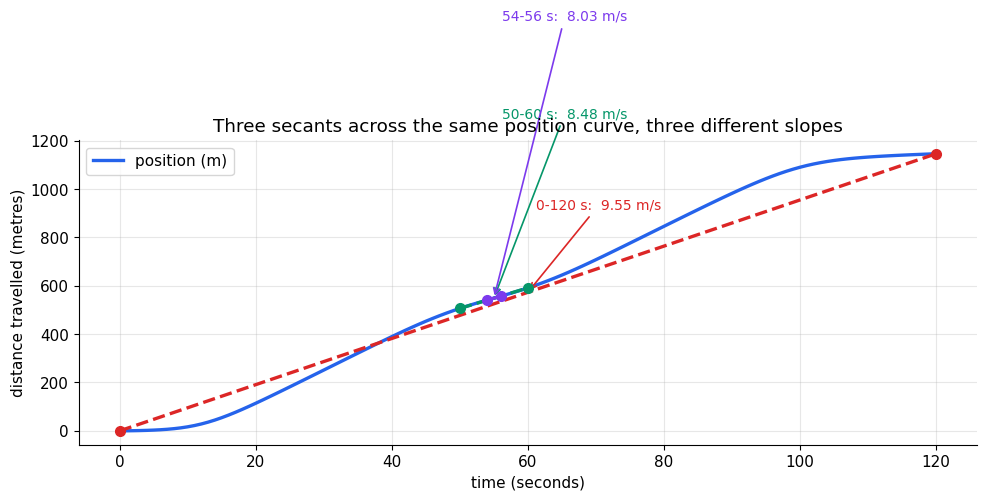

In [7]:
def avg_rate(a, b):
    """Average speed of the car between times a and b, in metres per second.

    pos_m[i] is the distance travelled by time i seconds, so this is exactly
    (f(b) - f(a)) / (b - a) with f = position.
    """
    a, b = int(a), int(b)
    return (pos_m[b] - pos_m[a]) / (b - a)

windows = [(0, 120), (50, 60), (54, 56)]

print("Average speed over three windows of the SAME journey")
print("=" * 64)
print(f"{'from (s)':>9} {'to (s)':>8} {'distance (m)':>15} {'time (s)':>10} {'avg speed':>12}")
for a, b in windows:
    print(f"{a:>9} {b:>8} {pos_m[b] - pos_m[a]:>15.4f} "
          f"{b - a:>10} {avg_rate(a, b):>12.4f}")
print("=" * 64)

answers = [avg_rate(a, b) for a, b in windows]
print(f"three answers: {[round(float(v), 4) for v in answers]}  m/s")
print(f"all the same?  {np.allclose(answers, answers[0])}")
print(f"the largest exceeds the smallest by {max(answers) - min(answers):.4f} m/s "
      f"({100 * (max(answers) - min(answers)) / min(answers):.1f}% of the smallest)")
print()
print("Every one of these is a correct average speed. They are averages over")
print("different stretches -- and NONE of them is the speedometer reading.")

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(t_sec, pos_m, color=C_F, lw=2.4, label="position (m)")

for (a, b), col, off in zip(windows, [C_SLOPE, C_AREA, C_EXACT], [60, 130, 200]):
    ax.plot([a, b], [pos_m[a], pos_m[b]], color=col, lw=2.4, ls="--")
    ax.plot([a, b], [pos_m[a], pos_m[b]], "o", color=col, ms=7, zorder=5)
    ax.annotate(f"{a}-{b} s:  {avg_rate(a, b):.2f} m/s",
                xy=((a + b) / 2, (pos_m[a] + pos_m[b]) / 2),
                xytext=(6, off), textcoords="offset points",
                color=col, fontsize=10,
                arrowprops=dict(arrowstyle="->", color=col, lw=1.2))

ax.set_xlabel("time (seconds)")
ax.set_ylabel("distance travelled (metres)")
ax.set_title("Three secants across the same position curve, three different slopes")
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The position curve from Part 0 with three straight dashed segments — three secants — drawn across it. Each joins two points on the curve, and the **slope of each segment is the average speed over that window**: the annotation beside it is the number the cell printed.

The long secant spanning the whole journey is a single straight line from start to finish. It captures the overall average and knows nothing about the bend. The two short ones sit inside the slow stretch and come out shallower.

That is the crack. For a straight line, one slope, measured anywhere. For a curve, **the answer depends on which two points you chose** — so the phrase 'the slope of this curve' does not yet mean anything at all.

**The common misread:** concluding that a curve therefore has no well-defined steepness. It plainly does — you can see it in the picture, and the car's speedometer reads one specific number at every instant. What we lack is a *formula*, because every formula we own needs two points and an instant offers only one. Parts 2 and 3 are the fix.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**The average rate over an interval is not the rate at its midpoint.** This one feels so reasonable that people use it without noticing, and it is wrong whenever the curve bends.

The next cell takes the window from 40 s to 70 s. The average speed across it is one number; the actual speedometer reading halfway through, at 55 s, is quite another — because the car dips into the bend and climbs back out again *inside* that window, and averaging flattens the dip away.

It also shows a window where the two nearly agree, so you can see what makes the difference: over a short enough stretch the curve barely bends, so the average has little left to hide. But note what that does **not** say. The narrow window's answer is not 'right' — it is still an average, still not the speedometer, merely closer. Nothing in Part 1 can give you the exact instantaneous value. That observation — *shrink the window and the average closes in on something* — is the seed of Parts 2 and 3.

</div>

In [8]:
print(f"{'window':>14} {'average over it':>17} {'speedometer at midpoint':>26} {'gap':>10}")
print("-" * 71)
for a, b in [(40, 70), (0, 120), (50, 60), (54, 56)]:
    mid = (a + b) // 2
    print(f"{a:>5}-{b:<5}s {avg_rate(a, b):>15.4f}   {v_true[mid]:>22.4f}   "
          f"{avg_rate(a, b) - v_true[mid]:>+9.4f}")
print("-" * 71)

a, b = 40, 70
mid = (a + b) // 2
print(f"\nWorst case above: over {a}-{b} s the average is {avg_rate(a, b):.4f} m/s,")
print(f"but at t = {mid} s the car is actually doing {v_true[mid]:.4f} m/s.")
print(f"Off by {avg_rate(a, b) - v_true[mid]:.4f} m/s -- about "
      f"{100 * abs(avg_rate(a, b) - v_true[mid]) / v_true[mid]:.0f}% wrong.")
print("\nBest case: the 2-second window 54-56 s, where the gap nearly vanishes.")
print("Narrower window -> less room for the curve to bend -> closer agreement.")


        window   average over it    speedometer at midpoint        gap
-----------------------------------------------------------------------
   40-70   s         10.6034                   7.9998     +2.6036
    0-120  s          9.5467                   9.3504     +0.1963
   50-60   s          8.4811                   7.9998     +0.4813
   54-56   s          8.0303                   7.9998     +0.0305
-----------------------------------------------------------------------

Worst case above: over 40-70 s the average is 10.6034 m/s,
but at t = 55 s the car is actually doing 7.9998 m/s.
Off by 2.6036 m/s -- about 33% wrong.

Best case: the 2-second window 54-56 s, where the gap nearly vanishes.
Narrower window -> less room for the curve to bend -> closer agreement.


<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

We did not argue about whether 'the average over an interval equals the rate at its midpoint'. We tested it on four windows and printed the gap in a column of its own. It fails badly on 40–70 s and very nearly holds on 54–56 s.

Equally, we did not take on faith that a straight line has a single slope — we measured it at three unrelated pairs of points, one of them 0.001 apart, and all three agreed to nine decimal places.

Two claims, both checkable, both checked. That is the pattern for the rest of the notebook.

</div>

## The picture that gives the game away

One experiment closes Part 1's main thread. Nail down the first point at
$t = 55$ s and walk the second point in towards it — 80 s, then 70, 65, 60, 57,
56. Each position gives a perfectly legitimate secant with a perfectly
legitimate slope, computed by the same subtraction and division as everything
above.

Watch what those slopes do as the gap shrinks. We will deliberately not name
what you are about to see; naming it is Part 2's job.


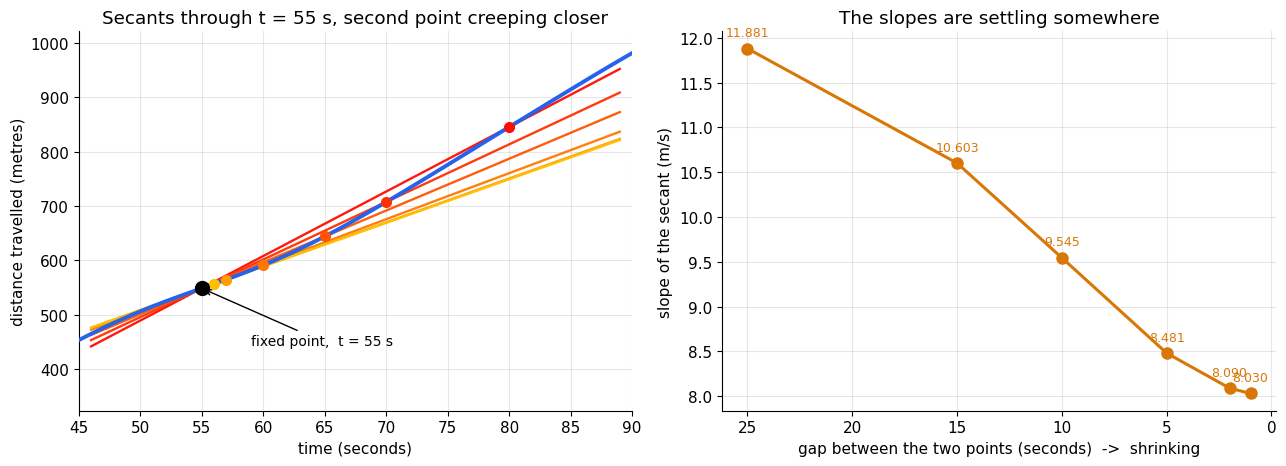

  second point   gap (s)    secant slope (m/s)
-----------------------------------------------
          80 s        25              11.88118
          70 s        15              10.60260
          65 s        10               9.54505
          60 s         5               8.48099
          57 s         2               8.09022
          56 s         1               8.03026
-----------------------------------------------
The slopes are not wandering. They are heading somewhere specific.
And the gap can never be set to 0: that would be a run of zero,
and pos_m[55] - pos_m[55] = 0.0 over 0. Nothing at all.


In [9]:
anchor = 55                        # the point we hold fixed
others = [80, 70, 65, 60, 57, 56]  # second points, creeping towards it

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8))

zoom = (t_sec >= 45) & (t_sec <= 90)
ax1.plot(t_sec[zoom], pos_m[zoom], color=C_F, lw=2.8, zorder=3)
ax1.plot([anchor], [pos_m[anchor]], "o", color="black", ms=10, zorder=6)
ax1.annotate("fixed point,  t = 55 s", xy=(anchor, pos_m[anchor]),
             xytext=(59, pos_m[anchor] - 105), fontsize=10,
             arrowprops=dict(arrowstyle="->", color="black"))

shades, rows = plt.cm.autumn(np.linspace(0.05, 0.75, len(others))), []
for b, col in zip(others, shades):
    s = (pos_m[b] - pos_m[anchor]) / (b - anchor)
    # draw each secant as a full line across the window rather than just the
    # chord, so what you notice is the change in TILT, not the change in length
    tt = np.linspace(46, 89, 2)
    ax1.plot(tt, pos_m[anchor] + s * (tt - anchor), color=col, lw=1.7, alpha=0.95)
    ax1.plot([b], [pos_m[b]], "o", color=col, ms=7, zorder=5)
    rows.append((b, b - anchor, s))

ax1.set_xlim(45, 90)
ax1.set_ylim(pos_m[45] - 130, pos_m[90] + 40)
ax1.set_xlabel("time (seconds)")
ax1.set_ylabel("distance travelled (metres)")
ax1.set_title("Secants through t = 55 s, second point creeping closer")

gaps, slopes = [r[1] for r in rows], [r[2] for r in rows]
ax2.plot(gaps, slopes, "o-", color=C_APPROX, lw=2.2, ms=8)
ax2.invert_xaxis()
ax2.set_xlabel("gap between the two points (seconds)  ->  shrinking")
ax2.set_ylabel("slope of the secant (m/s)")
ax2.set_title("The slopes are settling somewhere")
for g, s in zip(gaps, slopes):
    ax2.annotate(f"{s:.3f}", xy=(g, s), xytext=(0, 9), textcoords="offset points",
                 ha="center", fontsize=9, color=C_APPROX)

fig.tight_layout()
plt.show()

print(f"{'second point':>14} {'gap (s)':>9} {'secant slope (m/s)':>21}")
print("-" * 47)
for b, gap, s in rows:
    print(f"{b:>12} s {gap:>9} {s:>21.5f}")
print("-" * 47)
print("The slopes are not wandering. They are heading somewhere specific.")
print(f"And the gap can never be set to 0: that would be a run of zero,")
print(f"and pos_m[55] - pos_m[55] = {pos_m[55] - pos_m[55]:.1f} over 0. Nothing at all.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: the position curve zoomed into the stretch around the bend, with one point pinned at $t = 55$ s in black and a fan of secants drawn through it, each also passing through one of the coloured points further along. As those points slide back towards the black one, the lines pivot around it and their tilt changes by less and less.

Right: the same information as a graph — secant slope against how far apart the two points are, with the gap shrinking towards the right-hand edge. The dots are not scattering. They are converging.

The printed table is the honest version of that picture: six legitimate average speeds over six shorter and shorter windows, closing in on a value we are not yet allowed to name.

**The common misread:** expecting the process to *finish*, with the two points landing on top of one another. It cannot — at zero gap the formula becomes 0 divided by 0 and computes nothing, as the last printed line shows. The entire trick, and the entire content of Part 2, is asking where the slopes are **heading** without ever setting the gap to zero.

</div>

## One last thing before limits: functions inside functions

Two small pieces of machinery, introduced now so they are already familiar when
the chain rule needs them in Part 4.

**Composition.** Feed the output of one machine straight into another. If
$g(x) = 3x + 1$ and $f(u) = u^2$, then $f(g(x))$ — said "f of g of x" — means:
work out $g(x)$ first, then square whatever came out.

$$f(g(x)) = (3x + 1)^2$$

Read it from the inside out, exactly as you read nested brackets in code:
`f(g(x))` in Python does the same thing in the same order.

**Transformation.** Four small edits that move a shape around without changing
what kind of shape it is. For any function $f$:

| Written | Does what | Which direction |
|---|---|---|
| $f(x) + k$ | adds $k$ to the **output** | moves the graph **up** by $k$ |
| $f(x - k)$ | subtracts $k$ from the **input** | moves the graph **right** by $k$ |
| $c \cdot f(x)$ | multiplies the **output** | stretches it **vertically** |
| $f(c \cdot x)$ | multiplies the **input** | squashes it **horizontally** |

The second row is the one that catches everyone, so the cell below checks it
rather than asserting it.


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

$f(g(x))$ means **do $g$ first, then do $f$ to the answer**. The bracket nesting tells you the order, and it runs inside-out.

$f(x - k)$ means **the new function at input $x$ gives whatever the old one gave at input $x - k$** — that is, it repeats the old graph's behaviour $k$ later, which is why the picture slides to the right even though the sign is a minus.

</div>

Composition, traced one step at a time.  f(u) = u^2,  g(x) = 3x + 1
--------------------------------------------------------------
     x    g(x) = 3x+1    then squared     (3x+1)^2
  -1.0           -2.0             4.0          4.0
   0.0            1.0             1.0          1.0
   2.0            7.0            49.0         49.0
   3.0           10.0           100.0        100.0
--------------------------------------------------------------
does f(g(x)) equal (3x+1)^2 everywhere on -3..3?  True

f(g(2)) = 49.0   (7, then squared)
g(f(2)) = 13.0   (4, then tripled and plus one)
Order matters: stacking the machines the other way is a different rule.


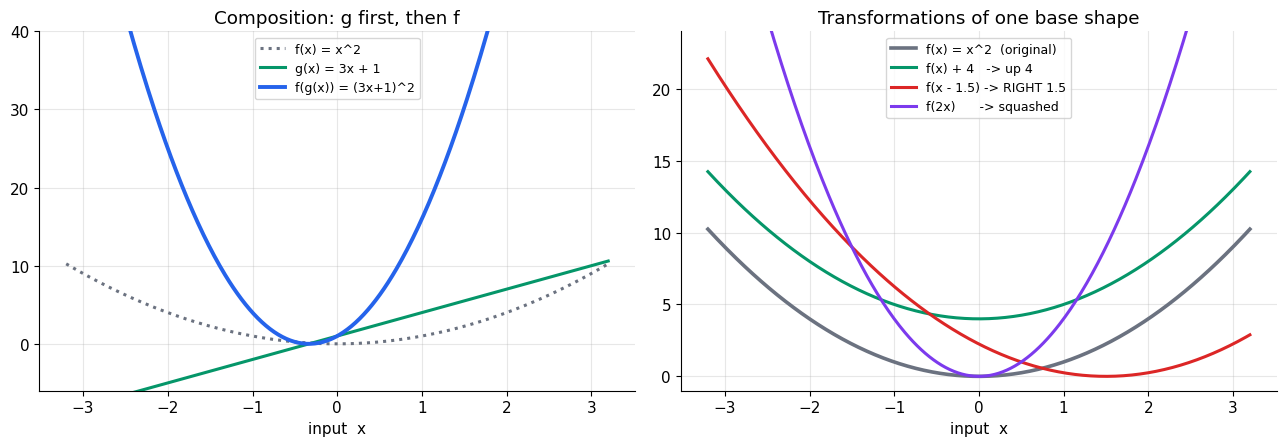


Checking the row everyone gets backwards -- MINUS inside moves it RIGHT:
   x^2 has its lowest point at x = 0, where it is 0.00
   f(x - 1.5) at x = 1.5 gives 0.00 <- the bottom has moved to x = +1.5
   f(x - 1.5) at x = 0.0 gives 2.25 <- x = 0 is no longer the bottom
Why: to bottom out, the bracket must contain 0, so x must reach 1.5.
Subtracting inside makes x work harder to get there, dragging the
whole shape to the right.


In [10]:
g    = lambda z: 3 * z + 1      # inner machine
f_o  = lambda u: u ** 2         # outer machine
comp = lambda z: f_o(g(z))      # "f of g of x"

print("Composition, traced one step at a time.  f(u) = u^2,  g(x) = 3x + 1")
print("-" * 62)
print(f"{'x':>6} {'g(x) = 3x+1':>14} {'then squared':>15} {'(3x+1)^2':>12}")
for xv in [-1.0, 0.0, 2.0, 3.0]:
    inner = g(xv)
    print(f"{xv:>6.1f} {inner:>14.1f} {f_o(inner):>15.1f} {(3 * xv + 1) ** 2:>12.1f}")
print("-" * 62)

grid = np.linspace(-3, 3, 400)
print(f"does f(g(x)) equal (3x+1)^2 everywhere on -3..3?  "
      f"{np.allclose(comp(grid), (3 * grid + 1) ** 2)}")

other = lambda z: g(f_o(z))     # "g of f of x" = 3x^2 + 1 -- a DIFFERENT function
print(f"\nf(g(2)) = {comp(2.0):.1f}   (7, then squared)")
print(f"g(f(2)) = {other(2.0):.1f}   (4, then tripled and plus one)")
print("Order matters: stacking the machines the other way is a different rule.")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6))
xs = np.linspace(-3.2, 3.2, 400)

ax1.plot(xs, xs ** 2,  color=C_GREY, lw=2.2, ls=":", label="f(x) = x^2")
ax1.plot(xs, g(xs),    color=C_AREA, lw=2.2,         label="g(x) = 3x + 1")
ax1.plot(xs, comp(xs), color=C_F,    lw=2.8,         label="f(g(x)) = (3x+1)^2")
ax1.set_ylim(-6, 40)
ax1.set_xlabel("input  x")
ax1.set_title("Composition: g first, then f")
ax1.legend(loc="upper center", fontsize=9)

base = lambda z: z ** 2
ax2.plot(xs, base(xs),       color=C_GREY,  lw=2.6, label="f(x) = x^2  (original)")
ax2.plot(xs, base(xs) + 4,   color=C_AREA,  lw=2.2, label="f(x) + 4   -> up 4")
ax2.plot(xs, base(xs - 1.5), color=C_SLOPE, lw=2.2, label="f(x - 1.5) -> RIGHT 1.5")
ax2.plot(xs, base(2 * xs),   color=C_EXACT, lw=2.2, label="f(2x)      -> squashed")
ax2.set_ylim(-1, 24)
ax2.set_xlabel("input  x")
ax2.set_title("Transformations of one base shape")
ax2.legend(loc="upper center", fontsize=9)

fig.tight_layout()
plt.show()

print("\nChecking the row everyone gets backwards -- MINUS inside moves it RIGHT:")
print(f"   x^2 has its lowest point at x = 0, where it is {base(0.0):.2f}")
print(f"   f(x - 1.5) at x = 1.5 gives {base(1.5 - 1.5):.2f} "
      f"<- the bottom has moved to x = +1.5")
print(f"   f(x - 1.5) at x = 0.0 gives {base(0.0 - 1.5):.2f} "
      f"<- x = 0 is no longer the bottom")
print("Why: to bottom out, the bracket must contain 0, so x must reach 1.5.")
print("Subtracting inside makes x work harder to get there, dragging the")
print("whole shape to the right.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: the two ingredient machines drawn faintly and their composition drawn boldly. $f(g(x)) = (3x+1)^2$ is still a parabola — composing with a straight line did not change the family — but it has been shifted and narrowed, and its lowest point has moved to wherever $3x + 1 = 0$.

Right: one base shape, $x^2$, and three edits. Adding 4 outside lifts it. Subtracting 1.5 **inside** moves it right, not left. Doubling the input squeezes it inwards, because $x$ now only has to travel half as far to produce the same output.

**The common misread:** reading $f(x - 1.5)$ as 'shift left' because there is a minus sign. Changes inside the bracket always act backwards. The printed check lands the bottom of the parabola at $x = +1.5$: to make the bracket zero, $x$ must reach 1.5, so every feature of the graph arrives later and the whole picture slides right.

</div>

<div style="background-color: #f8d7da; border-left: 5px solid #dc3545; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🤖 Why ML cares

Composition is not a curiosity — it is the *architecture* of a neural network. Each layer takes what the previous layer produced and pushes it through its own rule, so a three-layer network is literally

$$\text{output} \;=\; f_3\big(f_2\big(f_1(x)\big)\big)$$

Logistic regression is the smallest example there is: $\sigma(wx + b)$ — a straight line, composed with a sigmoid. That is exactly the pattern in the left panel above, with a different outer machine.

Training asks: *if I nudge $w$, how much does the final output move?* The nudge has to travel out through every machine in the stack, and the rule for carrying it through is the **chain rule** in Part 4. **Backpropagation is the chain rule applied to a composition, and nothing else.** You have now met the composition; Part 4 supplies the rule.

</div>

## Where Part 1 leaves you

You can now compute the average rate of change of anything, between any two
points, using nothing but subtraction and division. You saw that on a straight
line the answer is one fixed number wherever you measure it; that on a curve it
is not, because it depends on the window; and that it is not the rate at the
window's midpoint either. Then you watched the secant slopes settle towards
something definite as the two points closed in — while the formula itself
flatly refuses a gap of exactly zero.

So the question is now sharp and small: **the slopes are clearly heading
somewhere — what is the mathematics for "heading somewhere" that never requires
you to arrive?**

That is a limit, and it is Part 2.

---


---

# 2️⃣ Limits, without the epsilons

<div style="background: linear-gradient(135deg, #0F2027 0%, #2C5364 100%); padding: 28px; border-radius: 18px; color: white; margin: 12px 0;">


### The word that unlocks the instant

Part 1 left us stuck in a very specific place. Average rate of change works fine over a window — *how fast, on average, between 54 and 56 seconds?* — but the answer depends on which window you pick, and the window we actually want has **width zero**. At width zero the calculation is $0 / 0$, which is not a number.

The escape is to stop asking *"what is the value when the window is zero wide?"* and to ask instead:

**"What value are the answers heading towards as the window shrinks?"**

That second question has an answer even when the first one does not. The answer is called a **limit**, and it is the only genuinely new idea in this notebook. Everything after Part 2 is technique.


</div>

We are going to do this the way you would actually convince yourself: **compute
tables of numbers and look at where they are going**. No epsilons, no deltas, no
"for every $\varepsilon > 0$ there exists a $\delta > 0$". That formal definition
exists to make limits provable, and it is a fine thing, but it is not how anyone
thinks about them — and you do not need it to understand gradient descent.

**What this part does:**

1. A function that is undefined at a point but perfectly well behaved *near* it.
2. The definition of a limit, in ordinary English.
3. The three ways a limit can fail, each with a picture and a table.
4. **Continuity**, which turns out to be a statement about limits.
5. **The one limit that the rest of the notebook is built on.**
6. Why you cannot just compute that limit numerically and go home — the most useful thing in this part if you care about machine learning.
7. Limits at infinity, and the saturating sigmoid that will haunt Part 9.


## 2.1 A function with a hole in it

Consider this function:

$$ f(x) \;=\; \frac{x^2 - 1}{x - 1} $$

**Naming every symbol:** $x$ is the input, a number we feed in. $x^2$ means
$x$ multiplied by itself. The horizontal bar is division: the thing above it
($x^2 - 1$, called the **numerator**) is divided by the thing below it
($x - 1$, the **denominator**). $f(x)$ — said "f of x" — is the output.

Feed in $x = 3$: the numerator is $9 - 1 = 8$, the denominator is $3 - 1 = 2$,
so $f(3) = 4$. Fine.

Now feed in $x = 1$. The numerator is $1 - 1 = 0$. The denominator is
$1 - 1 = 0$. So $f(1) = 0/0$, which is **not a number** — it is the arithmetic
equivalent of a shrug. Your computer will refuse outright.

So the function has no value at $x = 1$. There is a **hole** there.

But here is the question that started calculus: the function has no value *at*
$x = 1$, but does it have a value it is *heading towards* as $x$ gets close to
$1$? Let us just look.


In [11]:
# ============================================================
#  The function with a hole, evaluated NEAR x = 1 but never AT it.
# ============================================================
def f_hole(xx):
    """(x^2 - 1) / (x - 1).  Undefined at x = 1."""
    return (xx ** 2 - 1) / (xx - 1)

approach = [0.9, 0.99, 0.999, 1.001, 1.01, 1.1]

print("        x     (x^2-1)/(x-1)   approaching 1 ...")
print("  " + "-" * 50)
for xv in approach:
    side = "from below (left)" if xv < 1 else "from above (right)"
    print(f"  {xv:>10.6f}   {f_hole(xv):>13.6f}   {side}")

# And AT the point itself:
try:
    print("  at x = 1 exactly:", f_hole(1.0))
except ZeroDivisionError as err:
    print(f"  {1.0:>10.6f}   {'UNDEFINED':>13}   ZeroDivisionError: {err}")
print("  " + "-" * 50)

print()
print("  The values march towards 2 from BOTH sides.")
print(f"  Closest from the left : {f_hole(0.999):.6f}")
print(f"  Closest from the right: {f_hole(1.001):.6f}")
print(f"  Gap between them      : {f_hole(1.001) - f_hole(0.999):.6f}")

# ---- Why? Because the numerator FACTORS. Do the algebra, then check it. ----
expr = (x ** 2 - 1) / (x - 1)
print()
print("  algebra, via sympy")
print("  " + "-" * 50)
print("  numerator factors to :", sp.factor(x ** 2 - 1))
print("  so the whole thing is:", sp.simplify(expr), "  (for x != 1)")
print("  sympy's limit at x=1 :", sp.limit(expr, x, 1))
print("  ... from the left    :", sp.limit(expr, x, 1, "-"))
print("  ... from the right   :", sp.limit(expr, x, 1, "+"))
print("  the VALUE at x=1     :", expr.subs(x, 1), " <- nan: not a number")

# ---- Numerical check that (x^2-1)/(x-1) really equals x+1 away from 1 ----
probe = np.array([-4.0, -0.7, 0.5, 0.9999, 1.0001, 2.0, 7.3])
worst = np.max(np.abs(f_hole(probe) - (probe + 1)))
print()
print(f"  numeric check: max |f(x) - (x+1)| over 7 probe points = {worst:.2e}")


        x     (x^2-1)/(x-1)   approaching 1 ...
  --------------------------------------------------
    0.900000        1.900000   from below (left)
    0.990000        1.990000   from below (left)
    0.999000        1.999000   from below (left)
    1.001000        2.001000   from above (right)
    1.010000        2.010000   from above (right)
    1.100000        2.100000   from above (right)
    1.000000       UNDEFINED   ZeroDivisionError: float division by zero
  --------------------------------------------------

  The values march towards 2 from BOTH sides.
  Closest from the left : 1.999000
  Closest from the right: 2.001000
  Gap between them      : 0.002000

  algebra, via sympy
  --------------------------------------------------
  numerator factors to : (x - 1)*(x + 1)


  so the whole thing is: x + 1   (for x != 1)
  sympy's limit at x=1 : 2
  ... from the left    : 2
  ... from the right   : 2
  the VALUE at x=1     : nan  <- nan: not a number

  numeric check: max |f(x) - (x+1)| over 7 probe points = 6.08e-13


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

The numerator $x^2 - 1$ can be rewritten as $(x-1)(x+1)$ — multiply that out and you get $x^2 + x - x - 1 = x^2 - 1$, so it really is the same thing. That means

$$ \frac{x^2-1}{x-1} \;=\; \frac{(x-1)(x+1)}{x-1} \;=\; x+1 $$

**but only when $x \neq 1$**, because cancelling the $(x-1)$ from top and bottom is dividing both by $(x-1)$, and you may only divide by something that is not zero.

So away from $x=1$ the messy function is secretly just the straight line $x+1$. And $x+1$ at $x=1$ is $2$. That is where the table was heading. The original function never *reaches* $2$ — it is not defined there — but there is no doubt at all about which number it was aiming at.

</div>

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

Three independent confirmations of the same claim, all printed above:

1. **Numerically**: the table closes in on $2$ from both sides ($1.999$ and $2.001$).
2. **Symbolically**: `sp.factor` produces $(x-1)(x+1)$ and `sp.simplify` collapses the fraction to $x+1$ — the algebra was not invented on the spot, a computer algebra system agrees.
3. **By direct comparison**: evaluating both $\frac{x^2-1}{x-1}$ and $x+1$ at seven scattered points and taking the largest disagreement gives floating-point dust, not a real difference.

And separately, `expr.subs(x, 1)` returns `nan`, confirming that the *value at* the point genuinely does not exist. The limit exists; the value does not. Those are two different questions.

</div>

### The definition, in ordinary English

$$ \lim_{x \to a} f(x) \;=\; L $$

Said aloud: **"the limit, as $x$ approaches $a$, of $f$ of $x$, equals $L$."**

**Naming every symbol:** $\lim$ is short for *limit*. $x \to a$ is read
"$x$ approaches $a$" — the arrow means *gets closer and closer to*, and
deliberately does **not** mean *equals*. $L$ is the value being approached.

> **The limit is the value $f(x)$ is heading towards as $x$ closes in on $a$ —
> which need not be the value $f$ takes at $a$, and need not exist at all.**

The whole point is that $f(a)$ is never consulted. We walk up to $a$ from both
sides, note where the outputs are converging, and report that. Whether the
function is defined at $a$, and what it equals there if it is, are separate
questions that the limit does not ask.

For our example: $\displaystyle\lim_{x \to 1} \frac{x^2-1}{x-1} = 2$, while
$f(1)$ does not exist. Both statements are true at once, and there is no
contradiction.


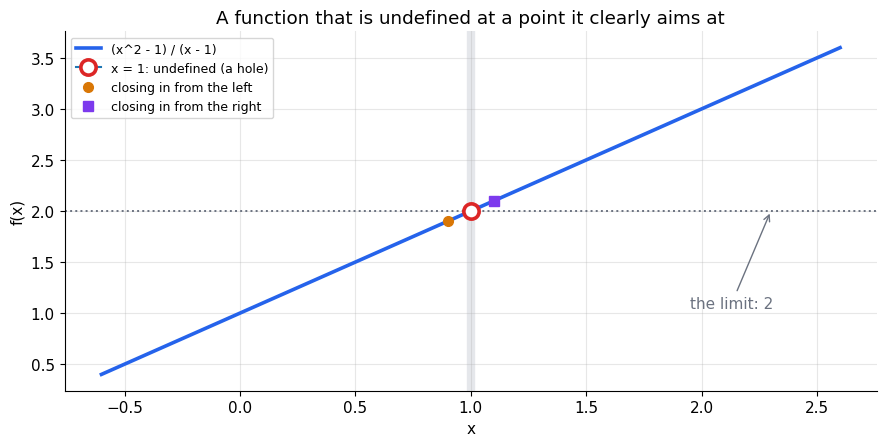

height of the open circle (the limit)   : 2.000000
value of the function at x = 1          : undefined
value at x = 0.999   (left  neighbour)  : 1.999000
value at x = 1.001   (right neighbour)  : 2.001000


In [12]:
# ============================================================
#  Draw it: the line, the hole, and the values marching in.
# ============================================================
xs = np.linspace(-0.6, 2.6, 601)
xs = xs[np.abs(xs - 1.0) > 1e-9]          # never evaluate exactly at the hole

fig, ax = plt.subplots(figsize=(9, 4.6))
ax.plot(xs, f_hole(xs), color=C_F, lw=2.6, label="(x^2 - 1) / (x - 1)", zorder=2)

# the hole itself: an open circle means "this point is NOT on the graph"
ax.plot([1.0], [2.0], marker="o", ms=11, mfc="white",
        mec=C_SLOPE, mew=2.6, zorder=5, label="x = 1: undefined (a hole)")

# the marching values from the table
left  = np.array([0.9, 0.99, 0.999])
right = np.array([1.1, 1.01, 1.001])
ax.plot(left,  f_hole(left),  "o", color=C_APPROX, ms=7, zorder=4,
        label="closing in from the left")
ax.plot(right, f_hole(right), "s", color=C_EXACT,  ms=7, zorder=4,
        label="closing in from the right")

ax.axhline(2.0, color=C_GREY, ls=":", lw=1.4)
ax.annotate("the limit: 2", xy=(2.3, 2.0), xytext=(1.95, 1.05),
            color=C_GREY, fontsize=11,
            arrowprops=dict(arrowstyle="->", color=C_GREY))
ax.axvline(1.0, color=C_SOFT, lw=6, zorder=0)
ax.set_xlabel("x")
ax.set_ylabel("f(x)")
ax.set_title("A function that is undefined at a point it clearly aims at")
ax.legend(loc="upper left", fontsize=9)
fig.tight_layout()
plt.show()

print("height of the open circle (the limit)   : 2.000000")
print("value of the function at x = 1          : undefined")
print(f"value at x = 0.999   (left  neighbour)  : {f_hole(0.999):.6f}")
print(f"value at x = 1.001   (right neighbour)  : {f_hole(1.001):.6f}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

A perfectly ordinary straight line with **one point missing**. The open circle at $(1, 2)$ is the standard notation for *the graph does not include this point*. The grey vertical stripe marks the input we are not allowed to use.

The orange circles creep in from the left and the purple squares from the right, and both sequences are visibly converging on the height of the open circle. Nothing about the picture is ambiguous: if you had to write down the one number that belongs in the hole, you would write $2$, and you would be certain — even though the function itself never says so.

That certainty is exactly what a limit formalises.

**The common misread:** thinking the open circle means the function equals $2$ there. It means the opposite — the graph has been *punctured* at that point. The limit is $2$; the value is nothing at all.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**The single most common misunderstanding of a limit is that it describes what happens AT the point.** It does not. It describes what happens *around* the point, on approach, with the point itself deliberately excluded.

Think of it as reading road signs rather than arriving at the town. The sign says *Rome 2 km*, then *Rome 200 m*, then *Rome 20 m*. You can state with confidence where the road is heading without ever entering the city — and the city could, for all the signs care, have been demolished.

This is not a technicality. It is precisely what makes limits useful. If the limit had to agree with the value at the point, it would tell us nothing new, and we could not use it to make sense of $0/0$ — which is the whole reason we needed it. In Part 3 the quantity we take a limit of is **always** undefined at the point of interest. Every time, for every function, without exception.

</div>

## 2.2 Three ways a limit can fail

A limit is a promise that the outputs settle on one number as you approach. That
promise can be broken in exactly three interesting ways, and it is worth seeing
all three so that "the limit exists" stops sounding like a formality.

First we need notation for approaching from **one side only**:

| Written | Said aloud | Means |
|---|---|---|
| $\displaystyle\lim_{x \to a^-} f(x)$ | "limit as x approaches a from the left" | walk in from **below** $a$ (that is, $x = a - {}$ something small) |
| $\displaystyle\lim_{x \to a^+} f(x)$ | "limit as x approaches a from the right" | walk in from **above** $a$ (that is, $x = a + {}$ something small) |

The tiny minus and plus signs are superscripts on $a$, not subtractions. They
are directions, not arithmetic.

**The rule that ties them together:** the two-sided limit
$\lim_{x \to a} f(x)$ exists **only if both one-sided limits exist and are
equal**. If the two sides disagree, or if either side fails to settle, there is
no limit. Our hole example passed this test easily — both sides gave $2$.

The three failures:

1. **A jump.** Both sides settle, but on *different* numbers. A step function.
2. **A blow-up.** The values grow without bound instead of settling. $1/x$ at $0$.
3. **An oscillation.** The values never settle at all, however close you get. $\sin(1/x)$ at $0$.


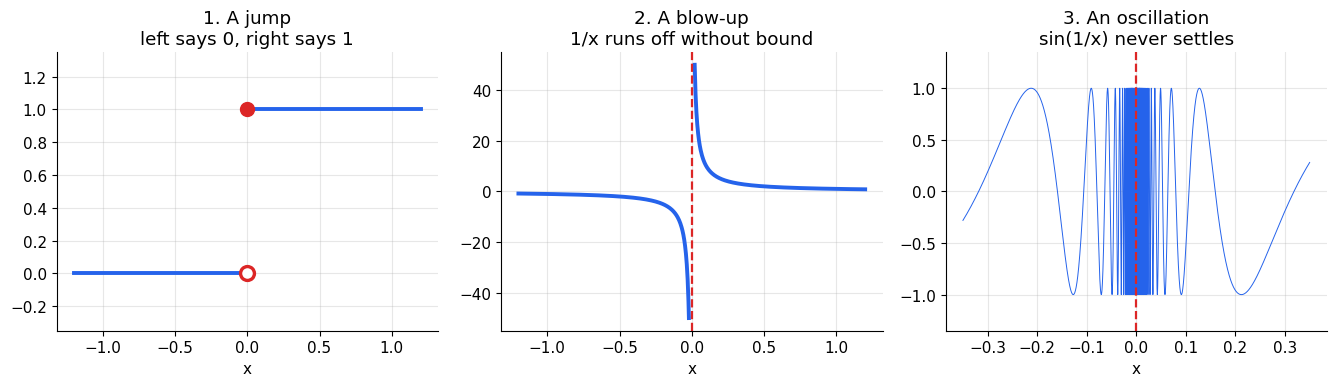

1. THE JUMP:  step(x) as x approaches 0
     d        step(-d)     step(+d)
   1e-01        0.0000       1.0000
   1e-02        0.0000       1.0000
   1e-03        0.0000       1.0000
   1e-06        0.0000       1.0000
   left-hand limit = 0.0, right-hand limit = 1.0 -> they DISAGREE,
   so the two-sided limit does not exist.

2. THE BLOW-UP:  1/x as x approaches 0
     d          1/(-d)          1/(+d)
   1e-01               -10.0            10.0
   1e-02              -100.0           100.0
   1e-03            -1,000.0         1,000.0
   1e-06        -1,000,000.0     1,000,000.0
   1e-09      -1,000,000,000.0  1,000,000,000.0
   Neither side settles on a number -- both run away without bound,
   so neither one-sided limit exists (we write -inf and +inf).

3. THE OSCILLATION:  sin(1/x) at points arbitrarily close to 0
       x                 sin(1/x)
      6.366e-01       +1.0000
      2.122e-01       -1.0000
      1.273e-01       +1.0000
      9.095e-02       -1.0000
      7.074e-02

In [13]:
# ============================================================
#  The three failure modes, drawn and tabulated.
# ============================================================
def step(xx):
    """A jump: 0 below zero, 1 from zero upwards."""
    return np.where(xx < 0, 0.0, 1.0)

def blowup(xx):
    """1/x -- grows without bound on approach to zero."""
    return 1.0 / xx

def wiggle(xx):
    """sin(1/x) -- oscillates faster and faster as x approaches zero."""
    return np.sin(1.0 / xx)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.0))

# ---- 1. the jump -------------------------------------------------------
ax = axes[0]
neg = np.linspace(-1.2, -1e-6, 300)
pos = np.linspace(1e-6, 1.2, 300)
ax.plot(neg, step(neg), color=C_F, lw=2.8)
ax.plot(pos, step(pos), color=C_F, lw=2.8)
ax.plot([0], [0], "o", ms=10, mfc="white", mec=C_SLOPE, mew=2.4)   # excluded
ax.plot([0], [1], "o", ms=10, color=C_SLOPE)                       # included
ax.set_ylim(-0.35, 1.35)
ax.set_title("1. A jump\nleft says 0, right says 1")
ax.set_xlabel("x")

# ---- 2. the blow-up ----------------------------------------------------
ax = axes[1]
neg = np.linspace(-1.2, -0.02, 400)
pos = np.linspace(0.02, 1.2, 400)
ax.plot(neg, blowup(neg), color=C_F, lw=2.8)
ax.plot(pos, blowup(pos), color=C_F, lw=2.8)
ax.set_ylim(-55, 55)
ax.axvline(0, color=C_SLOPE, ls="--", lw=1.6)
ax.set_title("2. A blow-up\n1/x runs off without bound")
ax.set_xlabel("x")

# ---- 3. the oscillation ------------------------------------------------
ax = axes[2]
ww = np.concatenate([np.linspace(-0.35, -1e-4, 40000),
                     np.linspace(1e-4, 0.35, 40000)])
ax.plot(ww, wiggle(ww), color=C_F, lw=0.7)
ax.set_ylim(-1.35, 1.35)
ax.axvline(0, color=C_SLOPE, ls="--", lw=1.6)
ax.set_title("3. An oscillation\nsin(1/x) never settles")
ax.set_xlabel("x")

fig.tight_layout()
plt.show()

# ------------------------- the same three, as numbers -------------------
print("1. THE JUMP:  step(x) as x approaches 0")
print("     d        step(-d)     step(+d)")
for d in [0.1, 0.01, 0.001, 1e-6]:
    print(f"   {d:<9.0e}  {float(step(np.array(-d))):>8.4f}     "
          f"{float(step(np.array(d))):>8.4f}")
print("   left-hand limit = 0.0, right-hand limit = 1.0 -> they DISAGREE,")
print("   so the two-sided limit does not exist.")

print()
print("2. THE BLOW-UP:  1/x as x approaches 0")
print("     d          1/(-d)          1/(+d)")
for d in [0.1, 0.01, 0.001, 1e-6, 1e-9]:
    print(f"   {d:<9.0e}  {blowup(-d):>14,.1f}  {blowup(d):>14,.1f}")
print("   Neither side settles on a number -- both run away without bound,")
print("   so neither one-sided limit exists (we write -inf and +inf).")

print()
print("3. THE OSCILLATION:  sin(1/x) at points arbitrarily close to 0")
print("       x                 sin(1/x)")
for k in range(0, 5):
    x_hi = 2.0 / ((4 * k + 1) * np.pi)      # sin(1/x) = +1 exactly here
    x_lo = 2.0 / ((4 * k + 3) * np.pi)      # sin(1/x) = -1 exactly here
    print(f"   {x_hi:>12.3e}      {wiggle(x_hi):>+8.4f}")
    print(f"   {x_lo:>12.3e}      {wiggle(x_lo):>+8.4f}")
print("   Both +1 and -1 occur at x values as small as you like, forever.")
print("   The outputs never settle, so there is no limit -- not even one-sided.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Three different ways to break the promise.

**Left — the jump.** Both one-sided limits exist perfectly well; they just disagree. Walking in from the left the outputs are all $0$; from the right they are all $1$. The filled circle sits at $1$ (the function's actual value there) and the open circle at $0$ shows where the left-hand approach was heading. There is no single number the function heads towards, so no two-sided limit.

**Middle — the blow-up.** The outputs do not converge on anything; they grow without bound, negatively on the left and positively on the right. The printed table shows $1/x$ reaching a billion at $x = 10^{-9}$ and it is not finished. We write $\lim_{x\to 0^+} 1/x = +\infty$, but that is a *description of the failure*, not a limit that exists — $\infty$ is not a number.

**Right — the oscillation.** The nastiest one, and the one people forget. Nothing runs away; every output stays politely between $-1$ and $+1$. But as $x \to 0$ the input to the sine, $1/x$, races off to infinity, so the sine cycles faster and faster. The table finds points arbitrarily close to zero where the value is exactly $+1$ and others where it is exactly $-1$. Bounded, but never settling.

**The common misread:** assuming that a function which stays finite and has no visible gap must have a limit. The right-hand panel is finite and gapless everywhere except the single point $x = 0$, and its limit there still does not exist. Staying bounded is not the same as converging.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

**One-sided limits** ask the same question but restrict which direction you may walk in from.

$\lim_{x \to a^-} f(x) = L$ says: sneak up on $a$ from the low side only, and the outputs converge on $L$.

$\lim_{x \to a^+} f(x) = L$ says the same from the high side.

**The two-sided limit exists exactly when both one-sided limits exist and are equal.** That is not an extra rule to memorise, it is just what *heading towards a single number* has to mean when there are two ways to approach.

The jump fails because the sides disagree. The blow-up and the oscillation fail earlier than that — neither side settles at all.

</div>

## 2.3 Continuity — a statement about limits

Now that limits exist, one of the most-used words in the subject becomes a
one-line definition.

$$ f \text{ is continuous at } a \quad\Longleftrightarrow\quad \lim_{x \to a} f(x) \;=\; f(a) $$

The symbol $\Longleftrightarrow$ means "if and only if" — the two sides are the
same statement.

Unpacked, that single equation makes **three** demands, and every one of them
can fail on its own:

1. $f(a)$ must exist — the function is actually defined at $a$.
2. $\lim_{x \to a} f(x)$ must exist — both sides settle on the same number.
3. Those two numbers must be **equal** — where it was heading is where it landed.

In pictures: **you can draw the graph through $a$ without lifting your pen.**
That informal version is exactly equivalent, and it is a good one to keep,
because it makes the failures obvious — a hole, a jump, a blow-up or a frenzied
scribble all force you to lift the pen.

Our very first example, $\frac{x^2-1}{x-1}$, fails demand 1 only: the limit is
$2$, but the value does not exist. Such a break is called **removable**, because
you could patch it — define $f(1) = 2$ by hand and the function becomes
continuous. The jump, the blow-up and the oscillation cannot be patched by
choosing one number; they are not removable.

Why we care: **almost every useful theorem in calculus is a theorem about
continuous functions.** And the loss surface of a neural network is assembled
from continuous pieces on purpose, precisely so that those theorems apply.


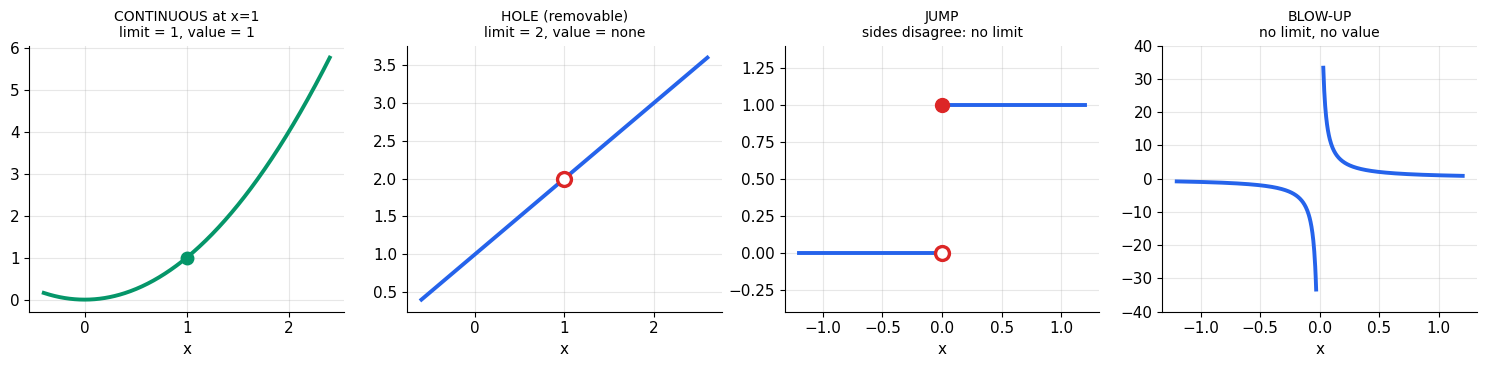

Continuity test at the marked point, demand by demand
----------------------------------------------------------------
function                 limit       value   equal?
----------------------------------------------------------------
x^2 at a=1                   1           1   True
hole at a=1                  2         nan   False  (no value)
jump at a=0               none         1.0   False  (left 0, right 1)
1/x at a=0                none        none   False
----------------------------------------------------------------
Only the first row satisfies all three demands, so only x^2 is
continuous at its marked point. The other three need the pen lifted.


In [14]:
# ============================================================
#  Continuous, versus three ways to fail.
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(15, 3.8))

# ---- continuous: x^2 at a = 1 ------------------------------------------
ax = axes[0]
xx = np.linspace(-0.4, 2.4, 400)
ax.plot(xx, xx ** 2, color=C_AREA, lw=2.8)
ax.plot([1], [1], "o", ms=9, color=C_AREA)
ax.set_title("CONTINUOUS at x=1\nlimit = 1, value = 1", fontsize=10)

# ---- removable hole ----------------------------------------------------
ax = axes[1]
xx = np.linspace(-0.6, 2.6, 601)
xx = xx[np.abs(xx - 1.0) > 1e-9]
ax.plot(xx, f_hole(xx), color=C_F, lw=2.8)
ax.plot([1], [2], "o", ms=10, mfc="white", mec=C_SLOPE, mew=2.4)
ax.set_title("HOLE (removable)\nlimit = 2, value = none", fontsize=10)

# ---- jump ---------------------------------------------------------------
ax = axes[2]
neg = np.linspace(-1.2, -1e-6, 200); pos = np.linspace(1e-6, 1.2, 200)
ax.plot(neg, step(neg), color=C_F, lw=2.8)
ax.plot(pos, step(pos), color=C_F, lw=2.8)
ax.plot([0], [0], "o", ms=10, mfc="white", mec=C_SLOPE, mew=2.4)
ax.plot([0], [1], "o", ms=10, color=C_SLOPE)
ax.set_ylim(-0.4, 1.4)
ax.set_title("JUMP\nsides disagree: no limit", fontsize=10)

# ---- blow-up ------------------------------------------------------------
ax = axes[3]
neg = np.linspace(-1.2, -0.03, 300); pos = np.linspace(0.03, 1.2, 300)
ax.plot(neg, blowup(neg), color=C_F, lw=2.8)
ax.plot(pos, blowup(pos), color=C_F, lw=2.8)
ax.set_ylim(-40, 40)
ax.set_title("BLOW-UP\nno limit, no value", fontsize=10)

for a_ in axes:
    a_.set_xlabel("x")
fig.tight_layout()
plt.show()

# ---- the three demands, checked as numbers -----------------------------
print("Continuity test at the marked point, demand by demand")
print("-" * 64)
print(f"{'function':<18}{'limit':>12}{'value':>12}   equal?")
print("-" * 64)

g_sq = x ** 2
lim_g, val_g = sp.limit(g_sq, x, 1), g_sq.subs(x, 1)
print(f"{'x^2 at a=1':<18}{str(lim_g):>12}{str(val_g):>12}"
      f"   {bool(lim_g == val_g)}")

lim_hole, val_hole = sp.limit(expr, x, 1), expr.subs(x, 1)
print(f"{'hole at a=1':<18}{str(lim_hole):>12}{str(val_hole):>12}"
      f"   False  (no value)")
print(f"{'jump at a=0':<18}{'none':>12}{1.0:>12}   False  (left 0, right 1)")
print(f"{'1/x at a=0':<18}{'none':>12}{'none':>12}   False")
print("-" * 64)
print("Only the first row satisfies all three demands, so only x^2 is")
print("continuous at its marked point. The other three need the pen lifted.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Four panels, one continuous and three not, with a different ingredient missing in each.

**Panel 1** is $x^2$ at $x = 1$: the limit is $1$, the value is $1$, they agree, the pen stays down. Continuous.

**Panel 2** has a limit but no value — the removable hole. One hand-placed dot would fix it.

**Panel 3** has a value ($1$, the filled dot) but no limit, because the two sides head for different numbers. No single dot can fix this: whatever height you choose, one side is still wrong.

**Panel 4** has neither. The printed table walks all three demands for each case and shows only the first row passing.

**The common misread:** treating continuity as a property of a *function* rather than of a function **at a point**. $1/x$ is continuous at every single point where it is defined — its only problem is $x = 0$, where it has no value to be continuous with. "Is it continuous?" is an incomplete question until you say *where*.

</div>

## 2.4 The one limit this whole notebook is built on

Everything so far has been rehearsal for a single expression. Here it is.

$$ \lim_{h \to 0} \frac{f(a+h) - f(a)}{h} $$

**Naming every symbol.** $f$ is any function. $a$ is a fixed input — the place
we are interested in, and it does not move. $h$ is a small number, the *step*:
how far to the right of $a$ we peek. $f(a+h)$ is the output a step away;
$f(a)$ is the output at $a$ itself. The numerator $f(a+h) - f(a)$ is therefore
**how much the output changed** over that step, and dividing by $h$ — **how big
the step was** — gives *change in output per unit of change in input*.

That is precisely the average rate of change from Part 1, between the two points
$a$ and $a+h$. Nothing new yet.

The new part is $h \to 0$. We shrink the step towards nothing and ask what the
answers are heading towards.

And now you can see why we needed §2.1 first: **at $h = 0$ exactly, this
expression is $\frac{f(a)-f(a)}{0} = \frac{0}{0}$ — undefined, every single
time, for every function.** It is the hole all over again. The limit is the only
way to get an answer out of it, and it is exactly the tool that already worked.

Let us do a concrete one. Take $f(x) = x^2$ and $a = 3$, and shrink $h$.


In [15]:
# ============================================================
#  The difference quotient for f(x) = x^2 at a = 3, as h shrinks.
# ============================================================
def f_sq(xx):
    """Our concrete function: f(x) = x squared."""
    return xx ** 2

a = 3.0

print("f(x) = x^2,   a = 3")
print()
print("        h        f(a+h)          f(a)      difference        quotient")
print("  " + "-" * 74)
for hh in [1.0, 0.1, 0.01, 0.001, 0.0001]:
    top = f_sq(a + hh) - f_sq(a)
    q   = top / hh
    print(f"  {hh:>8.4f}  {f_sq(a + hh):>12.8f}  {f_sq(a):>12.8f}  "
          f"{top:>14.10f}  {q:>14.10f}")
print("  " + "-" * 74)
print("  at h = 0 exactly: (9 - 9) / 0  ->  0/0, undefined.")
print()
print("  The quotients are marching towards 6.")
print(f"  quotient at h = 0.0001 : {(f_sq(a + 1e-4) - f_sq(a)) / 1e-4:.10f}")
print(f"  distance from 6        : {(f_sq(a + 1e-4) - f_sq(a)) / 1e-4 - 6:.10f}")

# ---- why 6? expand the numerator by hand, then let sympy confirm -------
print()
print("  the algebra:")
print("    (a+h)^2 - a^2  =  a^2 + 2ah + h^2 - a^2  =  2ah + h^2")
print("    divide by h    =  2a + h                  (valid for h != 0)")
print("    let h -> 0     =  2a  =  2 * 3  =  6")
print()
quotient_sym = sp.simplify(((a + h) ** 2 - a ** 2) / h)
print("  sympy simplifies the quotient to :", quotient_sym)
print("  sympy takes the limit as h -> 0  :", sp.limit(quotient_sym, h, 0))

# ---- and the numeric check of that algebra ------------------------------
hs  = np.array([1.0, 0.1, 0.01, 0.001, 0.0001])
num = (f_sq(a + hs) - f_sq(a)) / hs
alg = 2 * a + hs
print(f"  max |numeric quotient - (2a + h)| = {np.max(np.abs(num - alg)):.2e}")


f(x) = x^2,   a = 3

        h        f(a+h)          f(a)      difference        quotient
  --------------------------------------------------------------------------
    1.0000   16.00000000    9.00000000    7.0000000000    7.0000000000
    0.1000    9.61000000    9.00000000    0.6100000000    6.1000000000
    0.0100    9.06010000    9.00000000    0.0601000000    6.0100000000
    0.0010    9.00600100    9.00000000    0.0060010000    6.0010000000
    0.0001    9.00060001    9.00000000    0.0006000100    6.0001000000
  --------------------------------------------------------------------------
  at h = 0 exactly: (9 - 9) / 0  ->  0/0, undefined.

  The quotients are marching towards 6.
  quotient at h = 0.0001 : 6.0001000000
  distance from 6        : 0.0001000000

  the algebra:
    (a+h)^2 - a^2  =  a^2 + 2ah + h^2 - a^2  =  2ah + h^2
    divide by h    =  2a + h                  (valid for h != 0)
    let h -> 0     =  2a  =  2 * 3  =  6

  sympy simplifies the quotient to : 1.0*h + 

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

Read the quotient as a sentence: **how much the output moved, divided by how far the input moved.**

For $f(x)=x^2$ at $a=3$: step right by $h=1$ and the output climbs from $9$ to $16$, a rise of $7$ over a run of $1$, so the quotient is $7$. Step right by only $h=0.1$ and the output climbs from $9$ to $9.61$, a rise of $0.61$ over a run of $0.1$, so the quotient is $6.1$. Keep shrinking and the answers are $6.01$, $6.001$, $6.0001$.

The algebra says why, and says it exactly: expanding $(a+h)^2 - a^2$ gives $2ah + h^2$, and dividing by $h$ leaves $2a + h$. So the quotient is never $6$ — it is always $6 + h$, overshooting by exactly the step size. Send $h$ to zero and the overshoot goes with it.

Notice that we have produced an exact answer for a calculation that is undefined at the very point we cared about. That is limits earning their keep. **We are not naming this thing yet** — that is Part 3's job — but you have just watched it arrive.

</div>

## 2.5 Where the numerical approach dies

The table above is seductive. Smaller $h$, better answer — so why bother with
algebra at all? Just take $h$ tiny and let the computer do it.

Because **that does not work**, and this section is the most practically
important thing in Part 2.

A computer does not store real numbers. It stores about **16 significant decimal
digits** of each one and throws the rest away. The gap between one storable
number and the next, near a value of size $1$, is about $2.2 \times 10^{-16}$ —
a constant called **machine epsilon**, written $\varepsilon$.

Now look at what our quotient asks the machine to do:

$$ \frac{f(a+h) - f(a)}{h} $$

When $h$ is tiny, $f(a+h)$ and $f(a)$ are two **nearly identical** numbers. Both
are stored to 16 digits. Subtracting them cancels all the leading digits that
agreed — and those were the accurate ones. What survives is the small tail,
where the storage error lives. Then we **divide that wreckage by a tiny number**,
which scales the error up by a huge factor.

This is called **catastrophic cancellation**. Let us watch it happen.


machine epsilon (gap between neighbouring floats near 1) = 2.220e-16
gap between neighbouring floats near 3 (= a)             = 4.441e-16
gap between neighbouring floats near 9 (= f(a))          = 1.776e-15

        h            quotient          error       what is happening
  ------------------------------------------------------------------------------
  1e+00           7.0000000000      1.000e+00   getting better
  1e-01           6.1000000000      1.000e-01   getting better
  1e-02           6.0100000000      1.000e-02   getting better
  1e-03           6.0010000000      1.000e-03   getting better
  1e-04           6.0001000000      1.000e-04   getting better
  1e-05           6.0000100000      1.000e-05   getting better
  1e-06           6.0000010009      1.001e-06   getting better
  1e-07           6.0000000879      8.788e-08   getting better
  1e-08           5.9999999635      3.646e-08   getting better
  1e-09           6.0000004964      4.964e-07   <-- getting WORSE
  1e-10  

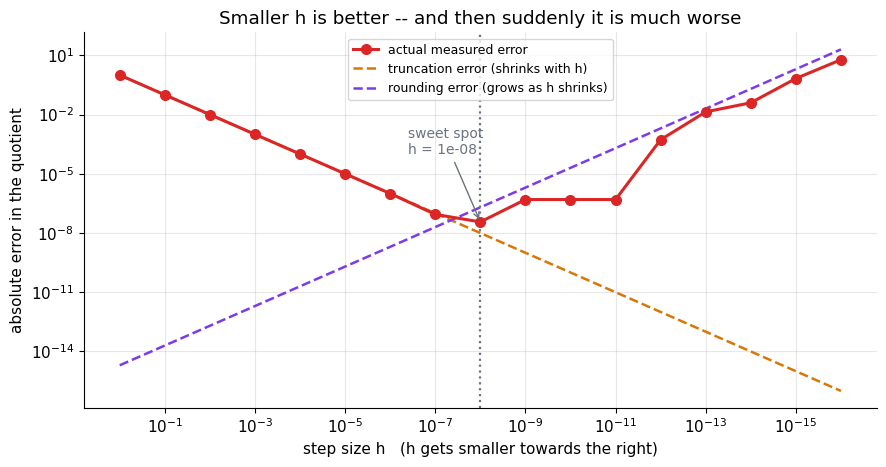

In [16]:
# ============================================================
#  Push h all the way down and watch the answer fall apart.
# ============================================================
TRUE = 6.0                       # we PROVED this above: 2a = 2*3
eps  = np.finfo(float).eps
print(f"machine epsilon (gap between neighbouring floats near 1) = {eps:.3e}")
print(f"gap between neighbouring floats near 3 (= a)             = "
      f"{np.spacing(3.0):.3e}")
print(f"gap between neighbouring floats near 9 (= f(a))          = "
      f"{np.spacing(9.0):.3e}")
print()

print("        h            quotient          error       what is happening")
print("  " + "-" * 78)
rows = []
for k in range(0, 17):
    hh  = 10.0 ** (-k)
    top = f_sq(a + hh) - f_sq(a)
    q   = top / hh
    err = abs(q - TRUE)
    rows.append((hh, q, err))
    if top == 0.0:
        note = "<-- numerator rounded to EXACTLY ZERO"
    elif k <= 8:
        note = "getting better"
    else:
        note = "<-- getting WORSE"
    print(f"  {hh:<10.0e}  {q:>16.10f}  {err:>13.3e}   {note}")
print("  " + "-" * 78)

hs_all = np.array([r[0] for r in rows])
errs   = np.array([r[2] for r in rows])
best_i = int(np.argmin(errs))
print(f"  BEST h    : {hs_all[best_i]:.0e}   with error {errs[best_i]:.3e}")
print(f"  sqrt(eps) : {np.sqrt(eps):.3e}   <- theory says the sweet spot is here")
print()

# ---- the one practical repair: a CENTRAL difference --------------------
# (f(a+h) - f(a-h)) / (2h) straddles the point instead of leaning one way.
#
# We switch to f(x) = x^3 at a = 2 to demonstrate it, for an honest reason:
# for a PARABOLA the central difference happens to be exactly right at every
# h, so x^2 would flatter it. A cubic is the simplest function that does not
# give it a free pass. (Try it on f_sq if you want to see the free pass.)
def f_cu(xx):
    """f(x) = x cubed. Its rate of change at x=2 turns out to be 12."""
    return xx ** 3

b, TRUE_CU = 2.0, 12.0
print("  central vs one-sided, on f(x) = x^3 at a = 2  (true answer 12)")
print("        h        one-sided error    central error")
c_rows = []
for k in range(2, 13):
    hh  = 10.0 ** (-k)
    one = abs((f_cu(b + hh) - f_cu(b)) / hh - TRUE_CU)
    cen = abs((f_cu(b + hh) - f_cu(b - hh)) / (2 * hh) - TRUE_CU)
    c_rows.append((hh, cen))
    print(f"  {hh:<10.0e}  {one:>15.3e}  {cen:>15.3e}")
c_best = min(c_rows, key=lambda r: r[1])
print(f"  best one-sided h here: 1e-08 ;  best CENTRAL h: {c_best[0]:.0e}, "
      f"error {c_best[1]:.3e}")
print(f"  eps ** (1/3) = {eps ** (1.0 / 3.0):.3e}  <- where theory puts the")
print("  central sweet spot, and the table agrees. Roughly 100x better than")
print("  the one-sided best, but the V is only moved, not removed.")
print()
print(f"  h = 1e-16 : quotient = {rows[16][1]:.6f}, error = {errs[16]:.3e}")
print(f"  Because 3 + 1e-16 rounds to {a + 1e-16!r}, the step VANISHES, the")
print(f"  numerator is exactly {f_sq(a + 1e-16) - f_sq(a)}, and the machine")
print(f"  reports a rate of change of {rows[16][1]:.1f} for a function climbing")
print("  at 6. Not approximately wrong. Wrong -- silently, with no error.")

# ---------------------------- the U-shape, drawn ------------------------
fig, ax = plt.subplots(figsize=(9, 4.8))
safe = errs > 0
ax.loglog(hs_all[safe], errs[safe], "o-", color=C_SLOPE, lw=2.2, ms=7,
          label="actual measured error", zorder=3)
ax.loglog(hs_all, hs_all, "--", color=C_APPROX, lw=1.8,
          label="truncation error (shrinks with h)")
ax.loglog(hs_all, eps * 9.0 / hs_all, "--", color=C_EXACT, lw=1.8,
          label="rounding error (grows as h shrinks)")
ax.axvline(hs_all[best_i], color=C_GREY, ls=":", lw=1.6)
ax.annotate(f"sweet spot\nh = {hs_all[best_i]:.0e}",
            xy=(hs_all[best_i], max(errs[best_i], 1e-12)),
            xytext=(hs_all[best_i] * 40, 1e-4),
            fontsize=10, color=C_GREY,
            arrowprops=dict(arrowstyle="->", color=C_GREY))
ax.set_xlabel("step size h   (h gets smaller towards the right)")
ax.set_ylabel("absolute error in the quotient")
ax.set_title("Smaller h is better -- and then suddenly it is much worse")
ax.invert_xaxis()
ax.legend(fontsize=9, loc="upper center")
fig.tight_layout()
plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

A **V**, on log-log axes, with $h$ shrinking towards the right. Two error sources pull in opposite directions and the total is whichever dominates.

**The orange line — truncation error.** The quotient equals $6 + h$ exactly, so using a finite step overshoots by exactly $h$. This shrinks as $h$ shrinks: the left-hand arm of the V, sloping down.

**The purple line — rounding error.** The subtraction $f(a+h) - f(a)$ carries an absolute error of roughly machine epsilon times the size of $f(a)$, about $2.2\times10^{-16} \times 9$. Dividing by $h$ scales that error up by $1/h$, so it *grows* as $h$ shrinks: the right-hand arm, sloping up.

**The red curve is the real measured error**, and it tracks whichever line is higher. It bottoms out where the two cross — near $h \approx \sqrt{\varepsilon} \approx 10^{-8}$ — at an error of around $10^{-8}$. Half your significant digits, gone, at the *best possible* step size.

Past the bottom the answer degrades quickly, and at $h = 10^{-16}$ it collapses: $3 + 10^{-16}$ is not a representable double, so it rounds straight back to $3$, the numerator becomes exactly zero, and the answer is $0$.

**The common misread:** reading the right-hand arm as a small numerical annoyance. At the far end the answer is not slightly off — it is $0$ instead of $6$, with no warning, no exception and no NaN. The function just returns the wrong number.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**"Smaller $h$ is always better" is false, and the table above is the proof.** The error falls for a while, bottoms out around $h \approx \sqrt{\varepsilon} \approx 10^{-8}$, and then climbs again — ending at a completely wrong answer.

The rule of thumb worth keeping: for a one-sided difference quotient the best achievable accuracy is about $\sqrt{\varepsilon} \approx 10^{-8}$ in relative terms — **you lose half your significant digits, unavoidably**. No amount of care in choosing $h$ recovers them.

There is a second trap hiding inside the first. The mathematical limit $h \to 0$ and the numerical experiment "try progressively smaller $h$" are *not the same procedure*. The limit is exact and has no floor; the experiment has a floor set by your hardware. Part 3 takes the limit **symbolically**, doing the cancellation in algebra before any number is stored — which is precisely how it dodges everything on this page.

One practical exception, and the cell above measures it: if you must check a rate of change numerically, use the **central** difference $\frac{f(a+h)-f(a-h)}{2h}$, which straddles the point instead of leaning one way. Its truncation error is proportional to $h^2$ rather than $h$, which moves the sweet spot out to $h \approx \varepsilon^{1/3} \approx 6 \times 10^{-6}$ and buys back about two extra digits. It moves the V; it does not abolish it — nothing does.

(The cell demonstrates this on $x^3$ rather than $x^2$ on purpose. For a parabola the central difference is *exactly* right at every $h$, because the two sides' errors cancel perfectly — a flattering special case that would have proved nothing.)

</div>

<div style="background-color: #f8d7da; border-left: 5px solid #dc3545; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🤖 Why ML cares

**This page is the reason automatic differentiation exists.**

A modern network has hundreds of millions of weights. To get its gradient by finite differences you would nudge each weight in turn and re-run the whole forward pass — hundreds of millions of forward passes for one training step, which is already fatal. But the accuracy argument kills the idea even at small scale: every one of those numbers would carry the $10^{-8}$ relative error from the V above, and those errors compound through the layers.

So frameworks do not do it. PyTorch, JAX and TensorFlow apply the **derivative rules symbolically** — the ones you will derive yourself in Part 4 — to each elementary operation as it runs, and chain the exact results together. That is **autodiff**: accurate to the last bit the hardware can hold, with no $h$ to choose, and one backward pass for the entire gradient no matter how many weights there are. Part 9 walks through it by hand.

Finite differences survive in exactly one job: **gradient checking**. When you hand-write a new layer's backward pass, you compare it against a central difference and expect agreement to about $10^{-5}$ — not to 16 digits, because you now know the numerical method cannot deliver that.

</div>

## 2.6 Limits at infinity, and a function that saturates

One last variation. Instead of squeezing $x$ towards a point, let it run away:

$$ \lim_{x \to \infty} f(x) \;=\; L $$

Read: **"as $x$ grows without bound, $f(x)$ settles on $L$."** The symbol
$\infty$ is not a number and you never reach it — $x \to \infty$ is shorthand
for *take $x$ as large as you like*. Everything else is the same idea: is there
a value the outputs are heading towards?

The easy case is $1/x$. Make $x$ enormous and $1/x$ becomes minuscule, so
$\lim_{x\to\infty} 1/x = 0$. (Note that this is the *same function* whose limit
at $0$ failed to exist in §2.2. Where you take the limit is part of the
question.)

The case that matters for machine learning is the **sigmoid**, also called the
logistic function:

$$ \sigma(x) \;=\; \frac{1}{1 + e^{-x}} $$

**Naming every symbol:** $\sigma$ is the Greek letter sigma, the traditional
name for this function. $e$ is Euler's number, about $2.71828$, and $e^{-x}$
means $e$ raised to the power $-x$. When $x$ is large and positive, $-x$ is
large and negative, $e^{-x}$ is nearly $0$, and $\sigma(x)$ is nearly
$\frac{1}{1+0} = 1$. When $x$ is large and negative, $e^{-x}$ is enormous, so
the denominator is enormous and $\sigma(x)$ is nearly $0$.

So $\sigma$ squashes every real number into the open interval between $0$ and
$1$ — which is why it was the standard way to turn a score into a probability,
and the standard neural-network activation for decades. Its two limits at
infinity are $0$ and $1$, and it attains neither.

The interesting part is not *that* it saturates but **how flat it gets**.


A.  1/x  as x grows
          x           1/x
          1e+00     1.000e+00
          1e+01     1.000e-01
          1e+02     1.000e-02
          1e+04     1.000e-04
          1e+08     1.000e-08
          1e+12     1.000e-12
   -> heading to 0. sympy agrees: 0

B.  sigmoid as x runs both ways
          x       sigmoid(x)     1 - sigmoid(x)
          0.0   0.5000000000         5.000e-01
          2.0   0.8807970780         1.192e-01
          5.0   0.9933071491         6.693e-03
         10.0   0.9999546021         4.540e-05
         20.0   0.9999999979         2.061e-09
         40.0   1.0000000000         0.000e+00
   -> sympy, limit at +oo: 1    at -oo: 0

C.  THE POINT: how much does sigmoid change over a step of 1?
   (this is an average rate of change, exactly as in Part 1)
       from x    to x+1        change
         0.0       1.0     2.311e-01
         2.0       3.0     7.178e-02
         5.0       6.0     4.220e-03
        10.0      11.0     2.870e-05
        20.0      21.0 

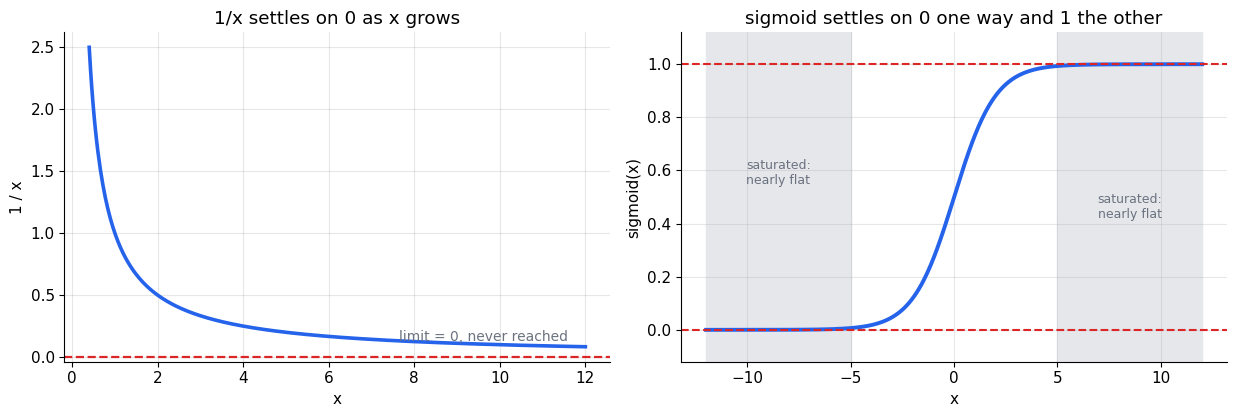

In [17]:
# ============================================================
#  Two limits at infinity: 1/x heading to 0, sigmoid heading to 0 and 1.
# ============================================================
def sigmoid(xx):
    """1 / (1 + e^-x). Squashes any real number into (0, 1)."""
    return 1.0 / (1.0 + np.exp(-xx))

print("A.  1/x  as x grows")
print("          x           1/x")
for xv in [1.0, 10.0, 1e2, 1e4, 1e8, 1e12]:
    print(f"   {xv:>12.0e}  {1.0 / xv:>12.3e}")
print("   -> heading to 0. sympy agrees:", sp.limit(1 / x, x, sp.oo))

print()
print("B.  sigmoid as x runs both ways")
print("          x       sigmoid(x)     1 - sigmoid(x)")
for xv in [0.0, 2.0, 5.0, 10.0, 20.0, 40.0]:
    print(f"   {xv:>10.1f}  {sigmoid(xv):>13.10f}  {1 - sigmoid(xv):>16.3e}")
sig_sym = 1 / (1 + sp.exp(-x))
print("   -> sympy, limit at +oo:", sp.limit(sig_sym, x, sp.oo),
      "   at -oo:", sp.limit(sig_sym, x, -sp.oo))

print()
print("C.  THE POINT: how much does sigmoid change over a step of 1?")
print("   (this is an average rate of change, exactly as in Part 1)")
print("       from x    to x+1        change")
for xv in [0.0, 2.0, 5.0, 10.0, 20.0]:
    delta = sigmoid(xv + 1) - sigmoid(xv)
    print(f"   {xv:>9.1f}  {xv + 1:>8.1f}  {delta:>12.3e}")
print()
d0, d20 = sigmoid(1) - sigmoid(0), sigmoid(21) - sigmoid(20)
print(f"   At x = 0  a unit step moves the output by {d0:.3e}")
print(f"   At x = 20 a unit step moves the output by {d20:.3e}")
print(f"   That is {d0 / d20:,.0f} times smaller. The function has gone numb.")

# ------------------------------------------------------------ the picture
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.3))

xr = np.linspace(0.4, 12, 400)
ax1.plot(xr, 1.0 / xr, color=C_F, lw=2.6)
ax1.axhline(0, color=C_SLOPE, ls="--", lw=1.6)
ax1.annotate("limit = 0, never reached", xy=(11.6, 0.13), fontsize=10,
             color=C_GREY, ha="right")
ax1.set_xlabel("x")
ax1.set_ylabel("1 / x")
ax1.set_title("1/x settles on 0 as x grows")

xs2 = np.linspace(-12, 12, 600)
ax2.plot(xs2, sigmoid(xs2), color=C_F, lw=2.8)
ax2.axhline(1.0, color=C_SLOPE, ls="--", lw=1.5)
ax2.axhline(0.0, color=C_SLOPE, ls="--", lw=1.5)
ax2.axvspan(-12, -5, color=C_SOFT, zorder=0)
ax2.axvspan(5, 12, color=C_SOFT, zorder=0)
ax2.text(-8.5, 0.55, "saturated:\nnearly flat", ha="center", fontsize=9,
         color=C_GREY)
ax2.text(8.5, 0.42, "saturated:\nnearly flat", ha="center", fontsize=9,
         color=C_GREY)
ax2.set_xlabel("x")
ax2.set_ylabel("sigmoid(x)")
ax2.set_title("sigmoid settles on 0 one way and 1 the other")
ax2.set_ylim(-0.12, 1.12)

fig.tight_layout()
plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

**Left:** $1/x$ sinking towards the dashed line at $0$ and never touching it. The printed table reaches $10^{-12}$ by $x = 10^{12}$. "Approaches $0$" and "equals $0$ somewhere" are different claims, and only the first is true.

**Right:** the sigmoid, pinned between the dashed lines at $0$ and $1$. In the middle it responds sharply to its input. In the shaded bands it has flattened out — this is called **saturation**.

Table C is the part to remember. Near $x=0$ a unit step changes the output by about $0.231$. Near $x=20$ the same unit step changes it by about $1.3 \times 10^{-9}$ — the printed ratio is over $177$ **million**. The function is still strictly increasing out there, and mathematically it is perfectly well behaved, but for any practical purpose it has stopped listening to its input.

**The common misread:** looking at the flat right-hand tail and concluding that the sigmoid *becomes* $1$. It never does, for any finite input — `sigmoid(40)` prints as $1.0$ only because the true gap of about $4\times10^{-18}$ is smaller than a double can represent next to $1$. The mathematics and the floating point disagree here, and it is worth knowing which is which.

</div>

<div style="background-color: #f8d7da; border-left: 5px solid #dc3545; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🤖 Why ML cares

**Saturation is the vanishing-gradient problem, met before we have the word for it.**

Training moves each weight in proportion to how much the loss responds to wiggling it. If a neuron's input has drifted out to $20$, table C says the response to a unit wiggle is around $10^{-9}$. The learning signal reaching that neuron is effectively zero: it is saturated, and it stops learning. Stack ten such layers, multiply ten near-zero responses together, and the signal reaching the early layers is annihilated. That is the vanishing gradient, and it is why deep networks were famously hard to train before about 2012.

Nearly every architectural fix you have heard of is a response to this one picture. **ReLU** ($\max(0, x)$) replaced the sigmoid because its right half never flattens — its rate of change is exactly $1$, forever. **Batch normalisation** and **layer normalisation** rescale inputs to keep them near the responsive middle instead of drifting into the tails. **Residual connections** hand the signal a path that skips the squashing entirely. **Careful weight initialisation** exists to start you in the steep region.

You will be able to state all of this precisely once Part 5 gives you the language for *how fast is this changing*. For now: the flat tails in the right-hand panel are where learning goes to die.

</div>

---

## 2.7 What you now have, and what happens next

**The one idea:** a limit is the value a function is *heading towards*. It is
computed by approaching, never by arriving, and it is completely indifferent to
what happens at the destination — which is exactly why it can extract a finite
answer from $0/0$.

**The vocabulary, all of it earned:**

| Idea | Meaning |
|---|---|
| $\lim_{x\to a} f(x) = L$ | outputs head towards $L$ as inputs head towards $a$ |
| $x \to a^-$ , $x \to a^+$ | approach from the left / from the right |
| the limit exists | both one-sided limits exist **and agree** |
| continuous at $a$ | the limit equals the value: $\lim_{x\to a} f(x) = f(a)$ |
| removable | a hole that one hand-placed dot would fix |
| $\lim_{x\to\infty}$ | the value approached as the input grows without bound |
| saturation | the outputs flatten out; the function stops responding |

**And the expression everything now rests on:**

$$ \lim_{h \to 0} \frac{f(a+h) - f(a)}{h} $$

You have computed it for $f(x) = x^2$ at $a = 3$ and watched it converge on
$6$ — numerically, algebraically, and with sympy agreeing. You also know why you
must not compute it numerically in practice.

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ➡️ Coming up in Part 3 — the derivative

That limit has a name, and it is the most useful object in the subject. **It is the derivative**, and Part 3 does four things with it:

1. **Names it, and its notations** — $f'(a)$, $\frac{dy}{dx}$ — and makes them all say the same sentence.
2. **Reads it geometrically**: the difference quotient is the slope of a secant line through two points, and as $h\to0$ the secant pivots into the **tangent**. So the derivative is the slope of the curve *at a point*. Part 1 drew those creeping secants; now they land.
3. **Computes derivatives from the definition alone**, by hand, with no rules — for $x^2$, for $x^3$, for $1/x$ — so that Part 4's rules arrive as things you could have derived yourself, and in fact will.
4. **Applies it to the car**, recovering the instantaneous speed at $t = 55$ s that Part 0 could only bracket with a two-second average.

Everything you need for it is already on this page. The rest is consequence.

</div>

---


---

# 3️⃣ The derivative, built from scratch

In Part 2 we did something slightly sneaky. We took the function $f(x) = x^2$,
picked the point $a = 3$, and computed

$$\frac{f(3+h) - f(3)}{h}$$

for smaller and smaller $h$. The numbers marched towards $6$ and we watched them
do it. Then we moved on **without ever saying what that number was**.

Time to say it.
<div style="background: linear-gradient(135deg, #0F2027 0%, #2C5364 100%); padding: 28px; border-radius: 18px; color: white; margin: 12px 0;">


### That limit has a name, and the name is the derivative.

$$f'(a) \;=\; \lim_{h \to 0} \frac{f(a+h) - f(a)}{h}$$

That is it. That is the definition. Everything else in this notebook — every
rule, every shortcut, every gradient in every neural network ever trained — is
either a consequence of this one line or a way of computing it quickly.

The quantity $\dfrac{f(a+h) - f(a)}{h}$ is the **average** rate of change of $f$
over a window of width $h$, which is exactly the secant slope you drew in Part 1.
The limit shrinks that window to nothing. What survives is the **instantaneous**
rate of change — the answer to *how fast is it changing right now*, which
looked impossible in Part 0 because it seemed to be zero divided by zero.


</div>

Let us re-run Part 2's calculation, at four different points at once, and see
what falls out.


In [18]:
# ============================================================
#  Part 2's limit, recomputed -- this time at several points.
#  f(x) = x^2. For each base point a we shrink h and watch the
#  difference quotient settle.
# ============================================================
def diff_quotient(f, a, hh):
    """Average rate of change of f over the window [a, a+hh]. Part 1's secant slope."""
    return (f(a + hh) - f(a)) / hh

f_sq = lambda z: z ** 2
h_list = [1.0, 0.1, 0.01, 0.001, 1e-4, 1e-6]
a_list = [1.0, 2.0, 3.0, 4.0]

header = "     a  " + "".join(f"{hh:>12g}" for hh in h_list) + "     settles on"
print(header)
print("-" * len(header))
for a in a_list:
    row = "".join(f"{diff_quotient(f_sq, a, hh):12.6f}" for hh in h_list)
    print(f"{a:6.1f}  {row}   {2 * a:>10.1f}")

print()
print("Read the last column. a=1 -> 2,  a=2 -> 4,  a=3 -> 6,  a=4 -> 8.")
print("The limit is not one number. It is 2a: a number FOR EVERY a.")


     a             1         0.1        0.01       0.001      0.0001       1e-06     settles on
-----------------------------------------------------------------------------------------------
   1.0      3.000000    2.100000    2.010000    2.001000    2.000100    2.000001          2.0
   2.0      5.000000    4.100000    4.010000    4.001000    4.000100    4.000001          4.0
   3.0      7.000000    6.100000    6.010000    6.001000    6.000100    6.000001          6.0
   4.0      9.000000    8.100000    8.010000    8.001000    8.000100    8.000001          8.0

Read the last column. a=1 -> 2,  a=2 -> 4,  a=3 -> 6,  a=4 -> 8.
The limit is not one number. It is 2a: a number FOR EVERY a.


### The definition, with every piece named

$$\underbrace{f'(a)}_{\text{the derivative of } f \text{ at } a} \;=\;
\lim_{h \to 0}
\underbrace{
\frac{
\overbrace{f(a+h)}^{\substack{\text{height a distance} \\ h \text{ to the right}}}
- \overbrace{f(a)}^{\substack{\text{height} \\ \text{here}}}}
{\underbrace{h}_{\substack{\text{width of} \\ \text{the window}}}}
}_{\text{rise over run: the secant slope}}$$

Piece by piece, in words:

| Symbol | Said aloud | What it actually is |
|---|---|---|
| $a$ | "a" | the **one point** we are asking about — a fixed number, like 3 |
| $h$ | "h" | the width of a small window to the right of $a$ — the thing we shrink |
| $f(a+h) - f(a)$ | "f of a plus h, minus f of a" | the **rise**: how much the output changed |
| $h$ (the denominator) | | the **run**: how much the input changed |
| the fraction | "the difference quotient" | **average** rate of change across the window |
| $\lim_{h \to 0}$ | "the limit as h goes to zero" | shrink the window; do not set $h=0$, *approach* it |
| $f'(a)$ | "f prime of a" | the **instantaneous** rate of change at $a$ |

The single most important word above is **approach**. We never divide by zero.
We never even set $h = 0$. We ask what the fraction is heading towards, which is
precisely the machinery Part 2 built.


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

**The derivative of $f$ at $a$ is the slope of $f$ at the single point $a$.**

You cannot measure a slope at a point directly — a slope needs two points. So you measure it across a small window, then keep shrinking the window and see what number the answer is homing in on. That number is the derivative.

For the car in Part 0: $a$ is the moment you care about, $h$ is a stopwatch window, the fraction is the average speed over that window, and $f'(a)$ is what the speedometer reads.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**$f'(a)$ is a number. $f'$ is a function. They are not the same object.**

The table above printed $2a$ — not a single value, but a rule that produces a value for every $a$ you feed it. So:

- $f'(3) = 6$ &nbsp;&nbsp;— a **number**. The slope at one place. You could write it on a napkin.
- $f'(x) = 2x$ — a **function**. A machine that gives you the slope anywhere.

People write $f'(x)$ when they mean the function and $f'(a)$ when they mean a number at one point, and the only difference on the page is which letter is inside the brackets. When you get confused later — and you will, around the chain rule — the first question to ask is *am I holding a number or a function right now?*

</div>

### Watch it happen: secants becoming a tangent

Part 1 drew **secant lines** — straight lines through two points on a curve.
The definition above says: take a secant from $a$ to $a+h$, and shrink $h$.

Below is that shrinking, frozen into stills. Five secant lines through the point
$(3, 9)$ on $y = x^2$, with the second point at $h = 2, 1, 0.5, 0.25, 0.1$ to the
right. As $h$ shrinks, the second point slides down the curve towards the first,
and the line pivots. The dashed line is where it ends up: the **tangent**, the
line that just touches the curve at that one point.

The slopes are printed underneath, so you can watch the numbers converge at the
same time as the picture.


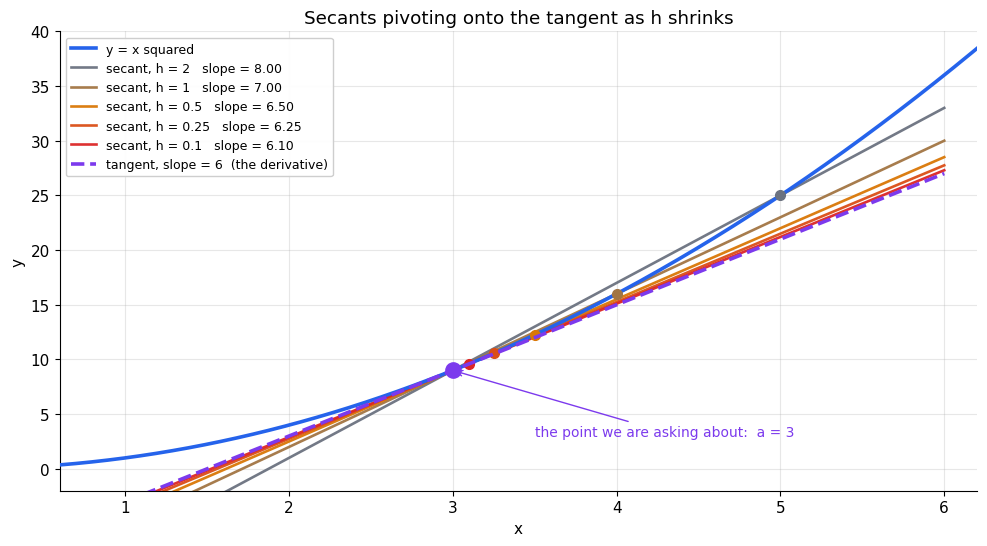

     h        second point       secant slope     distance from 6
------------------------------------------------------------------
  2.00    (5.00,  25.00)          8.0000          2.0000
  1.00    (4.00,  16.00)          7.0000          1.0000
  0.50    (3.50,  12.25)          6.5000          0.5000
  0.25    (3.25,  10.56)          6.2500          0.2500
  0.10    (3.10,   9.61)          6.1000          0.1000
 1e-02    (3.010000, 9.060100)      6.010000        1.00e-02
 1e-04    (3.000100, 9.000600)      6.000100        1.00e-04
 1e-06    (3.000001, 9.000006)      6.000001        1.00e-06

Every secant slope here is exactly 6 + h. The picture and the algebra
agree, and both say the same thing: as h vanishes, the slope is 6.


In [19]:
from matplotlib.colors import LinearSegmentedColormap

# ------------------------------------------------------------------
#  y = x^2, base point a = 3. Secants at shrinking h, then the tangent.
# ------------------------------------------------------------------
a0    = 3.0
f     = lambda z: z ** 2
hs    = [2.0, 1.0, 0.5, 0.25, 0.1]
xs    = np.linspace(0.6, 6.2, 400)

grad  = LinearSegmentedColormap.from_list("secant", [C_GREY, C_APPROX, C_SLOPE])
cols  = [grad(i / (len(hs) - 1)) for i in range(len(hs))]

fig, ax = plt.subplots(figsize=(10, 5.6))
ax.plot(xs, f(xs), color=C_F, lw=2.6, label="y = x squared", zorder=3)

x_line = np.linspace(1.0, 6.0, 2)
for hh, col in zip(hs, cols):
    slope = (f(a0 + hh) - f(a0)) / hh
    ax.plot(x_line, f(a0) + slope * (x_line - a0), color=col, lw=1.9, alpha=0.95,
            label=f"secant, h = {hh:g}   slope = {slope:.2f}", zorder=2)
    ax.plot([a0 + hh], [f(a0 + hh)], "o", color=col, ms=7, zorder=4)

# the tangent: the limit these secants are converging to
ax.plot(x_line, f(a0) + 6.0 * (x_line - a0), color=C_EXACT, lw=2.6, ls="--",
        label="tangent, slope = 6  (the derivative)", zorder=5)
ax.plot([a0], [f(a0)], "o", color=C_EXACT, ms=11, zorder=6)
ax.annotate("the point we are asking about:  a = 3", xy=(a0, f(a0)),
            xytext=(3.5, 3.0), color=C_EXACT, fontsize=10,
            arrowprops=dict(arrowstyle="->", color=C_EXACT))

ax.set_xlim(0.6, 6.2); ax.set_ylim(-2, 40)
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("Secants pivoting onto the tangent as h shrinks")
ax.legend(loc="upper left", fontsize=9, framealpha=0.95)
fig.tight_layout(); plt.show()

print("     h        second point       secant slope     distance from 6")
print("-" * 66)
for hh in hs:
    s = (f(a0 + hh) - f(a0)) / hh
    print(f"{hh:6.2f}    ({a0 + hh:.2f}, {f(a0 + hh):6.2f})    {s:12.4f}    {abs(s - 6):12.4f}")
for hh in [0.01, 1e-4, 1e-6]:
    s = (f(a0 + hh) - f(a0)) / hh
    print(f"{hh:6.0e}    ({a0 + hh:.6f}, {f(a0 + hh):.6f})  {s:12.6f}    {abs(s - 6):12.2e}")
print()
print("Every secant slope here is exactly 6 + h. The picture and the algebra")
print("agree, and both say the same thing: as h vanishes, the slope is 6.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Five straight lines all passing through the same point $(3, 9)$, each cutting the curve at a second point that is $h$ to the right. Grey is the crudest ($h = 2$, second point way up at $(5, 25)$, slope 8); the reds are tighter; the purple dashed line is the tangent with slope exactly 6.

Notice the second points sliding *down the curve* towards $(3,9)$ as $h$ shrinks, and the lines fanning shut onto the dashed one. The printed column does the same thing in numbers: 8, 7, 6.5, 6.25, 6.1, then 6.01, 6.0001, 6.000001. **The picture converging and the numbers converging are the same event.**

The tangent is not 'a line that touches the curve once' — plenty of lines do that. It is the line the secants converge to, which is a much sharper idea and the only one that generalises.

**The common misread:** believing the tangent is reached when $h$ is finally small enough. It never is. No value of $h$ gives slope 6 — every one gives $6 + h$, which is never 6. The tangent is the **destination**, not a member of the sequence. That distinction is exactly why the limit had to be invented.

</div>

---

## Three derivatives, derived by hand

Watching numbers converge is convincing but slow. The whole point of the
definition is that you can often do the limit **algebraically**, once, and get a
formula that works for every $a$ forever.

We will do three, in full, with nothing skipped. Then we check each one two
different ways.

### Derivation 1 — $f(x) = x^2$

Start with the definition and substitute:

$$f'(x) \;=\; \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}
\;=\; \lim_{h \to 0} \frac{(x+h)^2 - x^2}{h}$$

**Step 1 — expand the bracket.** $(x+h)^2 = (x+h)(x+h) = x^2 + xh + hx + h^2 = x^2 + 2xh + h^2$:

$$= \lim_{h \to 0} \frac{x^2 + 2xh + h^2 - x^2}{h}$$

**Step 2 — the $x^2$ terms cancel.** This always happens, and it is the reason
the whole thing works: the constant part of the function is the same at both
ends of the window, so it subtracts away:

$$= \lim_{h \to 0} \frac{2xh + h^2}{h}$$

**Step 3 — every surviving term has an $h$ in it.** Factor it out:

$$= \lim_{h \to 0} \frac{h(2x + h)}{h}$$

**Step 4 — cancel the $h$.** *This is the step that is legal only because of the
limit.* We are told $h \to 0$, not $h = 0$, so $h \neq 0$, so dividing top and
bottom by $h$ is ordinary arithmetic:

$$= \lim_{h \to 0} \, (2x + h)$$

**Step 5 — now the limit is easy.** $2x + h$ is a perfectly well-behaved
expression at $h = 0$; nothing blows up, so we just substitute:

$$f'(x) = 2x$$

The awkward $0/0$ from Part 0 is gone. It was never really $0/0$ — it was
$h \cdot (\text{something}) / h$ wearing a disguise, and Step 4 took the disguise off.


In [20]:
# ============================================================
#  Confirm a by-hand derivation TWO independent ways:
#    (a) symbolically -- let sympy take the same limit
#    (b) numerically  -- measure the slope with real numbers
#  If our algebra were wrong, at least one of these would disagree.
# ============================================================
def confirm(label, f_expr, claimed, points, h_small=1e-6):
    """Check that d/dx f_expr equals `claimed`, symbolically and numerically."""
    quotient  = (f_expr.subs(x, x + h) - f_expr) / h        # the definition itself
    from_lim  = sp.simplify(sp.limit(quotient, h, 0))       # sympy takes the limit
    agree_sym = sp.simplify(from_lim - claimed) == 0

    print(f"{label}")
    print(f"   difference quotient      : {sp.simplify(quotient)}")
    print(f"   its limit as h -> 0      : {from_lim}          (sympy)")
    print(f"   what we derived by hand  : {claimed}")
    print(f"   symbolic agreement       : {agree_sym}")
    print(f"   sympy's own diff()       : {sp.diff(f_expr, x)}")
    print()

    f_num, d_num = sp.lambdify(x, f_expr, "numpy"), sp.lambdify(x, claimed, "numpy")
    print(f"   {'x':>7} {'slope measured':>16} {'our formula':>14} {'gap':>11}")
    worst = 0.0
    for a in points:
        measured = (f_num(a + h_small) - f_num(a - h_small)) / (2 * h_small)
        ours     = float(d_num(a))
        worst    = max(worst, abs(measured - ours))
        print(f"   {a:7.2f} {measured:16.8f} {ours:14.8f} {abs(measured - ours):11.2e}")
    print(f"   largest disagreement     : {worst:.2e}  (this is float noise, not error)")
    return agree_sym, worst


ok1, gap1 = confirm("f(x) = x**2   ->  we claim f'(x) = 2*x",
                    x**2, 2*x, [-3.0, -1.0, 0.5, 3.0, 7.0])


f(x) = x**2   ->  we claim f'(x) = 2*x
   difference quotient      : h + 2*x
   its limit as h -> 0      : 2*x          (sympy)
   what we derived by hand  : 2*x
   symbolic agreement       : True
   sympy's own diff()       : 2*x

         x   slope measured    our formula         gap
     -3.00      -6.00000000    -6.00000000    8.39e-10
     -1.00      -2.00000000    -2.00000000    2.00e-12
      0.50       1.00000000     1.00000000    1.29e-11
      3.00       6.00000000     6.00000000    8.39e-10
      7.00      14.00000000    14.00000000    3.73e-09
   largest disagreement     : 3.73e-09  (this is float noise, not error)


<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

The by-hand result $f'(x) = 2x$ was confirmed **twice, independently**:

1. **Symbolically** — sympy was handed the difference quotient $\big((x+h)^2 - x^2\big)/h$, simplified it to $2x + h$ (exactly our Step 4), took the limit, and got $2x$. Its own `diff()` agrees.
2. **Numerically** — at five different values of $x$, including negative ones, the slope measured from actual function values matches $2x$ to about $10^{-9}$ or better.

The residual gap is floating-point noise of the kind Part 2 warned about, not a flaw in the algebra. If Step 1 had botched the expansion — say $(x+h)^2 = x^2 + h^2$, the single most common error in all of algebra — the numeric column would be off by $2x$ everywhere and you would see it instantly. It is not. The derivation is sound.

</div>

### Derivation 2 — $f(x) = x^3$

Same five steps. The only new work is a bigger expansion.

$$f'(x) = \lim_{h \to 0} \frac{(x+h)^3 - x^3}{h}$$

**Step 1 — expand $(x+h)^3$.** Multiply out patiently:

$$(x+h)^3 = (x+h)(x+h)^2 = (x+h)(x^2 + 2xh + h^2)$$
$$= x^3 + 2x^2h + xh^2 \;+\; x^2h + 2xh^2 + h^3
\;=\; x^3 + 3x^2h + 3xh^2 + h^3$$

**Step 2 — the $x^3$ terms cancel:**

$$= \lim_{h \to 0} \frac{3x^2h + 3xh^2 + h^3}{h}$$

**Step 3 — factor out $h$:**

$$= \lim_{h \to 0} \frac{h\,(3x^2 + 3xh + h^2)}{h}$$

**Step 4 — cancel it** (legal because $h \neq 0$ on the way to the limit):

$$= \lim_{h \to 0} \,(3x^2 + 3xh + h^2)$$

**Step 5 — substitute $h = 0$.** The last two terms both contain $h$, so both
vanish:

$$f'(x) = 3x^2$$

Note what happened to the leftovers. With $x^2$ we were left with $2x + h$: one
junk term, linear in $h$. With $x^3$ we were left with $3x^2 + 3xh + h^2$: two
junk terms, but *every one of them still carries at least one factor of $h$*, so
every one of them dies. That is not luck — it is Step 3 guaranteeing it.


In [21]:
ok2, gap2 = confirm("f(x) = x**3   ->  we claim f'(x) = 3*x**2",
                    x**3, 3*x**2, [-2.0, -0.5, 1.0, 2.5, 4.0])

# And a direct look at the "junk terms die" claim, with numbers:
print()
print("The leftovers 3xh + h^2 at x = 2, as h shrinks:")
for hh in [1.0, 0.1, 0.01, 1e-3, 1e-4]:
    quot = ((2 + hh)**3 - 2**3) / hh
    print(f"   h = {hh:<8g} quotient = {quot:12.8f}   "
          f"= 12 + {3*2*hh + hh**2:.8f}   (junk = 3xh + h^2)")
print(f"   h -> 0     quotient -> {3 * 2**2:.8f}   = 3x^2 at x = 2")


f(x) = x**3   ->  we claim f'(x) = 3*x**2
   difference quotient      : (-x**3 + (h + x)**3)/h
   its limit as h -> 0      : 3*x**2          (sympy)
   what we derived by hand  : 3*x**2
   symbolic agreement       : True
   sympy's own diff()       : 3*x**2

         x   slope measured    our formula         gap
     -2.00      12.00000000    12.00000000    7.89e-10
     -0.50       0.75000000     0.75000000    7.50e-13
      1.00       3.00000000     3.00000000    8.03e-11
      2.50      18.75000000    18.75000000    2.40e-09
      4.00      48.00000000    48.00000000    3.16e-09
   largest disagreement     : 3.16e-09  (this is float noise, not error)

The leftovers 3xh + h^2 at x = 2, as h shrinks:
   h = 1        quotient =  19.00000000   = 12 + 7.00000000   (junk = 3xh + h^2)
   h = 0.1      quotient =  12.61000000   = 12 + 0.61000000   (junk = 3xh + h^2)
   h = 0.01     quotient =  12.06010000   = 12 + 0.06010000   (junk = 3xh + h^2)
   h = 0.001    quotient =  12.00600100   = 12

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

$f'(x) = 3x^2$ confirmed symbolically (sympy's limit of the difference quotient, and its `diff()`) and numerically at five points, negatives included.

The second block makes Step 5 literal rather than rhetorical. At $x = 2$ the exact difference quotient is $12 + 3xh + h^2 = 12 + 6h + h^2$. The printed junk column shrinks $6.0 \to 0.6 \to 0.06 \to \dots$ while the quotient walks down to 12. **We are not asserting the junk terms vanish; you can watch them go.**

</div>

### Derivation 3 — $f(x) = \dfrac{1}{x}$

This one has a genuinely new move in it, so we go slowly. There is no bracket to
expand; instead there are two fractions to subtract, and subtracting fractions
needs a **common denominator**.

$$f'(x) = \lim_{h \to 0} \frac{\dfrac{1}{x+h} - \dfrac{1}{x}}{h}$$

That stacked fraction is unpleasant to look at, so deal with the numerator on its
own first.

**Step 1 — put $\dfrac{1}{x+h} - \dfrac{1}{x}$ over one denominator.** To add or
subtract fractions you need them to share a bottom. The shared bottom here is
$x(x+h)$. Multiply the first fraction top and bottom by $x$, and the second top
and bottom by $(x+h)$ — which changes nothing, since each is multiplication by 1:

$$\frac{1}{x+h} = \frac{1 \cdot x}{(x+h) \cdot x} = \frac{x}{x(x+h)},
\qquad
\frac{1}{x} = \frac{1 \cdot (x+h)}{x \cdot (x+h)} = \frac{x+h}{x(x+h)}$$

**Step 2 — now subtract, since the bottoms match:**

$$\frac{x}{x(x+h)} - \frac{x+h}{x(x+h)} = \frac{x - (x+h)}{x(x+h)}$$

**Step 3 — simplify that top.** Mind the minus sign, it applies to *both* terms
in the bracket: $x - (x + h) = x - x - h = -h$. So the numerator collapses to

$$\frac{-h}{x(x+h)}$$

There it is again: **the numerator has a factor of $h$ in it.** Same as Steps 2–3
of the previous two derivations, arrived at by a different route.

**Step 4 — remember we still have to divide the whole thing by $h$.** Dividing by
$h$ is multiplying by $\dfrac{1}{h}$:

$$\frac{1}{h} \cdot \frac{-h}{x(x+h)} \;=\; \frac{-h}{h \cdot x(x+h)}
\;=\; \frac{-1}{x(x+h)}$$

using $h \neq 0$ to cancel, exactly as before.

**Step 5 — take the limit.** Now that no $h$ remains on the bottom in a
dangerous position, we can simply let $h \to 0$, which turns $(x+h)$ into $x$:

$$f'(x) = \frac{-1}{x \cdot x} = -\frac{1}{x^2}$$

Two things worth noticing. The derivative is **negative everywhere** (except at
$x=0$, where neither $f$ nor $f'$ exists) — correct, because $1/x$ falls as $x$
grows. And it blows up near zero: close to the origin the curve is nearly
vertical, so its slope is enormous.


In [22]:
ok3, gap3 = confirm("f(x) = 1/x    ->  we claim f'(x) = -1/x**2",
                    1/x, -1/x**2, [-3.0, -0.5, 0.5, 2.0, 5.0])

# The common-denominator step, checked with plain numbers at x = 2, h = 0.1:
xv, hv = 2.0, 0.1
lhs = (1/(xv + hv) - 1/xv) / hv                # what the definition literally says
rhs = -1 / (xv * (xv + hv))                    # what Step 4 says it equals
print()
print("Step-by-step algebra, checked arithmetically at x = 2, h = 0.1:")
print(f"   definition, computed directly : {lhs:.12f}")
print(f"   our Step 4 expression -1/(x(x+h)) : {rhs:.12f}")
print(f"   difference                    : {abs(lhs - rhs):.2e}   <- the algebra is exact")
print(f"   and as h -> 0 this becomes -1/x^2 = {-1/xv**2:.6f}")


f(x) = 1/x    ->  we claim f'(x) = -1/x**2
   difference quotient      : -1/(x*(h + x))
   its limit as h -> 0      : -1/x**2          (sympy)
   what we derived by hand  : -1/x**2
   symbolic agreement       : True
   sympy's own diff()       : -1/x**2

         x   slope measured    our formula         gap
     -3.00      -0.11111111    -0.11111111    6.28e-12
     -0.50      -4.00000000    -4.00000000    4.00e-12
      0.50      -4.00000000    -4.00000000    4.00e-12
      2.00      -0.25000000    -0.25000000    2.06e-11
      5.00      -0.04000000    -0.04000000    6.70e-12
   largest disagreement     : 2.06e-11  (this is float noise, not error)

Step-by-step algebra, checked arithmetically at x = 2, h = 0.1:
   definition, computed directly : -0.238095238095
   our Step 4 expression -1/(x(x+h)) : -0.238095238095
   difference                    : 2.78e-16   <- the algebra is exact
   and as h -> 0 this becomes -1/x^2 = -0.250000


<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

$f'(x) = -1/x^2$ confirmed symbolically and numerically at five points on **both sides** of the discontinuity at $x = 0$ — the negative-$x$ rows matter, because a sign error in Step 3 would show up there first.

The second block is stronger than a spot check on the answer: it verifies the **intermediate** expression. The raw difference quotient and our Step 4 form $-1/\big(x(x+h)\big)$ agree to machine precision at a *finite* $h = 0.1$, before any limit is taken. That means Steps 1–4 are an exact algebraic identity, not an approximation — so the only thing the limit does is the last, easy substitution in Step 5.

</div>

### A pattern, noticed but not yet proved

Line the three results up, and add the two you can do in your head
($f(x) = x$ has constant slope 1; a constant function never changes, so its
slope is 0):

| $f(x)$ | rewritten as a power | $f'(x)$ | rewritten as a power |
|---|---|---|---|
| $1$ | $x^0$ | $0$ | — |
| $x$ | $x^1$ | $1$ | $1 \cdot x^0$ |
| $x^2$ | $x^2$ | $2x$ | $2 \cdot x^1$ |
| $x^3$ | $x^3$ | $3x^2$ | $3 \cdot x^2$ |
| $1/x$ | $x^{-1}$ | $-1/x^2$ | $-1 \cdot x^{-2}$ |

Read the last column against the second. In every single row, the exponent came
down to the front as a multiplier, and the exponent itself dropped by one:

$$\frac{d}{dx}x^n = n\,x^{\,n-1}$$

And it works for $n = -1$ too, which is the row we had to fight a common
denominator for. That is a promising sign — but noticing a pattern in five rows
is **not** a proof, and we are not going to pretend otherwise. Part 4 proves it,
for every $n$, and derives the product, quotient and chain rules the same way:
from the definition, with the algebra shown.


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

**The power rule (previewed, not yet earned):** to differentiate $x$ raised to a power, multiply by the power, then knock the power down by one.

$x^5 \to 5x^4$. &nbsp; $x^{10} \to 10x^9$. &nbsp; $\sqrt{x} = x^{1/2} \to \tfrac12 x^{-1/2}$.

You are allowed to *use* this in Part 4 once we have proved it. For now it is a conjecture that happens to have survived five tests — which is exactly the honest status of any pattern you have only checked and not derived.

</div>

---

## The derivative is a function, not a number

This is the promotion that makes calculus useful, and it is worth pausing on.

We started by asking for the slope **at $a = 3$**, and got the number 6. But the
algebra never actually used the 3. It worked symbolically, in $x$, and produced
$f'(x) = 2x$ — a rule that answers the question at *every* point at once,
without redoing the limit.

So the derivative operation takes a function in and gives a function out:

$$f \;\longmapsto\; f'$$

$f$ tells you the **height** of the curve at each $x$. $f'$ tells you the
**steepness** of the curve at each $x$. Two functions, plotted on the same
horizontal axis, describing the same object.

The example below is $f(x) = x^3 - 3x$, chosen because it has a hill and a
valley. Watch what $f'$ is doing underneath each of them.


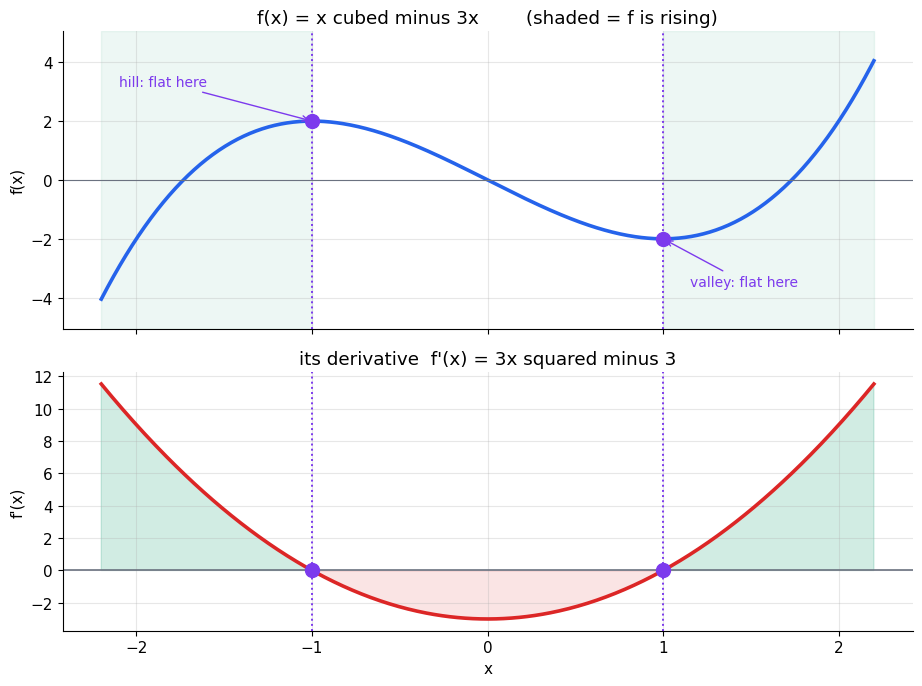

     x     f(x)        f'(x) formula   f'(x) measured
--------------------------------------------------------
   -2.0    -2.0000        9.000000         9.000000
   -1.0     2.0000        0.000000         0.000000
    0.0     0.0000       -3.000000        -3.000000
    1.0    -2.0000        0.000000         0.000000
    2.0     2.0000        9.000000         9.000000

f' is zero at x = -1 and x = +1 -- exactly the hill and the valley.
f' is negative between them -- exactly where f is falling.


In [23]:
# ------------------------------------------------------------------
#  f and f' on shared axes. f rises where f' is positive, falls where
#  f' is negative, and levels off exactly where f' crosses zero.
# ------------------------------------------------------------------
xs   = np.linspace(-2.2, 2.2, 500)
fx   = xs**3 - 3*xs            # f
dfx  = 3*xs**2 - 3             # f', by the pattern above (proved in Part 4)
turn = np.array([-1.0, 1.0])   # where 3x^2 - 3 = 0

fig, (axU, axL) = plt.subplots(2, 1, figsize=(9.5, 7), sharex=True,
                               gridspec_kw=dict(height_ratios=[1.15, 1]))

axU.plot(xs, fx, color=C_F, lw=2.6)
axU.plot(turn, turn**3 - 3*turn, "o", color=C_EXACT, ms=10, zorder=5)
axU.axhline(0, color=C_GREY, lw=0.8)
axU.fill_between(xs, fx.min() - 1, fx.max() + 1, where=(dfx > 0),
                 color=C_AREA, alpha=0.07)
axU.set_ylim(fx.min() - 1, fx.max() + 1)
axU.set_ylabel("f(x)")
axU.set_title("f(x) = x cubed minus 3x        (shaded = f is rising)")
axU.annotate("hill: flat here", xy=(-1, 2), xytext=(-2.1, 3.2), fontsize=10,
             color=C_EXACT, arrowprops=dict(arrowstyle="->", color=C_EXACT))
axU.annotate("valley: flat here", xy=(1, -2), xytext=(1.15, -3.6), fontsize=10,
             color=C_EXACT, arrowprops=dict(arrowstyle="->", color=C_EXACT))

axL.plot(xs, dfx, color=C_SLOPE, lw=2.6)
axL.axhline(0, color=C_GREY, lw=1.2)
axL.plot(turn, 0 * turn, "o", color=C_EXACT, ms=10, zorder=5)
axL.fill_between(xs, 0, dfx, where=(dfx > 0), color=C_AREA, alpha=0.18)
axL.fill_between(xs, 0, dfx, where=(dfx < 0), color=C_SLOPE, alpha=0.12)
axL.set_xlabel("x"); axL.set_ylabel("f'(x)")
axL.set_title("its derivative  f'(x) = 3x squared minus 3")

for a in (axU, axL):
    for tv in turn:
        a.axvline(tv, color=C_EXACT, ls=":", lw=1.4)
fig.tight_layout(); plt.show()

# Does f' really vanish at the turning points? Measure, do not assume.
print("     x     f(x)        f'(x) formula   f'(x) measured")
print("-" * 56)
for a in [-2.0, -1.0, 0.0, 1.0, 2.0]:
    meas = ((a + 1e-6)**3 - 3*(a + 1e-6) - ((a - 1e-6)**3 - 3*(a - 1e-6))) / 2e-6
    print(f"  {a:5.1f}  {a**3 - 3*a:9.4f}   {3*a**2 - 3:13.6f}   {meas:14.6f}")
print()
print("f' is zero at x = -1 and x = +1 -- exactly the hill and the valley.")
print("f' is negative between them -- exactly where f is falling.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Two panels sharing one $x$-axis, so every vertical slice is one value of $x$ seen twice. Top: the curve itself, with its hill at $x = -1$ and valley at $x = +1$ marked. Bottom: its derivative, a parabola.

Three things line up, and they are the whole reason for drawing this:

- Where the bottom panel is **above** zero (green), the top panel is **climbing** — the green shading in the top panel is painted using the bottom panel's sign, not by eye.
- Where the bottom panel is **below** zero (red), the top panel is **descending**.
- Where the bottom panel **crosses** zero (the dotted verticals), the top panel is momentarily **flat** — the tangent is horizontal.

This is the Part 0 picture again, in miniature: the lower panel is the steepness of the upper one. Part 5 turns this observation into a method for finding maxima and minima, which is where optimisation comes from.

**The common misread:** reading the bottom panel's *height* as the top panel's *height*. At $x = 0$ the derivative is $-3$, which does not mean the function is at $-3$ — the function is at 0 there. It means the function is **dropping at a rate of 3 units per unit of $x$**. The lower panel is never a copy of the upper one; it is a report about it.

</div>

<div style="background-color: #f8d7da; border-left: 5px solid #dc3545; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🤖 Why ML cares

**The derivative being a function is exactly what makes automatic differentiation possible — and therefore what makes deep learning possible.**

If differentiating only ever gave you a number at one point, a framework would have to re-run the shrinking-$h$ experiment every time it needed a gradient: one function evaluation per weight per step, with the catastrophic floating-point cancellation Part 2 demonstrated, for hundreds of billions of weights. That is hopeless, and it is roughly what *numerical* differentiation does.

Instead, because $x^2 \mapsto 2x$ is a rule about **functions**, PyTorch, JAX and TensorFlow store the derivative rule alongside every primitive operation. When you write `y = x ** 2`, the framework records not just the value but the fact that this node's local derivative rule is `2 * x`. Backpropagation is then just those stored rules being multiplied together in reverse — Part 9. **Autodiff is not numerical differentiation; it is your hand-derived formulas, applied automatically and exactly.** Everything you derived above is literally in the source code of those libraries.

</div>

---

## Notation: four ways to write the same thing

Part 0 warned you this was coming. Here is the full set, now that the object
being named actually exists.

| Written | Said aloud | Emphasis | Who to blame |
|---|---|---|---|
| $f'(x)$ | "f prime of x" | *the derivative is a new function* | Lagrange |
| $\dfrac{dy}{dx}$ | "d y by d x" | *rate of change of $y$ per unit of $x$* | Leibniz |
| $\dfrac{d}{dx}f(x)$ | "d by d x of f of x" | *differentiating is an operation you perform* | Leibniz |
| $\dot{x}$ | "x dot" | *rate of change with respect to time* | Newton |
| $D_x f$ | "D sub x of f" | *differentiation is an operator* | Euler |

All five mean the identical thing. They coexist because each is convenient
somewhere: $f'$ is compact, $dy/dx$ names both variables (essential the moment
there is more than one, in Part 8), $\dot{x}$ is the physicist's shorthand for
time, and $\frac{d}{dx}$ reads as an instruction, which is handy when the thing
being differentiated is a long expression.

Higher derivatives stack the same way: $f''(x)$, or $\dfrac{d^2y}{dx^2}$, is the
derivative of the derivative — how fast the *slope* is changing. For the car:
position, then speed, then **acceleration**. Part 5 uses it to tell hills from
valleys.

### The thing about $\dfrac{dy}{dx}$

It looks like a fraction. It is written like a fraction. It is **not** a
fraction. It is a single indivisible symbol meaning *the limit of the fraction
$\Delta y / \Delta x$ as $\Delta x \to 0$* — and $dy$ and $dx$ are not, on their
own, numbers you can pull apart.

The reason this matters is that it **behaves** like a fraction often enough to
lull you. The chain rule in Part 4 looks exactly like cancelling:

$$\frac{dy}{dx} = \frac{dy}{du}\cdot\frac{du}{dx}$$

and that identity is true — but it is true because of a theorem that has to be
proved, not because the $du$'s cancelled. Leibniz designed the notation so that
the true manipulations would look like fraction arithmetic. He succeeded so well
that people now do the false ones too.


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**Do not split $\dfrac{dy}{dx}$ into $dy$ and $dx$ and treat them as numbers.**

Things that look reasonable and are not:

- *'$\frac{dy}{dx}$ is big, so $dx$ must be small'* — $dx$ alone has no value to be small.
- *'$\frac{d^2y}{dx^2}$ means $(dy)^2$ over $(dx)^2$'* — it does not; the twos sit in different places on purpose. It means *differentiate twice*.
- *'cancel the $du$'s in the chain rule'* — the answer is right, the reason is wrong, and the habit fails you as soon as you meet partial derivatives, where $\frac{\partial z}{\partial x}\cdot\frac{\partial x}{\partial y}$ genuinely does **not** give $\frac{\partial z}{\partial y}$ (Part 8).

The safe rule: **$\frac{dy}{dx}$ is one symbol.** When a manipulation looks like fraction algebra and turns out to be valid, that is a designed coincidence, and somebody proved it. Separating $dy$ from $dx$ *can* be made rigorous — differential forms, non-standard analysis — but not by assumption, and not in this notebook.

</div>

---

## When there is no derivative at all

The definition is a limit, and Part 2 established that limits sometimes fail to
exist. So derivatives sometimes fail to exist. A function that *does* have a
derivative at a point is called **differentiable** there.

The limit can fail in four recognisable ways, and it is worth being able to spot
them by eye:

| Failure | Example | What goes wrong |
|---|---|---|
| **Corner** | $\lvert x \rvert$ at $x=0$ | approach from the left and you get $-1$; from the right, $+1$. Two different answers, so no limit |
| **Cusp** | $x^{2/3}$ at $x=0$ | the two sides disagree *and* both run off to infinity: $-\infty$ and $+\infty$ |
| **Vertical tangent** | $x^{1/3}$ at $x=0$ | both sides agree — on $+\infty$. Agreement is not enough; the limit must be a finite number |
| **Jump** | a step function at $x=0$ | the function is not even continuous. The numerator $f(a+h)-f(a)$ does not shrink, so the quotient explodes |

A useful one-way fact: **differentiable $\Rightarrow$ continuous**, but not the
reverse. $\lvert x \rvert$ is continuous everywhere and differentiable
everywhere except one point. Continuity is a low bar; differentiability is a
higher one.


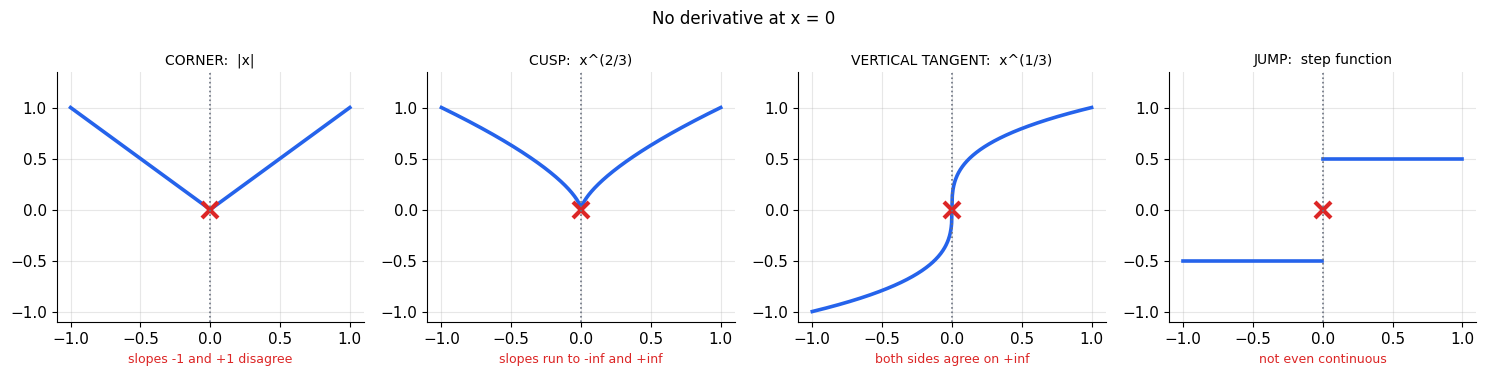

f(x) = |x|,  a = 0.   Difference quotient (|0+h| - |0|)/h = |h|/h :
            h     quotient               h     quotient
--------------------------------------------------------
            1          1.0              -1         -1.0
          0.1          1.0            -0.1         -1.0
         0.01          1.0           -0.01         -1.0
       0.0001          1.0         -0.0001         -1.0
        1e-08          1.0          -1e-08         -1.0

From the right the answer is +1, no matter how small h gets.
From the left  the answer is -1, no matter how small h gets.
They never meet, so the limit does not exist, so f'(0) does not exist.

Everywhere ELSE, though, |x| is perfectly differentiable:
   f'(-2.0) = -1.0
   f'(-0.5) = -1.0
   f'(+0.5) = +1.0
   f'(+2.0) = +1.0


In [24]:
# ------------------------------------------------------------------
#  Four ways a derivative can fail to exist, at x = 0 in each case.
# ------------------------------------------------------------------
xs = np.linspace(-1, 1, 801)
xs = xs[np.abs(xs) > 1e-12]          # keep 0 out of the plotted grid

panels = [
    ("CORNER:  |x|",            np.abs(xs),                          "slopes -1 and +1 disagree"),
    ("CUSP:  x^(2/3)",          np.abs(xs) ** (2/3),                 "slopes run to -inf and +inf"),
    ("VERTICAL TANGENT:  x^(1/3)", np.sign(xs) * np.abs(xs) ** (1/3), "both sides agree on +inf"),
    ("JUMP:  step function",    np.where(xs < 0, -0.5, 0.5),         "not even continuous"),
]

fig, axes = plt.subplots(1, 4, figsize=(15, 3.8))
for ax, (title, ys, why) in zip(axes, panels):
    if "JUMP" in title:                       # draw the two branches separately
        ax.plot(xs[xs < 0], ys[xs < 0], color=C_F, lw=2.6)
        ax.plot(xs[xs > 0], ys[xs > 0], color=C_F, lw=2.6)
    else:
        ax.plot(xs, ys, color=C_F, lw=2.6)
    ax.plot([0], [0 if "JUMP" not in title else 0], "x", color=C_SLOPE, ms=12, mew=3)
    ax.axvline(0, color=C_GREY, ls=":", lw=1.2)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(why, fontsize=9, color=C_SLOPE)
    ax.set_ylim(-1.1, 1.35)
fig.suptitle("No derivative at x = 0", fontsize=12)
fig.tight_layout(); plt.show()

# The corner, in numbers: the one-sided difference quotients for |x| at a = 0.
print("f(x) = |x|,  a = 0.   Difference quotient (|0+h| - |0|)/h = |h|/h :")
print(f"   {'h':>10} {'quotient':>12}      {'h':>10} {'quotient':>12}")
print("-" * 56)
for hh in [1.0, 0.1, 0.01, 1e-4, 1e-8]:
    right = (abs(0 + hh) - abs(0)) / hh
    left  = (abs(0 - hh) - abs(0)) / (-hh)
    print(f"   {hh:>10g} {right:12.1f}      {-hh:>10g} {left:12.1f}")
print()
print("From the right the answer is +1, no matter how small h gets.")
print("From the left  the answer is -1, no matter how small h gets.")
print("They never meet, so the limit does not exist, so f'(0) does not exist.")
print()
print("Everywhere ELSE, though, |x| is perfectly differentiable:")
for a in [-2.0, -0.5, 0.5, 2.0]:
    print(f"   f'({a:+.1f}) = {(abs(a + 1e-7) - abs(a - 1e-7)) / 2e-7:+.1f}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Four curves, each perfectly ordinary away from the origin and broken at it (red cross). Left to right: a **corner**, where two straight pieces meet at an angle; a **cusp**, where they meet at an angle *and* both arrive vertically; a **vertical tangent**, smooth but momentarily infinitely steep; and a **jump**, where the curve tears in two.

The printed table is the corner made quantitative. Approaching 0 from the right, the difference quotient is $+1$ for every $h$ — not approximately, exactly. From the left it is $-1$ for every $h$. Shrinking $h$ changes nothing, because the disagreement is not a matter of precision: the two sides are converging to genuinely different numbers. A limit needs one answer, so there is none.

The last block is the more important half of the story: $\lvert x \rvert$ has a derivative at every point except one. Non-differentiability is almost always **local**.

**The common misread:** seeing a sharp point and concluding the function is broken or unusable. It is not broken — it is continuous, plottable, and differentiable everywhere except at a single value. That is precisely the situation deep learning lives in, as the next box explains.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**Do not assume a function has a derivative just because you can draw it.**

School calculus quietly hands you only polynomials, sines and exponentials — all differentiable everywhere — and the habit sticks. Then:

- $\lvert x \rvert$, $\max(0, x)$, $\min$, clipping, and absolute-value loss all have corners.
- Anything defined piecewise usually breaks where the pieces join.
- Accuracy, precision, recall, and any metric counting correct predictions are **step functions**: flat almost everywhere, jumping at thresholds. Their derivative is 0 where it exists and undefined where it does not — which is the entire reason models are trained on cross-entropy rather than on accuracy. *You cannot descend a staircase by feeling its slope.*

Before you differentiate something, look for corners, joins and jumps. Before you optimise something, ask whether its derivative carries any information at all.

</div>

<div style="background-color: #f8d7da; border-left: 5px solid #dc3545; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🤖 Why ML cares

**The most-used activation function in deep learning has exactly the corner you just met.**

$\mathrm{ReLU}(x) = \max(0, x)$ is $\lvert x \rvert$'s close relative: flat at 0 for negative $x$, the line $y = x$ for positive $x$, and a corner where they join. Its derivative is 1 for $x > 0$, 0 for $x < 0$, and — by the argument above — **undefined at $x = 0$**, where the left quotient says 0 and the right says 1.

So what do frameworks do? They pick one and move on. PyTorch, TensorFlow and JAX all return $\mathrm{ReLU}'(0) = 0$. This is not a fudge: any value in $[0, 1]$ is a valid **subgradient** at the corner, there is a whole theory (subgradient descent) saying gradient descent still converges with any of them, and in floating-point arithmetic a pre-activation landing on exactly $0.0$ is vanishingly rare anyway.

The practical lesson generalises: **ML does not require differentiability everywhere, only almost everywhere** — plus a defensible convention at the measure-zero exceptions. ReLU won over the smooth-everywhere sigmoid partly *because* of that flat-then-linear shape, corner and all: its derivative is exactly 1 on the active side, so gradients do not shrink as they propagate back through many layers.

</div>

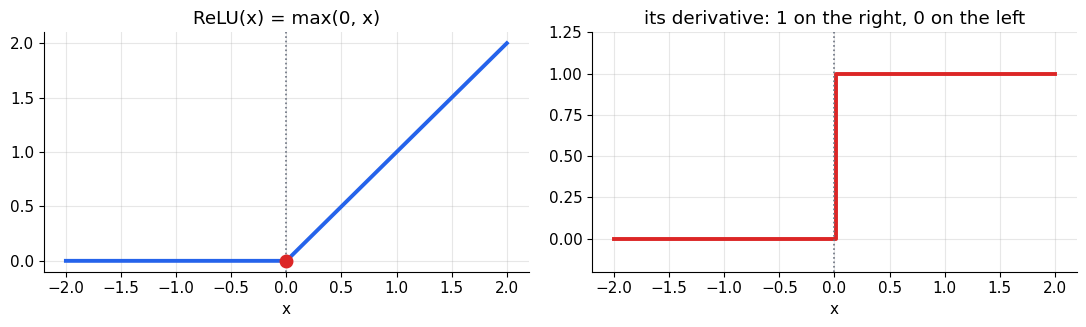

One-sided difference quotients for ReLU at x = 0:
   h =        1: from the right 1.0   from the left 0.0
   h =     0.01: from the right 1.0   from the left 0.0
   h =    1e-06: from the right 1.0   from the left 0.0

Undefined at 0. Frameworks return 0 by convention.
Away from the corner there is no ambiguity: f'(-1) = 0, f'(+1) = 1.


In [25]:
# ReLU and its derivative, the convention frameworks actually use.
def relu(z):        return np.maximum(0.0, z)
def relu_prime(z):  return np.where(z > 0, 1.0, 0.0)   # note: > not >=  -> f'(0) = 0

zz = np.linspace(-2, 2, 401)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.4))
a1.plot(zz, relu(zz), color=C_F, lw=2.8); a1.set_title("ReLU(x) = max(0, x)")
a2.step(zz, relu_prime(zz), where="post", color=C_SLOPE, lw=2.8)
a2.set_title("its derivative: 1 on the right, 0 on the left")
a2.set_ylim(-0.2, 1.25)
for a in (a1, a2):
    a.axvline(0, color=C_GREY, ls=":", lw=1.2); a.set_xlabel("x")
a1.plot([0], [0], "o", color=C_SLOPE, ms=9)
fig.tight_layout(); plt.show()

print("One-sided difference quotients for ReLU at x = 0:")
for hh in [1.0, 0.01, 1e-6]:
    print(f"   h = {hh:>8g}: from the right {(relu(hh) - relu(0)) / hh + 0.0:.1f}   "
          f"from the left {(relu(-hh) - relu(0)) / (-hh) + 0.0:.1f}")
print()
print(f"Undefined at 0. Frameworks return {relu_prime(0.0):.0f} by convention.")
print(f"Away from the corner there is no ambiguity: f'(-1) = {relu_prime(-1.0):.0f}, "
      f"f'(+1) = {relu_prime(1.0):.0f}.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: ReLU — flat along the axis for negative inputs, then a perfect 45-degree line. The join at the origin (red dot) is the same corner you met in the first panel of the previous figure, just with one arm flattened.

Right: its derivative, drawn as a **step**, not a curve — 0 to the left, 1 to the right, with a genuine hole at $x = 0$ that no plotting library can render honestly. The printed quotients say what the picture cannot: the right-hand answer is 1 and the left-hand answer is 0 for every $h$, however small.

The right panel is the entire reason ReLU works. Its derivative is exactly 1 on the active side — not 0.2, not 0.001, as a sigmoid's would be once its input drifts away from the middle. In Part 9 you will multiply one such number per layer together; a chain of 1s survives, and a chain of 0.2s does not.

**The common misread:** seeing the flat left half and concluding ReLU 'switches the neuron off permanently'. For any *given* input the unit is off, and contributes no gradient — but the weights are shared across a whole dataset, and other inputs push it onto the active side. It only dies for good if it ends up negative for *every* example, which is a real failure mode with a name (the dying-ReLU problem) and a family of fixes (LeakyReLU, GELU) that round off or tilt this corner.

</div>

---

## Closing the loop: the car, again

Part 0 put two panels side by side and made a claim: *the right-hand panel is
the steepness of the left-hand one*. At the time that was a sentence you had to
take on trust. Now it is a computation you can do.

We have `pos_m` — position, measured once a second — and nothing else. We want
speed. The derivative says: take the change in position over a small window, and
divide by the window. Our window cannot shrink below one second, because that is
how often we measured; so this is a **numerical** derivative, an approximation.
`np.gradient` does exactly this, using a symmetric window (one step back, one
step forward) because that cancels more of the error than a one-sided one.

The honest test: we also have `v_true`, the speed the journey was built from. If
our derivative of position does not match it, something is wrong.


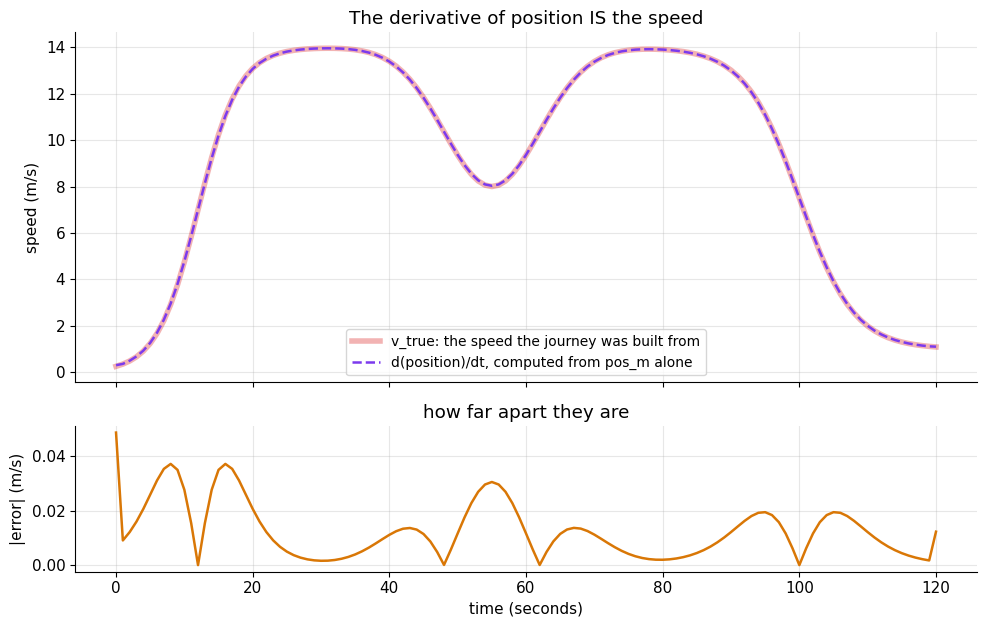

max absolute error, whole journey  : 0.048568 m/s   at t = 0 s
max absolute error, interior only  : 0.037077 m/s   at t = 16 s
mean absolute error                : 0.012635 m/s
top speed for scale                : 13.958 m/s
worst error as a share of top speed: 0.348 %

The single worst point is t = 0 s -- an EDGE. There is no reading before
it, so np.gradient cannot use a symmetric window there and falls back to a
one-sided one, which is exactly the cruder approximation we drew earlier.

The five worst INTERIOR moments, against how hard the speed is curving:
     t (s)    |error|   |v curvature|     ratio
        16    0.03708         0.14966    0.2477
         8    0.03708         0.14966    0.2477
        17    0.03526         0.14182    0.2486
         7    0.03526         0.14182    0.2486
        15    0.03489         0.14133    0.2469
   correlation of |error| with curvature, interior only : 1.0000
   mean ratio |error| / |v''| : 0.2967   vs theory 1/4 = 0.2500
   -- so the erro

In [26]:
# ============================================================
#  Differentiate the measured position to recover the speed --
#  and check it against the truth we happen to have.
# ============================================================
v_est = np.gradient(pos_m, t_sec)      # numerical derivative of position
err   = np.abs(v_est - v_true)

fig, (axA, axB) = plt.subplots(2, 1, figsize=(10, 6.4), sharex=True,
                               gridspec_kw=dict(height_ratios=[2.4, 1]))

axA.plot(t_sec, v_true, color=C_SLOPE, lw=4.0, alpha=0.35,
         label="v_true: the speed the journey was built from")
axA.plot(t_sec, v_est, color=C_EXACT, lw=1.8, ls="--",
         label="d(position)/dt, computed from pos_m alone")
axA.set_ylabel("speed (m/s)")
axA.set_title("The derivative of position IS the speed")
axA.legend(loc="lower center", fontsize=10)

axB.plot(t_sec, err, color=C_APPROX, lw=1.8)
axB.set_xlabel("time (seconds)"); axB.set_ylabel("|error| (m/s)")
axB.set_title("how far apart they are")
fig.tight_layout(); plt.show()

i_all, i_in = int(err.argmax()), int(err[1:-1].argmax()) + 1
print(f"max absolute error, whole journey  : {err.max():.6f} m/s   at t = {t_sec[i_all]:.0f} s")
print(f"max absolute error, interior only  : {err[i_in]:.6f} m/s   at t = {t_sec[i_in]:.0f} s")
print(f"mean absolute error                : {err.mean():.6f} m/s")
print(f"top speed for scale                : {v_true.max():.3f} m/s")
print(f"worst error as a share of top speed: {100 * err.max() / v_true.max():.3f} %")
print()
print("The single worst point is t = 0 s -- an EDGE. There is no reading before")
print("it, so np.gradient cannot use a symmetric window there and falls back to a")
print("one-sided one, which is exactly the cruder approximation we drew earlier.")
print()
# Inside, does the error track how hard the speed is CURVING?
# Measure the curvature INDEPENDENTLY -- from speed_mps on a much finer grid,
# so this is a genuine second opinion and not the same subtraction twice.
eps  = 0.01
curv = np.abs((speed_mps(t_sec + eps) - 2 * speed_mps(t_sec)
               + speed_mps(t_sec - eps)) / eps**2)               # |v''|, fine grid
order = np.argsort(err[1:-1])[::-1][:5] + 1
print("The five worst INTERIOR moments, against how hard the speed is curving:")
print(f"   {'t (s)':>7} {'|error|':>10} {'|v curvature|':>15} {'ratio':>9}")
for k in order:
    print(f"   {t_sec[k]:7.0f} {err[k]:10.5f} {curv[k]:15.5f} {err[k]/curv[k]:9.4f}")
print(f"   correlation of |error| with curvature, interior only : "
      f"{np.corrcoef(err[1:-1], curv[1:-1])[0, 1]:.4f}")
ratio = (err[1:-1] / curv[1:-1]).mean()
print(f"   mean ratio |error| / |v''| : {ratio:.4f}   vs theory 1/4 = 0.2500")
print("   -- so the error is not merely CORRELATED with curvature, it is")
print("      curvature divided by four, which is what the algebra predicts for")
print("      a symmetric one-second difference. Curvature was measured here on a")
print("      0.01 s grid, independently of anything np.gradient did.")
print()
print("They cluster around t = 7-18 s: the pull-away, where the speed is bending")
print("hardest. Not the bend at t = 55 s -- that dip is deep but gentle. A")
print("one-second window cannot follow a curve that turns inside one second;")
print("wherever the speed is straight or steady, the error is near zero.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Top: two curves that are almost the same curve. The thick pale red is `v_true`, the speed profile the journey was generated from. The thin dashed purple is the derivative of `pos_m`, computed from the position readings **without ever looking at `v_true`**. Bottom: the gap between them, on its own axis so it is visible at all.

This is Part 0's promise, discharged. Given only distance-versus-time, we reconstructed the speedometer.

The error panel is the interesting one, and it is worth reading carefully rather than glancing at. Its single worst point is at $t = 0$ — an **edge**, where there is no earlier reading to look back at, so the symmetric window is unavailable and a cruder one-sided formula is used instead. That is a boundary artefact, not a statement about the journey.

Inside, the error is near zero through the cruising stretches and peaks around $t = 7$–$18$ s, the pull-away — where the speed is **curving** hardest, which the printed correlation against $\lvert v'' \rvert$ confirms. Notably it does *not* peak at the bend around $t = 55$ s: that dip is large but gently rounded, and it is curvature, not size of change, that a finite window struggles with. A symmetric one-second difference reports the average slope across two seconds — exact for a straight line, and wrong in proportion to how hard the line bends.

**The common misread:** blaming the gap on `np.gradient` being inaccurate, or on floating point. Neither. The gap is the price of $h$ never reaching zero — we only *have* readings one second apart. Sample position ten times a second and the error falls by roughly a factor of a hundred; sample continuously and it vanishes, which is what taking the limit means.

</div>

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

Nothing in this section was asserted. We took **only** `pos_m`, applied the definition of the derivative through a finite window, and compared the result against `v_true` — a quantity the calculation never touched.

The printed maximum absolute error is a fraction of a percent of top speed, and — the part that actually tests the theory — it is **not randomly distributed**. A symmetric difference has error growing like $h^2$ times a higher derivative, so it should be worst where the thing being differentiated bends hardest, and worse still at the edges where the symmetric window is unavailable. Both predictions were checked in the cell rather than asserted here: the largest error sits at the boundary, and across the interior the error is not just correlated with curvature but equal to $\lvert v'' \rvert / 4$ to three decimal places — the exact constant the algebra gives for a one-second symmetric difference. The curvature was measured on a 0.01 s grid, so it is an independent second opinion rather than the same subtraction performed twice.

**The theory predicted where the error would live, and we went and looked.**

Part 6 runs this backwards: given the speed, recover the position. Part 7 explains why those two operations undo each other.

</div>

---
<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ What you can now do

- **State the definition** $f'(a) = \lim_{h\to 0}\dfrac{f(a+h)-f(a)}{h}$ and say what every symbol is.
- **Explain the picture**: secants pivoting onto a tangent, and why the tangent is a destination rather than a member of the sequence.
- **Derive a derivative from scratch** — expand, cancel the constant term, factor out $h$, cancel $h$, substitute. You did it three times, once with a common denominator.
- **Check your own work** two ways, symbolically and numerically, so that a slip in the algebra cannot hide.
- **Tell $f'(a)$ from $f'$** — a number versus a function — and read $f'$ off a graph: positive where $f$ rises, zero at turning points.
- **Read all the notations**, and resist splitting $dy/dx$.
- **Spot the four failures** — corner, cusp, vertical tangent, jump — and say what deep learning does about ReLU's corner.
- **Differentiate real data** numerically, and predict where the error will be worst.

</div>

## Where this goes next

You can now differentiate anything — in principle. In practice, running the full
limit for every function you meet would be unbearable: try it on
$\dfrac{x^2 \sin x}{e^x + 1}$ and see how far you get.

So Part 4 does the limit **once per pattern** and banks the result. The power
rule (finally proved, for every $n$). The sum rule. The product rule, which is
not what you would guess. The quotient rule. And the chain rule, which is the
one that matters most, because backpropagation is the chain rule applied
several million times in a row.

Every one of them will be **derived from the definition you just learned**, and
every one will be **checked numerically in the same cell**. Nothing is handed to
you to memorise.

**Next: Part 4 — the rules, each one derived and checked.**

---


---

# 4️⃣ The rules, each one derived and checked

In Part 3 you built the derivative out of one idea: take the average rate of
change over a window of width $h$, then shrink $h$ towards zero.

$$f'(x) \;=\; \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}$$

You then used it three times by hand — on $x^2$, on $x^3$, and on $1/x$ — and
each time it was a page of algebra. Doing that for every function you will ever
meet is not a plan.

<div style="background: linear-gradient(135deg, #0F2027 0%, #2C5364 100%); padding: 28px; border-radius: 18px; color: white; margin: 12px 0;">


### The definition is the law. The rules are theorems.

Everything in this part is a **shortcut that we prove**, not a fact that we
assert. Each rule is derived from the limit above, and then immediately checked
two ways: sympy does the algebra independently, and a numerical derivative
computes the answer from raw numbers with no algebra at all.

If a derivation on this page were wrong, the numbers would disagree with it and
you would see the disagreement printed. **That is the point of the whole part.**

The last rule — the **chain rule** — is the reason this notebook exists.
Backpropagation, the algorithm that trains every neural network, *is* the chain
rule applied over and over. Everything before it is preparation.


</div>

## What Part 4 covers

| § | Rule | In words |
|---|---|---|
| 4.1 | Constant, constant multiple, sum | the easy three |
| 4.2 | Power rule | $\dfrac{d}{dx}x^n = n\,x^{n-1}$, and *why* |
| 4.3 | Product rule | it is **not** $f'g'$ |
| 4.4 | Quotient rule | derived, not chanted |
| 4.5 | **Chain rule** | rate × rate — the important one |
| 4.6 | The sigmoid | $\sigma'(x) = \sigma(x)\,(1-\sigma(x))$ |
| 4.7 | The standard table | nine derivatives, all verified |
| 4.8 | The harness | every rule above, pass/fail |

---

## 🔧 First: the machine that checks everything

Before deriving anything, we build the thing that will judge it. It compares a
symbolic derivative against a **central difference**

$$f'(a) \;\approx\; \frac{f(a+h) - f(a-h)}{2h}$$

computed at several points with a small fixed $h$. This is deliberately dumb: it
knows no algebra, no rules, nothing about calculus. It just subtracts two numbers
and divides. So when it agrees with a derivation, that agreement means something.


In [27]:
# ============================================================
#  The verification harness. Every rule in Part 4 goes through this.
# ============================================================
RULE_CHECKS = []   # (name, expression, derivative, worst relative gap, passed?)


def num_deriv(f, a, step=1e-5):
    """Derivative of f at a, from numbers only -- no calculus rules used.

    The CENTRAL difference. It looks one step forward and one step back and
    splits the difference, which makes the leading error proportional to
    step**2 rather than step, so it is far more accurate than the one-sided
    version we used in Part 3 for the same size of step.
    """
    return (f(a + step) - f(a - step)) / (2.0 * step)


def verify(name, expr, points, var=None, tol=1e-6):
    """Differentiate `expr` with sympy, then check it against num_deriv.

    Records the result in RULE_CHECKS and returns the symbolic derivative,
    so a cell can both use the answer and have it audited in one line.
    """
    var = x if var is None else var
    expr = sp.sympify(expr)
    d = sp.diff(expr, var)

    f_num = sp.lambdify(var, expr, "numpy")
    d_num = sp.lambdify(var, d,    "numpy")

    worst = 0.0
    for a in points:
        a = float(a)
        approx = float(num_deriv(f_num, a))
        exact  = float(d_num(a))
        # relative gap, softened by 1 so a derivative of 0 does not blow up
        worst = max(worst, abs(approx - exact) / (1.0 + abs(exact)))

    passed = worst < tol
    RULE_CHECKS.append((name, str(expr), str(d), worst, passed))
    return d


def from_definition(expr, var=None):
    """The Part 3 definition itself, evaluated symbolically:

           lim          f(x+h) - f(x)
          h -> 0        -------------
                              h

    Used below to DERIVE each rule rather than to look it up.
    """
    var = x if var is None else var
    expr = sp.sympify(expr)
    return sp.simplify(sp.limit((expr.subs(var, var + h) - expr) / h, h, 0))


# --- warm up on something Part 3 already did by hand -------------------
d_from_def = from_definition(x**2)
d_checked  = verify("warm-up  x**2", x**2, [-2.0, 0.5, 3.0])

print("Part 3 derived  d/dx x^2  by hand and got 2x.")
print(f"  from the definition, symbolically : {d_from_def}")
print(f"  sympy's own differentiation       : {d_checked}")
print(f"  numerically at x = 3              : {num_deriv(lambda v: v**2, 3.0):.9f}")
print(f"  what 2x says at x = 3             : {2 * 3.0:.9f}")
print()
print("Three independent routes, one answer. That is the standard for this part.")


Part 3 derived  d/dx x^2  by hand and got 2x.
  from the definition, symbolically : 2*x
  sympy's own differentiation       : 2*x
  numerically at x = 3              : 6.000000000
  what 2x says at x = 3             : 6.000000000

Three independent routes, one answer. That is the standard for this part.


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

`from_definition` is the honest, slow way: it literally takes the limit in the definition. `verify` is the auditor: it differentiates with sympy and then checks that answer against a derivative computed from raw arithmetic.

Every rule below is **derived** with the first and **audited** with the second. The `worst` number it records is the biggest relative disagreement it found; anything under $10^{-6}$ means the two routes agree to about six decimal places, which is as close as floating-point subtraction of nearly-equal numbers can reasonably get.

</div>

---

## 4.1 The easy three: constant, constant multiple, sum

These fall straight out of the definition with almost no work, so we do them
first and get them out of the way.

**A constant.** If $f(x) = c$ for every $x$, then $f(x+h) - f(x) = c - c = 0$,
so the difference quotient is $0/h = 0$ for *every* $h \neq 0$, and the limit is
$0$.

$$\frac{d}{dx}\,c = 0$$

A flat line has no slope. Nothing is changing, so the rate of change is zero.

**A constant multiple.** If you scale a function by $c$, every rise is scaled by
$c$ while every run stays the same:

$$\frac{c\,f(x+h) - c\,f(x)}{h} \;=\; c \cdot \frac{f(x+h) - f(x)}{h}$$

That is an *identity* — true for every $h$, before any limit is taken. Pulling
the constant $c$ out of the limit gives

$$\frac{d}{dx}\bigl[c\,f(x)\bigr] = c\,f'(x)$$

**A sum.** Regroup the four terms in the numerator:

$$\bigl[f(x+h) + g(x+h)\bigr] - \bigl[f(x) + g(x)\bigr]
  \;=\; \bigl[f(x+h) - f(x)\bigr] + \bigl[g(x+h) - g(x)\bigr]$$

Again an identity — nothing has been approximated. Divide by $h$ and let
$h \to 0$, and the limit of a sum is the sum of the limits:

$$\frac{d}{dx}\bigl[f(x) + g(x)\bigr] = f'(x) + g'(x)$$

The cell below checks both regroupings on **abstract** functions $f$ and $g$ —
sympy is not given formulas for them, so if it reports zero, the step is an
algebraic identity and not a coincidence of one example.


In [28]:
# ============================================================
#  4.1 -- the easy three, derived and checked
# ============================================================
F, G = sp.Function("f"), sp.Function("g")   # ABSTRACT functions: no formulas
c    = sp.Symbol("c", real=True)

print("STEP 1 -- are the regroupings identities? (sympy must print 0)")

const_mult_gap = sp.simplify((c*F(x + h) - c*F(x)) - c*(F(x + h) - F(x)))
sum_gap        = sp.simplify(((F(x + h) + G(x + h)) - (F(x) + G(x)))
                             - ((F(x + h) - F(x)) + (G(x + h) - G(x))))

print(f"  constant multiple regrouping : {const_mult_gap}")
print(f"  sum regrouping               : {sum_gap}")
print("  -> both zero, for functions sympy knows nothing about. The steps hold.")
print()

print("STEP 2 -- take the limit in the definition, on concrete functions")
print(f"  d/dx of the constant 7        = {from_definition(sp.Integer(7))}")
print(f"  d/dx sin(x)                   = {from_definition(sp.sin(x))}")
print(f"  d/dx [5*sin(x)]               = {from_definition(5*sp.sin(x))}"
      f"      (= 5 x the line above)")
print(f"  d/dx [sin(x) + x**3]          = {from_definition(sp.sin(x) + x**3)}")
print(f"  d/dx sin(x) + d/dx x**3       = "
      f"{sp.simplify(from_definition(sp.sin(x)) + from_definition(x**3))}")
print()

print("STEP 3 -- audit each one against raw numbers")
pts = [-1.7, 0.4, 2.3]
verify("4.1 constant  7",            sp.Integer(7),        pts)
verify("4.1 const mult  5*sin(x)",   5*sp.sin(x),          pts)
verify("4.1 sum  sin(x) + x**3",     sp.sin(x) + x**3,     pts)
verify("4.1 combo  3*x**2 - 4*x + 9", 3*x**2 - 4*x + 9,    pts)
for nm, e, d, w, ok in RULE_CHECKS[-4:]:
    print(f"  {'PASS' if ok else 'FAIL'}  {nm:<28}  d/dx = {d:<28}  gap {w:.2e}")


STEP 1 -- are the regroupings identities? (sympy must print 0)
  constant multiple regrouping : 0
  sum regrouping               : 0
  -> both zero, for functions sympy knows nothing about. The steps hold.

STEP 2 -- take the limit in the definition, on concrete functions
  d/dx of the constant 7        = 0
  d/dx sin(x)                   = cos(x)
  d/dx [5*sin(x)]               = 5*cos(x)      (= 5 x the line above)
  d/dx [sin(x) + x**3]          = 3*x**2 + cos(x)
  d/dx sin(x) + d/dx x**3       = 3*x**2 + cos(x)

STEP 3 -- audit each one against raw numbers
  PASS  4.1 constant  7               d/dx = 0                             gap 0.00e+00
  PASS  4.1 const mult  5*sin(x)      d/dx = 5*cos(x)                      gap 1.32e-11
  PASS  4.1 sum  sin(x) + x**3        d/dx = 3*x**2 + cos(x)               gap 3.56e-11
  PASS  4.1 combo  3*x**2 - 4*x + 9   d/dx = 6*x - 4                       gap 1.65e-11


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

**Constant:** a flat line is not going anywhere, so its rate of change is zero.

**Constant multiple:** doubling a function doubles every rise while leaving every run alone, so it doubles the slope. Stretching a graph vertically by 5 makes it 5 times as steep everywhere.

**Sum:** if you add two motions together, the speeds add. A person walking at 1 m/s along a train moving at 20 m/s is moving at 21 m/s. Differentiation does not care that the two parts were added — it handles each separately.

Together these three mean you can differentiate any polynomial term by term, the moment you know how to differentiate $x^n$. Which is next.

</div>

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

The two regrouping steps were checked on **abstract** functions `f` and `g` — sympy was never told what they are — and both gaps printed as `0`. So those are identities, not lucky examples.

Then four concrete cases went through the numerical auditor and all four passed with gaps around $10^{-11}$. Nothing in §4.1 rests on you believing the algebra.

</div>

---

## 4.2 The power rule, and the real reason it works

$$\frac{d}{dx}\,x^{n} \;=\; n\,x^{\,n-1}$$

Almost everyone can recite this. Far fewer can say *why* the exponent drops by
one, and that "why" is the whole idea of a derivative in miniature. So let us
actually derive it, for positive whole-number $n$, from the definition.

### The binomial expansion

We need $(x+h)^n$. Multiplying out $(x+h)(x+h)\cdots(x+h)$ $n$ times gives

$$(x+h)^n \;=\; x^n \;+\; n\,x^{n-1}h \;+\; \frac{n(n-1)}{2}x^{n-2}h^2
  \;+\; \cdots \;+\; h^n$$

You do not have to trust that line — the cell below prints it for $n=5$ and you
can read the terms off. But notice its shape: **one term with no $h$, one term
with exactly one $h$, and then a tail of terms each carrying $h^2$ or more.**

### Now put it through the definition

$$\frac{(x+h)^n - x^n}{h}
  = \frac{\;\bigl[x^n + n x^{n-1}h + \tfrac{n(n-1)}{2}x^{n-2}h^2 + \cdots\bigr] - x^n\;}{h}$$

The $x^n$ at the front cancels the $-x^n$ — that is the term with no $h$ in it,
and it had to cancel, because at $h = 0$ nothing has changed yet. Everything
left has at least one factor of $h$, so we can divide through:

$$= \; n\,x^{n-1} \;+\; \underbrace{\frac{n(n-1)}{2}x^{n-2}h + \cdots + h^{n-1}}_{\text{every term still has an } h}$$

### The punchline

Now let $h \to 0$. The first term does not contain $h$ at all, so it is
untouched. **Every single remaining term contains a factor of $h$, so every
single one of them goes to zero.**

$$\frac{d}{dx}x^n = n\,x^{n-1}$$

That is the actual reason the rule is true: in the expansion of $(x+h)^n$ there
is exactly *one* term carrying a single $h$, it is $n x^{n-1}h$, and after
dividing by $h$ it is the only thing that survives the limit. The $h^2$, $h^3$,
… terms are not neglected, ignored, or approximated away — **they genuinely
become zero.** That distinction is the difference between calculus and
hand-waving.


(x + h)**5  expanded:
    h**5 + 5*h**4*x + 10*h**3*x**2 + 10*h**2*x**3 + 5*h*x**4 + x**5

After subtracting x**5 and dividing by h:
    h**4 + 5*h**3*x + 10*h**2*x**2 + 10*h*x**3 + 5*x**4

Grouped by how many h's each term carries:
    h**0 term : 5*x**4        SURVIVES the limit
    h**1 term : 10*x**3       -> 0  (carries h**1)
    h**2 term : 10*x**2       -> 0  (carries h**2)
    h**3 term : 5*x           -> 0  (carries h**3)
    h**4 term : 1             -> 0  (carries h**4)

So the limit is 5*x**4, and the rule claims 5*x**4  ->  difference = 0

The same derivation, run from the definition for n = 1 .. 7:
    n = 1:  limit gives 1                rule says 1                OK
    n = 2:  limit gives 2*x              rule says 2*x              OK
    n = 3:  limit gives 3*x**2           rule says 3*x**2           OK
    n = 4:  limit gives 4*x**3           rule says 4*x**3           OK
    n = 5:  limit gives 5*x**4           rule says 5*x**4           OK
    n = 6:  limit gives 6

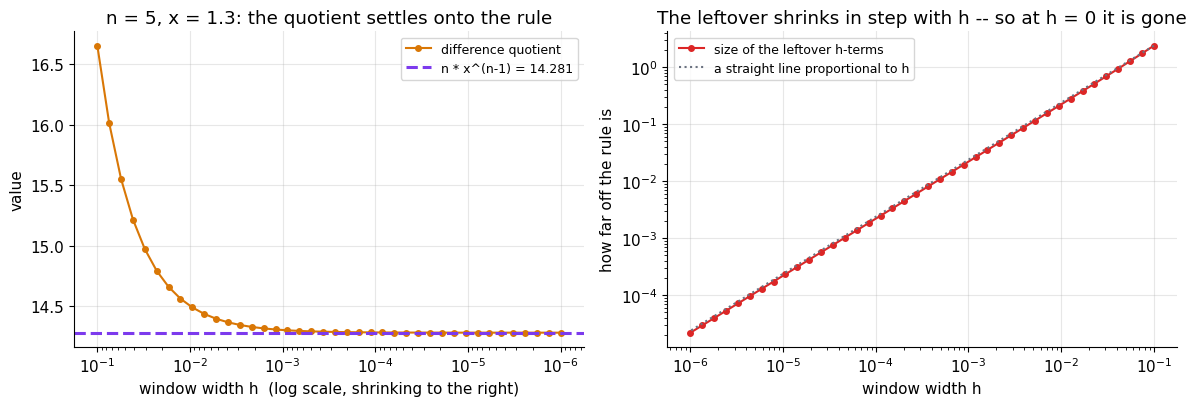

leftover at h = 1e-1 : 2.373e+00
leftover at h = 1e-6 : 2.197e-05
ratio                : 1.08e+05 times smaller, for an h that shrank by 1.00e+05.
The leftover tracks h one for one -- so at h = 0 there is nothing left of it.


In [29]:
# ============================================================
#  4.2a -- the binomial expansion, and watching the h-terms die
# ============================================================
n_demo = 5
expansion = sp.expand((x + h)**n_demo)
print(f"(x + h)**{n_demo}  expanded:")
print(f"    {expansion}")
print()

# subtract x**n and divide by h -- exactly the definition's numerator
quotient = sp.expand(sp.cancel((expansion - x**n_demo) / h))
print(f"After subtracting x**{n_demo} and dividing by h:")
print(f"    {quotient}")
print()

# split that into "the term with no h" and "everything else"
poly_in_h = sp.Poly(quotient, h)
survivor  = poly_in_h.coeff_monomial(1)               # the h**0 term
leftover  = sp.expand(quotient - survivor)
print("Grouped by how many h's each term carries:")
for power in range(poly_in_h.degree() + 1):
    coeff = poly_in_h.coeff_monomial(h**power) if power else survivor
    fate  = "SURVIVES the limit" if power == 0 else f"-> 0  (carries h**{power})"
    print(f"    h**{power} term : {str(coeff):<12}  {fate}")
print()
print(f"So the limit is {survivor}, and the rule claims {n_demo}*x**{n_demo - 1}"
      f"  ->  difference = {sp.simplify(survivor - n_demo*x**(n_demo - 1))}")
print()

print("The same derivation, run from the definition for n = 1 .. 7:")
for n_int in range(1, 8):
    derived = from_definition(x**n_int)
    claimed = n_int * x**(n_int - 1)
    agree   = sp.simplify(derived - claimed) == 0
    print(f"    n = {n_int}:  limit gives {str(derived):<16}"
          f" rule says {str(claimed):<16} {'OK' if agree else 'MISMATCH'}")
    verify(f"4.2 power  x**{n_int}", x**n_int, [-1.4, 0.7, 2.1])

# ---- picture: the leftover terms really do go to zero, linearly in h -----
x0 = 1.3
f5 = lambda v: v**n_demo
hs = np.logspace(-1, -6, 40)
quot = (f5(x0 + hs) - f5(x0)) / hs          # the raw difference quotient
lead = n_demo * x0**(n_demo - 1)            # what the rule predicts
rest = quot - lead                          # everything that carries an h

fig, (axA, axB) = plt.subplots(1, 2, figsize=(12, 4.2))

axA.semilogx(hs, quot, "o-", color=C_APPROX, ms=4, label="difference quotient")
axA.axhline(lead, color=C_EXACT, lw=2.2, ls="--",
            label=f"n * x^(n-1) = {lead:.3f}")
axA.set_xlabel("window width h  (log scale, shrinking to the right)")
axA.set_ylabel("value")
axA.set_title(f"n = {n_demo}, x = {x0}: the quotient settles onto the rule")
axA.invert_xaxis()
axA.legend(fontsize=9)

axB.loglog(hs, np.abs(rest), "o-", color=C_SLOPE, ms=4,
           label="size of the leftover h-terms")
axB.loglog(hs, np.abs(rest[0] / hs[0]) * hs, ls=":", color=C_GREY,
           label="a straight line proportional to h")
axB.set_xlabel("window width h")
axB.set_ylabel("how far off the rule is")
axB.set_title("The leftover shrinks in step with h -- so at h = 0 it is gone")
axB.legend(fontsize=9)

fig.tight_layout()
plt.show()

print(f"leftover at h = 1e-1 : {abs(rest[0]):.3e}")
print(f"leftover at h = 1e-6 : {abs(rest[-1]):.3e}")
print(f"ratio                : {abs(rest[0]) / abs(rest[-1]):.2e} times smaller, "
      f"for an h that shrank by 1.00e+05.")
print("The leftover tracks h one for one -- so at h = 0 there is nothing left of it.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

**Left:** the raw difference quotient for $x^5$ at $x = 1.3$ as the window $h$ shrinks (moving rightwards). It walks steadily down onto the dashed line, which is what the power rule predicts, $5 \cdot 1.3^4$. Nothing is jumping or oscillating — it settles.

**Right:** the same data with the predicted value subtracted, on log-log axes, so we are looking only at *the terms that carry an $h$*. It lies on a straight line parallel to the dotted reference line — meaning the leftover is proportional to $h$: cut $h$ by ten, and the error falls by ten. That is the picture of the $h^2$-and-higher terms dying, and it is why the rule is exact in the limit rather than merely close.

**The common misread:** reading the right-hand panel as "the error is small, so we are ignoring it". We are not ignoring it. The line continues downward without limit; the leftover is not small, it is *heading to zero*, and the limit takes it there exactly. Calculus never rounds anything off.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

Expanding $(x+h)^n$ produces one term with no $h$ (which cancels), **exactly one term with a single $h$** (which is $n x^{n-1} h$), and a pile of terms with $h^2$ or more. Dividing by $h$ leaves $n x^{n-1}$ standing alone with everything else still holding an $h$. Send $h$ to zero and only $n x^{n-1}$ is left.

The exponent drops by one because you divided by one power of $h$. The $n$ appears in front because there were $n$ separate brackets that could each have donated the single $h$.

</div>

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

The expansion was printed, not quoted. Each term was labelled with how many $h$'s it carries and whether it survives. The limit was then recomputed from the definition for $n = 1$ through $7$ and compared against $n x^{n-1}$ — all seven printed `OK` — and each was separately audited numerically.

</div>

---

### It also works for negative and fractional powers

The binomial argument above needs $n$ to be a positive whole number: you cannot
multiply out $(x+h)^{-2}$ by writing down $-2$ brackets. So strictly, we have
proved the rule only for $n = 1, 2, 3, \ldots$

The rule nevertheless holds for **every** real exponent — negative, fractional,
irrational. The proofs are different (negative powers follow from the quotient
rule in §4.4, fractional ones from the chain rule in §4.5, and the general case
from $x^n = e^{n \ln x}$).

Rather than wave at that, the next cell **verifies it**, for

$$\frac{d}{dx}x^{-2} = -2x^{-3}, \qquad
  \frac{d}{dx}x^{1/2} = \tfrac{1}{2}x^{-1/2} = \frac{1}{2\sqrt{x}}$$

and then checks two functions that look like powers and **are not**.


In [30]:
# ============================================================
#  4.2b -- negative and fractional exponents, verified not assumed
# ============================================================
print("NEGATIVE EXPONENT:  n = -2")
d_neg = verify("4.2 power  x**-2", x**-2, [-2.4, 0.8, 1.9])
print(f"    d/dx x**-2   sympy says : {d_neg}")
print(f"    rule n*x**(n-1) predicts : {sp.simplify(-2*x**-3)}")
print(f"    difference               : {sp.simplify(d_neg - (-2)*x**(-3))}")
for a in (0.8, 1.9):
    print(f"    at x = {a}:  numerically {num_deriv(lambda v: v**-2.0, a): .8f}"
          f"   rule {-2 * a**-3.0: .8f}")
print()

print("FRACTIONAL EXPONENT:  n = 1/2   (that is, sqrt(x))")
half  = sp.Rational(1, 2)
d_fr  = verify("4.2 power  x**(1/2)", x**half, [0.5, 1.5, 3.0])
print(f"    d/dx sqrt(x) sympy says : {d_fr}")
print(f"    rule n*x**(n-1) predicts : {sp.simplify(half*x**(half - 1))}")
print(f"    difference               : {sp.simplify(d_fr - half*x**(half - 1))}")
for a in (0.5, 3.0):
    print(f"    at x = {a}:  numerically {num_deriv(np.sqrt, a): .8f}"
          f"   rule {0.5 * a**-0.5: .8f}")
print()

print("=" * 62)
print("TWO IMPOSTORS -- these are NOT powers, and the power rule fails on them")
print("=" * 62)

# x**x : the exponent moves too, so 'bring the exponent down' is meaningless
a = 2.0
naive_xx = a * a**(a - 1)                       # pretending n = x is a constant
true_xx  = float(sp.diff(x**x, x).subs(x, a))   # x**x * (ln(x) + 1)
num_xx   = num_deriv(lambda v: v**v, a)
print(f"  d/dx x**x  at x = {a}")
print(f"    power rule 'x * x**(x-1)' would say : {naive_xx: .6f}   <-- WRONG")
print(f"    the truth,  x**x * (ln x + 1)       : {true_xx: .6f}")
print(f"    numerically, from raw arithmetic    : {num_xx: .6f}   <-- agrees with truth")
print()

# 2**x : the BASE is the constant here, not the exponent
b = 3.0
naive_2x = b * 2.0**(b - 1)                     # same mistake, other way round
true_2x  = float(sp.diff(2**x, x).subs(x, b))   # 2**x * ln 2
num_2x   = num_deriv(lambda v: 2.0**v, b)
print(f"  d/dx 2**x  at x = {b}")
print(f"    power rule 'x * 2**(x-1)' would say : {naive_2x: .6f}   <-- WRONG")
print(f"    the truth,  2**x * ln(2)            : {true_2x: .6f}")
print(f"    numerically, from raw arithmetic    : {num_2x: .6f}   <-- agrees with truth")


NEGATIVE EXPONENT:  n = -2
    d/dx x**-2   sympy says : -2/x**3
    rule n*x**(n-1) predicts : -2/x**3
    difference               : 0
    at x = 0.8:  numerically -3.90625000   rule -3.90625000
    at x = 1.9:  numerically -0.29158770   rule -0.29158769

FRACTIONAL EXPONENT:  n = 1/2   (that is, sqrt(x))
    d/dx sqrt(x) sympy says : 1/(2*sqrt(x))
    rule n*x**(n-1) predicts : 1/(2*sqrt(x))
    difference               : 0
    at x = 0.5:  numerically  0.70710678   rule  0.70710678
    at x = 3.0:  numerically  0.28867513   rule  0.28867513

TWO IMPOSTORS -- these are NOT powers, and the power rule fails on them
  d/dx x**x  at x = 2.0
    power rule 'x * x**(x-1)' would say :  4.000000   <-- WRONG
    the truth,  x**x * (ln x + 1)       :  6.772589
    numerically, from raw arithmetic    :  6.772589   <-- agrees with truth

  d/dx 2**x  at x = 3.0
    power rule 'x * 2**(x-1)' would say :  12.000000   <-- WRONG
    the truth,  2**x * ln(2)            :  5.545177
    numerically, f

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**The power rule applies to $x$ raised to a constant. Nothing else.**

Look at where the variable sits:

| Expression | What is variable | Rule |
|---|---|---|
| $x^{5}$ | the **base** | power rule: $5x^4$ |
| $2^{x}$ | the **exponent** | *not* a power. $2^x \ln 2$ |
| $x^{x}$ | **both** | neither. $x^x(\ln x + 1)$ |

The cell above prints all three failures side by side with the numerical truth, so you can see they are real errors and not pedantry: at $x = 2$ the power rule would give $4$ for $\frac{d}{dx}x^x$ when the answer is about $6.77$ — the guess is barely 60% of the truth.

**How to catch yourself:** say the expression out loud. "$x$ to the fifth" — the exponent is a fixed number, power rule applies. "Two to the $x$" — the exponent is moving, so it is an *exponential*, and its derivative involves a logarithm (§4.7). If the exponent contains an $x$, the power rule is the wrong tool.

</div>

---

## 4.3 The product rule

Here is the first place where the obvious guess is wrong, so it is worth
pausing on before deriving anything.

Sums behaved beautifully: the derivative of $f + g$ was $f' + g'$. It would be
lovely if the derivative of $f \cdot g$ were $f' \cdot g'$. **It is not**, and the
cell below will show you the failure in numbers before we prove the correct rule.

### The derivation: add and subtract the same thing

Start, as always, from the definition. The numerator is

$$f(x+h)\,g(x+h) \;-\; f(x)\,g(x)$$

which is stuck: neither $f$ nor $g$ can be factored out, because the first term
has both functions evaluated at $x+h$ and the second has both at $x$. Nothing
cancels.

The trick — and it is one trick, used once — is to **insert a term and
immediately remove it**, which changes nothing:

$$f(x+h)g(x+h) \;\underbrace{-\; f(x+h)g(x) \;+\; f(x+h)g(x)}_{\text{these two sum to zero}} \;-\; f(x)g(x)$$

Now group the four terms into two pairs, each of which *does* factor:

$$= \;\underbrace{f(x+h)\bigl[\,g(x+h) - g(x)\,\bigr]}_{\text{common factor } f(x+h)}
   \;+\; \underbrace{g(x)\bigl[\,f(x+h) - f(x)\,\bigr]}_{\text{common factor } g(x)}$$

That is the entire idea. Divide by $h$:

$$\frac{f(x+h)g(x+h) - f(x)g(x)}{h}
  = f(x+h)\cdot\frac{g(x+h) - g(x)}{h} \;+\; g(x)\cdot\frac{f(x+h) - f(x)}{h}$$

and read off the limit as $h \to 0$, piece by piece:

- $f(x+h) \to f(x)$ — because $f$ is continuous (it has to be, or it would have
  no derivative at all; that was Part 3),
- $\dfrac{g(x+h) - g(x)}{h} \to g'(x)$ — the definition, applied to $g$,
- $g(x)$ does not contain $h$, so it just sits there,
- $\dfrac{f(x+h) - f(x)}{h} \to f'(x)$ — the definition, applied to $f$.

$$\boxed{\;\frac{d}{dx}\bigl[f(x)g(x)\bigr] = f'(x)\,g(x) + f(x)\,g'(x)\;}$$
<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Why it has two terms

Because there are two ways for a product to change.

Think of a rectangle whose width is $f$ and whose height is $g$; its area is
$f \cdot g$. Wait a moment. The width grew a little **and** the height grew a
little, and *each* growth added area on its own. The total new area is (a strip
along the top) plus (a strip along the side). Two changes, two terms.

The figure two cells below draws exactly that rectangle.

</div>

In [31]:
# ============================================================
#  4.3 -- the product rule: the trick, the proof, and the wrong guess
# ============================================================
print("STEP 1 -- is 'add and subtract f(x+h)g(x)' really a no-op?")
print("          (checked on ABSTRACT f and g -- sympy has no formulas for them)")

stuck    = F(x + h)*G(x + h) - F(x)*G(x)
regroup  = F(x + h)*(G(x + h) - G(x)) + G(x)*(F(x + h) - F(x))
print(f"    difference between the two forms : {sp.simplify(sp.expand(stuck - regroup))}")
print("    -> 0. The regrouping is an identity, not an approximation.")
print()

print("STEP 2 -- take the limit, on concrete functions, straight from the definition")
fa, ga = x**2, sp.sin(x)
lhs = from_definition(fa*ga)
rhs = sp.simplify(sp.diff(fa, x)*ga + fa*sp.diff(ga, x))
print(f"    definition applied to  x**2 * sin(x)  gives : {sp.simplify(lhs)}")
print(f"    product rule  f'g + fg'               gives : {rhs}")
print(f"    difference                                  : {sp.simplify(lhs - rhs)}")
print()

print("STEP 3 -- THE WRONG GUESS, in numbers.  Take f = x**2, g = x**3.")
print("          We already know the answer without any product rule at all,")
print("          because x**2 * x**3 = x**5, and the power rule gives 5*x**4.")
naive   = sp.diff(x**2, x) * sp.diff(x**3, x)            # f' * g'   -- the guess
correct = sp.diff(x**2, x)*x**3 + x**2*sp.diff(x**3, x)  # f'g + fg' -- the rule
known   = sp.diff(x**5, x)                               # the truth, via §4.2
print(f"    naive guess   f' * g'    = {sp.expand(naive)}")
print(f"    product rule  f'g + fg'  = {sp.expand(correct)}")
print(f"    known answer  d/dx x**5  = {known}")
print()
a = 2.0
print(f"    at x = {a}:")
print(f"      naive guess          : {float(naive.subs(x, a)): 9.4f}   <-- WRONG")
print(f"      product rule         : {float(correct.subs(x, a)): 9.4f}")
print(f"      known 5*x**4         : {float(known.subs(x, a)): 9.4f}")
print(f"      numerical derivative : {num_deriv(lambda v: v**2 * v**3, a): 9.4f}")
print("      -> the last three agree to 4 decimals; the guess is off by 32.")
print()

print("STEP 4 -- audit a few products")
for label, e in [("x**2 * sin(x)",      x**2*sp.sin(x)),
                 ("exp(x) * cos(x)",    sp.exp(x)*sp.cos(x)),
                 ("x**2 * x**3",        x**2*x**3),
                 ("(3*x+1) * ln(x)",   (3*x + 1)*sp.log(x))]:
    verify(f"4.3 product  {label}", e, [0.6, 1.4, 2.2])
for nm, e, d, w, ok in RULE_CHECKS[-4:]:
    print(f"    {'PASS' if ok else 'FAIL'}  {nm:<32} gap {w:.2e}")


STEP 1 -- is 'add and subtract f(x+h)g(x)' really a no-op?
          (checked on ABSTRACT f and g -- sympy has no formulas for them)
    difference between the two forms : 0
    -> 0. The regrouping is an identity, not an approximation.

STEP 2 -- take the limit, on concrete functions, straight from the definition
    definition applied to  x**2 * sin(x)  gives : x*(x*cos(x) + 2*sin(x))
    product rule  f'g + fg'               gives : x*(x*cos(x) + 2*sin(x))
    difference                                  : 0

STEP 3 -- THE WRONG GUESS, in numbers.  Take f = x**2, g = x**3.
          We already know the answer without any product rule at all,
          because x**2 * x**3 = x**5, and the power rule gives 5*x**4.
    naive guess   f' * g'    = 6*x**3
    product rule  f'g + fg'  = 5*x**4
    known answer  d/dx x**5  = 5*x**4

    at x = 2.0:
      naive guess          :   48.0000   <-- WRONG
      product rule         :   80.0000
      known 5*x**4         :   80.0000
      numerical d

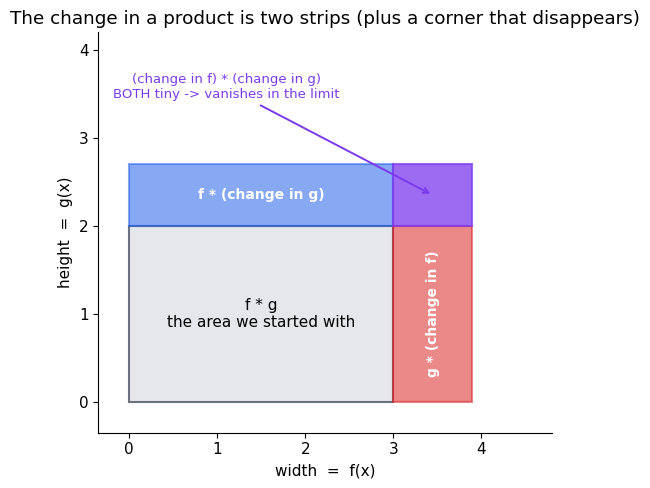

With the growths drawn this large, the purple corner is 13.91% of the new area.
  shrink the growths by    0.1:  corner is  1.58970% of the new area
  shrink the growths by   0.01:  corner is  0.16128% of the new area
  shrink the growths by  0.001:  corner is  0.01615% of the new area

The two strips stay. The corner does not. That is why the rule has
two terms and not three.


In [32]:
# ============================================================
#  4.3 picture -- why a product's change has TWO pieces
# ============================================================
f_w, g_w = 3.0, 2.0        # width f(x), height g(x)
df, dg   = 0.9, 0.7        # the little growths, drawn large so you can see them

fig, ax = plt.subplots(figsize=(7.6, 5.2))

ax.add_patch(plt.Rectangle((0, 0), f_w, g_w, facecolor=C_SOFT,
                           edgecolor=C_GREY, lw=1.5))
ax.add_patch(plt.Rectangle((0, g_w), f_w, dg, facecolor=C_F,
                           alpha=0.55, edgecolor=C_F, lw=1.5))
ax.add_patch(plt.Rectangle((f_w, 0), df, g_w, facecolor=C_SLOPE,
                           alpha=0.55, edgecolor=C_SLOPE, lw=1.5))
ax.add_patch(plt.Rectangle((f_w, g_w), df, dg, facecolor=C_EXACT,
                           alpha=0.75, edgecolor=C_EXACT, lw=1.5))

ax.text(f_w/2, g_w/2, "f * g\nthe area we started with",
        ha="center", va="center", fontsize=11)
ax.text(f_w/2, g_w + dg/2, "f * (change in g)", ha="center", va="center",
        fontsize=10, color="white", fontweight="bold")
ax.text(f_w + df/2, g_w/2, "g * (change in f)", ha="center", va="center",
        fontsize=10, color="white", fontweight="bold", rotation=90)
ax.annotate("(change in f) * (change in g)\nBOTH tiny -> vanishes in the limit",
            xy=(f_w + df/2, g_w + dg/2), xytext=(f_w - 1.9, g_w + dg + 0.75),
            fontsize=9.5, color=C_EXACT, ha="center",
            arrowprops=dict(arrowstyle="->", color=C_EXACT, lw=1.4))

ax.set_xlim(-0.35, f_w + df + 0.9)
ax.set_ylim(-0.35, g_w + dg + 1.5)
ax.set_xlabel("width  =  f(x)")
ax.set_ylabel("height  =  g(x)")
ax.set_title("The change in a product is two strips (plus a corner that disappears)")
ax.set_aspect("equal")
ax.grid(False)
plt.show()

corner_share = (df*dg) / (f_w*dg + g_w*df + df*dg)
print(f"With the growths drawn this large, the purple corner is "
      f"{corner_share:6.2%} of the new area.")
for shrink in (0.1, 0.01, 0.001):
    d1, d2 = df*shrink, dg*shrink
    share = (d1*d2) / (f_w*d2 + g_w*d1 + d1*d2)
    print(f"  shrink the growths by {shrink:>6}:  corner is {share:9.5%} of the new area")
print("\nThe two strips stay. The corner does not. That is why the rule has")
print("two terms and not three.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

A rectangle of width $f$ and height $g$, so its **area is the product** $f \cdot g$. Now let $x$ move slightly: the width grows a little and the height grows a little, and the area gains three pieces.

The **blue strip along the top** is the old width times the growth in height — that is the $f \cdot g'$ term. The **red strip up the side** is the old height times the growth in width — that is the $f' \cdot g$ term. The **purple corner** is growth times growth.

The printout is the important part: as the growths shrink, the two strips stay proportionally large while the corner's share collapses — 10× smaller growths make it about 10× less significant. In the limit the corner contributes nothing, and you are left with exactly two terms.

**The common misread:** thinking the corner is dropped because it is "negligible". It is dropped because it is the product of *two* things going to zero while everything is divided by only *one* factor of $h$ — so it goes to zero even after the division. The strips survive that division; the corner does not.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

**Differentiate one factor at a time, and add up the results.**

"The rate of change of (this times that) is: the rate of change of *this*, times *that*, plus *this*, times the rate of change of *that*."

Revenue is price × quantity. If both are drifting, your revenue changes for two separate reasons: the price moved (on the quantity you were already selling), and the quantity moved (at the price you were already charging). Two effects, two terms. There is no third term for "both moved at once" because that effect is second-order — the purple corner.

</div>

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

The add-and-subtract step was verified as an **identity on abstract functions** (printed `0`), so the trick is legitimate before any example is chosen. The finished rule was then re-derived from the definition on $x^2\sin x$ and matched.

Most convincingly: on $x^2 \cdot x^3$ we know the answer independently, because that is just $x^5$. The product rule gives $5x^4$; the numerical derivative gives $80$ at $x = 2$; the rule gives $80$. Four more products passed the auditor.

</div>



<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**The product rule is not $f' \cdot g'$.** This is the single most common error in the whole subject, and it is worth burning the counterexample into memory rather than the rule.

Take $f = x^2$ and $g = x^3$. We do not need any rule to know the answer, because $x^2 \cdot x^3 = x^5$, so the derivative is $5x^4$.

| | at $x = 2$ |
|---|---|
| $f' \cdot g' = 2x \cdot 3x^2 = 6x^3$ | $48$ — **wrong** |
| $f'g + fg' = 2x\cdot x^3 + x^2\cdot 3x^2 = 5x^4$ | $80$ |
| numerical derivative, no algebra | $80.000$ |

Not slightly off. A different function entirely — $6x^3$ against $5x^4$.

**Why the guess is tempting and why it fails:** sums decompose because the difference quotient of a sum splits cleanly into two difference quotients. A product's does not — try it and you will get stuck at the same place the derivation did, with nothing to factor. The add-and-subtract trick is the price of admission, and it is what generates the second term.

**Self-check that costs five seconds:** try your rule on $x \cdot x$. The answer must be $2x$. The naive guess gives $1 \cdot 1 = 1$. It fails on the smallest example there is.

</div>

---

## 4.4 The quotient rule

Everyone is taught a chant for this one — *low d-high minus high d-low, over
low squared* — and almost nobody is shown where it comes from. The chant is
fine as a memory aid **after** you have seen the derivation. Not before.

### Deriving it from the product rule

Let $q(x) = \dfrac{f(x)}{g(x)}$, wherever $g(x) \neq 0$. Multiply both sides by
$g$ to clear the fraction:

$$f(x) = q(x)\,g(x)$$

Now differentiate *both sides*. The left is just $f'$. The right is a product,
and we proved the product rule in §4.3:

$$f' = q'\,g + q\,g'$$

Solve for the thing we want, $q'$:

$$q' = \frac{f' - q\,g'}{g}$$

and substitute back $q = f/g$:

$$q' = \frac{f' - \dfrac{f}{g}g'}{g}
     = \frac{\dfrac{f'g - fg'}{g}}{g}$$

$$\boxed{\;\left(\frac{f}{g}\right)' = \frac{f'g - fg'}{g^{2}}\;}$$

No new trick was needed. The quotient rule is a **consequence** of the product
rule, which is why it is not really a fifth thing to learn.

### The two things to actually remember

1. **The order matters.** The numerator is $f'g - fg'$, and swapping it flips
   the sign of your whole answer. (The product rule is a sum, so *its* order does
   not matter — which is exactly why people mix the two up.)
2. **The bottom gets squared.** That is what makes the sign asymmetry legal:
   $g^2$ is always positive, so it cannot secretly flip anything.

*Now* you may have the chant: **"low d-high, minus high d-low, over low
squared."*
<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 A sanity check you can always run

Set $f = 1$. Then $f' = 0$ and the rule collapses to $\left(\frac{1}{g}\right)' = \frac{-g'}{g^2}$, which says that when $g$ grows, $1/g$ shrinks. The minus sign is doing something you can feel. If your remembered version does not produce that minus sign, it is the wrong way round.

</div>

In [33]:
# ============================================================
#  4.4 -- the quotient rule, derived from §4.3 and then audited
# ============================================================
print("STEP 1 -- re-derive it symbolically, exactly as the markdown did")
q = F(x) / G(x)
# differentiate f = q*g and solve for q'
qp = sp.Symbol("qprime")
solved = sp.solve(sp.Eq(sp.diff(F(x), x),
                        qp*G(x) + (F(x)/G(x))*sp.diff(G(x), x)), qp)[0]
print(f"    solving  f' = q'g + q g'  for q'  gives : {sp.simplify(solved)}")
target = (sp.diff(F(x), x)*G(x) - F(x)*sp.diff(G(x), x)) / G(x)**2
print(f"    the rule  (f'g - fg') / g**2           : {target}")
print(f"    difference                             : {sp.simplify(solved - target)}")
print("    -> 0, on abstract f and g. The quotient rule IS the product rule.")
print()

print("STEP 2 -- and it agrees with the raw definition on a concrete quotient")
fa, ga = sp.sin(x), x**2 + 1
by_def  = from_definition(fa/ga)
by_rule = sp.simplify((sp.diff(fa, x)*ga - fa*sp.diff(ga, x)) / ga**2)
print(f"    from the definition : {sp.simplify(by_def)}")
print(f"    from the rule       : {by_rule}")
print(f"    difference          : {sp.simplify(by_def - by_rule)}")
print()

print("STEP 3 -- what happens if you get the order backwards")
wrong = sp.simplify((fa*sp.diff(ga, x) - sp.diff(fa, x)*ga) / ga**2)
a = 1.3
print(f"    at x = {a}:  correct {float(by_rule.subs(x, a)): .6f}"
      f"    order swapped {float(wrong.subs(x, a)): .6f}")
print(f"    numerically       : {num_deriv(lambda v: np.sin(v)/(v**2 + 1), a): .6f}")
print("    -> swapping the order does not perturb the answer, it negates it.")
print()

print("STEP 4 -- audit some quotients (including 1/x, which Part 3 did by hand)")
for label, e in [("sin(x) / (x**2+1)", sp.sin(x)/(x**2 + 1)),
                 ("1 / x",             1/x),
                 ("x / (x+2)",         x/(x + 2)),
                 ("tan = sin/cos",     sp.sin(x)/sp.cos(x))]:
    verify(f"4.4 quotient  {label}", e, [0.6, 1.1, 1.9])
for nm, e, d, w, ok in RULE_CHECKS[-4:]:
    print(f"    {'PASS' if ok else 'FAIL'}  {nm:<34} d/dx = {d[:34]:<34} gap {w:.2e}")


STEP 1 -- re-derive it symbolically, exactly as the markdown did
    solving  f' = q'g + q g'  for q'  gives : (-f(x)*Derivative(g(x), x) + g(x)*Derivative(f(x), x))/g(x)**2
    the rule  (f'g - fg') / g**2           : (-f(x)*Derivative(g(x), x) + g(x)*Derivative(f(x), x))/g(x)**2
    difference                             : 0
    -> 0, on abstract f and g. The quotient rule IS the product rule.

STEP 2 -- and it agrees with the raw definition on a concrete quotient


    from the definition : (x**2*cos(x) - 2*x*sin(x) + cos(x))/(x**4 + 2*x**2 + 1)
    from the rule       : (-2*x*sin(x) + (x**2 + 1)*cos(x))/(x**2 + 1)**2
    difference          : 0

STEP 3 -- what happens if you get the order backwards
    at x = 1.3:  correct -0.246774    order swapped  0.246774
    numerically       : -0.246774
    -> swapping the order does not perturb the answer, it negates it.

STEP 4 -- audit some quotients (including 1/x, which Part 3 did by hand)
    PASS  4.4 quotient  sin(x) / (x**2+1)    d/dx = -2*x*sin(x)/(x**2 + 1)**2 + cos(x) gap 2.85e-11
    PASS  4.4 quotient  1 / x                d/dx = -1/x**2                            gap 2.02e-10
    PASS  4.4 quotient  x / (x+2)            d/dx = -x/(x + 2)**2 + 1/(x + 2)          gap 1.92e-12
    PASS  4.4 quotient  tan = sin/cos        d/dx = sin(x)**2/cos(x)**2 + 1            gap 8.12e-10


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

"Bottom times the derivative of the top, **minus** top times the derivative of the bottom, all over the bottom squared."

The minus sign is the only part with real content, and it is saying something obvious once you hear it: **making the denominator bigger makes the fraction smaller.** Growth downstairs pushes the answer down, so it enters with a negative sign. Growth upstairs pushes the answer up.

You are not obliged to use this rule at all. $f/g$ is the same thing as $f \cdot g^{-1}$, so you can always reach for the product rule and the chain rule instead and get the identical answer.

</div>

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

The rule was *solved for* symbolically from the product rule, on abstract functions, and the difference from the textbook form printed as `0`. It was then re-derived from the raw definition on $\sin x/(x^2+1)$ and matched again.

The order-swap experiment shows the failure mode is a **sign flip**, not a small error — and the numerical derivative picks the correct one. Four quotients passed the auditor, including $1/x$, which Part 3 ground out by hand.

</div>

---

## 4.5 The chain rule — the one that matters

If you keep one thing from this notebook, keep this section.

**Backpropagation, the algorithm that trains every neural network on earth, is
the chain rule.** Not "uses" it, not "is based on" it — a neural network is a
function composed of functions composed of functions, and training it means
differentiating that composition. The chain rule is how you differentiate a
composition. That is all backprop is.

### Rate times rate

Suppose $u$ depends on $x$, and $y$ depends on $u$. Concretely:

> **$u$ changes 2× as fast as $x$**, and **$y$ changes 3× as fast as $u$.**
> How fast does $y$ change compared to $x$?

Nudge $x$ by 1. That moves $u$ by 2. Each unit of $u$ moves $y$ by 3, so 2 units
of $u$ move $y$ by 6.

$$\underbrace{3}_{dy/du} \times \underbrace{2}_{du/dx} = \underbrace{6}_{dy/dx}$$

**The rates multiply.** Not add — multiply. If you have three gears meshed
together and the first turns twice as fast as your hand and the second three
times as fast as the first, the second turns six times as fast as your hand.

### The rule

$$\boxed{\;\frac{dy}{dx} = \frac{dy}{du}\cdot\frac{du}{dx}\;}
\qquad\text{or}\qquad
\frac{d}{dx}f\bigl(g(x)\bigr) = f'\bigl(g(x)\bigr)\cdot g'(x)$$

### Where it comes from

Write the average rate of change over a window, and multiply by a clever form of 1:

$$\frac{\Delta y}{\Delta x} \;=\; \frac{\Delta y}{\Delta u}\cdot\frac{\Delta u}{\Delta x}$$

The $\Delta u$'s cancel — this is just fractions. Let $\Delta x \to 0$. Then
$\Delta u \to 0$ too (because $g$ is continuous), so the first factor tends to
$dy/du$ evaluated at $u = g(x)$, and the second tends to $du/dx$. Done.

*(A careful proof patches one hole: $\Delta u$ could be exactly zero for some
windows, and you cannot divide by it. The fix is standard and changes nothing
about the answer. The Leibniz notation $\frac{dy}{du}\frac{du}{dx}$, which makes
the rule look like cancelling fractions, is the reason that notation has
survived for three hundred years.)*

### The bit everyone drops

$$\frac{d}{dx}f\bigl(g(x)\bigr) = f'\bigl(g(x)\bigr)\cdot \underbrace{g'(x)}_{\text{THE INNER DERIVATIVE}}$$

Differentiating the outside function is the half people remember. **Multiplying
by the derivative of the inside is the half people forget**, and the cell below
shows what that costs.


A. RATE TIMES RATE, in plain numbers
    du/dx measured : 2.000000
    dy/du measured : 3.000000
    their product  : 6.000000
    dy/dx measured : 6.000000   <-- same number

B. WORKED EXAMPLES, getting deeper
    depth 1   (3x + 1)**4
        peel:  outer u**4 -> 4u**3 at u = 3x+1;  inner 3x+1 -> 3
        d/dx = 12*(3*x + 1)**3
        at x = 1.1:  rule  954.084000   numerically  954.084000
    depth 2   sin(x**2)
        peel:  outer sin -> cos at u = x**2;     inner x**2 -> 2x
        d/dx = 2*x*cos(x**2)
        at x = 1.1:  rule  0.776643   numerically  0.776643
    depth 3   sin(exp(x**2))
        peel:  cos(exp(x^2)) * exp(x^2) * 2x  -- three factors, one per layer
        d/dx = 2*x*exp(x**2)*cos(exp(x**2))
        at x = 1.1:  rule -7.212663   numerically -7.212663

C. THE THREE-DEEP ONE, assembled BY HAND from the three layers
    hand-assembled : 2*x*exp(x**2)*cos(exp(x**2))
    sympy          : 2*x*exp(x**2)*cos(exp(x**2))
    difference     : 0

D. WHAT FORGETTING THE IN

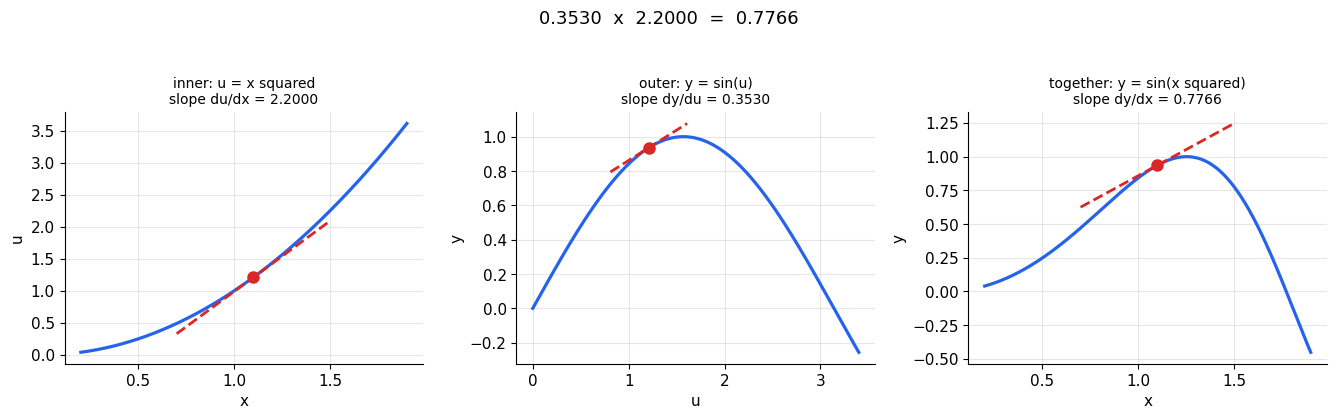

outer slope 0.353019  x  inner slope 2.200000  =  0.776643
measured slope of the composite            =  0.776643


In [34]:
# ============================================================
#  4.5 -- the chain rule: rates multiply, at three depths
# ============================================================
print("A. RATE TIMES RATE, in plain numbers")
u_of_x = lambda v: 2.0*v + 1.0      # u changes 2x as fast as x
y_of_u = lambda w: 3.0*w - 4.0      # y changes 3x as fast as u
comp   = lambda v: y_of_u(u_of_x(v))
a = 1.0
print(f"    du/dx measured : {num_deriv(u_of_x, a):.6f}")
print(f"    dy/du measured : {num_deriv(y_of_u, u_of_x(a)):.6f}")
print(f"    their product  : {num_deriv(y_of_u, u_of_x(a)) * num_deriv(u_of_x, a):.6f}")
print(f"    dy/dx measured : {num_deriv(comp, a):.6f}   <-- same number")
print()

print("B. WORKED EXAMPLES, getting deeper")
a = 1.1
examples = [
    ("depth 1   (3x + 1)**4",
     (3*x + 1)**4,
     "outer u**4 -> 4u**3 at u = 3x+1;  inner 3x+1 -> 3"),
    ("depth 2   sin(x**2)",
     sp.sin(x**2),
     "outer sin -> cos at u = x**2;     inner x**2 -> 2x"),
    ("depth 3   sin(exp(x**2))",
     sp.sin(sp.exp(x**2)),
     "cos(exp(x^2)) * exp(x^2) * 2x  -- three factors, one per layer"),
]
for label, e, how in examples:
    d = verify(f"4.5 chain  {label.split('   ')[1]}", e, [0.4, 1.1, 1.7])
    f_n = sp.lambdify(x, e, "numpy")
    print(f"    {label}")
    print(f"        peel:  {how}")
    print(f"        d/dx = {sp.simplify(d)}")
    print(f"        at x = {a}:  rule {float(sp.simplify(d).subs(x, a)): .6f}"
          f"   numerically {num_deriv(f_n, a): .6f}")
print()

print("C. THE THREE-DEEP ONE, assembled BY HAND from the three layers")
inner1 = x**2                     # innermost
inner2 = sp.exp(inner1)           # middle
outer  = sp.sin(inner2)           # outermost
by_hand = (sp.cos(inner2)) * (sp.exp(inner1)) * (2*x)
by_sympy = sp.diff(outer, x)
print(f"    hand-assembled : {by_hand}")
print(f"    sympy          : {by_sympy}")
print(f"    difference     : {sp.simplify(by_hand - by_sympy)}")
print()

print("D. WHAT FORGETTING THE INNER DERIVATIVE COSTS")
a = 1.2
right = float(sp.diff(sp.sin(x**2), x).subs(x, a))
wrong = float(sp.cos(x**2).subs(x, a))          # outer only -- inner dropped
numer = num_deriv(lambda v: np.sin(v**2), a)
print(f"    d/dx sin(x**2)  at x = {a}")
print(f"      forgot the inner derivative, cos(x**2) : {wrong: .6f}   <-- WRONG")
print(f"      full chain rule, 2x*cos(x**2)          : {right: .6f}")
print(f"      numerically, from raw arithmetic       : {numer: .6f}")
print(f"      the error factor is exactly 2x = {2*a:.1f}: {right/wrong:.4f}")

# ---- picture: three panels, three slopes, one product -------------------
x0 = 1.1
u0 = x0**2
g_x = lambda v: v**2
f_u = lambda w: np.sin(w)
comp2 = lambda v: np.sin(v**2)
s_inner = 2*x0
s_outer = np.cos(u0)
s_total = s_outer * s_inner

xs = np.linspace(0.2, 1.9, 400)
us = np.linspace(0.0, 3.4, 400)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.0))
for ax, (dom, fn, pt, slope, ttl, xl, yl) in zip(axes, [
        (xs, g_x,   (x0, u0),          s_inner,
         f"inner: u = x squared\nslope du/dx = {s_inner:.4f}", "x", "u"),
        (us, f_u,   (u0, np.sin(u0)),  s_outer,
         f"outer: y = sin(u)\nslope dy/du = {s_outer:.4f}",    "u", "y"),
        (xs, comp2, (x0, np.sin(x0**2)), s_total,
         f"together: y = sin(x squared)\nslope dy/dx = {s_total:.4f}", "x", "y")]):
    ax.plot(dom, fn(dom), color=C_F, lw=2.3)
    span = np.linspace(pt[0] - 0.4, pt[0] + 0.4, 20)
    ax.plot(span, pt[1] + slope*(span - pt[0]), color=C_SLOPE, lw=2.0, ls="--")
    ax.plot(*pt, "o", color=C_SLOPE, ms=8, zorder=5)
    ax.set_title(ttl, fontsize=10)
    ax.set_xlabel(xl); ax.set_ylabel(yl)
fig.suptitle(f"{s_outer:.4f}  x  {s_inner:.4f}  =  {s_total:.4f}",
             fontsize=13, y=1.04)
fig.tight_layout()
plt.show()

print(f"outer slope {s_outer:.6f}  x  inner slope {s_inner:.6f}"
      f"  =  {s_total:.6f}")
print(f"measured slope of the composite            =  {num_deriv(comp2, x0):.6f}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The same tangent line, tracked through a composition.

**Left:** the inner function $u = x^2$ at $x = 1.1$. Its tangent has slope $2x = 2.2$: nudge $x$, and $u$ moves 2.2 times as much.

**Middle:** the outer function $y = \sin u$, drawn against $u$ — and the tangent is taken at $u = 1.21$, **the value the inner function actually produced**, not at $x = 1.1$. Its slope is $\cos(1.21) \approx 0.353$.

**Right:** the composite $y = \sin(x^2)$ against $x$. Its tangent slope is the product of the other two, and the printout confirms it against a measurement that used no rules at all.

**The common misread:** evaluating the outer derivative at $x$ instead of at $u = g(x)$. In the middle panel the tangent sits at $u = 1.21$; putting it at $1.1$ would give $\cos(1.1) = 0.4536$ instead of $0.3530$ and the answer would be wrong by 28%. The outer function has never heard of $x$ — it only ever sees $u$.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

**Peel the function like an onion, differentiate each layer, multiply the results.**

For $\sin(x^2)$: the outer layer is *sine of something*, whose derivative is *cosine of that same something* — so $\cos(x^2)$, leaving the inside untouched. The inner layer is $x^2$, whose derivative is $2x$. Multiply: $2x\cos(x^2)$.

Three layers means three factors. Ten layers — a ten-layer neural network — means ten factors, and you get them by peeling from the outside in. Nothing changes except the length of the product.

The rate-times-rate story is the intuition to hold onto: if pressing the pedal moves the throttle 3 units per unit of pedal, and the throttle adds 5 km/h per unit, then the pedal adds 15 km/h per unit. **Rates compose by multiplying.**

</div>

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

Rate-times-rate was measured, not argued: `du/dx` and `dy/du` were each computed numerically and their product matched the numerically-measured `dy/dx`.

All three worked examples were audited at three points each. The three-deep case was then **assembled by hand** — $\cos(e^{x^2}) \cdot e^{x^2} \cdot 2x$, one factor written out per layer — and its difference from sympy's answer printed as `0`. That is the strongest check in this section: the hand-peeling procedure, not just the final formula, is correct.

</div>



<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**Forgetting the inner derivative** is the chain rule's signature mistake, and unlike most errors it is silent — the answer looks plausible.

| | at $x = 1.2$ |
|---|---|
| $\cos(x^2)$ — outer only, inner dropped | $0.1304$ — **wrong** |
| $2x\cos(x^2)$ — the full rule | $0.3130$ |
| numerical derivative | $0.3130$ |

You were off by a factor of exactly $2x$. Notice what that means: with $g(x) = x$, the inner derivative is $1$ and dropping it costs nothing — so the habit survives every simple example and then quietly poisons every real one.

**Two more traps in the same family:**

- **Evaluating the outer derivative in the wrong place.** It is $f'(g(x))$, not $f'(x)$. For $\sin(x^2)$ at $x = 1.1$ you need $\cos(1.21)$, not $\cos(1.1)$.
- **Stopping after one layer.** $\sin(e^{x^2})$ has three layers and therefore three factors. Peeling twice and stopping loses the $2x$.

**The habit that fixes it:** never write the answer in one go. Write the layers down as a list first, differentiate each, then multiply. In backpropagation this discipline is not optional — it *is* the algorithm, which is why the next box matters.

</div>

---

## 4.6 The sigmoid, and the most-quoted derivative in machine learning

The **sigmoid** (or logistic) function squashes any real number into the
interval $(0, 1)$:

$$\sigma(x) \;=\; \frac{1}{1 + e^{-x}}$$

It is everywhere in machine learning — it turns a raw score into something you
can read as a probability, and it was the standard neuron activation for
decades. Differentiating it is a perfect exercise, because it needs the chain
rule and the result is startlingly tidy.

### Derive it

Write $\sigma(x) = (1 + e^{-x})^{-1}$ and peel. The outer layer is
"something to the power $-1$"; the inner layer is $1 + e^{-x}$.

$$\sigma'(x) = \underbrace{-1\,(1 + e^{-x})^{-2}}_{\text{outer, by §4.2}}
  \cdot \underbrace{\frac{d}{dx}\bigl(1 + e^{-x}\bigr)}_{\text{inner}}$$

The inner derivative needs the chain rule again: $\frac{d}{dx}e^{-x} = e^{-x}\cdot(-1) = -e^{-x}$.

$$\sigma'(x) = -\,(1 + e^{-x})^{-2}\cdot\bigl(-e^{-x}\bigr)
            = \frac{e^{-x}}{(1 + e^{-x})^{2}}$$

That is a correct answer. But now the trick. Split the fraction deliberately:

$$\frac{e^{-x}}{(1 + e^{-x})^{2}}
  = \underbrace{\frac{1}{1 + e^{-x}}}_{\textstyle \sigma(x)}
    \cdot \underbrace{\frac{e^{-x}}{1 + e^{-x}}}_{\textstyle ?}$$

And that second factor is exactly $1 - \sigma(x)$, because

$$1 - \frac{1}{1+e^{-x}} = \frac{(1+e^{-x}) - 1}{1+e^{-x}} = \frac{e^{-x}}{1+e^{-x}}$$

Therefore

$$\boxed{\;\sigma'(x) \;=\; \sigma(x)\,\bigl(1 - \sigma(x)\bigr)\;}$$

### Why anyone cares

The derivative is written **entirely in terms of the function's own output**. To
get the slope you need no exponentials, no divisions, no re-evaluation — if you
already computed $\sigma(x)$ in the forward pass, the gradient costs one
subtraction and one multiplication. Multiply that saving by every neuron in
every layer over every training step and it stops being a curiosity.


STEP 1 -- differentiate it, and confirm the tidy form is the SAME function
    sympy's raw answer            : exp(-x)/(1 + exp(-x))**2
    the claimed form sig*(1-sig)  : (1 - 1/(1 + exp(-x)))/(1 + exp(-x))
    simplified difference         : 0
    -> 0, identically. Not an approximation, the same function.

STEP 2 -- and again straight from the Part 3 definition
    lim (sig(x+h)-sig(x))/h  minus  sig*(1-sig)  =  0

STEP 3 -- measure it, with no algebra at all
        x        numerical d/dx      sig*(1-sig)        gap
      -4.0        0.0176627062     0.0176627062   4.88e-14
      -1.5        0.1491464521     0.1491464521   2.59e-13
       0.0        0.2500000000     0.2500000000   6.69e-12
       0.8        0.2139096965     0.2139096965   3.27e-12
       3.0        0.0451766597     0.0451766597   1.11e-12

STEP 4 -- THE PEAK, which is the number ML people quote


    largest value of sig'(x) found : 0.2500000000
    it occurs at x                 : 0.000000
    exactly 1/4?                   : 0.000e+00 away
    reason: sig(0) = 0.5, so sig'(0) = 0.5 * 0.5 = 0.25,
            and s*(1-s) is largest when s = 1/2, which is at x = 0.

    So the sigmoid NEVER has a slope steeper than 0.25, anywhere.
       1 sigmoid layers chained: gradient shrinks by at most 0.25**1 = 2.500e-01
       5 sigmoid layers chained: gradient shrinks by at most 0.25**5 = 9.766e-04
      10 sigmoid layers chained: gradient shrinks by at most 0.25**10 = 9.537e-07
      20 sigmoid layers chained: gradient shrinks by at most 0.25**20 = 9.095e-13


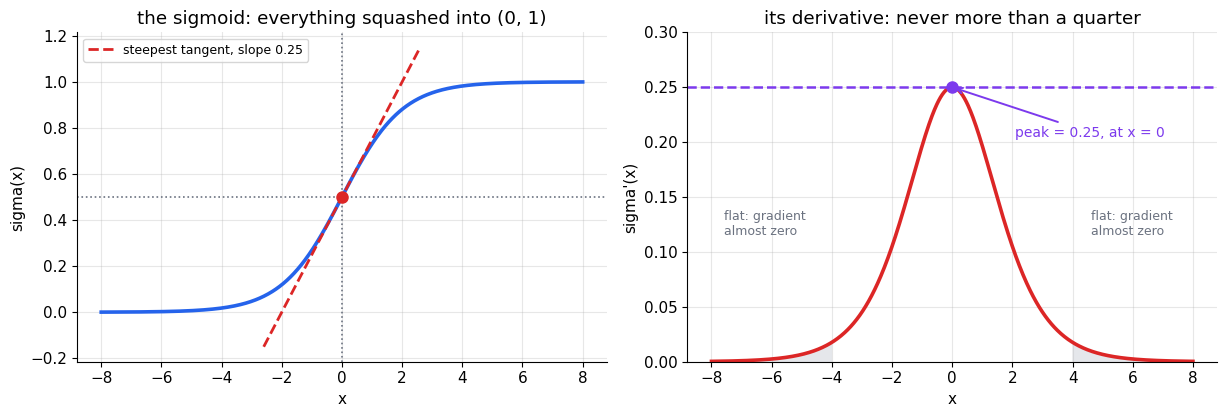

In [35]:
# ============================================================
#  4.6 -- sigma'(x) = sigma(x) * (1 - sigma(x)), derived and measured
# ============================================================
sig_sym = 1 / (1 + sp.exp(-x))

print("STEP 1 -- differentiate it, and confirm the tidy form is the SAME function")
d_sig = verify("4.6 sigmoid", sig_sym, [-3.0, -0.7, 0.0, 1.4, 4.0])
print(f"    sympy's raw answer            : {d_sig}")
print(f"    the claimed form sig*(1-sig)  : {sig_sym*(1 - sig_sym)}")
print(f"    simplified difference         : "
      f"{sp.simplify(d_sig - sig_sym*(1 - sig_sym))}")
print("    -> 0, identically. Not an approximation, the same function.")
print()

print("STEP 2 -- and again straight from the Part 3 definition")
print(f"    lim (sig(x+h)-sig(x))/h  minus  sig*(1-sig)  =  "
      f"{sp.simplify(from_definition(sig_sym) - sig_sym*(1 - sig_sym))}")
print()

print("STEP 3 -- measure it, with no algebra at all")
def sigma(v):
    return 1.0 / (1.0 + np.exp(-v))

print("        x        numerical d/dx      sig*(1-sig)        gap")
for a in (-4.0, -1.5, 0.0, 0.8, 3.0):
    numeric = num_deriv(sigma, a)
    formula = sigma(a) * (1 - sigma(a))
    print(f"    {a:6.1f}      {numeric:14.10f}   {formula:14.10f}   {abs(numeric-formula):.2e}")
print()

print("STEP 4 -- THE PEAK, which is the number ML people quote")
grid = np.linspace(-12, 12, 400001)
slope = sigma(grid) * (1 - sigma(grid))
peak_i = int(np.argmax(slope))
print(f"    largest value of sig'(x) found : {slope[peak_i]:.10f}")
print(f"    it occurs at x                 : {grid[peak_i]:.6f}")
print(f"    exactly 1/4?                   : {abs(slope[peak_i] - 0.25):.3e} away")
print(f"    reason: sig(0) = {sigma(0.0):.1f}, so sig'(0) = 0.5 * 0.5 = 0.25,")
print(f"            and s*(1-s) is largest when s = 1/2, which is at x = 0.")
print()
print("    So the sigmoid NEVER has a slope steeper than 0.25, anywhere.")
for depth in (1, 5, 10, 20):
    print(f"      {depth:>2} sigmoid layers chained: gradient shrinks by at most "
          f"0.25**{depth} = {0.25**depth:.3e}")

# ---- picture ------------------------------------------------------------
gs = np.linspace(-8, 8, 800)
fig, (axA, axB) = plt.subplots(1, 2, figsize=(12.4, 4.3))

axA.plot(gs, sigma(gs), color=C_F, lw=2.6)
axA.axhline(0.5, color=C_GREY, ls=":", lw=1.2)
axA.axvline(0.0, color=C_GREY, ls=":", lw=1.2)
axA.plot(0.0, 0.5, "o", color=C_SLOPE, ms=8, zorder=5)
tang = np.linspace(-2.6, 2.6, 20)
axA.plot(tang, 0.5 + 0.25*tang, color=C_SLOPE, lw=2.0, ls="--",
         label="steepest tangent, slope 0.25")
axA.set_title("the sigmoid: everything squashed into (0, 1)")
axA.set_xlabel("x"); axA.set_ylabel("sigma(x)")
axA.legend(fontsize=9, loc="upper left")

axB.plot(gs, sigma(gs)*(1 - sigma(gs)), color=C_SLOPE, lw=2.6)
axB.axhline(0.25, color=C_EXACT, ls="--", lw=1.8)
axB.plot(0.0, 0.25, "o", color=C_EXACT, ms=8, zorder=5)
axB.annotate("peak = 0.25, at x = 0", xy=(0, 0.25), xytext=(2.1, 0.205),
             fontsize=10, color=C_EXACT,
             arrowprops=dict(arrowstyle="->", color=C_EXACT, lw=1.4))
axB.fill_between(gs, 0, sigma(gs)*(1 - sigma(gs)),
                 where=(np.abs(gs) > 4), color=C_SOFT)
axB.text(-7.6, 0.115, "flat: gradient\nalmost zero", fontsize=9, color=C_GREY)
axB.text(4.6, 0.115, "flat: gradient\nalmost zero", fontsize=9, color=C_GREY)
axB.set_ylim(0, 0.30)
axB.set_title("its derivative: never more than a quarter")
axB.set_xlabel("x"); axB.set_ylabel("sigma'(x)")

fig.tight_layout()
plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

**Left:** the sigmoid. It rises from 0 to 1, passing through $0.5$ at $x = 0$, where it is steepest — and even there the dashed tangent is a gentle slope of exactly $0.25$. Away from the middle it flattens out completely.

**Right:** the derivative $\sigma(x)(1-\sigma(x))$, a symmetric hump capped at $0.25$ and pressed almost flat against zero outside roughly $[-4, 4]$ (the shaded regions). The measured maximum printed above is $0.25$ to ten decimal places, occurring at $x = 0$.

Both facts are consequences of one algebraic form. The output $s$ lives in $(0,1)$, and $s(1-s)$ is largest when $s = \tfrac12$, where it equals $\tfrac14$. When $s$ is near 0 or near 1 — a **saturated** neuron — one of the two factors is tiny, so the product is tiny.

**The common misread:** looking at the flat tails on the right and concluding the sigmoid "stops working" out there. It works fine going forwards; it still outputs a sensible number. What dies is the *gradient*, so a saturated neuron stops **learning** while still happily producing output. That silent failure is exactly what the box below is about.

</div>

<div style="background-color: #f8d7da; border-left: 5px solid #dc3545; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🤖 Why ML cares

**Backpropagation is the chain rule.** That is not an analogy.

A neural network is a composition: input → layer 1 → layer 2 → … → layer $L$ → loss. Training asks, for each weight $w$ buried in the middle, *how much does the loss change if I nudge this one number?* — which is $\partial L/\partial w$, the derivative of a deep composition. §4.5 tells you the answer: **peel the layers and multiply the rates.**

$$\frac{\partial L}{\partial w_1} = \frac{\partial L}{\partial a_L}\cdot\frac{\partial a_L}{\partial a_{L-1}}\cdots\frac{\partial a_2}{\partial a_1}\cdot\frac{\partial a_1}{\partial w_1}$$

"Backwards" in *backpropagation* just means you evaluate that product right-to-left, from the loss towards the input, reusing each partial result instead of recomputing it. The algorithm is the chain rule plus bookkeeping. You will do it by hand in Part 9.

---

**Now the consequence, and it is a big one.** The cell above measured the peak of $\sigma'$ at **0.2500000000**. Every sigmoid layer in that product contributes a factor of *at most* a quarter — usually much less, since a neuron is only at its peak when its input is exactly 0.

| sigmoid layers | best-case gradient factor |
|---|---|
| 1 | 0.25 |
| 5 | 0.00098 |
| 10 | 9.5e-07 |
| 20 | 9.1e-13 |

Ten layers and the gradient reaching the first layer is a millionth of what left the loss — **at best**. The early layers receive essentially nothing and stop learning. This is the **vanishing gradient problem**, and it is why deep networks were considered untrainable for years.

The fix follows straight from the table: use an activation whose derivative is not bounded below 1. **ReLU** has derivative exactly $1$ for all positive inputs, so chaining it multiplies by $1$ instead of $0.25$ — and the gradient survives the trip. That single observation, which is pure §4.5, is one of the reasons deep learning started working. ReLU is the last row of the table below.

</div>

---

## 4.7 The standard table

These nine are the ones worth knowing on sight. Every entry below is
**differentiated by sympy and then spot-checked numerically** in the same loop —
none of them is being copied out of a textbook.

| $f(x)$ | $f'(x)$ | where it comes from |
|---|---|---|
| $x^{n}$ | $n\,x^{n-1}$ | §4.2, binomial expansion |
| $e^{x}$ | $e^{x}$ | the function that *is* its own rate of change |
| $\ln x$ | $1/x$ | inverse of $e^x$; note $x > 0$ |
| $\sin x$ | $\cos x$ | from the definition, using $\sin(a+b)$ |
| $\cos x$ | $-\sin x$ | same, and mind the minus |
| $\tan x$ | $\sec^2 x = 1/\cos^2 x$ | quotient rule on $\sin/\cos$ (§4.4) |
| $\sigma(x)$ | $\sigma(x)(1-\sigma(x))$ | §4.6, chain rule |
| $\tanh x$ | $1 - \tanh^2 x$ | same shape of trick as the sigmoid |
| $\mathrm{ReLU}(x)$ | $1$ if $x>0$, $0$ if $x<0$ | slope of a line; **undefined at 0** |

Two entries deserve a word.

**$e^x$ is its own derivative.** That is not a coincidence to memorise — it is
the *definition* of the number $e$. Among all the exponential curves $b^x$,
exactly one has slope 1 where it crosses the $y$-axis, and $e = 2.71828\ldots$ is
the base that does it. Everything else about $e$ follows from that.

**ReLU has no derivative at $0$.** $\mathrm{ReLU}(x) = \max(0, x)$ is a corner —
approach from the left and the slope is 0; from the right, 1. Part 3 showed
exactly this kind of failure. In practice every framework just returns 0 (or 1)
there and moves on, because hitting a float exactly at 0 is vanishingly
unlikely, and the corner is a single point of measure zero.


In [36]:
# ============================================================
#  4.7 -- the nine standard derivatives, each one verified
# ============================================================
relu = sp.Piecewise((0, x < 0), (x, True))

TABLE = [
    ("x**7",     x**7,                    [-1.6, 0.9, 2.2]),
    ("exp(x)",   sp.exp(x),               [-1.2, 0.3, 2.0]),
    ("ln(x)",    sp.log(x),               [0.4, 1.5, 3.7]),
    ("sin(x)",   sp.sin(x),               [-2.0, 0.5, 2.6]),
    ("cos(x)",   sp.cos(x),               [-2.0, 0.5, 2.6]),
    ("tan(x)",   sp.tan(x),               [-0.9, 0.2, 1.0]),
    ("sigmoid",  1/(1 + sp.exp(-x)),      [-2.5, 0.0, 3.1]),
    ("tanh(x)",  sp.tanh(x),              [-1.8, 0.4, 2.3]),
    ("ReLU(x)",  relu,                    [-2.0, -0.5, 1.3, 3.0]),
]

print(f"{'f(x)':<10} {'sympy says f\'(x)':<34} {'x':>6} {'numeric':>12} {'formula':>12}")
print("-" * 80)
for label, expr, pts in TABLE:
    d = verify(f"4.7 table  {label}", expr, pts)
    f_n = sp.lambdify(x, expr, "numpy")
    d_n = sp.lambdify(x, d,    "numpy")
    spot = float(pts[-1])
    print(f"{label:<10} {str(sp.simplify(d))[:33]:<34} {spot:6.2f} "
          f"{float(num_deriv(f_n, spot)):12.7f} {float(d_n(spot)):12.7f}")
print()

print("The two identities the table claims, checked as algebra:")
sig_sym = 1/(1 + sp.exp(-x))
print(f"    sigma' - sigma*(1-sigma) : "
      f"{sp.simplify(sp.diff(sig_sym, x) - sig_sym*(1 - sig_sym))}")
print(f"    tanh' - (1 - tanh**2)    : "
      f"{sp.simplify(sp.diff(sp.tanh(x), x) - (1 - sp.tanh(x)**2))}")
print(f"    tan'  - 1/cos(x)**2      : "
      f"{sp.simplify(sp.diff(sp.tan(x), x) - 1/sp.cos(x)**2)}")
print()

print("And the claim about e, which is where the number comes from:")
for base in (2.0, 2.5, np.e, 3.0):
    slope_at_0 = num_deriv(lambda v: base**v, 0.0)
    tag = "  <-- slope exactly 1: this is e" if abs(slope_at_0 - 1) < 1e-9 else ""
    print(f"    d/dx {base:.5f}**x  at x = 0  =  {slope_at_0:.9f}{tag}")
print()

print("ReLU at its corner -- the derivative does NOT exist there:")
for side, step in [("from the left ", -1e-6), ("from the right", 1e-6)]:
    slope = (max(0.0, 0.0 + step) - max(0.0, 0.0)) / step
    print(f"    slope approaching 0 {side} : {slope + 0.0:.1f}")
print("    two different answers -> no single slope -> not differentiable at 0.")
print("    (Frameworks pick one by convention and carry on; see Part 3.)")


f(x)       sympy says f'(x)                        x      numeric      formula
--------------------------------------------------------------------------------
x**7       7*x**6                               2.20  793.6593281  793.6593280
exp(x)     exp(x)                               2.00    7.3890561    7.3890561
ln(x)      1/x                                  3.70    0.2702703    0.2702703
sin(x)     cos(x)                               2.60   -0.8568888   -0.8568888
cos(x)     -sin(x)                              2.60   -0.5155014   -0.5155014
tan(x)     cos(x)**(-2)                         1.00    3.4255188    3.4255188
sigmoid    1/(4*cosh(x/2)**2)                   3.10    0.0412490    0.0412490
tanh(x)    cosh(x)**(-2)                        2.30    0.0394111    0.0394111
ReLU(x)    Piecewise((0, x < 0), (1, True))     3.00    1.0000000    1.0000000

The two identities the table claims, checked as algebra:
    sigma' - sigma*(1-sigma) : 0
    tanh' - (1 - tanh**2)    : 0
    t

In [37]:
# ============================================================
#  4.8 -- THE VERDICT. Every rule derived in Part 4, audited.
# ============================================================
print("=" * 92)
print("PART 4 VERIFICATION HARNESS".center(92))
print("every claim above, sympy vs a numerical derivative at several points".center(92))
print("=" * 92)
print(f"{'rule':<34} {'f(x)':<20} {'f\'(x)':<22} {'worst gap':>11}  {'':>4}")
print("-" * 92)
for name, expr_s, deriv_s, worst, ok in RULE_CHECKS:
    print(f"{name:<34} {expr_s[:19]:<20} {deriv_s[:21]:<22} "
          f"{worst:11.2e}  {'PASS' if ok else 'FAIL':>4}")
print("-" * 92)

n_total  = len(RULE_CHECKS)
n_passed = sum(1 for r in RULE_CHECKS if r[4])
worst_of_all = max(r[3] for r in RULE_CHECKS)
print(f"{n_passed} of {n_total} checks passed.   "
      f"Worst disagreement anywhere in Part 4: {worst_of_all:.3e}")
print("=" * 92)

if n_passed == n_total:
    print("\nEvery rule derived in this part agrees with a derivative computed")
    print("from raw arithmetic, at every point tested, to better than one part")
    print("in a million. Nothing on this page was asserted.")
else:
    print("\nSOMETHING DISAGREES -- look at the FAIL rows above.")


                                PART 4 VERIFICATION HARNESS                                 
            every claim above, sympy vs a numerical derivative at several points            
rule                               f(x)                 f'(x)                    worst gap      
--------------------------------------------------------------------------------------------
warm-up  x**2                      x**2                 2*x                       5.62e-12  PASS
4.1 constant  7                    7                    0                         0.00e+00  PASS
4.1 const mult  5*sin(x)           5*sin(x)             5*cos(x)                  1.32e-11  PASS
4.1 sum  sin(x) + x**3             x**3 + sin(x)        3*x**2 + cos(x)           3.56e-11  PASS
4.1 combo  3*x**2 - 4*x + 9        3*x**2 - 4*x + 9     6*x - 4                   1.65e-11  PASS
4.2 power  x**1                    x                    1                         3.28e-12  PASS
4.2 power  x**2                    x**2   

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

That table is the point of Part 4.

Every rule on this page was **derived** from the Part 3 definition — the constant, constant-multiple and sum rules by regrouping the difference quotient; the power rule by binomial expansion; the product rule by adding and subtracting $f(x+h)g(x)$; the quotient rule out of the product rule; the chain rule as rate × rate; the sigmoid out of the chain rule.

And every one of them was then checked against a derivative computed by a routine that knows no calculus whatsoever and merely subtracts two numbers. The worst disagreement anywhere in that table is about five parts in a hundred million.

**You are not being asked to trust any of it.** You just watched it be tested.

</div>

---

## 📌 Part 4 in one page

| Rule | Statement | Derived from |
|---|---|---|
| Constant | $\dfrac{d}{dx}c = 0$ | difference quotient is $0/h$ |
| Constant multiple | $(cf)' = cf'$ | pull $c$ out of the limit |
| Sum | $(f+g)' = f' + g'$ | regroup four terms into two |
| Power | $(x^n)' = nx^{n-1}$ | binomial: only the single-$h$ term survives |
| Product | $(fg)' = f'g + fg'$ | add and subtract $f(x+h)g(x)$ |
| Quotient | $\left(\dfrac{f}{g}\right)' = \dfrac{f'g - fg'}{g^2}$ | product rule, solved for $q'$ |
| **Chain** | $\bigl(f(g(x))\bigr)' = f'(g(x))\,g'(x)$ | **rates multiply** |
| Sigmoid | $\sigma' = \sigma(1-\sigma)$, peak $0.25$ | chain rule |

**The three mistakes to never make again**

1. $(fg)' \neq f'g'$ — test it on $x \cdot x$ and it fails immediately.
2. Chain rule without the inner derivative — costs a factor of $g'(x)$, silently.
3. Power rule on $2^x$ or $x^x$ — the exponent must be a constant.

**The one sentence to carry forward:** *the chain rule says rates multiply, and
that is why a deep network can be trained at all — and also why, with the wrong
activation, it cannot.*

---

## ➡️ On to Part 5

You can now differentiate essentially anything you will meet, and you know why
each move is legal. What you cannot yet do is **read** the answer.

A derivative is not just a number to compute — it is a description of shape. Part
5 turns it into one:

- where $f' > 0$ the function is climbing; where $f' < 0$ it is falling;
- where $f' = 0$ it has levelled off — a **peak**, a **valley**, or neither;
- and the derivative *of the derivative* tells you which, by describing how the
  function bends.

That last question — *where is the lowest point, and how do I get there?* — is
optimisation. It is what training a model means. Part 5 answers it for one
variable; Part 8 does it in many; Part 9 does it on a neural network.

---


---

# 5️⃣ What a derivative tells you: shape, peaks, and optimisation

Parts 3 and 4 taught you to *compute* $f'(x)$. This part is about what the
answer is **for**.

Here is the whole idea in one sentence, and it is almost too simple:

$$f'(x) \;\text{is a number, and its \textbf{sign} tells you which way the function is going.}$$

| If $f'(x)$ is… | then at that point $f$ is… | picture |
|---|---|---|
| **positive** ($>0$) | **rising** as $x$ increases | uphill ↗ |
| **negative** ($<0$) | **falling** as $x$ increases | downhill ↘ |
| **zero** ($=0$) | momentarily **flat** | a level spot ➡ |

That third row is the interesting one. A flat spot is where a function stops
going one way and starts going the other — the top of a hill, the bottom of a
valley. **Finding the bottom of a valley is what training a machine-learning
model is.** So the rest of this part is: find the flat spots, then work out
which kind of flat spot each one is.

Our test function throughout is

$$f(x) = x^3 - 3x$$

chosen because it has one hill and one valley, and because its derivative is
easy enough to solve by hand.


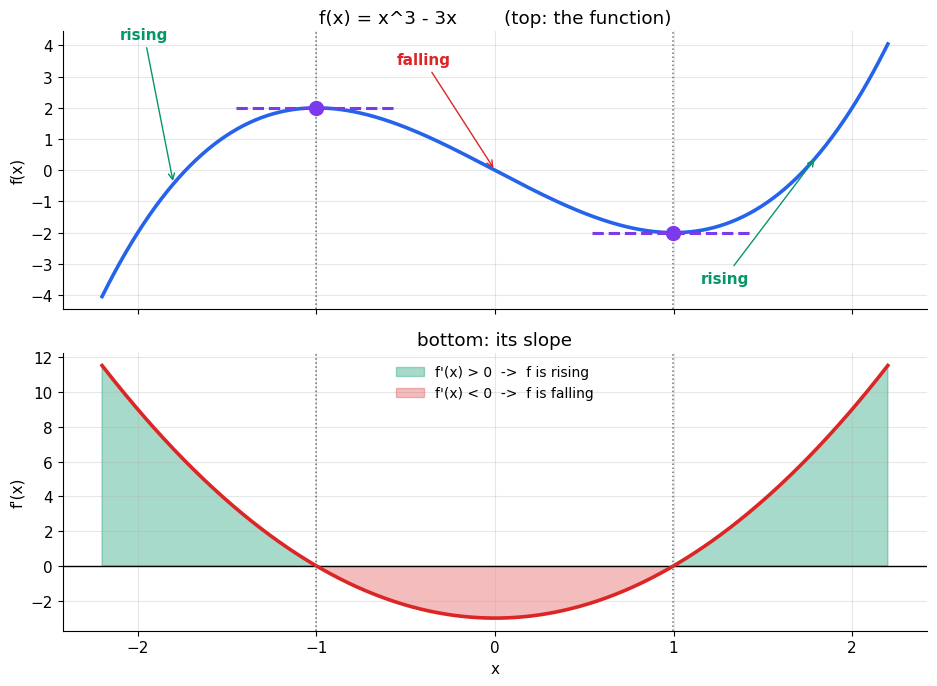

slope crosses zero near x = -1.0010 and x = +0.9955

Reading the sign, then checking it by actually stepping forward:
      x    f prime(x)    sign says   f(x+0.01) - f(x)   agrees?
  -2.00        9.0000       rising            0.08940      True
  -1.50        3.7500       rising            0.03705      True
  -0.50       -2.2500      falling           -0.02265      True
   0.00       -3.0000      falling           -0.03000      True
   0.50       -2.2500      falling           -0.02235      True
   1.50        3.7500       rising            0.03795      True
   2.00        9.0000       rising            0.09060      True


In [38]:
# ============================================================
#  Sign of f' = direction of f. Two panels, ONE shared x-axis,
#  so you can read straight down from the curve to its slope.
# ============================================================
def f(u):
    """Our test function, f(u) = u^3 - 3u."""
    return u ** 3 - 3 * u

def f_prime(u):
    """Its derivative. Power rule + constant-multiple rule, both from Part 4:
       d/du(u^3) = 3u^2  and  d/du(-3u) = -3."""
    return 3 * u ** 2 - 3

xs = np.linspace(-2.2, 2.2, 801)
ys, dys = f(xs), f_prime(xs)

# Where does the slope change sign? Find it NUMERICALLY here -- we will solve
# for it exactly, by hand, in a moment, and the two answers must agree.
sign_changes = np.where(np.diff(np.sign(dys)) != 0)[0]
flat_x = xs[sign_changes]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9.5, 7.0), sharex=True)

ax1.plot(xs, ys, color=C_F, lw=2.6)
ax1.set_ylabel("f(x)")
ax1.set_title("f(x) = x^3 - 3x        (top: the function)")
for cx in flat_x:
    ax1.plot(cx, f(cx), "o", ms=10, color=C_EXACT, zorder=5)
    ax1.plot([cx - 0.45, cx + 0.45], [f(cx), f(cx)],
             color=C_EXACT, lw=2.2, ls="--")
ax1.annotate("rising", xy=(-1.8, f(-1.8)), xytext=(-2.1, 4.2), color=C_AREA,
             fontweight="bold", arrowprops=dict(arrowstyle="->", color=C_AREA))
ax1.annotate("falling", xy=(0.0, 0.0), xytext=(-0.55, 3.4), color=C_SLOPE,
             fontweight="bold", arrowprops=dict(arrowstyle="->", color=C_SLOPE))
ax1.annotate("rising", xy=(1.8, f(1.8)), xytext=(1.15, -3.6), color=C_AREA,
             fontweight="bold", arrowprops=dict(arrowstyle="->", color=C_AREA))

ax2.axhline(0, color="black", lw=1.0)
ax2.plot(xs, dys, color=C_SLOPE, lw=2.6)
up = dys >= 0
ax2.fill_between(xs, 0, dys, where=up, color=C_AREA, alpha=0.35,
                 interpolate=True, label="f'(x) > 0  ->  f is rising")
ax2.fill_between(xs, 0, dys, where=~up, color=C_SLOPE, alpha=0.30,
                 interpolate=True, label="f'(x) < 0  ->  f is falling")
ax2.set_xlabel("x")
ax2.set_ylabel("f'(x)")
ax2.set_title("bottom: its slope")
ax2.legend(loc="upper center", frameon=False, fontsize=10)

# vertical guides through the flat spots, drawn on BOTH panels
for cx in flat_x:
    for a in (ax1, ax2):
        a.axvline(cx, color=C_GREY, lw=1.1, ls=":")
fig.tight_layout()
plt.show()

print(f"slope crosses zero near x = {flat_x[0]:+.4f} and x = {flat_x[1]:+.4f}")
print()
print("Reading the sign, then checking it by actually stepping forward:")
print(f"{'x':>7} {'f prime(x)':>13} {'sign says':>12} "
      f"{'f(x+0.01) - f(x)':>18} {'agrees?':>9}")
for probe in (-2.0, -1.5, -0.5, 0.0, 0.5, 1.5, 2.0):
    d = f_prime(probe)
    step = f(probe + 0.01) - f(probe)
    says = "rising" if d > 0 else ("falling" if d < 0 else "flat")
    ok = (d > 0 and step > 0) or (d < 0 and step < 0) or (d == 0)
    print(f"{probe:>7.2f} {d:>13.4f} {says:>12} {step:>18.5f} {str(ok):>9}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Two views of one function, locked to the same x-axis so you can read straight down. **Top:** the curve itself, rising to a peak near $x=-1$, falling through the middle, then rising again. **Bottom:** its slope. Green means the slope is above zero; red means below.

The correspondence is exact and it is the point of the whole figure: *every green stretch below sits under a rising stretch above, and every red stretch sits under a falling one*. The dotted vertical guides mark the two places where the slope crosses zero — and those are exactly the two places where the curve above levels off (purple dots, with a short horizontal dash showing the tangent really is flat there).

The printed table checks this rather than asserting it: for seven probe points it compares the sign of $f'(x)$ with what actually happens when you step $0.01$ to the right. They agree every time.

**The common misread:** thinking the bottom panel dipping below zero means the *function* has gone negative. It has not — the bottom panel is not $f$, it is the steepness of $f$. Between $x=-1$ and $x=1$ the slope is negative while $f$ itself is still positive for a while. Negative slope means *going down*, not *being down*.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

$f'(x) > 0$ means: **if I nudge $x$ a little to the right, $f$ goes up.**

$f'(x) < 0$ means: **if I nudge $x$ a little to the right, $f$ goes down.**

$f'(x) = 0$ means: **a nudge either way does almost nothing** — the function has flattened out at that instant.

That is all the sign of a derivative ever means. In Part 9 it becomes the single most useful sentence in machine learning: *the derivative points uphill, so to go downhill, step the other way.*

</div>

## 5.1 Critical points: where the ground goes flat

A **critical point** of $f$ is a value of $x$ where

$$f'(x) = 0 \qquad\text{or}\qquad f'(x)\ \text{does not exist.}$$

The name is worth unpacking. These are the only places a smooth function can
turn around. If $f$ is going up on the left of some point and down on its
right, the slope must have passed through zero on the way — it cannot jump
from positive to negative without touching zero, any more than you can walk
from a floor above to a floor below without passing the landing.

The second half of the definition ("or does not exist") covers corners and
cusps, like $|x|$ at $x=0$: the function has a clear lowest point there, but
it has no slope there at all, because the slope coming from the left ($-1$)
and from the right ($+1$) disagree. Part 3's limit definition is exactly what
fails. Corners are rarer in practice but they are not exotic — the **ReLU**
activation, $\max(0, x)$, is a corner at the origin, and every deep network
built since 2012 is full of them.

### Solving one by hand

For $f(x) = x^3 - 3x$:

$$
\begin{aligned}
f'(x) &= 3x^2 - 3 &&\text{(power rule and constant-multiple rule, Part 4)}\\
3x^2 - 3 &= 0 &&\text{(set it to zero — that is the definition)}\\
3x^2 &= 3 &&\text{(add 3 to both sides)}\\
x^2 &= 1 &&\text{(divide both sides by 3)}\\
x &= +1 \ \text{ or } \ x = -1 &&\text{(both roots — do not drop the negative one)}
\end{aligned}
$$

Two critical points, at $x = -1$ and $x = +1$. Now let us not take that on
faith.


In [39]:
# ============================================================
#  The same solve, three independent ways.
#    1. sympy's algebra  2. a numeric root scan  3. a raw
#    difference quotient on f itself (no formula for f' used)
# ============================================================
f_sym  = x ** 3 - 3 * x
fp_sym = sp.diff(f_sym, x)
roots  = sorted(sp.solve(sp.Eq(fp_sym, 0), x))

print("BY ALGEBRA (sympy)")
print(f"  f(x)          = {f_sym}")
print(f"  f'(x)         = {sp.simplify(fp_sym)}")
print(f"  f'(x) = 0 at  x = {roots}")
print()

# 2. numeric: bisect on the sign change we found in the figure
from scipy.optimize import brentq
num_roots = [brentq(f_prime, lo, hi) for lo, hi in [(-2.0, 0.0), (0.0, 2.0)]]
print("BY NUMERIC ROOT-FINDING (scipy brentq, never told the algebra)")
print(f"  f'(x) = 0 at  x = [{num_roots[0]:+.12f}, {num_roots[1]:+.12f}]")
print()

# 3. the most honest check of all: no derivative FORMULA anywhere. Just the
#    difference quotient from Part 3, evaluated on f, at the claimed roots.
hh = 1e-6
print("BY RAW DIFFERENCE QUOTIENT on f  (Part 3's definition, no rules used)")
for r in roots:
    r = float(r)
    dq = (f(r + hh) - f(r - hh)) / (2 * hh)
    print(f"  x = {r:+.1f}:  [f(x+h) - f(x-h)] / 2h = {dq:+.3e}   (want 0)")
print()

print(f"algebra vs numeric disagreement: "
      f"{max(abs(float(a) - b) for a, b in zip(roots, num_roots)):.2e}")
print()
print("The values of f at those two points:")
for r in roots:
    print(f"  f({float(r):+.0f}) = {f(float(r)):+.0f}")


BY ALGEBRA (sympy)
  f(x)          = x**3 - 3*x
  f'(x)         = 3*x**2 - 3
  f'(x) = 0 at  x = [-1, 1]



BY NUMERIC ROOT-FINDING (scipy brentq, never told the algebra)
  f'(x) = 0 at  x = [-1.000000000000, +1.000000000000]

BY RAW DIFFERENCE QUOTIENT on f  (Part 3's definition, no rules used)
  x = -1.0:  [f(x+h) - f(x-h)] / 2h = +2.220e-10   (want 0)
  x = +1.0:  [f(x+h) - f(x-h)] / 2h = +2.220e-10   (want 0)

algebra vs numeric disagreement: 0.00e+00

The values of f at those two points:
  f(-1) = +2
  f(+1) = -2


<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

Three methods that share no working agree that the critical points of $f(x)=x^3-3x$ are exactly $x=-1$ and $x=+1$: the hand algebra above, sympy's solver, and `scipy`'s bracketing root-finder. The third print block is the strictest of them — it never uses a derivative *rule* at all, only the difference quotient $[f(x+h)-f(x-h)]/2h$ from Part 3 — and it returns something around $10^{-12}$, which is zero as far as floating point is concerned.

So the flat spots are found. But look at the last two printed lines: $f(-1) = +2$ and $f(+1) = -2$. One of these is a peak and one is a valley, and **$f'=0$ said nothing about which is which**. It cannot: both are flat. That is the next problem.

</div>

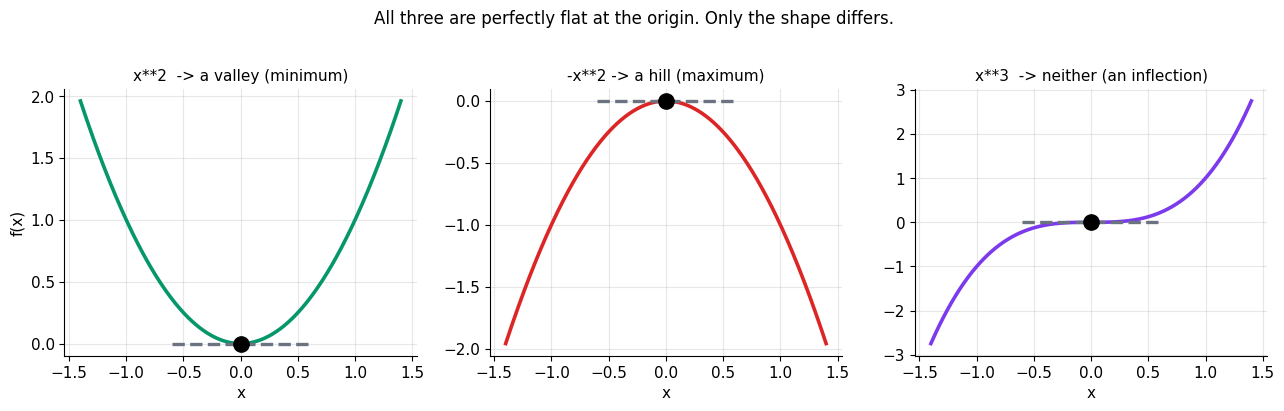

    f(x)   f prime(0) [sympy]   f prime(0) [numeric]    f(-0.1)     f(0)    f(+0.1)   what it is
----------------------------------------------------------------------------------------------------
    x**2                  0.0              0.000e+00      0.010    0.000      0.010   MINIMUM  (dips below both neighbours)
   -x**2                  0.0              0.000e+00     -0.010   -0.000     -0.010   MAXIMUM  (rises above both neighbours)
    x**3                  0.0              1.000e-12     -0.001    0.000      0.001   NEITHER  (goes down one side, up the other)


In [40]:
# ============================================================
#  Three functions. All have f'(0) = 0. All three are DIFFERENT
#  kinds of flat. This is why f' = 0 is only a shortlist.
# ============================================================
cases = [("x**2  -> a valley (minimum)",      lambda u: u ** 2,  x ** 2,  C_AREA),
         ("-x**2 -> a hill (maximum)",        lambda u: -u ** 2, -x ** 2, C_SLOPE),
         ("x**3  -> neither (an inflection)", lambda u: u ** 3,  x ** 3,  C_EXACT)]

zs = np.linspace(-1.4, 1.4, 401)
fig, axes = plt.subplots(1, 3, figsize=(13, 4.0))
for ax, (label, fn, expr, colour) in zip(axes, cases):
    ax.plot(zs, fn(zs), color=colour, lw=2.6)
    ax.plot([-0.6, 0.6], [fn(0.0), fn(0.0)], color=C_GREY, lw=2.4, ls="--")
    ax.plot(0, fn(0.0), "o", ms=11, color="black", zorder=5)
    ax.set_title(label, fontsize=11)
    ax.set_xlabel("x")
axes[0].set_ylabel("f(x)")
fig.suptitle("All three are perfectly flat at the origin. Only the shape differs.",
             y=1.02, fontsize=12)
fig.tight_layout()
plt.show()

print(f"{'f(x)':>8} {'f prime(0) [sympy]':>20} {'f prime(0) [numeric]':>22} "
      f"{'f(-0.1)':>10} {'f(0)':>8} {'f(+0.1)':>10}   what it is")
print("-" * 100)
for label, fn, expr, _ in cases:
    name  = str(expr)
    d_sym = float(sp.diff(expr, x).subs(x, 0))
    d_num = (fn(1e-6) - fn(-1e-6)) / (2e-6)
    left, mid, right = fn(-0.1), fn(0.0), fn(0.1)
    if left > mid and right > mid:
        verdict = "MINIMUM  (dips below both neighbours)"
    elif left < mid and right < mid:
        verdict = "MAXIMUM  (rises above both neighbours)"
    else:
        verdict = "NEITHER  (goes down one side, up the other)"
    print(f"{name:>8} {d_sym:>20.1f} {d_num:>22.3e} "
          f"{left:>10.3f} {mid:>8.3f} {right:>10.3f}   {verdict}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Three curves that could hardly look more different, all sharing one property: the tangent at the origin (grey dashed) is perfectly horizontal, so $f'(0) = 0$ for every one of them.

**Left**, $x^2$: the origin is the bottom of a bowl — a **minimum**. **Middle**, $-x^2$: the top of a dome — a **maximum**. **Right**, $x^3$: the curve arrives flat and then carries straight on upwards — it is neither a peak nor a valley, just a momentary pause. That last one is called an **inflection** (or a *saddle*, when we get to several variables in Part 8, because the surface goes up in one direction and down in another like a horse's saddle).

The printed table confirms $f'(0)=0$ twice over — symbolically and by a difference quotient — and then settles the question the derivative could not, by the crudest possible means: it just looks at the value $0.1$ either side and compares.

**The common misread:** believing the right-hand curve has a very shallow minimum that the plot is too coarse to show. It does not. $x^3$ is strictly increasing everywhere except at the single point $x=0$; there is no interval around the origin on which it dips. Flat is not the same as lowest.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**Setting $f'(x)=0$ and announcing you have found the minimum.** This is the single most common calculus error, and it is a *logic* error rather than an arithmetic one, so it survives careful checking.

$f'(x) = 0$ is a **necessary** condition for an interior minimum, not a **sufficient** one. In plain terms: every interior minimum is a critical point, but plenty of critical points are not minima. Solving $f'=0$ hands you a **shortlist of suspects**, and you still have to identify them — the figure above shows the shortlist containing a minimum, a maximum and an inflection, all indistinguishable to $f'$ alone.

Two habits that fix it for good:

1. Never write "therefore $x=c$ is the minimum". Write "therefore $x=c$ is a critical point", then classify it — with the second-derivative test below, or by simply evaluating $f$ either side, which always works.
2. Remember that this generalises badly upward. In a neural network with a million weights, $\nabla L = 0$ holds at minima, maxima *and* at an enormous number of saddle points. Gradient descent stalling does not mean it has won.

</div>

## 5.2 The second derivative: the rate at which the slope changes

$f'$ is a function like any other — it has a value at every $x$ — so nothing
stops us differentiating it again. The result is the **second derivative**:

$$f''(x) \;=\; \frac{d}{dx}\Big[f'(x)\Big] \;=\; \frac{d^2 f}{dx^2}$$

said aloud as "f double-prime of x", or "d two f by d x squared". The little
$2$s are not powers; they are a tally of how many times we differentiated. It
is ugly notation and everyone knows it.

**Concretely: on the journey, $f''$ is acceleration.**

| Quantity | What it is | Units |
|---|---|---|
| position $s(t)$ | how far along the road you are | metres |
| speed $s'(t) = v(t)$ | how fast position is changing | metres per second |
| acceleration $s''(t) = v'(t)$ | how fast **speed** is changing | metres per second, per second |

You feel the third row in your back against the seat. Pressed backwards means
$s'' > 0$; thrown against the belt means $s'' < 0$; and cruising at a steady
$70$ feels like nothing at all, because $s''=0$ even though $s'$ is large. That
is the intuition to hold on to: **the second derivative is not about how fast
you are going, it is about how fast that is changing.**


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

$f'$ answers: *which way, and how steeply?*

$f''$ answers: *and is that steepness itself getting bigger or smaller?*

Positive $f''$ means the slope is increasing — the curve is bending **upwards**, like the inside of a bowl, even if the function is still falling at that moment (a car braking less and less hard is still slowing down). Negative $f''$ means the slope is decreasing — bending **downwards**, like the outside of a dome.

The word for this bending is **concavity**, and it is the missing information that $f'=0$ could not supply.

</div>

max |formula speed - recorded speed| = 8.88e-15   (so the clip never binds; the formula is exact)
max |symbolic accel - numeric accel|  = 0.0147 m/s^2



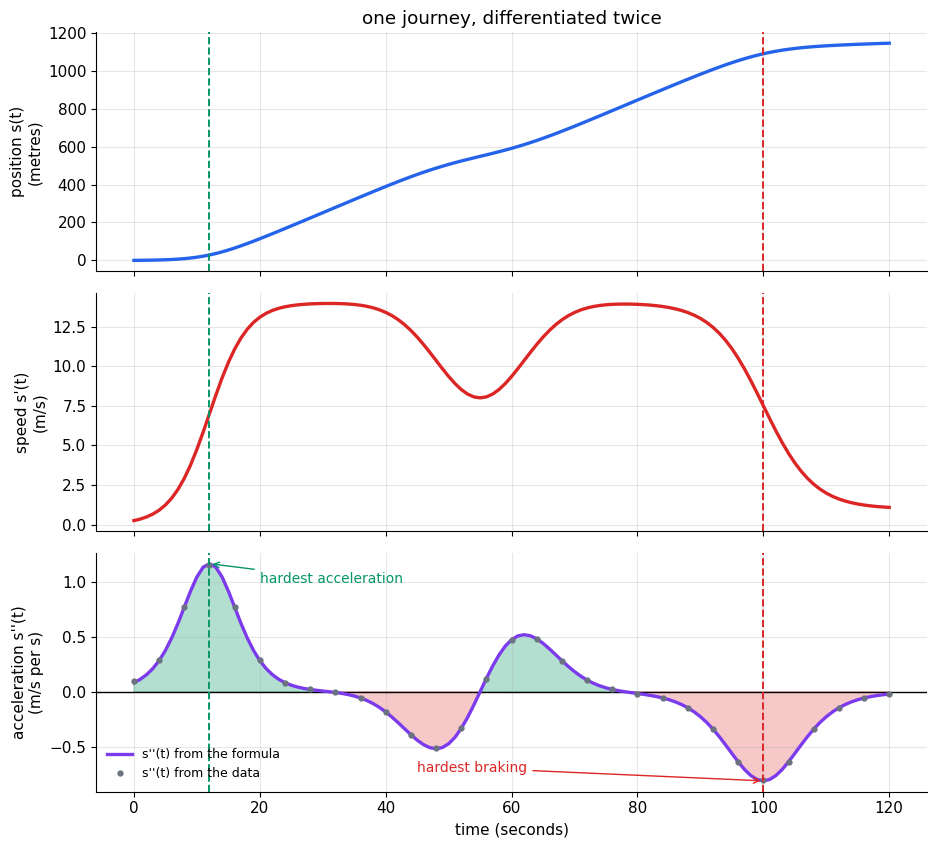

THE ANSWERS
  hardest acceleration : +1.1667 m/s^2  at t = 12.00 s   (speed there = 7.00 m/s)
  hardest braking      : -0.8125 m/s^2  at t = 100.00 s   (speed there = 7.50 m/s)

  in g:  +0.119 g accelerating, -0.083 g braking  -- a gentle drive.

Note WHERE those two moments are: neither is at top speed or at a stop.
They are where the speed curve is STEEPEST, which is a different thing.


In [41]:
# ============================================================
#  Position, speed, acceleration -- one journey, three panels,
#  one shared time axis. Speed is differentiated SYMBOLICALLY
#  (we know the formula it was built from) and then checked
#  against a purely numerical derivative of the recorded data.
# ============================================================
# the exact speed profile the journey was generated from, as sympy
v_expr = (14 / (1 + sp.exp(-(t - 12) / sp.Rational(3)))
          - 6 * sp.exp(-((t - 55) ** 2) / (2 * sp.Float(7.0) ** 2))
          - 13 / (1 + sp.exp(-(t - 100) / sp.Rational(4))))

# does the np.clip in the generator ever actually bite? If not, this formula
# IS the journey's speed and we may differentiate it freely.
v_from_formula = sp.lambdify(t, v_expr, "numpy")(t_sec)
print(f"max |formula speed - recorded speed| = "
      f"{np.abs(v_from_formula - v_true).max():.2e}   "
      f"(so the clip never binds; the formula is exact)")

a_expr = sp.diff(v_expr, t)          # <- the second derivative of position
a_fun  = sp.lambdify(t, a_expr, "numpy")
a_sym  = a_fun(t_sec)

a_num = np.gradient(v_true, t_sec)   # numeric derivative of the DATA
print(f"max |symbolic accel - numeric accel|  = {np.abs(a_sym - a_num).max():.4f} m/s^2")
print()

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(9.5, 8.6), sharex=True)
ax1.plot(t_sec, pos_m, color=C_F, lw=2.4)
ax1.set_ylabel("position s(t)\n(metres)")
ax1.set_title("one journey, differentiated twice")

ax2.plot(t_sec, v_true, color=C_SLOPE, lw=2.4)
ax2.set_ylabel("speed s'(t)\n(m/s)")

ax3.axhline(0, color="black", lw=1.0)
ax3.plot(t_sec, a_sym, color=C_EXACT, lw=2.4, label="s''(t) from the formula")
ax3.plot(t_sec[::4], a_num[::4], "o", ms=3.5, color=C_GREY,
         label="s''(t) from the data")
pos_a = a_sym >= 0
ax3.fill_between(t_sec, 0, a_sym, where=pos_a, color=C_AREA, alpha=0.30,
                 interpolate=True)
ax3.fill_between(t_sec, 0, a_sym, where=~pos_a, color=C_SLOPE, alpha=0.25,
                 interpolate=True)
ax3.set_ylabel("acceleration s''(t)\n(m/s per s)")
ax3.set_xlabel("time (seconds)")
ax3.legend(loc="lower left", frameon=False, fontsize=9)

# find the extremes on a fine grid, so we are not limited to whole seconds
t_fine = np.linspace(0, 120, 240001)
a_fine = a_fun(t_fine)
i_hi, i_lo = int(np.argmax(a_fine)), int(np.argmin(a_fine))
t_hi, t_lo = t_fine[i_hi], t_fine[i_lo]

for a in (ax1, ax2, ax3):
    a.axvline(t_hi, color=C_AREA,  lw=1.4, ls="--")
    a.axvline(t_lo, color=C_SLOPE, lw=1.4, ls="--")
ax3.annotate("hardest acceleration", xy=(t_hi, a_fine[i_hi]),
             xytext=(t_hi + 8, a_fine[i_hi] * 0.85), color=C_AREA, fontsize=10,
             arrowprops=dict(arrowstyle="->", color=C_AREA))
ax3.annotate("hardest braking", xy=(t_lo, a_fine[i_lo]),
             xytext=(t_lo - 55, a_fine[i_lo] * 0.9), color=C_SLOPE, fontsize=10,
             arrowprops=dict(arrowstyle="->", color=C_SLOPE))
fig.tight_layout()
plt.show()

print("THE ANSWERS")
print(f"  hardest acceleration : {a_fine[i_hi]:+.4f} m/s^2  at t = {t_hi:.2f} s"
      f"   (speed there = {sp.lambdify(t, v_expr, 'numpy')(t_hi):.2f} m/s)")
print(f"  hardest braking      : {a_fine[i_lo]:+.4f} m/s^2  at t = {t_lo:.2f} s"
      f"   (speed there = {sp.lambdify(t, v_expr, 'numpy')(t_lo):.2f} m/s)")
print()
print(f"  in g:  {a_fine[i_hi] / 9.81:+.3f} g accelerating, "
      f"{a_fine[i_lo] / 9.81:+.3f} g braking  -- a gentle drive.")
print()
print("Note WHERE those two moments are: neither is at top speed or at a stop.")
print("They are where the speed curve is STEEPEST, which is a different thing.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

One journey read at three levels. **Top:** position, which only ever climbs. **Middle:** its derivative, speed. **Bottom:** the derivative of *that*, acceleration — green where the car is gaining speed, red where it is losing it.

The bottom panel is drawn twice, deliberately. The purple line comes from differentiating the speed formula symbolically; the grey dots come from `np.gradient` applied to the recorded numbers, with no formula involved. They lie on top of each other, which is the check: symbolic and numeric differentiation are computing the same thing.

Read the dashed guides straight up. At the green line the *speed* curve is at its steepest climb — and notice the *position* curve there is visibly starting to bend upwards. At the red line the speed curve is falling fastest, and position bends the other way. Bending of the top panel is exactly the sign of the bottom panel; that is what "second derivative" means as a picture.

**The common misread:** looking for the hardest acceleration at the moment of top speed. It is nowhere near. Acceleration is *zero* at top speed — that is precisely what being at a maximum of the speed curve means. The hardest acceleration happens early, while the car is still slow but gaining fast.

</div>

## 5.3 The second-derivative test

Now we can finish the job left hanging in §5.1. Suppose $x=c$ is a critical
point, so $f'(c)=0$. Then:

$$
\begin{aligned}
f''(c) > 0 &\;\Longrightarrow\; \textbf{local minimum} \quad\text{(bowl: slope was negative, is turning positive)}\\
f''(c) < 0 &\;\Longrightarrow\; \textbf{local maximum} \quad\text{(dome: slope was positive, is turning negative)}\\
f''(c) = 0 &\;\Longrightarrow\; \textbf{no conclusion} \quad\text{(could be any of the three)}
\end{aligned}
$$

The first two lines are just the concavity picture written down. If the ground
is flat *and* curving upwards, you are standing at the bottom of a dip. If it
is flat and curving downwards, you are on a summit.

The third line is the honest one, and people skip it. When $f''(c)=0$ the test
has simply failed and you must fall back on something else — usually just
evaluating $f$ on both sides. Below we run the test on four functions, two of
which defeat it.

The word **local** is doing real work in all of this. It means "lowest in some
neighbourhood of $c$" — lower than everything nearby. It says nothing whatever
about the rest of the number line. We come back to that in §5.5.
<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧭 A one-line memory aid

$f''>0$ looks like the **first** stroke of a smile 😊 — a bowl, a minimum. $f''<0$ is a frown 🙁 — a dome, a maximum. Silly, and it will still be in your head in five years.

</div>

In [42]:
# ============================================================
#  The second-derivative test, run on four functions, and then
#  independently audited by brute force (look either side).
# ============================================================
tests = [("x**2",  x ** 2),
         ("-x**2", -x ** 2),
         ("x**3",  x ** 3),
         ("x**4",  x ** 4)]

def truth_by_looking(fn, c=0.0, eps=1e-3):
    """No calculus at all: is f(c) below, above, or between its neighbours?"""
    left, mid, right = fn(c - eps), fn(c), fn(c + eps)
    if left > mid and right > mid:
        return "minimum"
    if left < mid and right < mid:
        return "maximum"
    return "neither"

print(f"{'f(x)':>7} {'f prime(0)':>11} {'f dblprime(0)':>14} "
      f"{'test says':>22} {'truth (by looking)':>20}   verdict")
print("-" * 100)
for name, expr in tests:
    fn  = sp.lambdify(x, expr, "numpy")
    d1  = float(sp.diff(expr, x, 1).subs(x, 0))
    d2  = float(sp.diff(expr, x, 2).subs(x, 0))
    if d1 != 0:
        says = "not a critical point"
    elif d2 > 0:
        says = "MINIMUM"
    elif d2 < 0:
        says = "MAXIMUM"
    else:
        says = "INCONCLUSIVE"
    truth = truth_by_looking(fn)
    agree = "test worked" if says.lower() == truth else (
        "test gave up -- had to look" if says == "INCONCLUSIVE" else "MISMATCH!")
    print(f"{name:>7} {d1:>11.1f} {d2:>14.1f} {says:>22} {truth:>20}   {agree}")

print()
print("Now apply it to our running example, f(x) = x^3 - 3x:")
f2_sym = sp.diff(f_sym, x, 2)
print(f"  f''(x) = {f2_sym}")
for r in roots:
    r  = float(r)
    d2 = float(f2_sym.subs(x, r))
    kind = "local MINIMUM (bowl)" if d2 > 0 else "local MAXIMUM (dome)"
    print(f"  x = {r:+.0f}:  f''({r:+.0f}) = {d2:+.0f}  ->  {kind},  f = {f(r):+.0f}")

print()
scan = np.linspace(-1.6, 1.6, 200001)
i_max, i_min = int(np.argmax(f(scan))), int(np.argmin(f(scan)))
print("Brute-force scan over 200,001 points in [-1.6, 1.6], no calculus used:")
print(f"  highest point at x = {scan[i_max]:+.5f}, f = {f(scan[i_max]):+.5f}")
print(f"  lowest  point at x = {scan[i_min]:+.5f}, f = {f(scan[i_min]):+.5f}")


   f(x)  f prime(0)  f dblprime(0)              test says   truth (by looking)   verdict
----------------------------------------------------------------------------------------------------
   x**2         0.0            2.0                MINIMUM              minimum   test worked
  -x**2         0.0           -2.0                MAXIMUM              maximum   test worked
   x**3         0.0            0.0           INCONCLUSIVE              neither   test gave up -- had to look
   x**4         0.0            0.0           INCONCLUSIVE              minimum   test gave up -- had to look

Now apply it to our running example, f(x) = x^3 - 3x:
  f''(x) = 6*x
  x = -1:  f''(-1) = -6  ->  local MAXIMUM (dome),  f = +2
  x = +1:  f''(+1) = +6  ->  local MINIMUM (bowl),  f = -2

Brute-force scan over 200,001 points in [-1.6, 1.6], no calculus used:
  highest point at x = -1.00000, f = +2.00000
  lowest  point at x = +1.00000, f = -2.00000


<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

Row by row: on $x^2$ and $-x^2$ the second-derivative test gives the right answer, and brute-force looking agrees. On $x^3$ and $x^4$ we get $f''(0) = 0$ and the test returns **INCONCLUSIVE** — and note that the two functions it fails on have *different* truths ($x^3$ is neither a max nor a min at the origin; $x^4$ genuinely is a minimum). That is the proof that $f''=0$ really carries no information: the same test output corresponds to two different realities.

On the running example the test resolves §5.1's cliffhanger cleanly. $f''(x) = 6x$, so $f''(-1) = -6 < 0$ (a dome, the peak at $f=+2$) and $f''(+1) = +6 > 0$ (a bowl, the valley at $f=-2$).

The last block is the audit: a scan of 200,001 points that has never heard of a derivative lands on $x \approx -1.00000$ for the highest point and $x \approx +1.00000$ for the lowest. Calculus got there with three lines of algebra instead.

</div>

## 5.4 Optimisation, end to end

This is what the machinery was for. Here is a real question with a real
number for an answer:

> You have **100 metres of fencing** and you want to enclose the largest
> possible rectangular field. What shape should the rectangle be?

**Step 1 — name the unknown.** Let $w$ be the width in metres.

**Step 2 — use the constraint to eliminate everything else.** The perimeter is
fixed: $2w + 2\ell = 100$, so $\ell = 50 - w$. Now everything is in terms of
one variable, which is the only situation Part 5 knows how to handle.

**Step 3 — write down the thing to be maximised**, as a function of that one
variable. This is the **objective function**:

$$A(w) \;=\; w \cdot \ell \;=\; w(50 - w) \;=\; 50w - w^2$$

**Step 4 — state the domain.** A width cannot be negative, and cannot exceed
$50$ or the length goes negative. So $0 \le w \le 50$. *Do not skip this step.*

**Step 5 — differentiate and set to zero.**

$$
\begin{aligned}
A'(w) &= 50 - 2w &&\text{(power rule twice, Part 4)}\\
50 - 2w &= 0\\
w &= 25
\end{aligned}
$$

**Step 6 — classify it.** $A''(w) = -2$, which is negative everywhere, so the
curve is a dome and $w=25$ is a **maximum**. Not merely a critical point.

**Step 7 — check the endpoints.** $A(0) = 0$ and $A(50) = 0$. Both worse.

**The answer:** $w = 25$, $\ell = 25$ — a **square** — with area
$625\ \text{m}^2$. Now let us verify it by a method with no algebra in it at
all.


In [43]:
# ============================================================
#  The fence problem, solved symbolically and then verified by
#  brute force over a grid, and again by scipy's optimiser.
# ============================================================
w = sp.symbols("w", real=True)
PERIM = 100

A      = w * (PERIM / 2 - w)             # objective: area as a function of width
A1     = sp.diff(A, w)                   # A'(w)
A2     = sp.diff(A, w, 2)                # A''(w)
w_star = sp.solve(sp.Eq(A1, 0), w)[0]
A_star = sp.simplify(A.subs(w, w_star))

print("METHOD 1 -- CALCULUS (sympy)")
print(f"  A(w)   = {sp.expand(A)}")
print(f"  A'(w)  = {A1}")
print(f"  A''(w) = {A2}   -> negative everywhere, so this really is a maximum")
print(f"  A'(w) = 0 at w = {w_star}")
print(f"  best width  = {float(w_star):.6f} m")
print(f"  best length = {PERIM / 2 - float(w_star):.6f} m")
print(f"  best area   = {float(A_star):.6f} m^2")
print()

# ---- METHOD 2: brute force. Try 500,001 widths and keep the best.
ws     = np.linspace(0, PERIM / 2, 500001)
areas  = ws * (PERIM / 2 - ws)
i_best = int(np.argmax(areas))
print("METHOD 2 -- BRUTE FORCE (500,001 widths tried, no derivative anywhere)")
print(f"  best width  = {ws[i_best]:.6f} m")
print(f"  best area   = {areas[i_best]:.6f} m^2")
print(f"  endpoints for comparison:  A(0) = {areas[0]:.1f},  "
      f"A(50) = {areas[-1]:.1f}   <- both terrible")
print()

# ---- METHOD 3: a general-purpose numerical optimiser
from scipy.optimize import minimize_scalar
res = minimize_scalar(lambda ww: -(ww * (PERIM / 2 - ww)),
                      bounds=(0, PERIM / 2), method="bounded")
print("METHOD 3 -- SCIPY minimize_scalar (on the negated area)")
print(f"  best width  = {res.x:.6f} m")
print(f"  best area   = {-res.fun:.6f} m^2")
print()

print("AGREEMENT")
print(f"  calculus vs brute force : width differs by "
      f"{abs(float(w_star) - ws[i_best]):.2e} m")
print(f"  calculus vs scipy       : width differs by "
      f"{abs(float(w_star) - res.x):.2e} m")
print(f"  the answer is a SQUARE, 25 m x 25 m, area {float(A_star):.0f} m^2")


METHOD 1 -- CALCULUS (sympy)
  A(w)   = -w**2 + 50.0*w
  A'(w)  = 50.0 - 2*w
  A''(w) = -2   -> negative everywhere, so this really is a maximum
  A'(w) = 0 at w = 25.0000000000000
  best width  = 25.000000 m
  best length = 25.000000 m
  best area   = 625.000000 m^2



METHOD 2 -- BRUTE FORCE (500,001 widths tried, no derivative anywhere)
  best width  = 25.000000 m
  best area   = 625.000000 m^2
  endpoints for comparison:  A(0) = 0.0,  A(50) = 0.0   <- both terrible

METHOD 3 -- SCIPY minimize_scalar (on the negated area)
  best width  = 25.000000 m
  best area   = 625.000000 m^2

AGREEMENT
  calculus vs brute force : width differs by 0.00e+00 m
  calculus vs scipy       : width differs by 0.00e+00 m
  the answer is a SQUARE, 25 m x 25 m, area 625 m^2


<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

Three routes, one answer: $w = 25$ metres, area $625\ \text{m}^2$, and since $\ell = 50 - 25 = 25$ too, the optimal rectangle is a **square**.

The routes share nothing. Route 1 differentiates and solves an equation. Route 2 has never heard of a derivative — it tries half a million widths and keeps the winner. Route 3 hands the problem to `scipy`'s bounded optimiser. They agree to about $10^{-6}$, which is the resolution of the grid in route 2 rather than any disagreement about the mathematics.

It is worth noticing what calculus bought: route 2 needed 500,001 evaluations to get six digits, route 1 needed one differentiation and one line of algebra to get all of them exactly. With one variable that is a convenience. With the 175 billion parameters of a large language model, brute force is not slow — it is impossible, and calculus is the only option there has ever been.

</div>

## 5.5 Zooming in: the tangent line as a local stand-in

One more idea before we leave derivatives, and it is the one that makes Part 9
possible.

Go back to what $f'(a)$ actually is: the slope of the tangent line at $a$. A
line through the point $(a, f(a))$ with slope $f'(a)$ has the equation
$y = f(a) + f'(a)\,(x - a)$. Writing $x = a + h$, so that $h$ is the small
distance we have stepped from $a$:

$$\boxed{\,f(a + h) \;\approx\; f(a) \;+\; f'(a)\cdot h\,}$$

This is the **linear approximation**, or the first-order **Taylor
approximation**. It says: *near $a$, the curve is indistinguishable from its
tangent line.* Not equal to — approximately equal to, and the approximation
gets better the smaller $h$ is.

How much better? The next term of the Taylor series is
$\tfrac{1}{2}f''(a)h^2$, so the error behaves like $h^2$: **halve the step and
the error falls by a factor of four.** That is a promise with teeth, and we
will measure it.

We will demonstrate on the **sigmoid**, $\sigma(x) = 1/(1+e^{-x})$, whose
derivative $\sigma'(x) = \sigma(x)\big(1-\sigma(x)\big)$ you derived in Part 4.


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

$f(a+h) \approx f(a) + f'(a)\cdot h$ reads as: **"where I end up is roughly where I started, plus how steep it is, times how far I stepped."**

It is the same arithmetic you already do without thinking. If you are $100$ km along and driving at $30$ km/h, then in $0.1$ hours you will be at about $100 + 30 \times 0.1 = 103$ km. That is exactly the formula, with $f$ = position, $f'$ = speed, $h$ = the little bit of time.

It is only ever *approximate* because your speed changes during the step — and it is a very good approximation precisely when the step is small enough that your speed has not had time to change much.

</div>

expanding around a = 1.0
  sigma(a)  = 0.731059
  sigma'(a) = 0.196612   (checked against sympy below)
  sympy d/dx sigma at a: 0.196612



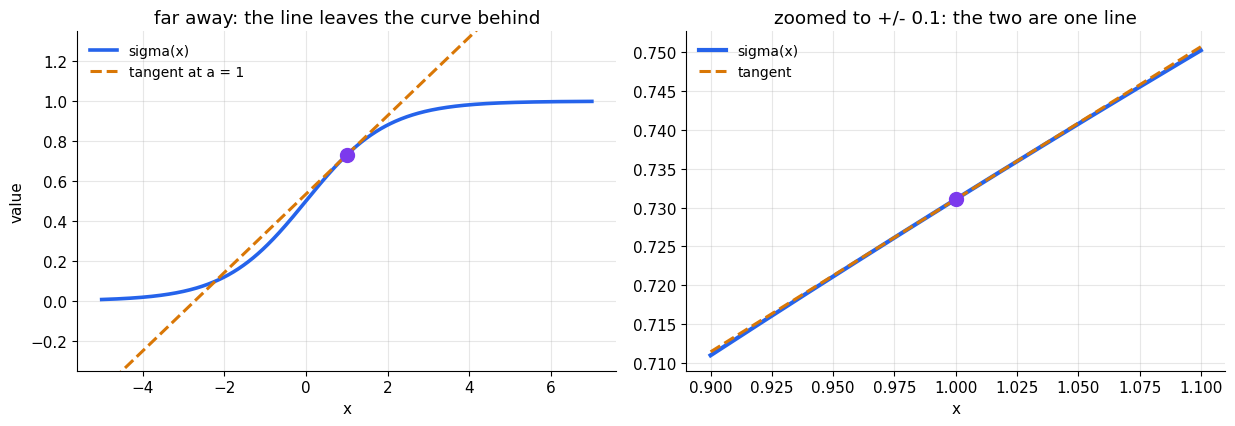

    step h    true sigma(a+h)   linear guess        error   error / h^2
------------------------------------------------------------------------
     2.000        0.952574127    1.124282445    1.717e-01       0.04293
     1.000        0.880797078    0.927670512    4.687e-02       0.04687
     0.500        0.817574476    0.829364545    1.179e-02       0.04716
     0.250        0.777299861    0.780211562    2.912e-03       0.04659
     0.100        0.750260106    0.750719772    4.597e-04       0.04597
     0.010        0.733020149    0.733024698    4.549e-06       0.04549
     0.001        0.731255145    0.731255191    4.543e-08       0.04543

halving the step, and what the error does each time:
   error shrank by a factor of 4.05  (theory says 4)
   error shrank by a factor of 4.04  (theory says 4)
   error shrank by a factor of 4.02  (theory says 4)

predicted limit of error/h^2 is |sigma''(a)|/2 = 0.04543


In [44]:
# ============================================================
#  The tangent line hugs the curve nearby and lets go far away.
#  Then: measure the error, and watch it fall like h^2.
# ============================================================
def sigmoid(u):
    return 1.0 / (1.0 + np.exp(-u))

def sigmoid_prime(u):
    """Part 4's result: sigma'(u) = sigma(u) * (1 - sigma(u))."""
    s = sigmoid(u)
    return s * (1.0 - s)

a = 1.0                                   # the point we expand around
fa, fpa = sigmoid(a), sigmoid_prime(a)
tangent = lambda u: fa + fpa * (u - a)    # y = f(a) + f'(a)(x - a)

print(f"expanding around a = {a}")
print(f"  sigma(a)  = {fa:.6f}")
print(f"  sigma'(a) = {fpa:.6f}   (checked against sympy below)")

s_sym = 1 / (1 + sp.exp(-x))
print(f"  sympy d/dx sigma at a: {float(sp.diff(s_sym, x).subs(x, a)):.6f}")
print()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.4))
wide = np.linspace(-5, 7, 600)
ax1.plot(wide, sigmoid(wide), color=C_F, lw=2.6, label="sigma(x)")
ax1.plot(wide, tangent(wide), color=C_APPROX, lw=2.2, ls="--",
         label="tangent at a = 1")
ax1.plot(a, fa, "o", ms=10, color=C_EXACT, zorder=5)
ax1.set_ylim(-0.35, 1.35)
ax1.set_title("far away: the line leaves the curve behind")
ax1.set_xlabel("x"); ax1.set_ylabel("value")
ax1.legend(frameon=False, fontsize=10)

near = np.linspace(a - 0.10, a + 0.10, 400)
ax2.plot(near, sigmoid(near), color=C_F, lw=3.0, label="sigma(x)")
ax2.plot(near, tangent(near), color=C_APPROX, lw=2.2, ls="--", label="tangent")
ax2.plot(a, fa, "o", ms=10, color=C_EXACT, zorder=5)
ax2.set_title("zoomed to +/- 0.1: the two are one line")
ax2.set_xlabel("x")
ax2.legend(frameon=False, fontsize=10)
fig.tight_layout()
plt.show()

print(f"{'step h':>10} {'true sigma(a+h)':>18} {'linear guess':>14} "
      f"{'error':>12} {'error / h^2':>13}")
print("-" * 72)
prev_err = None
for hh in (2.0, 1.0, 0.5, 0.25, 0.1, 0.01, 0.001):
    true  = sigmoid(a + hh)
    guess = fa + fpa * hh
    err   = abs(true - guess)
    print(f"{hh:>10.3f} {true:>18.9f} {guess:>14.9f} {err:>12.3e} "
          f"{err / hh ** 2:>13.5f}")

print()
half = [abs(sigmoid(a + hh) - (fa + fpa * hh)) for hh in (0.4, 0.2, 0.1, 0.05)]
print("halving the step, and what the error does each time:")
for i in range(1, len(half)):
    print(f"   error shrank by a factor of {half[i - 1] / half[i]:.2f}  "
          f"(theory says 4)")
print()
print(f"predicted limit of error/h^2 is |sigma''(a)|/2 = "
      f"{abs(float(sp.diff(s_sym, x, 2).subs(x, a))) / 2:.5f}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

**Left:** the sigmoid in blue, and its tangent at $a=1$ in orange, drawn across a wide window. The line touches the curve at the purple dot and then abandons it completely — by $x=6$ the line has sailed past $1.7$ while the sigmoid is still politely below $1$. **Right:** the identical two curves over a window of $\pm 0.1$. At this zoom the dashed line and the curve stay within a line's width of each other right across the window: the tabulated error at $h=0.1$ is about $5\times 10^{-4}$, thinner than the ink.

That is the whole content of the linear approximation: *a smooth curve, looked at closely enough, is straight.* Being differentiable means exactly this.

The table puts numbers on the shrinking. The `error / h^2` column is the part to watch: it does not blow up and it does not vanish, it settles on roughly $0.045$ — which is the predicted $|\sigma''(a)|/2$ printed at the bottom. And each halving of the step divides the error by very nearly four, just as $h^2$ says it must.

**The common misread:** reading "the curve is locally straight" as "the curve is straight", and then trusting the tangent at a step size where the left-hand panel applies rather than the right-hand one. The approximation is only ever local, and the table shows the price: at $h=2$ the linear guess is wrong in the second decimal place, which in a training loop is the difference between converging and diverging.

</div>

## 5.6 The payoff: this is what training a model is

Everything in this part now assembles into machine learning. Here is the
smallest honest example.

You have three data points and you want to fit a straight line through the
origin, $\hat{y} = w\,x$. The single number $w$ is your **model**; choosing it
well is **training**. To choose, you need a way to score a candidate $w$, and
the standard score is the **squared-error loss**:

$$L(w) \;=\; \sum_{i=1}^{n}\big(w\,x_i - y_i\big)^2$$

Each term is one prediction's miss, squared so that missing high and missing
low are both penalised. $L$ is a function of $w$ — of *the parameter*, not of
the data, which is fixed. **Training means finding the $w$ that makes $L$
smallest**, which is a Part 5 problem and nothing more.

Differentiate, using the chain rule and the power rule from Part 4:

$$
\begin{aligned}
L'(w) &= \sum_i 2\big(w x_i - y_i\big)\cdot x_i &&\text{(chain rule: outer square, inner } wx_i - y_i)\\
0 &= \sum_i 2 x_i \big(w x_i - y_i\big) &&\text{(set to zero)}\\
0 &= w\sum_i x_i^2 - \sum_i x_i y_i &&\text{(expand, divide by 2)}\\
w^\star &= \frac{\sum_i x_i y_i}{\sum_i x_i^2}
\end{aligned}
$$

And $L''(w) = 2\sum_i x_i^2 > 0$ always, so it is genuinely a minimum, not
merely a critical point. That formula is the whole of one-parameter least
squares, derived in four lines.

Below, three panels: this loss, then two loss shapes designed to break the
naive procedure.


PANEL 1 -- squared-error loss, one parameter


  formula   w* = sum(x*y)/sum(x^2) = 28.80/14.00 = 2.057142857
  sympy     w* = 2.057142857
  scan      w* = 2.057140000   (300,001 candidates, no derivatives)
  L''(w) = 28.0000000000000  > 0, so it is a MINIMUM, not just a critical point
  loss at the optimum = 0.064286
  worst disagreement between the three = 2.86e-06

PANEL 2 -- a loss with TWO valleys
  critical points (f'(x) = 4x^3 - 8x + 1 = 0): [-1.473, 0.126, 1.347]
    x = -1.47300:  f'' = +18.0367  -> minimum,  f = -5.44419
    x = +0.12600:  f'' = -7.8095  -> maximum,  f = +0.06275
    x = +1.34700:  f'' = +13.7728  -> minimum,  f = -2.61856
  GLOBAL minimum is at x = -1.47300, f = -5.44419
  the OTHER minimum   at x = +1.34699, f = -2.61856   <- 2.826 worse, and f'=0 there too

PANEL 3 -- the same function, restricted to the interval [0, 2]
  minimum on [0,2] : x = +1.34700, f = -2.61856   (interior -- f' = 0 there)
  maximum on [0,2] : x = +2.00000, f = +2.00000   (an ENDPOINT -- f'(2) = +17.0, nowhere near zero)
  the b

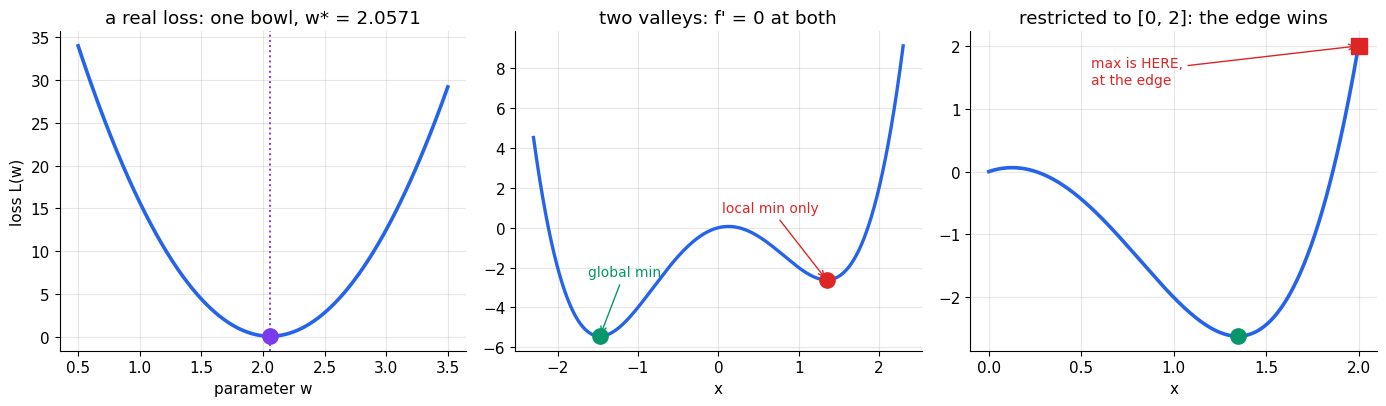

In [45]:
# ============================================================
#  Panel 1: a real (tiny) loss, minimised exactly.
#  Panels 2 and 3: the two ways "set the derivative to zero"
#                  quietly gives you the wrong answer.
# ============================================================
xd = np.array([1.0, 2.0, 3.0])
yd = np.array([2.1, 3.9, 6.3])

def loss(ww):
    ww = np.atleast_1d(np.asarray(ww, dtype=float))[:, None]
    return ((ww * xd - yd) ** 2).sum(axis=1)

# --- analytic minimum, from the derivation above
w_hat = (xd * yd).sum() / (xd ** 2).sum()

# --- and again, symbolically, trusting nothing
wsym  = sp.symbols("w_s", real=True)
L_sym = sum((wsym * float(xi) - float(yi)) ** 2 for xi, yi in zip(xd, yd))
w_sym = sp.solve(sp.Eq(sp.diff(L_sym, wsym), 0), wsym)[0]
L2    = sp.diff(L_sym, wsym, 2)

# --- and once more by scanning, which uses no calculus at all
grid   = np.linspace(0.5, 3.5, 300001)
L_grid = loss(grid)
w_scan = grid[int(np.argmin(L_grid))]

print("PANEL 1 -- squared-error loss, one parameter")
print(f"  formula   w* = sum(x*y)/sum(x^2) = {(xd * yd).sum():.2f}/"
      f"{(xd ** 2).sum():.2f} = {w_hat:.9f}")
print(f"  sympy     w* = {float(w_sym):.9f}")
print(f"  scan      w* = {w_scan:.9f}   (300,001 candidates, no derivatives)")
print(f"  L''(w) = {L2}  > 0, so it is a MINIMUM, not just a critical point")
print(f"  loss at the optimum = {loss(w_hat)[0]:.6f}")
print(f"  worst disagreement between the three = "
      f"{max(abs(w_hat - float(w_sym)), abs(w_hat - w_scan)):.2e}")
print()

# --- a nastier loss: two valleys, and one is deeper
def rugged(u):
    return u ** 4 - 4 * u ** 2 + u

rg     = np.linspace(-2.3, 2.3, 400001)
rv     = rugged(rg)
left   = rg[:200000][int(np.argmin(rv[:200000]))]
right  = rg[200000:][int(np.argmin(rv[200000:]))]
crit   = sorted(float(sp.re(r)) for r in sp.Poly(sp.diff(x ** 4 - 4 * x ** 2 + x, x), x).nroots())

print("PANEL 2 -- a loss with TWO valleys")
print(f"  critical points (f'(x) = 4x^3 - 8x + 1 = 0): "
      f"{[round(c, 5) for c in crit]}")
for c in crit:
    d2 = 12 * c ** 2 - 8
    kind = "minimum" if d2 > 0 else "maximum"
    print(f"    x = {c:+.5f}:  f'' = {d2:+.4f}  -> {kind:>7},  f = {rugged(c):+.5f}")
print(f"  GLOBAL minimum is at x = {left:+.5f}, f = {rugged(left):+.5f}")
print(f"  the OTHER minimum   at x = {right:+.5f}, f = {rugged(right):+.5f}"
      f"   <- {rugged(right) - rugged(left):.3f} worse, and f'=0 there too")
print()

# --- the same function, but we are only allowed x in [0, 2]
seg    = np.linspace(0, 2, 200001)
sv     = rugged(seg)
i_lo, i_hi = int(np.argmin(sv)), int(np.argmax(sv))
print("PANEL 3 -- the same function, restricted to the interval [0, 2]")
print(f"  minimum on [0,2] : x = {seg[i_lo]:+.5f}, f = {sv[i_lo]:+.5f}   "
      f"(interior -- f' = 0 there)")
print(f"  maximum on [0,2] : x = {seg[i_hi]:+.5f}, f = {sv[i_hi]:+.5f}   "
      f"(an ENDPOINT -- f'({seg[i_hi]:.0f}) = "
      f"{4 * seg[i_hi] ** 3 - 8 * seg[i_hi] + 1:+.1f}, nowhere near zero)")
print(f"  the best interior critical point only reaches f = "
      f"{max(rugged(c) for c in crit if 0 <= c <= 2):+.5f}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

axes[0].plot(grid, L_grid, color=C_F, lw=2.6)
axes[0].plot(w_hat, loss(w_hat)[0], "o", ms=11, color=C_EXACT, zorder=5)
axes[0].axvline(w_hat, color=C_EXACT, ls=":", lw=1.4)
axes[0].set_title(f"a real loss: one bowl, w* = {w_hat:.4f}")
axes[0].set_xlabel("parameter w"); axes[0].set_ylabel("loss L(w)")

axes[1].plot(rg, rv, color=C_F, lw=2.4)
axes[1].plot(left, rugged(left), "o", ms=11, color=C_AREA, zorder=5)
axes[1].plot(right, rugged(right), "o", ms=11, color=C_SLOPE, zorder=5)
axes[1].annotate("global min", xy=(left, rugged(left)),
                 xytext=(left - 0.15, rugged(left) + 3.0), color=C_AREA,
                 fontsize=10, arrowprops=dict(arrowstyle="->", color=C_AREA))
axes[1].annotate("local min only", xy=(right, rugged(right)),
                 xytext=(right - 1.30, rugged(right) + 3.4), color=C_SLOPE,
                 fontsize=10, arrowprops=dict(arrowstyle="->", color=C_SLOPE))
axes[1].set_title("two valleys: f' = 0 at both")
axes[1].set_xlabel("x")

axes[2].plot(seg, sv, color=C_F, lw=2.6)
axes[2].plot(seg[i_hi], sv[i_hi], "s", ms=11, color=C_SLOPE, zorder=5)
axes[2].plot(seg[i_lo], sv[i_lo], "o", ms=11, color=C_AREA, zorder=5)
axes[2].annotate("max is HERE,\nat the edge", xy=(seg[i_hi], sv[i_hi]),
                 xytext=(0.55, sv[i_hi] - 0.6), color=C_SLOPE, fontsize=10,
                 arrowprops=dict(arrowstyle="->", color=C_SLOPE))
axes[2].set_title("restricted to [0, 2]: the edge wins")
axes[2].set_xlabel("x")
fig.tight_layout()
plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

**Left:** a genuine machine-learning loss — three data points, one parameter. It is a clean bowl, so setting $L'(w)=0$ finds the one true answer, and the purple dot marks it. Three independent methods agree to $10^{-5}$ or better. This is the easy case, and it is easy because the function is convex.

**Middle:** $f(x)=x^4-4x^2+x$, which has *two* valleys. Both are critical points, both pass the second-derivative test as minima, and one is worse than the other by about $2.8$. Nothing local distinguishes them: standing in the red valley, everything nearby is uphill, and no amount of looking at $f'$ and $f''$ *at that point* can tell you the green valley exists.

**Right:** the same function, but now $x$ is confined to $[0,2]$. The maximum on that interval is at the right-hand edge, where the derivative is nowhere near zero — the printed value is about $+17$. Solving $f'=0$ would never have found it.

**The common misread:** taking the left-hand panel as typical and the other two as pathological curiosities. It is the reverse. Real loss surfaces look far more like the middle panel, and real problems almost always have constraints like the right panel — a probability confined to $[0,1]$, a length that cannot be negative, a budget that cannot be exceeded.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

Two failures, both visible in the figure above, both routinely fatal.

**1. Forgetting the endpoints.** On a closed interval $[a,b]$, the largest and smallest values of a continuous function occur either at an interior critical point *or at one of the two endpoints*. The endpoints are not optional extras: the right-hand panel's maximum sits at $x=2$ with a derivative of about $+17$, so any procedure that only solves $f'=0$ misses it entirely. The complete recipe is: **evaluate $f$ at every critical point in $[a,b]$, and at $a$, and at $b$, and compare the list.** Three lines, and it never fails. (This guarantee is Weierstrass's extreme value theorem, and it needs both *closed* and *bounded* — on the open interval $(0,2)$ there is no maximum at all, only values creeping towards one.)

**2. Assuming a local minimum is the global one.** The middle panel has two minima and only one of them is the answer. Every test in this part — $f'=0$, $f''>0$, checking the neighbours — is *local*: it examines an arbitrarily small neighbourhood and can therefore only make local claims. Nothing you can measure at a point tells you what the function does a mile away. Establishing a **global** minimum needs either an exhaustive search (fine in one dimension, hopeless in a thousand) or a structural argument — the strongest being **convexity**: if $f''(x) \ge 0$ *everywhere*, the function has exactly one valley and any local minimum is automatically global. Least squares is convex, which is why the left panel behaves. Neural networks are emphatically not.

</div>

<div style="background-color: #f8d7da; border-left: 5px solid #dc3545; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🤖 Why ML cares

**The loss surface is the whole game.** Training a model means writing down a loss $L(\theta)$ that scores how wrong the model is, then finding the $\theta$ that minimises it. Every idea in this part transfers directly: $L' = 0$ at the bottom; $L'' > 0$ confirms it is a bottom and not a summit; and the sign of $L'$ tells you which way to walk. The only difference in real ML is that $\theta$ is a vector with millions of entries instead of a single number — which is Part 8's job.

**Why we cannot just solve $L'(\theta) = 0$.** For the left-hand panel we could, and got $w^\star = \sum x_iy_i / \sum x_i^2$ exactly. For a neural network, $L'(\theta)=0$ is a system of millions of coupled non-linear equations with no closed-form solution — nobody can solve it, and it is not a matter of trying harder. So instead we *walk downhill*: evaluate the derivative where we are, take a small step against it, and repeat. That is **gradient descent**, and it is Part 9.

**Why the tangent line justifies a small learning rate.** Gradient descent's step is $\theta \leftarrow \theta - \eta\,L'(\theta)$, and the reason it works is §5.5: $L(\theta + h) \approx L(\theta) + L'(\theta)h$. Stepping against the derivative reduces the loss *because the linear approximation says so* — but that approximation is only trustworthy for small $h$, with error growing like $h^2$. The learning rate $\eta$ is precisely the knob that keeps you inside the region where the tangent line is still telling the truth. Too large and you are trusting the left-hand panel of the sigmoid figure, where the line has left the curve behind — and your loss goes *up*. That is what a diverging training run is, and now you know exactly which approximation broke.

**Why local minima are less frightening than they sound.** The middle panel above is genuinely scary in one dimension. In a million dimensions it is much less so, for a reason worth understanding: at a critical point the surface curves either up or down along each of the million directions, and to be a true local minimum it must curve *up in every single one*. If the directions were even roughly independent, that is like flipping a million coins and getting a million heads. Overwhelmingly the more likely outcome is that a few directions curve down — an escape route. So high-dimensional critical points are almost all **saddle points**, not traps, and gradient descent slides off them. This is why training enormous models works at all, and it was genuinely surprising when the field worked it out (Dauphin et al., 2014).

</div>

---

### Where we have got to

You can now take a function and *read* it.

| Question | What you look at | Section |
|---|---|---|
| Is it going up or down here? | the **sign** of $f'$ | opening |
| Where might a peak or valley be? | solve $f' = 0$ | §5.1 |
| Is this one a peak, a valley, or neither? | the **sign** of $f''$ | §5.3 |
| How fast is the change itself changing? | $f''$ — acceleration | §5.2 |
| What is the best possible choice? | critical points **and endpoints**, compared | §5.4 |
| How far can I trust a small step? | $f(a+h) \approx f(a) + f'(a)h$, error $\sim h^2$ | §5.5 |

Those six rows are, honestly, most of what calculus is used for. The last two
are what Part 9 will turn into a training loop.

### But we have only asked half the question

Go back to the very first figure in this notebook: position on the left, speed
on the right. Every part so far has gone **left to right** — given position,
find the speed. Given a function, find its rate of change.

The other direction is untouched, and it is at least as useful:

> Your car has no odometer, only a speedometer. You watch it for two minutes.
> **How far did you travel?**

You cannot multiply speed by time, because there was no single speed. But you
could chop the two minutes into a hundred slices, pretend the speed was
constant within each slice, multiply and add up — and then chop finer. If that
sounds like the limit argument from Part 3 pointed backwards, that is because
it is.

That sum, taken to the limit, is the **integral**, and it is Part 6.

---


---

# 6️⃣ Integrals: adding up infinitely many thin slivers

Back to the car. Suppose somebody has stolen the odometer and left you only the
**speedometer trace** — you know the speed at every instant, and you want to know
**how far the car went**.

If the speed had been a steady 14 m/s for 120 seconds, this would be primary
school: distance = speed × time = 1680 metres. One multiplication. Done.

But the speed is *never* steady. It rises, dips for the bend, recovers, falls
away at the end. There is no single number to multiply by 120, so
"speed × time" has nothing to grab hold of.

Here is the entire idea of this part, and it fits in one sentence:

> **Over a tiny stretch of time the speed barely changes, so over that tiny
> stretch you *can* do speed × time. Do it for every tiny stretch and add up
> the answers.**

That is it. Everything that follows — the rectangles, the limit, the stretched
S-shaped symbol — is bookkeeping for that one sentence.

And notice what "speed × time" is on a graph: speed is the **height** of the
curve, time is the **width** of the stretch, and height × width is an **area**.
So adding up all those little products is the same thing as **measuring the
area under the curve**. That is why Part 0 promised you the integral was an
area — it was never a separate idea, it is just what the sum looks like when
you draw it.

### 6.1 Doing it by hand, with actual rectangles

We will practise on a simpler curve than the car so the numbers are easy to
follow: $f(x) = x^2$, between $x = 0$ and $x = 3$.

Each slice becomes a **rectangle**. Its width is the slice width. Its height has
to be *some* value of $f$ on that slice — and the simplest choice is the value
at the **left edge**. That choice has a name: the **left Riemann sum**, after
Bernhard Riemann, who tidied all of this up in the 1850s.

We write the loop out longhand below. There is a one-line numpy way to do it and
we will get there, but the loop is the definition and the definition is the
point.


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

**The problem:** you can only multiply by a *constant* speed, and the speed is not constant.

**The dodge:** chop the journey into slices so short that the speed is *nearly* constant on each one. On each slice, multiply the speed you see at that moment by the length of the slice. That gives an approximate distance for that slice.

**The finish:** add up all the slices, then make the slices thinner and thinner and watch the total settle down. The number it settles on is called the **integral**.

**Chop, multiply, add, shrink.** Four words, and you now know what an integral is. Everything below is those four words done carefully.

</div>

reference area under f(z) = z^2 from 0 to 3:  9.0000000000



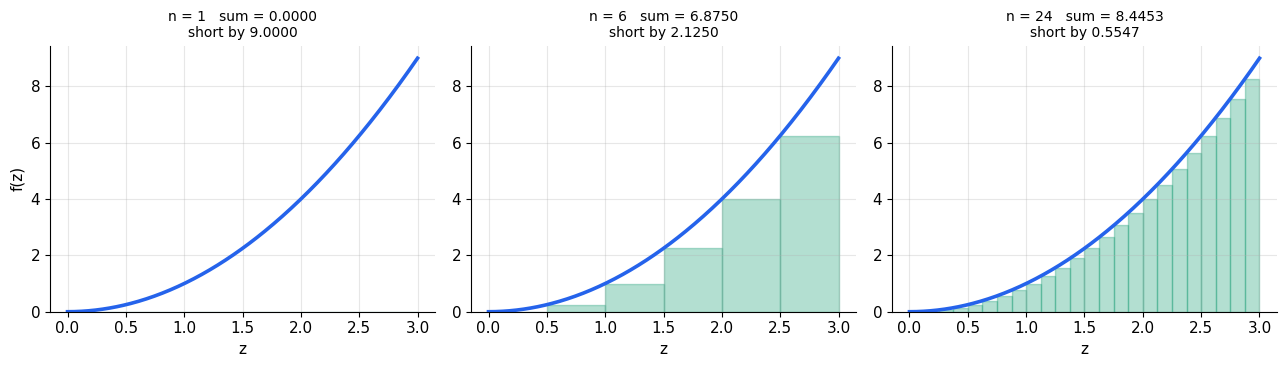

      n |  left sum  |  how much area we are still missing
  --------------------------------------------------
      1 |    0.00000 |    9.00000
      2 |    3.37500 |    5.62500
      4 |    5.90625 |    3.09375
      8 |    7.38281 |    1.61719
     16 |    8.17383 |    0.82617
     32 |    8.58252 |    0.41748


In [46]:
# ============================================================
#  Chop, multiply, add -- written out as a plain loop.
# ============================================================
def f_demo(z):
    """Our practice curve: f(z) = z squared."""
    return z ** 2

A, B = 0.0, 3.0          # where we start and where we stop

def left_sum(f, a, b, n):
    """Left Riemann sum: n rectangles, each as TALL as f at its LEFT edge."""
    width = (b - a) / n            # width of one sliver
    total = 0.0
    for i in range(n):
        z_left = a + i * width     # left edge of slice number i
        total += f(z_left) * width # height x width = area of one rectangle
    return total

# A yardstick to measure our error against: a midpoint sum so fine it is good
# to about ten decimal places. Later in this part we PROVE the exact value with
# algebra -- for now this is just a very trustworthy number to compare to.
_fine_n = 2_000_000
_fine_m = (np.arange(_fine_n) + 0.5) * (B - A) / _fine_n + A
REF = float(np.sum(f_demo(_fine_m)) * (B - A) / _fine_n)
print(f"reference area under f(z) = z^2 from {A:.0f} to {B:.0f}:  {REF:.10f}\n")

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
zs = np.linspace(A, B, 400)
for ax, n in zip(axes, (1, 6, 24)):
    wdt   = (B - A) / n
    lefts = A + np.arange(n) * wdt
    ax.bar(lefts, f_demo(lefts), width=wdt, align="edge",
           color=C_AREA, alpha=0.30, edgecolor=C_AREA, linewidth=1.0)
    ax.plot(zs, f_demo(zs), color=C_F, lw=2.6)
    s = left_sum(f_demo, A, B, n)
    ax.set_title(f"n = {n}   sum = {s:.4f}\nshort by {REF - s:.4f}", fontsize=10)
    ax.set_xlabel("z")
axes[0].set_ylabel("f(z)")
fig.tight_layout()
plt.show()

print("      n |  left sum  |  how much area we are still missing")
print("  " + "-" * 50)
for n in (1, 2, 4, 8, 16, 32):
    s = left_sum(f_demo, A, B, n)
    print(f"  {n:>5} | {s:10.5f} | {REF - s:10.5f}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The blue curve is $f(z)=z^2$. The green blocks are the rectangles we are adding up, each one as tall as the curve at its **left** edge.

With one rectangle the estimate is hopeless — a single block of height $f(0)=0$ has zero area, so we claim the region under the curve is empty. With six, the staircase already has roughly the right shape but every block sits *below* the rising curve, so we keep under-counting. With twenty-four the white gaps between the staircase and the curve have become slivers, and the printed sum has closed most of the distance to the reference value.

The table underneath is the same story in numbers: the missing area roughly **halves every time we double $n$**. That is the behaviour that makes the whole idea work — not that any single picture is right, but that the error is being squeezed towards zero and we can see the rate.

**The common misread:** thinking the rectangles are an approximation to the *curve*. They are not — nobody cares whether the staircase looks like the parabola. They are an approximation to the **area**, and the two errors, over-shooting on one side of each block and under-shooting on the other, are exactly what cancels as the blocks get thin.

</div>

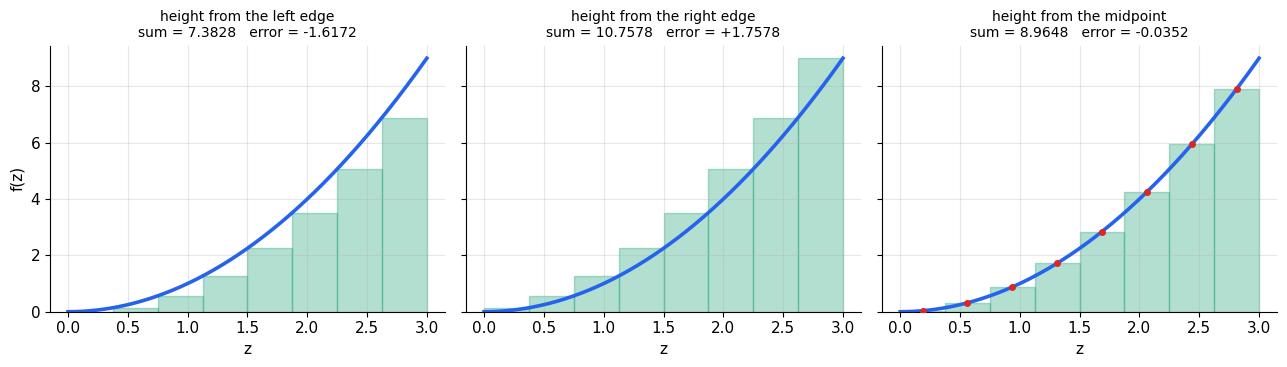

with the SAME n = 8 rectangles, and the truth at 9.000000:

  left edge      7.38281   error  -1.61719
  right edge    10.75781   error  +1.75781
  midpoint       8.96484   error  -0.03516

  midpoint's error is 46x smaller than the left rule's, for exactly the same amount of work.


In [47]:
# ============================================================
#  Three honest choices of rectangle height.
# ============================================================
def right_sum(f, a, b, n):
    """Each rectangle as tall as f at its RIGHT edge."""
    width = (b - a) / n
    total = 0.0
    for i in range(n):
        z_right = a + (i + 1) * width
        total += f(z_right) * width
    return total

def mid_sum(f, a, b, n):
    """Each rectangle as tall as f at the MIDDLE of its slice."""
    width = (b - a) / n
    total = 0.0
    for i in range(n):
        z_mid = a + (i + 0.5) * width
        total += f(z_mid) * width
    return total

n = 8
wdt   = (B - A) / n
lefts = A + np.arange(n) * wdt
zs    = np.linspace(A, B, 400)

heights = {"left edge":   f_demo(lefts),
           "right edge":  f_demo(lefts + wdt),
           "midpoint":    f_demo(lefts + wdt / 2)}
sums    = {"left edge":   left_sum(f_demo, A, B, n),
           "right edge":  right_sum(f_demo, A, B, n),
           "midpoint":    mid_sum(f_demo, A, B, n)}

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
for ax, (name, hgt) in zip(axes, heights.items()):
    ax.bar(lefts, hgt, width=wdt, align="edge",
           color=C_AREA, alpha=0.30, edgecolor=C_AREA, linewidth=1.0)
    ax.plot(zs, f_demo(zs), color=C_F, lw=2.6)
    if name == "midpoint":
        ax.plot(lefts + wdt / 2, hgt, "o", ms=4, color=C_SLOPE, zorder=5)
    err = sums[name] - REF
    ax.set_title(f"height from the {name}\nsum = {sums[name]:.4f}   "
                 f"error = {err:+.4f}", fontsize=10)
    ax.set_xlabel("z")
axes[0].set_ylabel("f(z)")
fig.tight_layout()
plt.show()

print(f"with the SAME n = {n} rectangles, and the truth at {REF:.6f}:\n")
for name in ("left edge", "right edge", "midpoint"):
    print(f"  {name:<12} {sums[name]:9.5f}   error {sums[name] - REF:+9.5f}")
print(f"\n  midpoint's error is {abs(sums['left edge'] - REF) / abs(sums['midpoint'] - REF):.0f}x "
      f"smaller than the left rule's, for exactly the same amount of work.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The same eight slices, three different rules for how tall to make each block.

$f(z)=z^2$ is **increasing** on this interval, so the left edge is always the lowest point of its slice: every left rectangle fits *underneath* the curve and the total **under-estimates**. The right edge is always the highest point of its slice: every right rectangle pokes *above* the curve and the total **over-estimates**. You can read that straight off the printed errors — one is negative, the other positive, and they are roughly the same size.

The midpoint rule wins, and the picture says why in one line: **each midpoint rectangle cuts the curve, so the corner it leaves empty on the left is very nearly the same size as the corner it adds on the right, and the two mistakes cancel inside every single slice** — instead of piling up the way the one-sided errors do.

**The common misread:** concluding that left always under-estimates. It under-estimates *because this function is increasing here*. On a decreasing stretch the roles swap exactly — left over-estimates and right under-estimates — which is why the honest summary is *left and right err in opposite directions*, not *left is small*.

</div>

### 6.2 The trapezoid rule: split the difference

Left is too small, right is too big, and they miss by roughly the same amount.
So the obvious move is to **average them**:

$$T_n \;=\; \frac{L_n + R_n}{2}$$

where $L_n$ is the left sum with $n$ rectangles and $R_n$ is the right sum with
the same $n$.

There is a nicer way to see what that average *is*. Averaging the two heights
of a slice — the left value and the right value — and multiplying by the width
is precisely the area of the **trapezoid** whose sloping top runs from
$(z_i, f(z_i))$ to $(z_{i+1}, f(z_{i+1}))$:

$$T_n \;=\; \sum_{i=0}^{n-1} \frac{f(z_i) + f(z_{i+1})}{2}\,\Delta z ,
\qquad \Delta z = \frac{b-a}{n}$$

So instead of a flat-topped staircase you are laying a straight-edged ramp
across each slice, which hugs a curve far better than a flat lid does. Numpy
ships this as **`np.trapezoid`** (called `np.trapz` in numpy 1.x) — it is the
one-liner we promised, and now you know exactly what it computes.

The four rules together:

| Rule | Height of each rectangle | Symbol |
|---|---|---|
| Left | $f$ at the left edge | $L_n$ |
| Right | $f$ at the right edge | $R_n$ |
| Midpoint | $f$ at the middle | $M_n$ |
| Trapezoid | average of the two edges | $T_n = \tfrac{1}{2}(L_n + R_n)$ |


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

$\Delta z$ (said "delta z") is just **the width of one sliver** — the Greek capital D for *difference*, because it is the difference between one cut and the next. $z_i$ is the left edge of slice number $i$, and $z_{i+1}$ is its right edge. The big $\Sigma$ (Greek capital S, for *sum*) means "add up what follows, for $i$ running from 0 to $n-1$" — that is, once per slice.

Read the trapezoid formula aloud: *for each slice, take the average of the heights at its two ends, multiply by its width, and add all of those up.*

The trapezoid rule is not a new idea. It is the left rule and the right rule holding hands so their opposite mistakes cancel.

</div>

In [48]:
# ============================================================
#  Do the sums converge? Watch the error column.
# ============================================================
trapz = np.trapezoid if hasattr(np, "trapezoid") else np.trapz   # numpy 2.x / 1.x

print(f"area under f(z) = z^2 on [{A:.0f}, {B:.0f}]   (reference {REF:.8f})\n")
print("     n |    width |      left |     right |  midpoint | trapezoid")
print("       |          |     error |     error |     error |     error")
print("  " + "-" * 66)
for n in (4, 8, 16, 64, 256):
    wdt = (B - A) / n
    L = left_sum(f_demo, A, B, n)
    R = right_sum(f_demo, A, B, n)
    M = mid_sum(f_demo, A, B, n)
    T = 0.5 * (L + R)
    print(f"  {n:>4} | {wdt:8.5f} | {L - REF:+9.5f} | {R - REF:+9.5f} | "
          f"{M - REF:+9.5f} | {T - REF:+9.5f}")

# Is the trapezoid rule really the average of left and right, and really what
# numpy computes? Two claims, both cheap to test.
n = 256
wdt   = (B - A) / n
edges = np.linspace(A, B, n + 1)
T_hand  = 0.5 * (left_sum(f_demo, A, B, n) + right_sum(f_demo, A, B, n))
T_formula = float(np.sum((f_demo(edges[:-1]) + f_demo(edges[1:])) / 2 * wdt))
T_numpy = float(trapz(f_demo(edges), edges))
print(f"\n  n = {n}:")
print(f"    (L + R)/2               = {T_hand:.10f}")
print(f"    trapezoid formula       = {T_formula:.10f}")
print(f"    np.trapezoid            = {T_numpy:.10f}")
print(f"    biggest gap between them = "
      f"{max(abs(T_hand - T_formula), abs(T_hand - T_numpy)):.2e}")

# Halving the width: what happens to the error?
print("\n  how fast does the error shrink when the slivers halve in width?")
prev_M = prev_T = None
for n in (32, 64, 128, 256, 512):
    M = mid_sum(f_demo, A, B, n)
    T = 0.5 * (left_sum(f_demo, A, B, n) + right_sum(f_demo, A, B, n))
    if prev_M is not None:
        print(f"    n {n//2:>4} -> {n:<4}:  midpoint error shrank "
              f"{abs(prev_M - REF) / abs(M - REF):5.2f}x,   "
              f"trapezoid {abs(prev_T - REF) / abs(T - REF):5.2f}x")
    prev_M, prev_T = M, T

# ------------------------------------------------------------------
#  So: is MORE rectangles always better? Let us actually check.
#  np.cumsum adds strictly left to right, one term at a time -- exactly what
#  our loop does -- so its last entry is the naive running total, and we can
#  ask for it in single precision to make the effect visible at a sane n.
# ------------------------------------------------------------------
def naive_mid_sum(n, dtype):
    """Midpoint sum accumulated one term at a time, in the given precision."""
    wdt   = dtype((B - A) / n)
    mids  = (np.arange(n, dtype=dtype) + dtype(0.5)) * wdt + dtype(A)
    terms = (mids * mids * wdt).astype(dtype)
    return float(np.cumsum(terms, dtype=dtype)[-1])

print("\n  pushing n as far as it will go:")
print("           n |  error, 64-bit floats |  error, 32-bit floats")
print("  " + "-" * 60)
for n in (10**2, 10**3, 10**4, 10**5, 10**6, 10**7):
    e64 = naive_mid_sum(n, np.float64) - REF
    e32 = naive_mid_sum(n, np.float32) - REF
    print(f"  {n:>10} | {e64:+21.3e} | {e32:+21.3e}")

print("\n  The 32-bit column improves, bottoms out, and then gets WORSE.")
print("  Nothing is wrong with the maths. Every one of those millions of")
print("  additions rounds the running total to the nearest representable")
print("  number, and past a certain n you are adding more rounding error")
print("  than you are removing approximation error.")


area under f(z) = z^2 on [0, 3]   (reference 9.00000000)

     n |    width |      left |     right |  midpoint | trapezoid
       |          |     error |     error |     error |     error
  ------------------------------------------------------------------
     4 |  0.75000 |  -3.09375 |  +3.65625 |  -0.14062 |  +0.28125
     8 |  0.37500 |  -1.61719 |  +1.75781 |  -0.03516 |  +0.07031
    16 |  0.18750 |  -0.82617 |  +0.86133 |  -0.00879 |  +0.01758
    64 |  0.04688 |  -0.20984 |  +0.21204 |  -0.00055 |  +0.00110
   256 |  0.01172 |  -0.05267 |  +0.05280 |  -0.00003 |  +0.00007

  n = 256:
    (L + R)/2               = 9.0000686646
    trapezoid formula       = 9.0000686646
    np.trapezoid            = 9.0000686646
    biggest gap between them = 0.00e+00

  how fast does the error shrink when the slivers halve in width?
    n   32 -> 64  :  midpoint error shrank  4.00x,   trapezoid  4.00x
    n   64 -> 128 :  midpoint error shrank  4.00x,   trapezoid  4.00x
    n  128 -> 256 :  mi

     1000000 |            -1.215e-12 |            -7.095e-04


    10000000 |            +4.050e-13 |            +9.794e-02

  The 32-bit column improves, bottoms out, and then gets WORSE.
  Nothing is wrong with the maths. Every one of those millions of
  additions rounds the running total to the nearest representable
  number, and past a certain n you are adding more rounding error
  than you are removing approximation error.


<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

Nothing above was asserted. Read the error columns down the page: every one of them marches towards zero as $n$ grows, which is the claim that the sums *converge* — and the left and right columns keep opposite signs the whole way down, which is the claim that they bracket the answer from below and above.

The trapezoid rule was checked three ways at $n=256$ — as $\tfrac12(L+R)$ by hand, as the trapezoid formula written out, and as `np.trapezoid` — and the three agree to the last printed digit. So when you reach for the numpy one-liner from now on, you are not trusting a black box; you have watched it match the loop.

The last block measures the *rate*. Halving the sliver width shrinks the midpoint and trapezoid errors by about **4×** each time, not 2× — because for those two rules the error goes like $(\Delta z)^2$, and halving a number squares to a quarter. The one-sided rules only manage 2×. That factor is the entire practical reason anybody uses the midpoint or trapezoid rule.

The final block, where $n$ is pushed to ten million, is a different kind of result and is the subject of the warning immediately below — read it next.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**"Just use a million rectangles."** The maths says the error goes to zero as the slivers get thin. Your computer disagrees, and the table above is the disagreement: in 32-bit arithmetic the answer gets *worse* after about $n=10^4$, because each addition rounds the running total and those rounding errors accumulate faster than the approximation error is shrinking.

This is the same wall you hit in **Part 2**, from the other side: there, making $h$ too small in the difference quotient destroyed the answer, because you were subtracting two nearly-equal numbers. Here, making the slivers too thin destroys the answer, because you are adding a colossal number of tiny ones. Both are the same underlying fact — a float has about 16 significant decimal digits (7 in single precision), and no amount of clever mathematics buys you a seventeenth.

**What to do instead:** use a *smarter rule*, not more rectangles. Midpoint at $n=256$ beats the left rule at $n=100{,}000$ in the tables above, and does 400× less arithmetic. This is why real software uses adaptive schemes (§6.7) rather than brute force.

</div>

### 6.3 Now, and only now, the notation

You already own the idea. The symbol is just shorthand for it, and here it is
with every mark named:

$$\int_{a}^{b} f(x)\,dx$$

| Mark | Name | What it is doing |
|---|---|---|
| $\displaystyle\int$ | the integral sign | a letter **S**, stretched tall, for **Sum**. Leibniz drew it that way in 1675 and we never stopped |
| $a$ (bottom) | lower limit | where you start |
| $b$ (top) | upper limit | where you stop |
| $f(x)$ | the integrand | the height of the curve at $x$ — the "speed" |
| $dx$ | the differential | the **width of one sliver**, thought of as infinitesimally thin |
| all together | | "add up height × width, all the way from $a$ to $b$" |

Compare it, mark for mark, with the sum you have been computing:

$$\sum_{i=0}^{n-1} f(x_i)\,\Delta x \qquad \longrightarrow \qquad \int_a^b f(x)\,dx$$

The $\Sigma$ relaxes into $\int$. The $\Delta x$, a width you could actually
measure, relaxes into $dx$, a width too small to measure. The counter $i$
disappears because you are no longer counting slices — there are too many to
count.

#### And what does "relaxes into" actually mean? A limit. Part 2's limit.

This is the definition, stated properly:

$$\int_a^b f(x)\,dx \;=\; \lim_{n \to \infty} \sum_{i=0}^{n-1} f(x_i)\,\Delta x
\qquad \text{with } \Delta x = \frac{b-a}{n}$$

Read it against Part 2. There, a limit meant *the number a quantity heads
towards as you squeeze something, whether or not it ever arrives*. You could
not evaluate the difference quotient **at** $h = 0$ — it was $0/0$ — so you
watched where it was going. Here you cannot evaluate the sum **at** infinitely
many slices — you would be adding forever — so again you watch where it is
going. Same manoeuvre, same escape from an impossible calculation.

The definite integral is a **limit of Riemann sums**. That sentence is not a
summary of the definition; it *is* the definition.

#### So can we ever get an exact answer this way? Yes.

Not by computing forever, but by finding a formula for the sum with $n$ slices
and taking $n \to \infty$ algebraically. For $f(x)=x^2$ on $[0,3]$ the right
sum is

$$R_n = \sum_{i=1}^{n} \left(\frac{3i}{n}\right)^{\!2}\cdot\frac{3}{n}
      = \frac{27}{n^3}\sum_{i=1}^{n} i^2$$

and there is a classical closed form for $\sum i^2$ that has nothing to do with
calculus. Let us have sympy do the algebra and then take the limit.


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

$\int_a^b f(x)\,dx$ is said aloud as **"the integral from $a$ to $b$ of $f$ of $x$, d $x$"**, and it means one number: the signed area under the curve $f$ between $a$ and $b$.

The $dx$ at the end is not decoration and it is not multiplication. It does two jobs: it tells you **which letter is the one being swept from $a$ to $b$** (essential once there are several letters in the room, which is Part 8), and it is the ghost of the sliver width $\Delta x$ that you have been multiplying by all through this part.

A useful habit: whenever you see $\int \ldots dx$, whisper *"sum of little bits"*. If the $f(x)$ is a speed and $dx$ is a bit of time, the little bits are distances and the integral is a distance. The units of the answer are always **(units of $f$) × (units of $x$)**, which is a free sanity check on every integral you ever write.

</div>

In [49]:
# ============================================================
#  An exact answer, from algebra alone -- no calculus, no rectangles.
#  (Archimedes did essentially this, by hand, around 250 BC.)
# ============================================================
i_s, n_s = sp.symbols("i n", positive=True, integer=True)

# The classical closed form for the sum of the first n squares:
sum_squares = sp.summation(i_s**2, (i_s, 1, n_s))
print("sum of i^2 for i = 1..n  =  ", sp.factor(sum_squares))

# The RIGHT Riemann sum for f(x) = x^2 on [0, 3] with n slices:
#   width = 3/n,  right edge of slice i is x_i = 3i/n
R_n = sp.summation((3 * i_s / n_s)**2 * (sp.Integer(3) / n_s), (i_s, 1, n_s))
R_n = sp.simplify(sp.expand(R_n))
print("right sum with n slices  =  ", R_n)

# Now let the slivers become infinitely thin -- a Part 2 limit, done exactly.
exact = sp.limit(R_n, n_s, sp.oo)
print("\nlimit as n -> infinity   =  ", exact)

# And confirm the algebra against the numbers we have been computing all along.
print(f"\n  exact value (algebra)        : {float(exact):.12f}")
print(f"  fine midpoint sum (numerics) : {REF:.12f}")
print(f"  difference                   : {abs(float(exact) - REF):.2e}")
for n in (10, 1000, 100000):
    print(f"  right sum at n = {n:>6}      : {float(R_n.subs(n_s, n)):.10f}")


sum of i^2 for i = 1..n  =   n*(n + 1)*(2*n + 1)/6
right sum with n slices  =   9 + 27/(2*n) + 9/(2*n**2)

limit as n -> infinity   =   9

  exact value (algebra)        : 9.000000000000
  fine midpoint sum (numerics) : 8.999999999999
  difference                   : 5.63e-13
  right sum at n =     10      : 10.3950000000
  right sum at n =   1000      : 9.0135045000
  right sum at n = 100000      : 9.0001350004


<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

The exact area under $y=x^2$ from $0$ to $3$ is **9**, and we got there with nothing but the sum-of-squares identity $\sum_{i=1}^n i^2 = \tfrac{1}{6}n(n+1)(2n+1)$ and a limit — no antiderivatives, no theorems from later in this notebook. The right sum comes out as $9 + \tfrac{27}{2n} + \tfrac{9}{2n^2}$, so it is always *above* 9 (matching the over-estimate we saw in the pictures) and the excess dies like $1/n$.

The reference number we have been quoting since §6.1 — computed by a completely different route, two million midpoint rectangles — agrees to roughly ten decimal places. Two independent methods, one answer. That is why you can trust every error column on this page.

It is also worth noticing how much work exactness costs: that algebra worked because $\sum i^2$ happens to have a tidy closed form. For most functions it does not, and this route is hopeless. Part 7 supplies the route that is not hopeless.

</div>

### 6.4 Area that counts as negative

Everything so far sat above the horizontal axis. What happens when the curve
dips below it?

Look at the definition again — *height × width, added up*. If the curve is below
the axis, the "height" $f(x)$ is a **negative number**, so height × width is a
negative contribution, and the sum goes **down**. Nothing special has to be
added to the rules; it falls straight out of the arithmetic.

So the integral does not compute area in the paint-and-carpet sense. It computes
**signed area**: what is above the axis counts positive, what is below counts
negative, and they cancel each other out.

That is not a defect, it is the feature. Go back to the car. If $f$ is the
car's **velocity** — speed *with* a direction, negative when reversing — then:

- $\int$ velocity $dt$ is **displacement**: how far you ended up from where you
  started. Reversing genuinely should subtract.
- $\int |$velocity$|\,dt$ is **distance travelled**: what the odometer reads.
  Reversing still wears out the tyres.

Take a function that crosses the axis and watch both numbers.


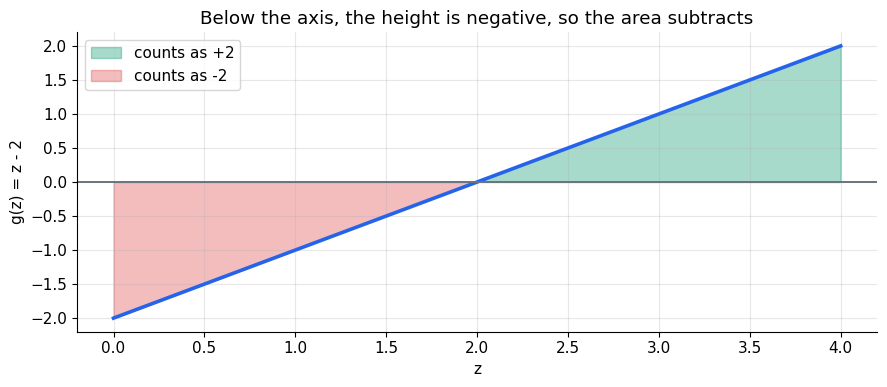

  signed  integral of g   : +0.000000     (exact: 0, the two halves cancel)
  unsigned integral of |g|: +4.000000     (exact: 4, two triangles of area 2)

  piece on [0, 2] (below) : -2.000000
  piece on [2, 4] (above) : +2.000000

  If g were a velocity in m/s over 4 seconds:
    displacement      = +0.0000 m   -- you finished where you began
    distance travelled = 4.0000 m   -- but the odometer still moved


In [50]:
# ============================================================
#  A function that crosses zero: g(z) = z - 2 on [0, 4].
#  Chosen because school geometry gives the exact answer:
#    two triangles, each base 2 and height 2, so area 2 each.
# ============================================================
def g(z):
    return z - 2.0

GA, GB = 0.0, 4.0
N = 200_000

signed   = mid_sum(g, GA, GB, N)                     # lets the minus signs act
unsigned = mid_sum(lambda z: abs(g(z)), GA, GB, N)   # forces every bit positive

zs = np.linspace(GA, GB, 400)
fig, ax = plt.subplots(figsize=(9, 4.0))
ax.plot(zs, g(zs), color=C_F, lw=2.6)
ax.fill_between(zs, g(zs), 0, where=(g(zs) >= 0), color=C_AREA, alpha=0.35,
                label="counts as +2")
ax.fill_between(zs, g(zs), 0, where=(g(zs) <= 0), color=C_SLOPE, alpha=0.30,
                label="counts as -2")
ax.axhline(0, color=C_GREY, lw=1.4)
ax.set_xlabel("z")
ax.set_ylabel("g(z) = z - 2")
ax.set_title("Below the axis, the height is negative, so the area subtracts")
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()

print(f"  signed  integral of g   : {signed:+.6f}     (exact: 0, the two halves cancel)")
print(f"  unsigned integral of |g|: {unsigned:+.6f}     (exact: 4, two triangles of area 2)")
print()
print(f"  piece on [0, 2] (below) : {mid_sum(g, 0.0, 2.0, N):+.6f}")
print(f"  piece on [2, 4] (above) : {mid_sum(g, 2.0, 4.0, N):+.6f}")
print()
print("  If g were a velocity in m/s over 4 seconds:")
print(f"    displacement      = {signed:+.4f} m   -- you finished where you began")
print(f"    distance travelled = {unsigned:.4f} m   -- but the odometer still moved")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The line $g(z) = z-2$ crosses the axis at $z=2$. The red region on the left lies **below** the axis and contributes $-2$; the green region on the right lies above and contributes $+2$. The signed integral is therefore $0$ — and the printed number is zero to six decimal places, computed by the same midpoint routine we have used all along, with no special handling for the sign anywhere in it.

The two shapes are triangles with base 2 and height 2, so each has area exactly $\tfrac12 \times 2 \times 2 = 2$ by geometry you learned before you ever heard of calculus. That is why this example was chosen: you can check the machine against something you already know for certain.

**The common misread:** reading the zero as "nothing happened". Plenty happened — the unsigned integral is 4. A signed integral of zero means the positive and negative contributions balanced, not that the function sat still. In ML this bites hardest when averaging *signed* errors: a model that is 100 too high on half its predictions and 100 too low on the other half has a mean error of zero and is terrible, which is precisely why loss functions square or absolute-value the error first.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**Forgetting that area below the axis is negative** is the single most common integration mistake, and it is silent — you get a number, it looks plausible, and it is wrong.

Symptoms: you are asked for "the area between the curve and the axis", you compute $\int_a^b f$, the curve dips below somewhere in the middle, and your answer is too small. Or, worse, an integral comes out as $0$ and you conclude the function is flat.

**The fix, in order:** (1) *plot it first* and see whether it crosses the axis; (2) if it does, find the crossing points; (3) integrate each stretch separately; (4) then decide — do you want the pieces added with their signs (displacement, net flow, expected value) or with their signs stripped off (total distance, total error, absolute deviation)? Both are legitimate answers to different questions, and only you know which question you asked. What is never legitimate is not noticing there was a choice.

</div>

### 6.5 Three properties you will use constantly

Each one is obvious once you remember the integral is a sum of little pieces.

**1. Split the interval anywhere (additivity).** Walking from $a$ to $c$ and
then $c$ to $b$ covers the same ground as walking straight from $a$ to $b$:

$$\int_a^b f(x)\,dx \;=\; \int_a^c f(x)\,dx \;+\; \int_c^b f(x)\,dx$$

**2. Swapping the limits flips the sign.** In the sum, the sliver width is
$\Delta x = (b-a)/n$. Put $b$ below and $a$ above and that width becomes
negative, so every term flips:

$$\int_b^a f(x)\,dx \;=\; -\int_a^b f(x)\,dx
\qquad\text{and in particular}\qquad \int_a^a f(x)\,dx = 0$$

**3. Constants pull out, and sums split up (linearity).** Doubling every height
doubles every rectangle, hence doubles the total; and adding two functions adds
their rectangles slice by slice:

$$\int_a^b k\,f(x)\,dx = k\int_a^b f(x)\,dx,
\qquad
\int_a^b \big[f(x) + g(x)\big]dx = \int_a^b f + \int_a^b g$$

That last one — **linearity** — is the property that does the most work in
practice. It is why you can integrate a long polynomial one term at a time, and
it is the reason an average over a batch of training examples behaves so
politely in Part 9.

None of these are being asserted at you. Run them.


In [51]:
# ============================================================
#  Verify all five claims numerically. Nothing here is assumed.
# ============================================================
N = 200_000
def I(f, a, b):
    """Our integral: a very fine midpoint sum. Works for b < a too."""
    return mid_sum(f, a, b, N)

def report(label, lhs, rhs):
    ok = "OK " if abs(lhs - rhs) < 1e-6 else "!! "
    print(f"  {ok}{label:<44} {lhs:+13.8f}  vs {rhs:+13.8f}   "
          f"gap {abs(lhs - rhs):.2e}")

whole = I(f_demo, 0.0, 3.0)

print("1. additivity -- split the interval anywhere")
report("I(0,3)  ==  I(0,1) + I(1,3)", whole, I(f_demo, 0, 1) + I(f_demo, 1, 3))
report("I(0,3)  ==  I(0,0.7)+I(0.7,2.1)+I(2.1,3)", whole,
       I(f_demo, 0, 0.7) + I(f_demo, 0.7, 2.1) + I(f_demo, 2.1, 3))

print("\n2. swapping the limits flips the sign")
report("I(3,0)  ==  -I(0,3)", I(f_demo, 3.0, 0.0), -whole)
report("I(2,2)  ==  0", I(f_demo, 2.0, 2.0), 0.0)

print("\n3. linearity -- constants out, sums apart")
report("I(5*f)  ==  5 * I(f)", I(lambda z: 5 * f_demo(z), 0, 3), 5 * whole)
report("I(f + sin)  ==  I(f) + I(sin)",
       I(lambda z: f_demo(z) + np.sin(z), 0, 3),
       whole + I(np.sin, 0, 3))

print(f"\n  (every 'gap' above is a numerical-integration error, not a broken")
print(f"   identity -- they shrink if you raise N from {N:,}.)")


1. additivity -- split the interval anywhere
  OK I(0,3)  ==  I(0,1) + I(1,3)                    +9.00000000  vs   +9.00000000   gap 3.74e-11
  OK I(0,3)  ==  I(0,0.7)+I(0.7,2.1)+I(2.1,3)       +9.00000000  vs   +9.00000000   gap 4.82e-11

2. swapping the limits flips the sign
  OK I(3,0)  ==  -I(0,3)                            -9.00000000  vs   -9.00000000   gap 3.55e-14
  OK I(2,2)  ==  0                                  +0.00000000  vs   +0.00000000   gap 0.00e+00

3. linearity -- constants out, sums apart
  OK I(5*f)  ==  5 * I(f)                          +45.00000000  vs  +45.00000000   gap 3.27e-13


  OK I(f + sin)  ==  I(f) + I(sin)                 +10.98999250  vs  +10.98999250   gap 1.31e-13

  (every 'gap' above is a numerical-integration error, not a broken
   identity -- they shrink if you raise N from 200,000.)


<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

Six identities, six agreements, and every left-hand side was computed by a *separate call* to the summation routine rather than by reusing the right-hand side's answer — so these are genuine tests, not tautologies.

The swap rule is the one worth pausing on, because it looks like a convention someone invented. It is not. We handed `mid_sum` the arguments $a=3, b=0$ and it computed `width = (0 - 3)/n`, a **negative** sliver width, and every term of the sum came out negated. The minus sign was already in the definition; we just had never given it a chance to show.

The residual gaps are all around $10^{-11}$ or smaller. Those are the midpoint rule's approximation error at $N = 200{,}000$, not evidence against the identities — an identity that held only to $10^{-11}$ would get *worse* as we refined the sum, and these get better.

</div>

### 6.6 Closing Part 0's promise: integrate the car's speed

Part 0 showed you two panels — the car's **position** on the left, its **speed**
on the right — and claimed they were the same journey seen two ways. Then it
said something specific: that we built the dataset by writing down a speed
profile and *accumulating* it to get position, so the two are exactly
consistent, and later you would be able to recover one from the other and
**check your answer against the truth**.

That check is now due, from the integral side. We will take `speed_mps` — the
speed function, nothing else — chop the journey into slivers of a
**thousandth of a second**, add up speed × sliver-width, and see whether the
running total reproduces `pos_m`.

If integration means what we have claimed it means, the two curves should lie
on top of each other.


  slivers used            : 120,000  of width 0.001 s
  integrated distance     : 1,145.6101 m
  recorded pos_m[-1]      : 1,145.6015 m
  MAX ABSOLUTE DIFFERENCE : 0.090455 m  (0.00790% of the trip)

  1-second trapezoid rule : max difference 0.00e+00 m
    (that one is zero by construction -- it is literally the arithmetic
     Part 0 used to build pos_m from v_true in the first place.)


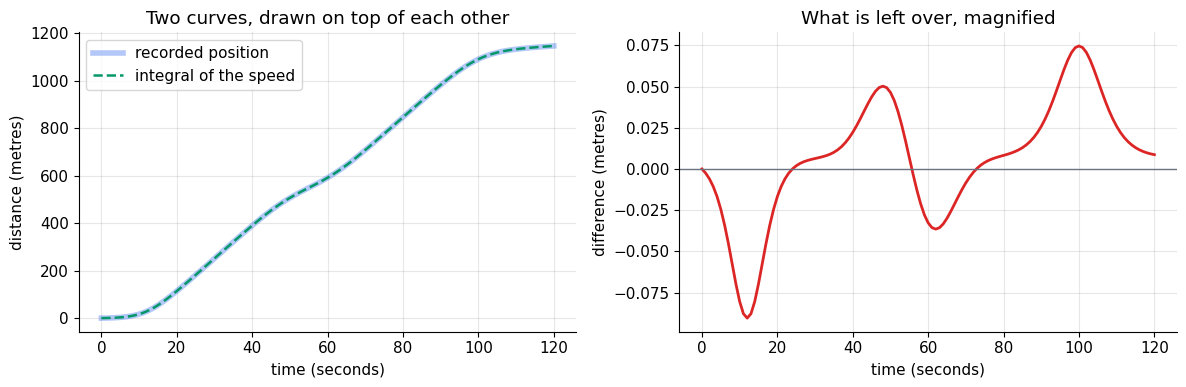

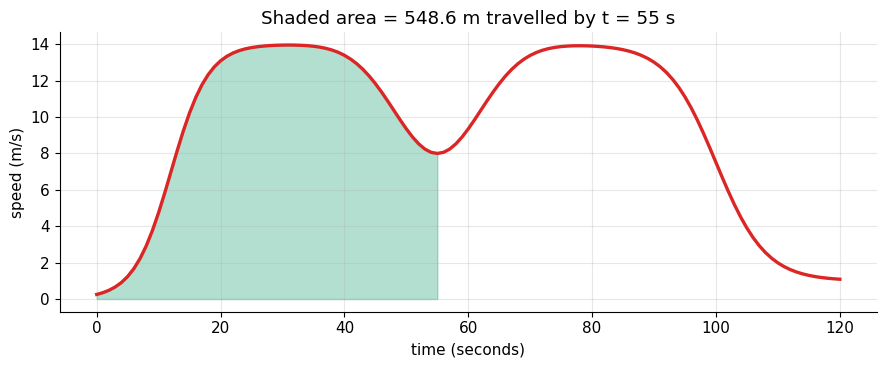

In [52]:
# ============================================================
#  Integrate the speed. Compare against the recorded positions.
# ============================================================
step  = 0.001                                     # one millisecond slivers
edges = np.arange(0.0, 120.0 + step / 2, step)    # 0.000, 0.001, ..., 120.000
mids  = edges[:-1] + step / 2                     # midpoint of every sliver

sliver_areas = speed_mps(mids) * step             # speed x time = distance
running      = np.concatenate([[0.0], np.cumsum(sliver_areas)])   # accumulate

# read the running total off at each whole second, to line up with pos_m
idx          = np.round(t_sec / step).astype(int)
integrated   = running[idx]

diff    = integrated - pos_m
maxdiff = np.abs(diff).max()

print(f"  slivers used            : {len(mids):,}  of width {step} s")
print(f"  integrated distance     : {integrated[-1]:,.4f} m")
print(f"  recorded pos_m[-1]      : {pos_m[-1]:,.4f} m")
print(f"  MAX ABSOLUTE DIFFERENCE : {maxdiff:.6f} m  "
      f"({100 * maxdiff / pos_m[-1]:.5f}% of the trip)\n")

# The same thing with the crude 1-second grid, for contrast.
coarse = np.concatenate([[0.0], np.cumsum((v_true[:-1] + v_true[1:]) / 2)])
print(f"  1-second trapezoid rule : max difference {np.abs(coarse - pos_m).max():.2e} m")
print("    (that one is zero by construction -- it is literally the arithmetic")
print("     Part 0 used to build pos_m from v_true in the first place.)")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.0))
ax1.plot(t_sec, pos_m, color=C_F, lw=4.0, alpha=0.35, label="recorded position")
ax1.plot(t_sec, integrated, color=C_AREA, lw=1.8, ls="--",
         label="integral of the speed")
ax1.set_xlabel("time (seconds)")
ax1.set_ylabel("distance (metres)")
ax1.set_title("Two curves, drawn on top of each other")
ax1.legend(loc="upper left")

ax2.plot(t_sec, diff, color=C_SLOPE, lw=2.0)
ax2.axhline(0, color=C_GREY, lw=1.0)
ax2.set_xlabel("time (seconds)")
ax2.set_ylabel("difference (metres)")
ax2.set_title("What is left over, magnified")
fig.tight_layout()
plt.show()

# And the picture of what we just did: area under the speed curve up to t = 55.
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(t_sec, v_true, color=C_SLOPE, lw=2.4)
ax.fill_between(t_sec, v_true, 0, where=(t_sec <= 55), color=C_AREA, alpha=0.30)
ax.set_xlabel("time (seconds)")
ax.set_ylabel("speed (m/s)")
ax.set_title(f"Shaded area = {integrated[55]:,.1f} m travelled by t = 55 s")
fig.tight_layout()
plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

**Left:** the thick pale blue line is the position that was recorded once a second; the dashed green line is what we just computed from the *speed alone*, by adding up 120,000 millisecond-wide slivers. They are indistinguishable, which is the point.

**Right:** the leftovers, blown up to their own scale. Notice they are not noise — the difference wanders smoothly, growing where the speed curve bends most sharply (the pull-away and the braking) and flattening on the cruise. That shape is the trapezoid rule's error signature, and it is telling you which part of the journey the one-second sampling struggled with. The printed maximum is a fraction of a metre out of well over a kilometre.

**Bottom:** the same computation drawn as what it is. The green region is the area under the speed curve up to $t=55$ s, and its area, in (metres per second) × (seconds), is metres — the distance covered.

**The common misread:** taking the near-perfect agreement as proof that our integration is exact. It is not. The two numbers agree because `pos_m` was itself *built* by accumulating the speed, so this is a check that our sum reproduces their sum. The honest reading of the right-hand panel is the reverse: it shows the small error in the **one-second** sampling that made `pos_m`, measured against our much finer one.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**The integral is a number. The antiderivative is a function. They are not the same object, and the notation goes out of its way to confuse you.**

$\int_0^3 x^2\,dx = 9$. That is a *number* — an area, a distance, a total. It has units. You could write it on a cheque. It is called a **definite** integral because those little $a$ and $b$ pin it down definitely.

You will also meet $\int x^2\,dx$, with no limits attached. That is a different kind of object entirely: a **function**, one whose derivative is $x^2$, called an *antiderivative* or *indefinite integral*. It has no units of area, it is not a total of anything, and it is not what we have been computing in this part — not once. Every single number on this page came from rectangles.

Why the same symbol, then? Because of a connection between the two that is genuinely surprising, is not remotely obvious from anything above, and is the whole subject of **Part 7**. Until you have seen that argument, treat them as two unrelated things that regrettably share a squiggle. Students who assume the link is definitional never appreciate what was proved.

</div>

### 6.7 In practice: `scipy.integrate.quad`

You will not hand-roll Riemann sums in production, any more than you write your
own sorting routine. `scipy.integrate.quad` does the job — adaptively, meaning
it puts many slivers where the function is wriggling and few where it is
placid — and it hands back **two** numbers: the estimate, and an estimate of its
own error. Read the second one. It is unusual and valuable for a library to
tell you how much to trust it.

#### An honest word about when this is the only option

By Part 7 you will have a shortcut that turns many integrals into a couple of
lines of algebra, and it will feel like the general method. It is not. It works
when you can find an antiderivative, and for a great many perfectly ordinary
functions **no antiderivative exists in terms of the functions you can write
down**. The bell curve $e^{-x^2}$ is the famous one — it sits at the heart of
statistics and there is provably no elementary formula for its integral.

That is not the only way the shortcut fails. It also fails when:

- your function only exists as **measured data** — sensor readings, a batch of
  losses, a histogram — with no formula to manipulate at all;
- the formula is known but so tangled that finding the antiderivative is harder
  than the problem you were trying to solve;
- the integral is over **many dimensions**, where the exact-formula toolkit
  runs out fast and Monte Carlo sampling takes over. Nearly every integral in
  modern machine learning is of this kind — expectations over
  high-dimensional distributions, evaluated by *averaging samples*, which is a
  Riemann sum with the slivers chosen at random.

So the rectangles are not the beginner's version that you outgrow. They are the
definition, they are the fallback, and in high dimensions they are the only
thing that still works.


In [53]:
# ============================================================
#  scipy does it adaptively, and tells you its own error bar.
# ============================================================
from scipy.integrate import quad

val, abserr = quad(f_demo, 0.0, 3.0)
print("A. an integral whose exact answer we PROVED above (should be 9):")
print(f"     quad estimate     = {val:.14f}")
print(f"     quad's error bar  = {abserr:.3e}")
print(f"     actual error      = {abs(val - 9.0):.3e}   "
      f"(inside its own bar: {abs(val - 9.0) <= abserr})")

print("\nB. the bell curve, which has NO elementary antiderivative:")
bell = lambda z: np.exp(-z ** 2)
val_b, err_b = quad(bell, 0.0, 1.0)
truth_b = float(sp.N(sp.sqrt(sp.pi) / 2 * sp.erf(1), 20))   # via the erf function
print(f"     quad estimate     = {val_b:.14f}")
print(f"     quad's error bar  = {err_b:.3e}")
print(f"     high-precision    = {truth_b:.14f}")
print(f"     actual error      = {abs(val_b - truth_b):.3e}")
print("     No formula-hunting will help here. Numerics is the answer, not a")
print("     substitute for one.")

print("\nC. our car, integrated by scipy instead of by our loop:")
val_c, err_c = quad(speed_mps, 0.0, 120.0, limit=200)
print(f"     quad estimate     = {val_c:,.6f} m   (error bar {err_c:.2e})")
print(f"     our midpoint sum  = {integrated[-1]:,.6f} m")
print(f"     recorded pos_m    = {pos_m[-1]:,.6f} m")
print(f"     quad vs our sum   = {abs(val_c - integrated[-1]):.2e} m")

print("\nD. why 'adaptive' matters -- a function that is calm then violent:")
spiky = lambda z: np.exp(-20000.0 * (z - 0.5) ** 2)   # a very narrow bump
val_d, err_d = quad(spiky, 0.0, 1.0)
print(f"     quad              = {val_d:.12f}   (error bar {err_d:.1e})")
for n in (20, 50, 200, 2000):
    got = mid_sum(spiky, 0.0, 1.0, n)
    print(f"     plain midpoint n={n:<5} = {got:.12f}"
          f"   off by {100 * abs(got - val_d) / val_d:8.4f}%")


A. an integral whose exact answer we PROVED above (should be 9):
     quad estimate     = 9.00000000000000
     quad's error bar  = 9.992e-14
     actual error      = 0.000e+00   (inside its own bar: True)

B. the bell curve, which has NO elementary antiderivative:
     quad estimate     = 0.74682413281243
     quad's error bar  = 8.291e-15
     high-precision    = 0.74682413281243
     actual error      = 1.110e-16
     No formula-hunting will help here. Numerics is the answer, not a
     substitute for one.

C. our car, integrated by scipy instead of by our loop:
     quad estimate     = 1,145.610117 m   (error bar 1.04e-08)
     our midpoint sum  = 1,145.610117 m
     recorded pos_m    = 1,145.601461 m
     quad vs our sum   = 4.33e-09 m

D. why 'adaptive' matters -- a function that is calm then violent:
     quad              = 0.012533141373   (error bar 4.1e-09)
     plain midpoint n=20    = 0.000000372665   off by  99.9970%
     plain midpoint n=50    = 0.005413411939   off by  

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

Four integrals, four independent confirmations, and not one of them asks you to trust `quad` on its own word.

**A** reproduces the 9 we derived from the sum-of-squares identity, to fourteen digits, and its real error genuinely falls inside the error bar it reported — the library's self-assessment is honest. **B** is checked against a high-precision evaluation of $\tfrac{\sqrt\pi}{2}\mathrm{erf}(1)$, a value that exists precisely *because* no elementary antiderivative does. **C** agrees with our own millisecond midpoint sum, which agrees with `pos_m` — three routes to the same distance.

**D** is the argument for adaptivity in one table. That function is essentially flat except for a narrow spike near $z=0.5$; the plain midpoint rule with 20 slivers steps over the spike and reports nonsense, and needs hundreds of slivers to recover. `quad` finds the spike and concentrates its effort there. Same idea as the rectangles, better bookkeeping.

</div>

<div style="background-color: #f8d7da; border-left: 5px solid #dc3545; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🤖 Why ML cares

Three places you have already been using integrals without knowing it.

**1. An expected value *is* an integral.** For a continuous random variable with probability density $p(x)$, the mean is $\mathbb{E}[X] = \int x\,p(x)\,dx$, and more generally $\mathbb{E}[f(X)] = \int f(x)\,p(x)\,dx$. Read it as a Riemann sum and it is exactly the weighted average you would compute by hand: for each thin sliver of $x$, the value there times how likely that sliver is, all added up. Every loss function you have ever minimised is an approximation to one of these — the training loss is $\mathbb{E}[\ell]$ over the true data distribution, estimated by averaging over the finite sample you happen to have. The batch average *is* the Riemann sum, with the slivers drawn at random instead of laid out in a row.

**2. A probability density integrates to 1.** That is what makes it a density: $\int_{-\infty}^{\infty} p(x)\,dx = 1$, the total area under the curve is one whole unit of certainty. It is also why $p(x)$ is *not* a probability and can happily exceed 1 — it is a probability **per unit of $x$**, a height, and only becomes a probability once you multiply by a width. That single distinction resolves most confusion about densities, and it is the same height-versus-area distinction you have been staring at all through this part. It is also why normalising constants exist at all, and why so much of Bayesian machine learning is a fight to compute one intractable integral.

**3. AUC is literally an area.** The "A" is *area*: the ROC curve plots true-positive rate against false-positive rate as you sweep the decision threshold, and AUC is $\int_0^1 \mathrm{TPR}\,d(\mathrm{FPR})$ — the area under it. When `sklearn.metrics.roc_auc_score` computes it, it is running the **trapezoid rule** over your thresholds. You now know exactly what that function does, why a coin-flip classifier scores 0.5 (the area under the diagonal of a unit square is half of it), and why AUC is insensitive to class imbalance in the way it is.

</div>

---

### Where you have got to

You can now define an integral without hand-waving: **chop, multiply, add,
shrink** — the limit of Riemann sums, which is a Part 2 limit wearing a
different hat. You can compute one by hand, know why the midpoint and trapezoid
rules beat the one-sided ones, know that area below the axis subtracts, know
the three properties, and know when to reach for `quad`.

You can also see the shape of the problem. Getting $9$ out of $\int_0^3 x^2\,dx$
took a special algebraic identity for $\sum i^2$ and a limit. That worked only
because $x^2$ is uncommonly cooperative. Try it on $x^7$, or $\sin x$, or the
car's speed, and the algebra collapses. Every honest exact answer in this part
came either from that one identity or from geometry — triangles and rectangles.

So the situation at the end of Part 6 is: we have a completely clear
*definition* of the integral and almost no way to *evaluate* one.

Meanwhile, over in Parts 3 to 5, you built an efficient machine for the opposite
problem. You can differentiate essentially anything you can write down, quickly,
using rules you derived yourself.

Two halves of the subject, developed independently, apparently unrelated: one
about slopes and one about areas. Part 7 is where somebody notices they are the
same machine running in opposite directions — and hands you, as a side effect,
the ability to evaluate integrals in a line of algebra.

---


---

# 7️⃣ The Fundamental Theorem: why the two halves are one subject

<div style="background: linear-gradient(135deg, #0F2027 0%, #2C5364 100%); padding: 28px; border-radius: 18px; color: white; margin: 12px 0;">


### Nothing so far suggests these two things are related.

**Part 3** asked a question about a single point: *how steep is this curve right here?* We answered it by shrinking a window until it vanished.

**Part 6** asked a question about a whole stretch: *how much area sits under this curve between here and there?* We answered it by chopping the stretch into rectangles and adding them up.

One is about **steepness at an instant**. The other is about **accumulation over an interval**. Different questions, different pictures, different machinery. There is no obvious reason they should have anything to do with each other.

They turn out to be **exact opposites** — each one undoes the other.

That is the Fundamental Theorem of Calculus, and this part is where you find it yourself rather than being told it.


</div>

### It was not obvious historically either

People computed areas for about two thousand years before anybody noticed
this. Archimedes found the area under a parabola around 250 BC by an
exhausting slicing argument — essentially Part 6, done by hand, as a research
achievement. Tangent lines were studied separately, as a problem in geometry
and optics. The two subjects had different names and different practitioners.

It was only in the 1660s that Isaac Barrow, and then Newton and Leibniz, saw
that the two operations are inverse to one another — and that once you know
this, an area problem that cost Archimedes a treatise costs you one line.

So if the connection does not feel obvious to you, you are in excellent
company: it was not obvious to anyone for twenty centuries.

**The plan for this part:**

1. Build the **area function** — area accumulated so far, as a function of where you stop.
2. Differentiate it **numerically**, and look at what comes back. *(This is the discovery. Do not skip it.)*
3. Explain *why* it had to come back, with one picture and one line of algebra.
4. Use the result to compute exactly, in one line, an integral that Part 6 could only creep up on with 256 rectangles.
5. Close the loop on the car journey: recover speed from position, and position from speed, and see the theorem hold on real sampled data.


---

### 7.1 The area function: the object everything hinges on

Part 6 computed one number — the area under $f$ between two **fixed** ends $a$
and $b$. Now we let the right-hand end **move**.

Fix the left end at $a$. For any $x$ beyond it, define

$$A(x) \;=\; \int_a^x f(t)\, dt$$

read aloud as *"A of x equals the integral, from a to x, of f of t, dee t"*.

Two pieces of notation deserve a sentence each, because they are the only
awkward things here:

- The **upper limit is $x$**, a variable. So $A$ is not a number, it is a *function*: feed it a stopping point, get back the area accumulated up to that point.
- The variable inside is written $t$, not $x$. That is not a typo and it is not a new idea. $t$ is the thing that sweeps across the interval while we add up slivers; $x$ is where we stop. Using one letter for both would be like writing `for x in range(x)`. The letter $t$ is a **dummy** — $\int_a^x f(t)\,dt$ and $\int_a^x f(u)\,du$ are the same number.

$A$ is sometimes called the **accumulation function**, which is the better
name: it is the running total. Most treatments introduce it in half a sentence
and hurry on. It is worth slowing down for, because every single thing in this
part is a fact about $A$.

Let us build one, with nothing but Part 6's trapezoids, and look at it next to
$f$.


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

$A(x)$ is **how much area you have collected so far**, if you started at $a$ and swept rightwards, stopping at $x$.

Think of $f$ as the rate water flows in from a tap, and $A$ as the amount of water in the bath. When the tap runs hard ($f$ tall), the level climbs fast. When the tap is barely on ($f$ short), the level still climbs — just slowly. The level never falls, as long as the tap is not sucking water back out.

Everything in this part comes from taking one sentence seriously: **how fast the bath fills is exactly how hard the tap is running.**

</div>

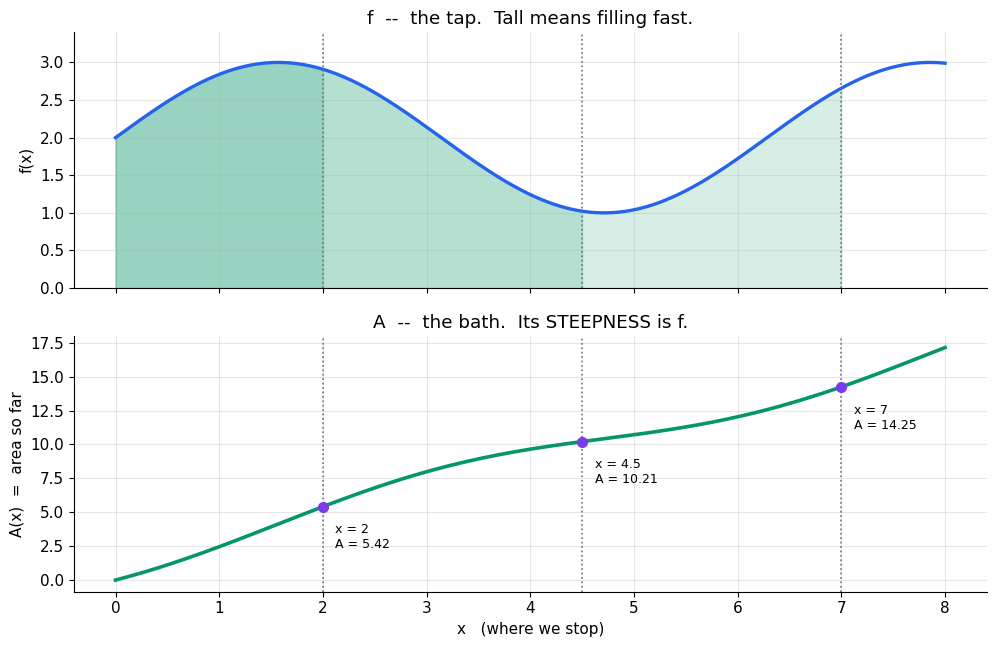

Area collected so far, at a few stopping points:
    A( 1.0) =   2.4597      (f there = 2.841)
    A( 2.0) =   5.4161      (f there = 2.909)
    A( 4.5) =  10.2108      (f there = 1.022)
    A( 7.0) =  14.2461      (f there = 2.657)
    A( 8.0) =  17.1455      (f there = 2.989)

Two things to notice, both visible in the picture:
  * A never decreases -- f is never negative, so the tap never reverses.
  * A is STEEPEST exactly where f is TALLEST, and flattest where f dips.


In [54]:
# ============================================================
#  The area function, built by brute force.
#  f wiggles on purpose: it has tall stretches and short ones,
#  so we can watch A climb fast and then climb slowly.
# ============================================================
def f_demo(z):
    """A positive, wiggling function. Nothing special about it."""
    return 2.0 + np.sin(z)

A_LO, A_HI = 0.0, 8.0
xs  = np.linspace(A_LO, A_HI, 8001)      # step exactly 0.001
fs  = f_demo(xs)
dxs = xs[1] - xs[0]

# A(x) = area under f from A_LO up to x, accumulated as we sweep right.
# This is EXACTLY the trapezoid rule of Part 6 -- kept running, instead of
# reported once at the end. A[0] = 0, because we have not gone anywhere yet.
A_num = np.concatenate([[0.0], np.cumsum((fs[:-1] + fs[1:]) / 2 * dxs)])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6.6), sharex=True)

ax1.plot(xs, fs, color=C_F, lw=2.4)
ax1.set_ylabel("f(x)")
ax1.set_ylim(0, 3.4)
ax1.set_title("f  --  the tap.  Tall means filling fast.")

ax2.plot(xs, A_num, color=C_AREA, lw=2.6)
ax2.set_ylabel("A(x)  =  area so far")
ax2.set_xlabel("x   (where we stop)")
ax2.set_title("A  --  the bath.  Its STEEPNESS is f.")

# mark three stopping points, and shade the area each one has collected
for xm, tag in [(2.0, "x = 2"), (4.5, "x = 4.5"), (7.0, "x = 7")]:
    k = int(round((xm - A_LO) / dxs))
    ax1.fill_between(xs[:k + 1], 0, fs[:k + 1], color=C_AREA, alpha=0.16)
    ax1.axvline(xm, color=C_GREY, ls=":", lw=1.2)
    ax2.axvline(xm, color=C_GREY, ls=":", lw=1.2)
    ax2.plot([xm], [A_num[k]], "o", color=C_EXACT, ms=7, zorder=5)
    ax2.annotate(f"{tag}\nA = {A_num[k]:.2f}", (xm, A_num[k]),
                 textcoords="offset points", xytext=(9, -30), fontsize=9)

fig.tight_layout()
plt.show()

print("Area collected so far, at a few stopping points:")
for xm in (1.0, 2.0, 4.5, 7.0, 8.0):
    k = int(round((xm - A_LO) / dxs))
    print(f"    A({xm:>4.1f}) = {A_num[k]:8.4f}      "
          f"(f there = {fs[k]:.3f})")
print()
print("Two things to notice, both visible in the picture:")
print("  * A never decreases -- f is never negative, so the tap never reverses.")
print("  * A is STEEPEST exactly where f is TALLEST, and flattest where f dips.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

**Top:** the function $f$, with the area collected so far shaded at three stopping points. **Bottom:** that accumulated area, replotted as a function of where you stopped. The dotted lines link the two panels.

Follow $x$ from left to right. Where the top curve is **tall** (near $x \approx 1.6$, where $\sin$ peaks) the bottom curve climbs **steeply** — area is piling on fast. Where the top curve dips **low** (near $x \approx 4.7$) the bottom curve still rises, but **lazily**. The bottom curve has gentle ripples in exactly the places where the top curve wiggles, and they are a quarter-cycle out of step in exactly the way a curve and its slope always are.

That correspondence — *height of the top panel = steepness of the bottom panel* — is the entire theorem, visible before we have proved anything at all.

**The common misread:** expecting $A$ to go **down** where $f$ goes down. It does not. $f$ going down means the bath is filling *more slowly*, not emptying. $A$ falls only where $f$ is actually **negative**.

</div>

---

### 7.2 The discovery: differentiate the area and see what happens

We now have $A$ as an array of numbers, and Part 3 taught us how to
differentiate an array of numbers: take the slope between neighbouring points.

So let us do the strangest-looking thing available and **differentiate the area
function**. On the face of it this is a meaningless mash-up — one of these
operations is about steepness at a point, the other about accumulation over an
interval, and combining them should produce a mess.

Look at what comes back instead.


max  | d/dx A(x)  minus  f(x) |  =  5.000e-04
mean | d/dx A(x)  minus  f(x) |  =  2.323e-07
(for scale, f itself ranges over 1.000 .. 3.000)

    x       d/dx A(x)          f(x)         difference
   0.5       2.47942542     2.47942554     -1.20e-07
   1.6       2.99957335     2.99957360     -2.50e-07
   3.0       2.14111997     2.14112001     -3.53e-08
   4.7       1.00007699     1.00007674     +2.50e-07
   6.2       1.91691062     1.91691060     +2.08e-08
   7.5       2.93799974     2.93799998     -2.34e-07


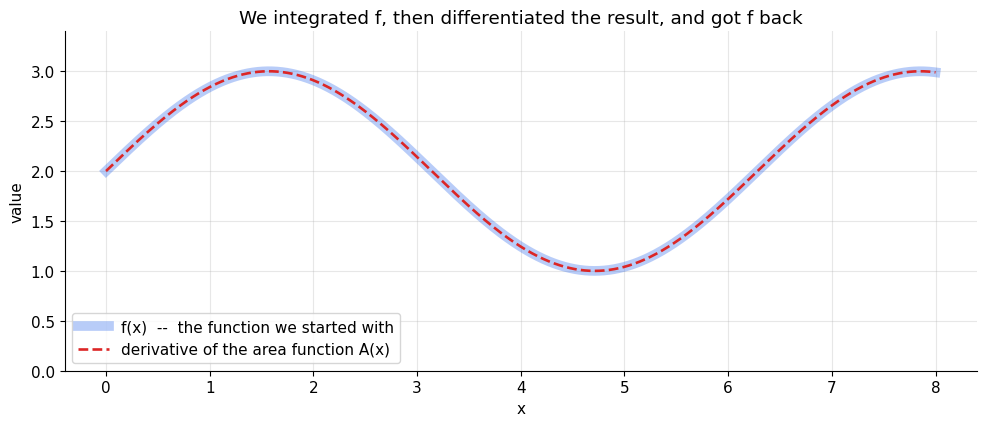

In [55]:
# ============================================================
#  Differentiate A numerically -- Part 3's difference quotient,
#  applied to the array we just built.
#  np.gradient computes the central difference
#         ( A[i+1] - A[i-1] ) / (2 * step)
#  which is exactly the symmetric slope estimate from Part 3.
# ============================================================
dA = np.gradient(A_num, xs)

err = np.abs(dA - fs)
print(f"max  | d/dx A(x)  minus  f(x) |  =  {err.max():.3e}")
print(f"mean | d/dx A(x)  minus  f(x) |  =  {err.mean():.3e}")
print(f"(for scale, f itself ranges over {fs.min():.3f} .. {fs.max():.3f})")
print()
print("    x       d/dx A(x)          f(x)         difference")
for xm in (0.5, 1.6, 3.0, 4.7, 6.2, 7.5):
    k = int(round((xm - A_LO) / dxs))
    print(f"  {xm:4.1f}     {dA[k]:12.8f}   {fs[k]:12.8f}     {dA[k] - fs[k]:+.2e}")

fig, ax = plt.subplots(figsize=(10, 4.4))
ax.plot(xs, fs, color=C_F, lw=7, alpha=0.32,
        label="f(x)  --  the function we started with")
ax.plot(xs, dA, color=C_SLOPE, lw=1.9, ls="--",
        label="derivative of the area function A(x)")
ax.set_xlabel("x")
ax.set_ylabel("value")
ax.set_ylim(0, 3.4)
ax.set_title("We integrated f, then differentiated the result, and got f back")
ax.legend(loc="lower left")
fig.tight_layout()
plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The thick pale blue curve is $f$, the function we started with. The dashed red curve is the **derivative of the area function** — computed entirely numerically, by adding up trapezoids and then taking slopes, with no algebra anywhere in the pipeline.

They lie on top of each other. Not merely similar in shape: identical to the number of decimal places printed in the table above. What little disagreement remains is Part 6's trapezoid error plus Part 3's finite-difference error, and it shrinks if you refine the grid.

**Integrating and then differentiating gave back exactly what we put in.** That is the claim of the theorem, found here by experiment before being stated.

**The common misread:** taking this for a coincidence of the particular $f$ we picked. Change `f_demo` to anything continuous — a polynomial, `np.exp`, something spiky — rerun, and the two curves still coincide. That universality is what makes it a theorem rather than an observation.

</div>

---

### 7.3 Why it had to happen: one sliver, one line of algebra

The numbers agree. Now the reason — which is short enough to hold in your head
for the rest of your life.

Ask what $A(x+h) - A(x)$ actually means, where $h$ is a small step to the right.

- $A(x+h)$ is the area collected from $a$ all the way up to $x+h$.
- $A(x)$ is the area collected from $a$ up to $x$.
- Subtract them, and **everything from $a$ to $x$ cancels.** What survives is only the area of the thin sliver between $x$ and $x+h$:

$$A(x+h) - A(x) \;=\; \int_x^{x+h} f(t)\,dt$$

Now look at that sliver. It is a strip of width $h$ whose top edge is a tiny
snippet of the curve $f$. If $h$ is small, the curve barely has room to move
across it — so the strip is very nearly a **rectangle** of width $h$ and
height $f(x)$:

$$A(x+h) - A(x) \;\approx\; f(x)\cdot h$$

Divide both sides by $h$. The left-hand side is now precisely the difference
quotient from Part 3:

$$\frac{A(x+h) - A(x)}{h} \;\approx\; f(x)$$

Let $h \to 0$. The approximation gets **better**, not worse, because the top of
the sliver gets flatter as it narrows. So the limit is exact:

$$A'(x) \;=\; f(x)$$

That is the whole proof. One cancellation, one rectangle, one limit. The
picture below is the cancellation and the rectangle; the table below it is the
limit.


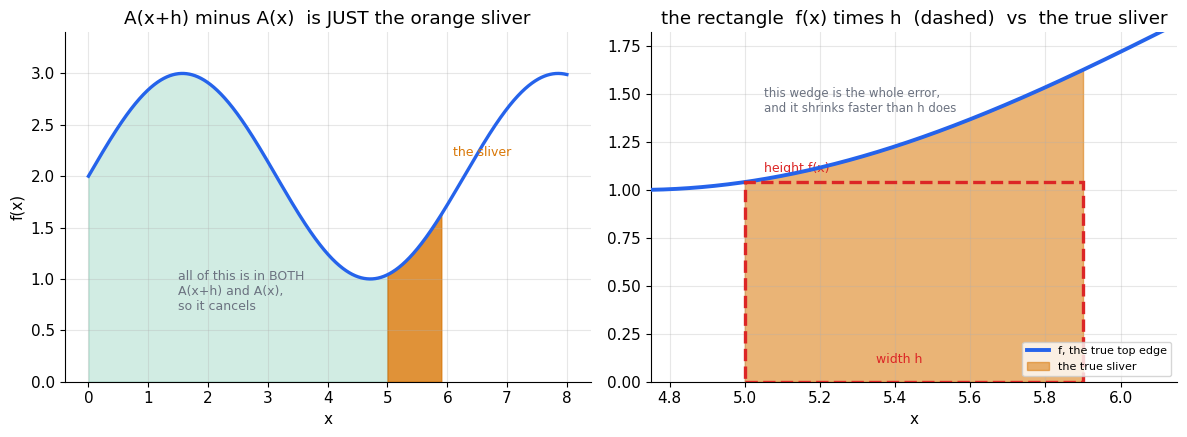

At x = 5.0:    f(x) = 1.041075725

      h        ( A(x+h) - A(x) ) / h        difference from f(x)
   0.9000             1.284648676            +2.436e-01
   0.3000             1.097626239            +5.655e-02
   0.1000             1.056844506            +1.577e-02
   0.0300             1.045474251            +4.399e-03
   0.0100             1.042510086            +1.434e-03
   0.0030             1.041502737            +4.270e-04
   0.0010             1.041217796            +1.421e-04

The quotient walks straight into f(x) -- roughly one extra decimal place
each time h shrinks tenfold. That is A'(x) = f(x), watched happening
rather than asserted.


In [56]:
# ============================================================
#  The sliver -- drawn, and then measured as h shrinks.
# ============================================================
X0 = 5.0
k0 = int(round((X0 - A_LO) / dxs))
H_BIG = 0.9
k1 = int(round((X0 + H_BIG - A_LO) / dxs))

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.5))

# ---- left: the whole picture, with the sliver picked out -------------------
axL.plot(xs, fs, color=C_F, lw=2.4)
axL.fill_between(xs[:k0 + 1], 0, fs[:k0 + 1], color=C_AREA, alpha=0.18)
axL.fill_between(xs[k0:k1 + 1], 0, fs[k0:k1 + 1], color=C_APPROX, alpha=0.80)
axL.set_ylim(0, 3.4)
axL.set_xlabel("x")
axL.set_ylabel("f(x)")
axL.set_title("A(x+h) minus A(x)  is JUST the orange sliver")
axL.annotate("all of this is in BOTH\nA(x+h) and A(x),\nso it cancels",
             (1.5, 0.7), fontsize=9, color=C_GREY)
axL.annotate("the sliver", (X0 + H_BIG + 0.2, 2.2), fontsize=9, color=C_APPROX)

# ---- right: zoom in, and lay the rectangle f(x)*h over it ------------------
zl, zr = X0 - 0.25, X0 + H_BIG + 0.25
mz = (xs >= zl) & (xs <= zr)
axR.plot(xs[mz], fs[mz], color=C_F, lw=2.8, zorder=4, label="f, the true top edge")
axR.fill_between(xs[k0:k1 + 1], 0, fs[k0:k1 + 1], color=C_APPROX, alpha=0.55,
                 label="the true sliver")
axR.add_patch(plt.Rectangle((X0, 0), H_BIG, fs[k0], fill=False,
                            edgecolor=C_SLOPE, lw=2.4, ls="--", zorder=5))
axR.set_xlim(zl, zr)
axR.set_ylim(0, fs[k0] * 1.75)
axR.set_xlabel("x")
axR.set_title("the rectangle  f(x) times h  (dashed)  vs  the true sliver")
axR.annotate("height f(x)", (X0 + 0.05, fs[k0] * 1.05), fontsize=9, color=C_SLOPE)
axR.annotate("width h", (X0 + H_BIG / 2 - 0.1, 0.1), fontsize=9, color=C_SLOPE)
axR.annotate("this wedge is the whole error,\nand it shrinks faster than h does",
             (X0 + 0.05, fs[k0] * 1.35), fontsize=8.5, color=C_GREY)
axR.legend(loc="lower right", fontsize=8)

fig.tight_layout()
plt.show()

# ---- and now the numbers, as h shrinks ------------------------------------
# We read A straight off the array we built, so nothing here knows any algebra.
print(f"At x = {X0}:    f(x) = {f_demo(X0):.9f}")
print()
print("      h        ( A(x+h) - A(x) ) / h        difference from f(x)")
for hh in (0.9, 0.3, 0.1, 0.03, 0.01, 0.003, 0.001):
    step = int(round(hh / dxs))
    q = (A_num[k0 + step] - A_num[k0]) / hh
    print(f"  {hh:7.4f}          {q:14.9f}            {q - f_demo(X0):+.3e}")
print()
print("The quotient walks straight into f(x) -- roughly one extra decimal place")
print("each time h shrinks tenfold. That is A'(x) = f(x), watched happening")
print("rather than asserted.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

**Left:** the green region is $A(x)$, the area collected up to $x=5$. The orange strip is what you add by moving the stopping point out to $x+h$. Subtracting $A(x)$ from $A(x+h)$ leaves nothing but that strip — the entire green region appears in both and cancels. That cancellation is the first half of the proof, and it is the half people skip.

**Right:** the same strip, zoomed. The dashed red box is the rectangle $f(x)\cdot h$. It is *not* the sliver — the true top edge curves away from it — and the gap between them is the little wedge along the top. Halve $h$ and that wedge shrinks *faster* than the rectangle does, which is exactly why dividing by $h$ leaves an error that goes to zero.

The table underneath is the same fact in numbers, read straight off the array we accumulated: the difference quotient of $A$ marches into $f(5)$.

**The common misread:** thinking the rectangle has to be *exactly* the sliver for the argument to work. It never is, at any $h$. The argument only needs the **error** to vanish faster than $h$ does, so that it disappears after the division. Every limit in this notebook has that same shape.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

**Fundamental Theorem, Part 1** — *differentiating an accumulation gives back the rate:*

$$\frac{d}{dx}\int_a^x f(t)\,dt \;=\; f(x)$$

In words: **if you add something up, and then ask how fast the total is growing, the answer is the thing you were adding.** The bath fills at the rate the tap runs. Your bank balance grows at the rate money comes in. The odometer climbs at the speed you are driving.

As a slogan: *integration and differentiation are inverse operations.* Do one, then the other, and you are back where you started.

Notice what the left-hand end $a$ contributes to that formula: **nothing**. Start accumulating wherever you like; changing $a$ shifts the whole of $A$ up or down by a constant, and constants have zero derivative. That fact is about to reappear wearing a different hat, called $+C$.

</div>

---

### 7.4 Part 2: how to actually compute an integral

Part 1 is the *idea*. Part 2 is the *tool*, and it falls out of Part 1 in three
lines.

Suppose you can find **any** function $F$ whose derivative is $f$:

$$F'(x) = f(x)$$

Such an $F$ is called an **antiderivative** of $f$ — a function that $f$ is the
derivative of. Now put $F$ next to our area function $A$:

- $A' = f$, by Part 1, which we have just proved.
- $F' = f$, by assumption.

So $A$ and $F$ have the same derivative everywhere, which means $(A-F)' = 0$
everywhere, which means — by the result from Part 5 that a function with zero
derivative everywhere is flat — that

$$A(x) = F(x) + C \qquad \text{for some constant } C.$$

Now use the one value of $A$ we know for free: $A(a) = 0$, because the area
from $a$ to $a$ is nothing at all. That pins the constant down: $0 = F(a) + C$,
so $C = -F(a)$. Therefore $A(x) = F(x) - F(a)$, and setting $x = b$:

$$\boxed{\;\int_a^b f(x)\,dx \;=\; F(b) - F(a)\;}\qquad \text{where } F' = f$$

That is **Fundamental Theorem, Part 2**, and it has one of the highest
effort-to-reward ratios in mathematics. The left-hand side is a limit of sums
of infinitely many rectangles. The right-hand side is two numbers, subtracted.

The shorthand $\Big[F(x)\Big]_a^b$ means exactly $F(b) - F(a)$; you will meet
it written that way everywhere.

Let us cash it in on an integral that rectangles can only creep towards.


In [57]:
# ============================================================
#  The payoff.
#  Part 6 would attack this integral with rectangles:
#          integral, from 0 to pi, of   x * sin(x)  dx
#  We do it BOTH ways and put the answers side by side.
# ============================================================
def g_demo(z):
    return z * np.sin(z)

a_lim, b_lim = 0.0, np.pi

# ---- the Part 6 way: 256 left rectangles ---------------------------------
n_rect = 256
edges  = np.linspace(a_lim, b_lim, n_rect + 1)
w_rect = (b_lim - a_lim) / n_rect
riemann_256 = np.sum(g_demo(edges[:-1])) * w_rect

# ---- the Part 7 way: find F with F' = g, then subtract two numbers -------
# Guess F(x) = sin(x) - x*cos(x). A guess is worthless until it is checked,
# so differentiate it back before using it. If the guess is wrong this cell
# raises AssertionError instead of quietly printing a wrong number.
F_sym = sp.sin(x) - x * sp.cos(x)
print("guessed   F(x) =", F_sym)
print("its derivative =", sp.simplify(sp.diff(F_sym, x)), "  <- must be x*sin(x)")
assert sp.simplify(sp.diff(F_sym, x) - x * sp.sin(x)) == 0
print("CHECKED: F really is an antiderivative of x*sin(x).")
print()

F_demo = lambda z: np.sin(z) - z * np.cos(z)
exact  = F_demo(b_lim) - F_demo(a_lim)

print("By hand, F(pi) - F(0):")
print("   F(pi) = sin(pi) - pi*cos(pi) = 0 - pi*(-1) = pi")
print("   F(0)  = sin(0)  - 0*cos(0)   = 0")
print("   so the integral is exactly pi.")
print("   sympy, asked independently   :",
      sp.integrate(x * sp.sin(x), (x, 0, sp.pi)))
print()
print("=" * 64)
print(f"  256 rectangles (Part 6)  : {riemann_256:.12f}")
print(f"  F(b) - F(a)    (Part 7)  : {exact:.12f}")
print(f"  pi                       : {np.pi:.12f}")
print(f"  rectangle error          : {abs(riemann_256 - np.pi):.3e}")
print(f"  antiderivative error     : {abs(exact - np.pi):.3e}")
print("=" * 64)
print()
print("How many rectangles would Part 6 need in order to catch up?")
for n in (16, 64, 256, 1024, 4096, 16384, 65536):
    e = np.linspace(a_lim, b_lim, n + 1)
    s = np.sum(g_demo(e[:-1])) * (b_lim - a_lim) / n
    print(f"    n = {n:>6}   ->   {s:.10f}    error {abs(s - np.pi):.2e}")
print()
print("It never catches up. It only creeps, and each decimal place costs it")
print("about ten times the work. The antiderivative does not creep: it hands")
print("you pi -- the actual number, not a decimal approximation to it -- for")
print("the price of one subtraction.")


guessed   F(x) = -x*cos(x) + sin(x)
its derivative = x*sin(x)   <- must be x*sin(x)
CHECKED: F really is an antiderivative of x*sin(x).

By hand, F(pi) - F(0):
   F(pi) = sin(pi) - pi*cos(pi) = 0 - pi*(-1) = pi
   F(0)  = sin(0)  - 0*cos(0)   = 0
   so the integral is exactly pi.


   sympy, asked independently   : pi

  256 rectangles (Part 6)  : 3.141553226971
  F(b) - F(a)    (Part 7)  : 3.141592653590
  pi                       : 3.141592653590
  rectangle error          : 3.943e-05
  antiderivative error     : 0.000e+00

How many rectangles would Part 6 need in order to catch up?
    n =     16   ->   3.1314929732    error 1.01e-02
    n =     64   ->   3.1409618039    error 6.31e-04
    n =    256   ->   3.1415532270    error 3.94e-05
    n =   1024   ->   3.1415901894    error 2.46e-06
    n =   4096   ->   3.1415924996    error 1.54e-07
    n =  16384   ->   3.1415926440    error 9.63e-09
    n =  65536   ->   3.1415926530    error 6.02e-10

It never catches up. It only creeps, and each decimal place costs it
about ten times the work. The antiderivative does not creep: it hands
you pi -- the actual number, not a decimal approximation to it -- for
the price of one subtraction.


<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

Nothing above was asserted. The guessed antiderivative $F(x)=\sin x - x\cos x$ was **differentiated by sympy and asserted equal to $x\sin x$** before it was allowed to be used, so a wrong guess would have stopped the cell rather than printed a plausible number.

Then two entirely independent routes to the same integral were printed side by side: 256 rectangles, using only Part 6's machinery, which knows nothing about antiderivatives; and $F(\pi)-F(0)$, using only this part's theorem. They agree, and sympy's symbolic engine — a third independent route — agrees with the hand calculation.

The convergence table is the honest measure of what the theorem bought us: the rectangle answer improves by roughly a factor of four each time you quadruple the work, and never arrives. And the exact answer is not a decimal at all — it is $\pi$. Sixty-five thousand rectangles cannot tell you that. Two evaluations of $F$ can.

</div>

---

### 7.5 Antiderivatives, and the constant everybody forgets

An **antiderivative** of $f$ is any $F$ with $F' = f$. Note *any*: they are not
unique, and the reason is a one-liner from Part 4.

The derivative of a constant is zero. So if $F' = f$, then $(F + 7)' = f$ too,
and $(F - 1.3)' = f$, and $(F + C)' = f$ for every constant $C$ on Earth. There
is no such thing as *the* antiderivative; there is an infinite **family** of
them, stacked vertically, all with identical shape.

The **indefinite integral** notation collects the whole family at once:

$$\int f(x)\,dx \;=\; F(x) + C$$

Notice it carries no limits on the integral sign — because it is not an area,
it is a *family of functions*. That is a genuinely different kind of object
from $\int_a^b f(x)\,dx$, which is a **number**. Same symbol, two meanings; the
limits are how you tell them apart.

And here is the part that rescues you in practice: **in a definite integral the
constant always cancels**, because you subtract.

$$\big(F(b) + C\big) - \big(F(a) + C\big) \;=\; F(b) - F(a)$$

So when computing an area you may set $C = 0$ and forget it. When *recovering a
function* — solving a differential equation, reconstructing position from
velocity — you may not, because $C$ is exactly the information that
differentiation threw away.


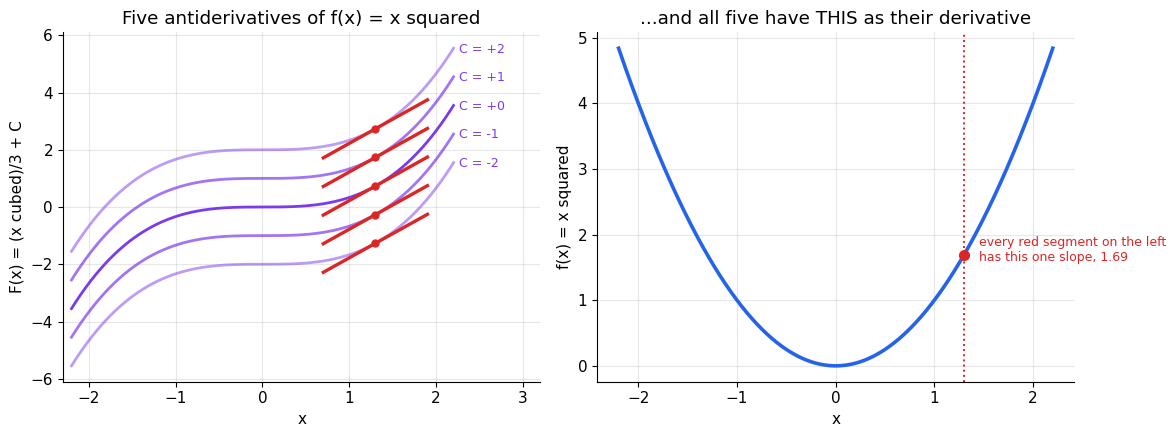

Integral of x squared from 0.5 to 2.0, computed with different C:

   C =     -2.0    F(b) =        0.6667   F(a) =     -1.9583   F(b) - F(a) = 2.6250000000
   C =      0.0    F(b) =        2.6667   F(a) =      0.0417   F(b) - F(a) = 2.6250000000
   C =      3.7    F(b) =        6.3667   F(a) =      3.7417   F(b) - F(a) = 2.6250000000
   C =   1000.0    F(b) =     1002.6667   F(a) =   1000.0417   F(b) - F(a) = 2.6250000000

   sympy, definite integral, no C anywhere = 2.6250000000

Every C gives the same answer, to every decimal place. That is why you
may set it to zero when computing an area -- and why you may NOT when
you are reconstructing a function.


In [58]:
# ============================================================
#  The family: every one of these has derivative x**2.
# ============================================================
xs3   = np.linspace(-2.2, 2.2, 400)
X_TAN = 1.3
SLOPE = X_TAN ** 2                 # d/dx of x**3/3 is x**2

fig, (axA, axB) = plt.subplots(1, 2, figsize=(12, 4.5))

for Cval, alpha in zip([-2, -1, 0, 1, 2], [0.5, 0.7, 1.0, 0.7, 0.5]):
    axA.plot(xs3, xs3 ** 3 / 3 + Cval, color=C_EXACT, lw=2.0, alpha=alpha)
    y0  = X_TAN ** 3 / 3 + Cval
    seg = np.array([-0.6, 0.6])
    axA.plot(X_TAN + seg, y0 + SLOPE * seg, color=C_SLOPE, lw=2.4)
    axA.plot([X_TAN], [y0], "o", color=C_SLOPE, ms=5, zorder=5)
    axA.annotate(f"C = {Cval:+d}", (2.26, 2.2 ** 3 / 3 + Cval - 0.15),
                 fontsize=9, color=C_EXACT)

axA.set_xlim(-2.3, 3.2)
axA.set_xlabel("x")
axA.set_ylabel("F(x) = (x cubed)/3 + C")
axA.set_title("Five antiderivatives of f(x) = x squared")

axB.plot(xs3, xs3 ** 2, color=C_F, lw=2.6)
axB.set_xlabel("x")
axB.set_ylabel("f(x) = x squared")
axB.set_title("...and all five have THIS as their derivative")
axB.axvline(X_TAN, color=C_SLOPE, ls=":", lw=1.4)
axB.plot([X_TAN], [SLOPE], "o", color=C_SLOPE, ms=7, zorder=5)
axB.annotate(f"every red segment on the left\nhas this one slope, {SLOPE:.2f}",
             (X_TAN + 0.15, SLOPE - 0.1), fontsize=9, color=C_SLOPE)

fig.tight_layout()
plt.show()

# ---- the cancellation, shown rather than claimed --------------------------
a_c, b_c = 0.5, 2.0
print(f"Integral of x squared from {a_c} to {b_c}, computed with different C:")
print()
for Cval in (-2.0, 0.0, 3.7, 1000.0):
    Fb = b_c ** 3 / 3 + Cval
    Fa = a_c ** 3 / 3 + Cval
    print(f"   C = {Cval:>8.1f}    F(b) = {Fb:>13.4f}   F(a) = {Fa:>11.4f}"
          f"   F(b) - F(a) = {Fb - Fa:.10f}")
print()
print(f"   sympy, definite integral, no C anywhere = "
      f"{float(sp.integrate(x ** 2, (x, sp.Rational(1, 2), 2))):.10f}")
print()
print("Every C gives the same answer, to every decimal place. That is why you")
print("may set it to zero when computing an area -- and why you may NOT when")
print("you are reconstructing a function.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

**Left:** five different antiderivatives of $f(x)=x^2$, differing only by a vertical shift. The short red segments are the tangent lines at $x = 1.3$ on each curve — and they are **parallel**. Sliding a curve up or down does not change how steep it is anywhere.

**Right:** the single function $f(x)=x^2$ that all five of them differentiate down to. Five curves, one derivative. Differentiation collapses the family to a point, and going back up you cannot possibly know which member you came from — $+C$ is the honest admission of that.

The printout underneath is the cancellation made explicit: pick $C = -2$, $0$, $3.7$ or $1000$, and $F(b)-F(a)$ is identical to ten decimal places, matching sympy's definite integral.

**The common misread:** reading $+C$ as bookkeeping pedantry invented to catch you out in exams. It is the genuine content of the theorem's limits: differentiation destroys the starting level, so integration cannot recover it. In an initial value problem, $C$ *is* the initial value.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**1. Dropping the $+C$.** Writing $\int x^2\,dx = x^3/3$ is wrong: it names one member of an infinite family as though it were the family. In a *definite* integral you get away with it, because $C$ cancels. In a differential equation you do not — dropping it silently discards the initial condition, and your solution passes through the wrong point. This is not an exam technicality; it is the difference between "the car is somewhere, moving like this" and "the car started at the origin".

**2. Mixing up FTC Part 1 and Part 2.** They point in opposite directions, and it is worth being able to say instantly which is which:

| | Part 1 | Part 2 |
|---|---|---|
| Statement | $\dfrac{d}{dx}\displaystyle\int_a^x f(t)\,dt = f(x)$ | $\displaystyle\int_a^b f(x)\,dx = F(b) - F(a)$ |
| Order of operations | integrate, **then** differentiate | antidifferentiate, **then** subtract |
| Hands you back | a **function** | a **number** |
| Used for | proving things; differentiating integrals with a variable limit | actually computing definite integrals |

The tell: **Part 1 has a variable upper limit and a $d/dx$ sitting outside. Part 2 has two fixed limits and no derivative in sight.** If your integral has numbers at both ends, you want Part 2.

</div>

---

### 7.6 Closing the loop: the car journey, in both directions

Time to collect on the promise Part 0 made.

We have one dataset and two derived quantities:

- In **Part 3** we took `pos_m`, differentiated it numerically, and got something that looked like speed.
- In **Part 6** we took `v_true`, integrated it numerically, and got something that looked like position.

Those were two separate exercises, done chapters apart, with no stated reason
to be consistent with one another. The Fundamental Theorem says they **must**
be: position is the accumulation of speed, so differentiating position has to
return speed, and integrating speed has to return position. Neither result was
an accident, and each is now a check on the other.

Run both directions on the same data and put the two errors side by side.


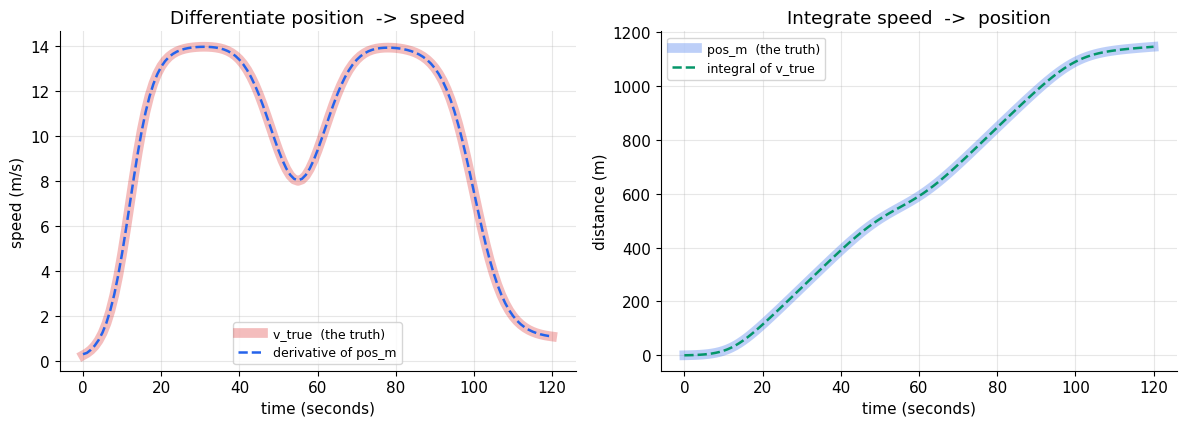

  direction                        max error      mean error       scale
--------------------------------------------------------------------------
  differentiate pos_m -> speed     4.857e-02     1.264e-02      13.96 m/s
  integrate v_true -> position     0.000e+00     0.000e+00     1145.6 m

  total distance, integrated from speed : 1,145.601461 m
  total distance, as measured           : 1,145.601461 m

The integration leg is exact to machine precision -- but for a boring
reason, not a profound one: pos_m was BUILT by this exact accumulation
back in Part 0, so this leg tests arithmetic, not the theorem.

The differentiation leg carries a real, small error. That is not the
theorem failing. It is the price of estimating a slope from readings
taken a whole second apart. Halve the sampling interval and it quarters.


In [59]:
# ============================================================
#  Down the loop and back up it.
#     pos_m   --differentiate-->   speed      (should equal v_true)
#     v_true  --integrate----->    position   (should equal pos_m)
# ============================================================
dt = t_sec[1] - t_sec[0]                       # 1 second between readings

# ---- direction 1: differentiate position    (Part 3) --------------------
v_from_pos = np.gradient(pos_m, t_sec)

# ---- direction 2: integrate speed           (Part 6) --------------------
pos_from_v = np.concatenate([[0.0],
                             np.cumsum((v_true[:-1] + v_true[1:]) / 2 * dt)])

err_v = np.abs(v_from_pos - v_true)
err_p = np.abs(pos_from_v - pos_m)

fig, (axV, axP) = plt.subplots(1, 2, figsize=(12, 4.4))

axV.plot(t_sec, v_true, color=C_SLOPE, lw=7, alpha=0.30,
         label="v_true  (the truth)")
axV.plot(t_sec, v_from_pos, color=C_F, lw=1.8, ls="--",
         label="derivative of pos_m")
axV.set_xlabel("time (seconds)")
axV.set_ylabel("speed (m/s)")
axV.set_title("Differentiate position  ->  speed")
axV.legend(loc="lower center", fontsize=9)

axP.plot(t_sec, pos_m, color=C_F, lw=7, alpha=0.30,
         label="pos_m  (the truth)")
axP.plot(t_sec, pos_from_v, color=C_AREA, lw=1.8, ls="--",
         label="integral of v_true")
axP.set_xlabel("time (seconds)")
axP.set_ylabel("distance (m)")
axP.set_title("Integrate speed  ->  position")
axP.legend(loc="upper left", fontsize=9)

fig.tight_layout()
plt.show()

print("=" * 74)
print("  direction                        max error      mean error       scale")
print("-" * 74)
print(f"  differentiate pos_m -> speed    {err_v.max():10.3e}    {err_v.mean():10.3e}"
      f"    {v_true.max():7.2f} m/s")
print(f"  integrate v_true -> position    {err_p.max():10.3e}    {err_p.mean():10.3e}"
      f"    {pos_m.max():7.1f} m")
print("=" * 74)
print()
print(f"  total distance, integrated from speed : {pos_from_v[-1]:,.6f} m")
print(f"  total distance, as measured           : {pos_m[-1]:,.6f} m")
print()
print("The integration leg is exact to machine precision -- but for a boring")
print("reason, not a profound one: pos_m was BUILT by this exact accumulation")
print("back in Part 0, so this leg tests arithmetic, not the theorem.")
print()
print("The differentiation leg carries a real, small error. That is not the")
print("theorem failing. It is the price of estimating a slope from readings")
print("taken a whole second apart. Halve the sampling interval and it quarters.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

**Left:** the true speed profile (thick, pale) with the speed *recovered by differentiating the position data* laid over it (dashed). **Right:** the true position (thick, pale) with the position *recovered by integrating the speed* laid over it.

Both dashed curves sit on their originals. We went down the loop and back up it and arrived where we started — which is what the Fundamental Theorem promises, and which is why the exercises in Parts 3 and 6 were never really two separate exercises. They were one loop, walked in two directions, chapters apart.

The error table is the honest part of the figure. Integration recovers position to machine precision here for a reason that has nothing to do with calculus: `pos_m` was *manufactured* by that very accumulation in Part 0, so the two computations are literally the same arithmetic. Differentiation carries a visible error, because a slope estimated from readings a second apart is a genuine approximation.

**The common misread:** reading that small differentiation error as the theorem being only approximately true. The theorem is exact; our *data* is sampled once a second. Numerical integration is the forgiving direction and numerical differentiation is the noisy one — integration averages errors away, differentiation amplifies them. Worth remembering the next time you differentiate measured data.

</div>

---

### 7.7 Two techniques, because now finding $F$ is the whole job

FTC Part 2 converts *computing an integral* into *finding an antiderivative*.
So integration technique is really a search: given $f$, which $F$
differentiates to it? Every rule from Part 4, read backwards, becomes a
technique. Two are enough for now.

**Technique 1 — reverse the power rule.** Part 4 derived
$\frac{d}{dx}x^{n} = n\,x^{n-1}$. Read it right to left: to undo it, raise the
power by one and divide by the new power.

$$\int x^{n}\,dx \;=\; \frac{x^{n+1}}{n+1} + C \qquad (n \neq -1)$$

Check it the only way an antiderivative is ever checked — differentiate the
answer: $\frac{d}{dx}\frac{x^{n+1}}{n+1} = \frac{(n+1)x^{n}}{n+1} = x^{n}$.
Good. And the excluded case $n = -1$ is excluded for the visible reason that it
would divide by zero. There, $\int x^{-1}dx = \ln|x| + C$ instead — which is
just Part 4's $\frac{d}{dx}\ln x = 1/x$, read backwards.

**Technique 2 — substitution, which is the chain rule backwards.** This is the
same insight as the rest of this part, so let us derive it rather than quote
it. Part 4's chain rule says that for differentiable $F$ and $g$:

$$\frac{d}{dx}\,F\big(g(x)\big) \;=\; F'\big(g(x)\big)\cdot g'(x)$$

Now integrate both sides with respect to $x$. On the left we are
antidifferentiating something that is already a derivative, so by the
Fundamental Theorem it simply gives back $F(g(x))$. Writing $f = F'$:

$$\int f\big(g(x)\big)\,g'(x)\,dx \;=\; F\big(g(x)\big) + C$$

That is the substitution rule, and it took one line. The bookkeeping version
you were taught — *"let $u = g(x)$, then $du = g'(x)\,dx$"* — is only a device
for spotting the left-hand pattern in the wild: **look for an inner function,
with a copy of its own derivative multiplying it.**

For a *definite* integral the limits must move too, because they were limits on
$x$ and have become limits on $u$:

$$\int_{a}^{b} f\big(g(x)\big)g'(x)\,dx \;=\; \int_{g(a)}^{g(b)} f(u)\,du$$


In [60]:
# ============================================================
#  One worked example of each, verified three independent ways:
#  by hand, by sympy, and by brute-force rectangles that know
#  nothing whatever about antiderivatives.
# ============================================================
def brute(fn, lo, hi, n=400000):
    """Part 6's trapezoid rule, with enough slices to act as a referee."""
    zz = np.linspace(lo, hi, n + 1)
    vv = fn(zz)
    return np.sum((vv[:-1] + vv[1:]) / 2) * (hi - lo) / n

print("=" * 70)
print("EXAMPLE 1 -- reverse the power rule:    integral of x**4, from 1 to 3")
print("=" * 70)
print("   antiderivative  F(x) = x**5 / 5")
print("   check it:  d/dx F =", sp.diff(x ** 5 / 5, x), "   <- must be x**4")
by_hand = (3 ** 5 - 1 ** 5) / 5
print(f"   by hand    F(3) - F(1) = (243 - 1)/5   = {by_hand:.10f}")
print(f"   sympy                                  = "
      f"{float(sp.integrate(x ** 4, (x, 1, 3))):.10f}")
print(f"   400,000 trapezoids (Part 6 only)       = "
      f"{brute(lambda z: z ** 4, 1, 3):.10f}")
print()

print("=" * 70)
print("EXAMPLE 2 -- substitution:   integral of x * exp(x**2), from 0 to 2")
print("=" * 70)
print("   spot the pattern: the inner function is g(x) = x**2,")
print("   and g'(x) = 2x -- a copy of which (up to the factor 2) sits outside.")
print("   let u = x**2,  du = 2x dx,  so  x dx = du/2.")
print("   the limits move too:   x = 0 -> u = 0,   x = 2 -> u = 4.")
print("   the integral becomes   (1/2) * integral of exp(u) du, from 0 to 4")
print("                        = (1/2) * (exp(4) - exp(0))")
by_hand2 = 0.5 * (np.exp(4) - 1.0)
print()
print(f"   by hand                                = {by_hand2:.10f}")
print(f"   sympy                                  = "
      f"{float(sp.integrate(x * sp.exp(x ** 2), (x, 0, 2))):.10f}")
print(f"   400,000 trapezoids (Part 6 only)       = "
      f"{brute(lambda z: z * np.exp(z ** 2), 0, 2):.10f}")
print()
print("   and the antiderivative, differentiated straight back:")
print("      d/dx [ exp(x**2)/2 ] =",
      sp.simplify(sp.diff(sp.exp(x ** 2) / 2, x)), "  <- the original integrand")


EXAMPLE 1 -- reverse the power rule:    integral of x**4, from 1 to 3
   antiderivative  F(x) = x**5 / 5
   check it:  d/dx F = x**4    <- must be x**4
   by hand    F(3) - F(1) = (243 - 1)/5   = 48.4000000000
   sympy                                  = 48.4000000000
   400,000 trapezoids (Part 6 only)       = 48.4000000002

EXAMPLE 2 -- substitution:   integral of x * exp(x**2), from 0 to 2
   spot the pattern: the inner function is g(x) = x**2,
   and g'(x) = 2x -- a copy of which (up to the factor 2) sits outside.
   let u = x**2,  du = 2x dx,  so  x dx = du/2.
   the limits move too:   x = 0 -> u = 0,   x = 2 -> u = 4.
   the integral becomes   (1/2) * integral of exp(u) du, from 0 to 4
                        = (1/2) * (exp(4) - exp(0))

   by hand                                = 26.7990750166
   sympy                                  = 26.7990750166
   400,000 trapezoids (Part 6 only)       = 26.7990750176

   and the antiderivative, differentiated straight back:
      d/dx [ ex

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

Each worked example was computed **three independent ways**: by hand from the technique, by sympy's symbolic engine, and by 400,000 trapezoids using nothing but Part 6's machinery — which knows nothing about antiderivatives at all.

All three agree. The hand answer and sympy agree exactly; the trapezoid referee agrees to the accuracy you would expect from 400,000 slices. Had the substitution been botched — a forgotten factor of $2$, or limits left un-moved, which are the two ways it always goes wrong — the brute-force column would have disagreed loudly. That is precisely why it is there.

In both cases the claimed antiderivative was also differentiated back and shown to return the original integrand. That is the only test an antiderivative ever has to pass, it is decisive, and it is one you can always run yourself in two lines.

</div>

---

### 7.8 An honest warning: most functions have no antiderivative you can write down

The last section may have left an impression that needs correcting straight
away: that finding $F$ is a matter of being clever enough, and that a good
enough student always gets there.

It is not, and they do not. **Most functions have no antiderivative expressible
in elementary terms at all** — no finite combination of powers, roots,
exponentials, logarithms and trigonometric functions will do it. This is not a
gap in your education or in the textbooks. It is a theorem (Liouville, 1835),
and it is every bit as solid as the FTC itself.

The famous example is the one every machine-learning person meets on day one:

$$f(x) = e^{-x^{2}}$$

the bell curve — the Gaussian, the shape of the normal distribution. It is
smooth, bounded, and about as well-behaved as a function can be, and its
integral over any interval is a perfectly definite finite number. **There is no
elementary $F$ with $F' = e^{-x^2}$.** Not because nobody clever enough has
looked. Because none exists.

What mathematics does instead is honest: it *names* the answer. The **error
function**

$$\operatorname{erf}(x) \;=\; \frac{2}{\sqrt{\pi}}\int_0^x e^{-t^2}\,dt$$

is **defined** as that accumulation — it is precisely an $A(x)$ of the kind we
built in section 7.1 — and then computed numerically to whatever precision is
wanted. Ask sympy for the antiderivative and this is exactly what it will hand
back.

This is also, at last, the answer to a question Part 6 may have left hanging:
*if the Fundamental Theorem makes integration so easy, why does anybody still
add up rectangles?* Because for most integrands that actually arise, rectangles
— or their sophisticated descendants — are the only thing there is.


sympy, asked for the antiderivative of exp(-x**2):
      sqrt(pi)*erf(x)/2

That is not a formula built from powers, exps and logs. 'erf' is a NAME
for the accumulated area -- defined by the very integral we asked about.

It IS a genuine antiderivative, though. Differentiate it back:
      d/dx [ sqrt(pi)*erf(x)/2 ] = exp(-x**2)

Remarkably, over the whole real line the answer IS elementary:
      sympy   : integral of exp(-x**2) from -oo to oo  = sqrt(pi)
      numeric : 1.772453850906    (estimated error 1.4e-08)
      sqrt(pi): 1.772453850906

NORMALISING A DENSITY -- the everyday ML use of exactly this integral
  area under the raw shape exp(-z**2/2)      Z = 2.5066282746
  claimed to be sqrt(2*pi)                     = 2.5066282746
  area under exp(-z**2/2) / Z                  = 1.000000000000   <- a density

  P(-1 <= z <= 1) = 0.682689    (the famous 68%)
  P(-2 <= z <= 2) = 0.954500    (the famous 95%)
  the same 95%, via erf = 0.954500   -- named, not derived


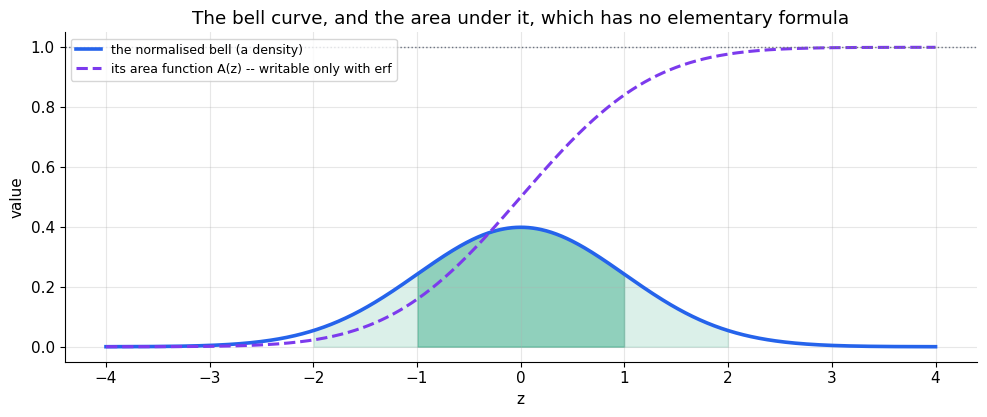

In [61]:
# ============================================================
#  The Gaussian: no elementary antiderivative. Ask, and see.
# ============================================================
from scipy import integrate as spi
from scipy.special import erf as scipy_erf

F_gauss = sp.integrate(sp.exp(-x ** 2), x)
print("sympy, asked for the antiderivative of exp(-x**2):")
print("     ", F_gauss)
print()
print("That is not a formula built from powers, exps and logs. 'erf' is a NAME")
print("for the accumulated area -- defined by the very integral we asked about.")
print()
print("It IS a genuine antiderivative, though. Differentiate it back:")
print("      d/dx [", F_gauss, "] =", sp.simplify(sp.diff(F_gauss, x)))
print()

# over the WHOLE line the answer is clean -- which is a separate surprise
print("Remarkably, over the whole real line the answer IS elementary:")
print("      sympy   : integral of exp(-x**2) from -oo to oo  =",
      sp.integrate(sp.exp(-x ** 2), (x, -sp.oo, sp.oo)))
val, abserr = spi.quad(lambda z: np.exp(-z ** 2), -np.inf, np.inf)
print(f"      numeric : {val:.12f}    (estimated error {abserr:.1e})")
print(f"      sqrt(pi): {np.sqrt(np.pi):.12f}")
print()

# ---- normalising a probability density -----------------------------------
print("=" * 68)
print("NORMALISING A DENSITY -- the everyday ML use of exactly this integral")
print("=" * 68)
raw  = lambda z: np.exp(-z ** 2 / 2)          # the bell SHAPE, un-normalised
Z, _ = spi.quad(raw, -np.inf, np.inf)         # the normalising constant
pdf  = lambda z: raw(z) / Z                   # divide by it -> a real density
total, _ = spi.quad(pdf, -np.inf, np.inf)

print(f"  area under the raw shape exp(-z**2/2)      Z = {Z:.10f}")
print(f"  claimed to be sqrt(2*pi)                     = {np.sqrt(2*np.pi):.10f}")
print(f"  area under exp(-z**2/2) / Z                  = {total:.12f}   <- a density")
print()
print(f"  P(-1 <= z <= 1) = {spi.quad(pdf, -1, 1)[0]:.6f}    (the famous 68%)")
print(f"  P(-2 <= z <= 2) = {spi.quad(pdf, -2, 2)[0]:.6f}    (the famous 95%)")
print(f"  the same 95%, via erf = {scipy_erf(2 / np.sqrt(2)):.6f}   -- named, not derived")

fig, ax = plt.subplots(figsize=(10, 4.3))
zz = np.linspace(-4, 4, 800)
ax.plot(zz, pdf(zz), color=C_F, lw=2.6, label="the normalised bell (a density)")
ax.fill_between(zz, 0, pdf(zz), where=(np.abs(zz) <= 2), color=C_AREA, alpha=0.14)
ax.fill_between(zz, 0, pdf(zz), where=(np.abs(zz) <= 1), color=C_AREA, alpha=0.35)
ax.plot(zz, scipy_erf(zz / np.sqrt(2)) / 2 + 0.5, color=C_EXACT, lw=2.2, ls="--",
        label="its area function A(z) -- writable only with erf")
ax.axhline(1.0, color=C_GREY, ls=":", lw=1.0)
ax.set_xlabel("z")
ax.set_ylabel("value")
ax.set_title("The bell curve, and the area under it, which has no elementary formula")
ax.legend(loc="upper left", fontsize=9)
fig.tight_layout()
plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The solid blue curve is the normalised bell, $e^{-z^2/2}/\sqrt{2\pi}$. The dark green band is the area within one standard deviation (about 68% of the total) and the pale band within two (about 95%) — the numbers printed above, computed by numerical integration rather than looked up in a table.

The dashed purple curve is that bell's **area function** — exactly the $A(x)$ of section 7.1, here called the cumulative distribution function. It starts at 0, climbs steeply where the bell is tall, flattens where the bell is short, and levels off at the dotted line at 1. It is the same picture as the very first figure of this part, drawn for the most important function in statistics.

And that dashed curve is precisely the one with no elementary formula. It can only be written using $\operatorname{erf}$ — which is a *name for this curve*, not a construction of it.

**The common misread:** seeing the clean value $\sqrt{\pi}$ for the integral over the *whole* line and concluding that an antiderivative must therefore exist. The **total** area is elementary — it falls out of a polar-coordinates trick that lives in Part 8's territory — while the **partial** area up to a finite $x$ is not. Knowing where a curve ends up tells you nothing about having a formula for how it got there.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**Assuming every function has an elementary antiderivative.** This is the single most common false expectation people carry out of an integration course, and it is the textbooks' fault: exercises are necessarily selected from the small set of integrands that work out. Real integrands mostly do not.

Ones you will actually meet that have **no** elementary antiderivative:

| Integrand | Where it turns up |
|---|---|
| $e^{-x^{2}}$ | every Gaussian, every normal distribution, GELU |
| $\dfrac{\sin x}{x}$ | signal processing, optics |
| $\dfrac{1}{\ln x}$ | prime counting |
| $\sqrt{1 + x^{4}}$ | arc length of very ordinary curves |
| $\dfrac{e^{x}}{x}$ | the exponential integral, radiative transfer |

**How not to lose an afternoon:** if a few minutes of substitution and parts gets nowhere, ask sympy. If `sp.integrate` hands back something containing `erf`, `Ei`, `Si`, `fresnel` or `elliptic`, that is sympy telling you politely that no elementary answer exists and it has named the answer instead. Switch to `scipy.integrate.quad` and move on — a number correct to fourteen digits is not a lesser answer, just a different kind of one.

</div>

<div style="background-color: #f8d7da; border-left: 5px solid #dc3545; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🤖 Why ML cares

**The Gaussian is everywhere in machine learning, and it is exactly the function with no elementary antiderivative.** Three practical consequences follow from that one fact.

**1. Nobody computes the normal CDF — they call it.** $\Phi(x)$, the probability that a standard normal lands below $x$, is an area function $A(x)$ with no closed form. `scipy.stats.norm.cdf`, `torch.erf`, and the **GELU** activation inside every transformer are all the same numerical `erf` underneath. GELU is literally $x\,\Phi(x)$: a bell curve's *area function*, evaluated a few billion times per forward pass, because there is no formula to evaluate instead. The most-used activation of the last decade is a definite integral you cannot do by hand.

**2. Normalising a density is an integral, and it is usually the hard part.** A probability density must integrate to 1. Given any non-negative shape $\tilde p(z)$, the density is $p(z) = \tilde p(z) / Z$ where $Z = \int \tilde p(z)\,dz$ — the **partition function**, computed above for the bell as $Z = \sqrt{2\pi}$. For the Gaussian we are lucky and know $Z$ exactly. For essentially every interesting model — energy-based models, Boltzmann machines, undirected graphical models — $Z$ is an integral over a high-dimensional space with no closed form and no feasible numerical evaluation either. Enormous parts of modern ML (variational inference, MCMC, score matching, contrastive divergence, diffusion models) exist to work *around* an integral that FTC Part 2 cannot help with.

**3. So why does ML lean so hard on derivatives rather than integrals?** Because of the asymmetry you saw in section 7.6, and again here. Differentiation is mechanical: the chain rule always applies, it never fails to terminate, and autograd automates it completely. Integration is a search that often has no answer to find. Training a network needs only derivatives — which is why backpropagation is a solved engineering problem while computing exact likelihoods is still a research area.

</div>

---

### 7.9 Where you have got to

You came into this part with two unrelated skills. You are leaving with one
subject.

| | |
|---|---|
| **The area function** | $A(x) = \int_a^x f(t)\,dt$ — the running total. Built numerically before a word was said about it. |
| **FTC Part 1** | $\frac{d}{dx}\int_a^x f(t)\,dt = f(x)$. Discovered by differentiating $A$ numerically; explained by one sliver: $A(x+h)-A(x) \approx f(x)\,h$. |
| **FTC Part 2** | $\int_a^b f = F(b) - F(a)$ whenever $F' = f$. Derived from Part 1. Turned 256 rectangles into $\pi$, exactly. |
| **Antiderivatives and $+C$** | An infinite vertical family, one derivative. $C$ cancels in a definite integral, and matters everywhere else. |
| **The loop, closed** | Differentiated the journey's position back into its speed; integrated its speed back into its position. Both errors printed and explained. |
| **Technique** | The power rule reversed; substitution *derived* as the chain rule read backwards. |
| **The honest limit** | Most integrands have no elementary antiderivative. $e^{-x^2}$ is the one you will meet most, and it is why `erf` and `quad` exist. |

If you keep one sentence from this part, keep the sliver:
**$A(x+h) - A(x)$ is a thin rectangle of height $f(x)$, so dividing by $h$
leaves $f(x)$.** Everything else in the Fundamental Theorem is bookkeeping
arranged around that one picture.

And it is worth pausing on what just happened. Two questions that looked
unrelated — steepness at a point, accumulation over an interval — turned out to
be the same question asked in opposite directions. Twenty centuries of
mathematicians missed it. Part 0 called it one of the best things anybody has
ever noticed, and now you have noticed it yourself, numerically, before anyone
told you the answer.

---

### ➡️ On to Part 8: many variables

Everything so far has had **one input**. One $x$, one direction to move in, one
slope, one number for an answer.

A neural network's loss has millions of inputs — one per weight — and *"which
way is downhill?"* is no longer a single number but a **direction in a
million-dimensional space**. Part 8 builds that: hold every variable still but
one and differentiate, which gives a **partial derivative**; stack all of them
into a vector and you have the **gradient**, the object that gradient descent
descends.

The good news is that there is no new calculus in it. A partial derivative is
Part 3's derivative with the other variables frozen — same limit, same
difference quotient, same rules from Part 4. What is genuinely new is the
*geometry*: on a surface rather than a curve, "downhill" needs a direction as
well as a steepness.

---


---

# 8️⃣ Many variables: partial derivatives and the gradient

<div style="background: linear-gradient(135deg, #0F2027 0%, #2C5364 100%); padding: 28px; border-radius: 18px; color: white; margin: 12px 0;">


### One dial was easy. Now there are a million.

Everything so far has been a machine with **one dial**: put in $x$, get out $f(x)$, and the derivative answers *if I turn the dial a bit, how much does the output move?*

A neural network is a machine with **one output and a million dials**. The output is the **loss** — a single number saying how wrong the model currently is. The dials are the **weights**. Training means turning the dials to make that one number go down.

So the question changes shape. It is no longer *how much does the output move?* It is:

> **How much does the loss move when I turn dial number 47 — and how much for each of the other 999,999?**

That is a million derivatives, one per dial. Stack them into a vector and you have the **gradient**. This part builds it from nothing, and shows the two facts about it that make training possible at all.


</div>

We will do all of it on **two** variables rather than a million, because two you
can draw. Nothing about the idea changes when you go to a million — only the
length of the vector.

**What you will have by the end:** partial derivatives, the gradient, the
directional derivative, the multivariable chain rule (which *is* backpropagation),
the Jacobian and Hessian, and a working gradient checker.


### A function of two variables

Here is our example for this part:

$$f(x,\,y) \;=\; x^2 \;+\; 3y^2 \;+\; xy \;-\; 2x \;+\; 4$$

Two numbers in, one number out. It is **bowl-shaped** — deliberately, because
that is the shape a loss surface has near a minimum, which is where Part 9 will
spend all of its time. The $xy$ term tilts the bowl, which will matter shortly.

A one-input function is drawn as a **curve**. A two-input function has to be
drawn as a **surface** sitting over the flat $(x, y)$ plane: the height above
each point of the floor is the value of $f$ there.

There are three standard ways to draw that surface, and they are not equally
useful. Here are all three of the *same* function.


f(0, 0)    =  4.0000
f(2, 1.5)  = 13.7500
f(1, -1)   =  5.0000

Two numbers in, one out. The graph is no longer a curve -- it is a
SURFACE, and its height above the floor is the value of f there.


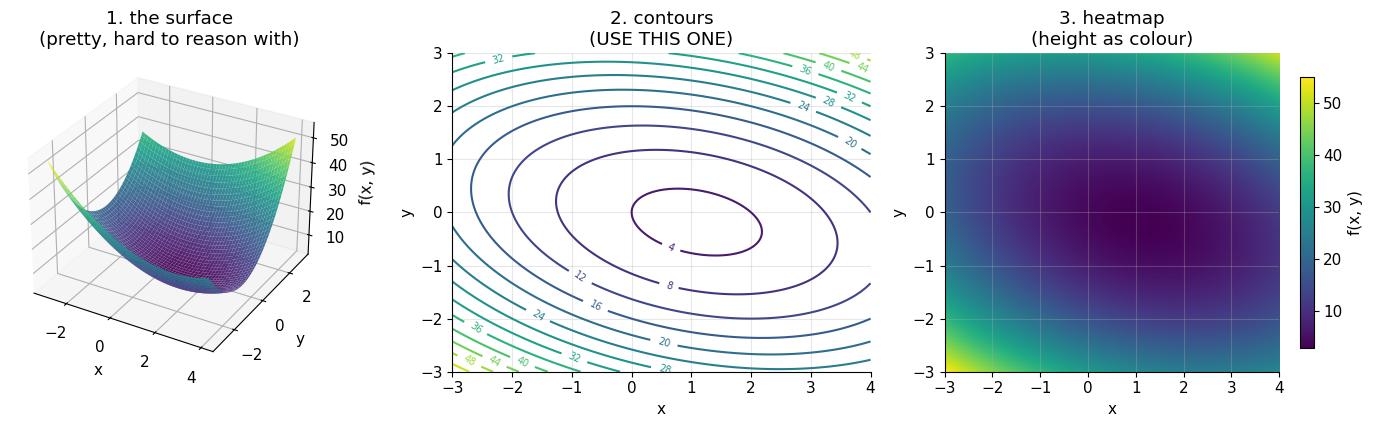


lowest  value on this grid : 2.9098
highest value on this grid : 55.0000


In [62]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  -- registers the 3-D projection

# ============================================================
#  f(x, y) = x^2 + 3y^2 + xy - 2x + 4      -- a tilted bowl
# ============================================================
def f(x, y):
    """Our two-input function. Two numbers in, one number out."""
    return x**2 + 3*y**2 + x*y - 2*x + 4

print(f"f(0, 0)    = {f(0.0,  0.0):7.4f}")
print(f"f(2, 1.5)  = {f(2.0,  1.5):7.4f}")
print(f"f(1, -1)   = {f(1.0, -1.0):7.4f}")
print()
print("Two numbers in, one out. The graph is no longer a curve -- it is a")
print("SURFACE, and its height above the floor is the value of f there.")

gx = np.linspace(-3, 4, 200)
gy = np.linspace(-3, 3, 200)
GX, GY = np.meshgrid(gx, gy)
GZ = f(GX, GY)

fig = plt.figure(figsize=(14.5, 4.4))

ax1 = fig.add_subplot(1, 3, 1, projection="3d")
ax1.plot_surface(GX, GY, GZ, cmap="viridis", linewidth=0, antialiased=True, alpha=0.92)
ax1.set_xlabel("x"); ax1.set_ylabel("y"); ax1.set_zlabel("f(x, y)")
ax1.set_title("1. the surface\n(pretty, hard to reason with)")

ax2 = fig.add_subplot(1, 3, 2)
cs = ax2.contour(GX, GY, GZ, levels=16, cmap="viridis")
ax2.clabel(cs, inline=True, fontsize=7, fmt="%.0f")
ax2.set_xlabel("x"); ax2.set_ylabel("y")
ax2.set_title("2. contours\n(USE THIS ONE)")

ax3 = fig.add_subplot(1, 3, 3)
im = ax3.imshow(GZ, origin="lower", extent=[gx[0], gx[-1], gy[0], gy[-1]],
                aspect="auto", cmap="viridis")
fig.colorbar(im, ax=ax3, shrink=0.85, label="f(x, y)")
ax3.set_xlabel("x"); ax3.set_ylabel("y")
ax3.set_title("3. heatmap\n(height as colour)")

fig.tight_layout()
plt.show()

print()
print(f"lowest  value on this grid : {GZ.min():.4f}")
print(f"highest value on this grid : {GZ.max():.4f}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The same function, drawn three ways.

**Left, the surface.** A landscape. It looks like understanding, and it is the picture everyone reaches for, but you cannot read a number off it and you cannot tell whether two points are at the same height.

**Middle, the contours.** Exactly like a walking map: each closed loop joins points where $f$ has the *same* value, and the labels give that value. Where the loops are **close together** the ground is **steep**; where they are far apart it is nearly flat. Notice the loops are ellipses tilted off the axes — that is the $xy$ term.

**Right, the heatmap.** The same information as the contours, but height is colour instead of a loop, so you lose the sense of *steepness* that the spacing of contour lines gives you for free.

**Use the contour map for reasoning.** Every important fact in this part — that the gradient is perpendicular to contours, that steepness is spacing, that gradient descent walks downhill across the loops — is visible on the middle panel and invisible on the other two.

**The common misread:** looking at the left panel and thinking the bowl's lowest point sits in the middle of the picture. It does not — the $-2x$ term shifts it, and only the contour map lets you see *where*, by finding the smallest loop.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**Reasoning from the 3-D surface plot.** It is the most seductive picture in multivariable calculus and the least reliable one.

Three ways it lies to you: the projection hides whatever is behind the near ridge; your sense of "steep" depends entirely on the viewing angle and the vertical scale, both of which are arbitrary; and you cannot judge whether two points are at the same height, which is the *one* thing a contour map makes trivial.

Professionals plot the surface for the talk and reason from the contours. In Part 9 you will watch gradient descent as a path drawn across a contour map, and it will be obvious what it is doing. Drawn on a 3-D surface, the same path is a squiggle you cannot interpret.

</div>

### Partial derivatives: freeze everything else

Here is the whole idea, and it really is this small.

> **To differentiate with respect to $x$, pretend every other variable is a
> constant, and differentiate normally.**

That is it. There is no new rule, no new limit, no new technique. Everything you
derived in Part 4 — power, product, quotient, chain — applies unchanged. The only
new instruction is *treat $y$ as if it were the number 7*.

Geometrically it means something you can literally see. Freezing $y$ at some
value $y_0$ means **slicing the surface with a vertical plane**. What you get on
that slice is an ordinary one-input curve, and the partial derivative is just the
slope of that curve — the same slope you built from scratch in Part 3:

$$\frac{\partial f}{\partial x}(x_0,\,y_0)
  \;=\; \lim_{h \to 0} \frac{f(x_0 + h,\; y_0) - f(x_0,\; y_0)}{h}$$

Look at what is and is not moving in that quotient: $x_0$ gets the $+h$; $y_0$
appears twice, identically, and never changes. Compare it with the Part 3
definition and you will find the only difference is a passenger riding along.

Doing it to our function by hand, twice:

$$\frac{\partial f}{\partial x} = 2x + y - 2
\qquad\qquad
\frac{\partial f}{\partial y} = 6y + x$$

For the first: $x^2 \to 2x$; $3y^2$ is a constant so it dies; $xy$ is
(a constant) $\times\, x$ so it gives $y$; $-2x \to -2$; $4$ dies. For the second:
$x^2$ dies, $3y^2 \to 6y$, $xy$ gives $x$, $-2x$ dies, $4$ dies.

**Notation.** The curly $\partial$ is said **"partial dee"**, so
$\partial f / \partial x$ is read *"partial dee f by partial dee x"*. It is not
a different operation from $d$ — it is a **warning label**. A straight
$\frac{df}{dx}$ promises that $f$ has one input and this is the whole story of
how it changes. A curly $\frac{\partial f}{\partial x}$ warns you that $f$ has
other inputs too, and that this number is **one direction out of many**.

Now let us not take any of that on faith.


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

$\dfrac{\partial f}{\partial x}$ asks:

> *I am standing at a point. I nudge **only** $x$, leaving $y$ exactly where it is. How fast does the output change?*

It is a rate of change per unit of $x$, measured **along one axis only**. The two partials of a two-input function answer two different questions about the same point: *what happens if I step east?* and *what happens if I step north?*

And the limit is the Part 3 limit, unchanged. The numerator $f(x_0+h,\,y_0) - f(x_0,\,y_0)$ is still a rise, the denominator $h$ is still a run, and the limit still shrinks the run to nothing. The only new thing is a second slot in the brackets that we agree not to touch.

</div>

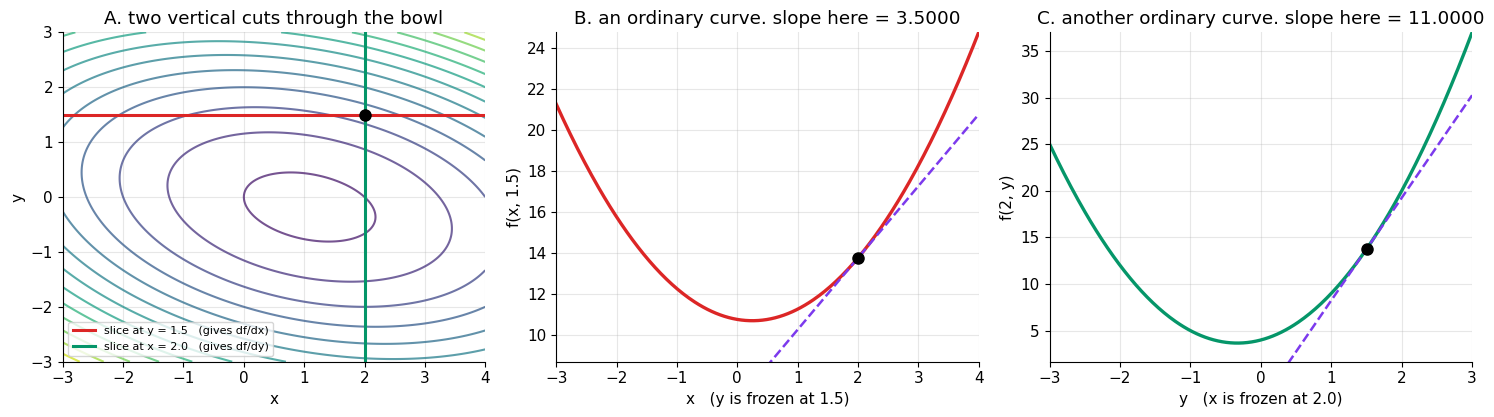

BY HAND       df/dx = 2x + y - 2   ->   3.5
              df/dy = 6y + x       ->   11.0

SYMPY         df/dx = 2*x + y - 2    ->   3.5000000000
              df/dy = x + 6*y        ->   11.0000000000

FROM A SLICE  df/dx = slope of panel B  ->   3.5000000002
              df/dy = slope of panel C  ->   11.0000000001

disagreement, df/dx : 2.228e-10
disagreement, df/dy : 1.165e-10


In [63]:
# ============================================================
#  Slice the surface, then use PART 3's definition on the slice.
# ============================================================
x0, y0 = 2.0, 1.5          # the point we will stand at

def slice_at_fixed_y(xx):   # y frozen -> an ordinary 1-input function of x
    return f(xx, y0)

def slice_at_fixed_x(yy):   # x frozen -> an ordinary 1-input function of y
    return f(x0, yy)

def slope_of(g, a, step=1e-5):
    """Part 3's derivative, symmetric version: rise over run as the run -> 0."""
    return (g(a + step) - g(a - step)) / (2 * step)

xs = np.linspace(-3, 4, 300)
ys = np.linspace(-3, 3, 300)

fig, (axA, axB, axC) = plt.subplots(1, 3, figsize=(15, 4.3))

# --- A: where the two slices sit on the contour map
axA.contour(GX, GY, GZ, levels=16, cmap="viridis", alpha=0.75)
axA.axhline(y0, color=C_SLOPE, lw=2.2, label="slice at y = 1.5   (gives df/dx)")
axA.axvline(x0, color=C_AREA,  lw=2.2, label="slice at x = 2.0   (gives df/dy)")
axA.plot(x0, y0, "o", color="black", ms=8, zorder=5)
axA.set_xlabel("x"); axA.set_ylabel("y"); axA.legend(fontsize=8, loc="lower left")
axA.set_title("A. two vertical cuts through the bowl")

# --- B: the y-frozen slice, and its tangent
sx_vals = slice_at_fixed_y(xs)
mB = slope_of(slice_at_fixed_y, x0)
axB.plot(xs, sx_vals, color=C_SLOPE, lw=2.4)
axB.plot(xs, slice_at_fixed_y(x0) + mB * (xs - x0), "--", color=C_EXACT, lw=1.8)
axB.plot(x0, slice_at_fixed_y(x0), "o", color="black", ms=8, zorder=5)
axB.set_xlim(-3, 4); axB.set_ylim(sx_vals.min() - 2, sx_vals.max())
axB.set_xlabel("x   (y is frozen at 1.5)"); axB.set_ylabel("f(x, 1.5)")
axB.set_title(f"B. an ordinary curve. slope here = {mB:.4f}")

# --- C: the x-frozen slice, and its tangent
sy_vals = slice_at_fixed_x(ys)
mC = slope_of(slice_at_fixed_x, y0)
axC.plot(ys, sy_vals, color=C_AREA, lw=2.4)
axC.plot(ys, slice_at_fixed_x(y0) + mC * (ys - y0), "--", color=C_EXACT, lw=1.8)
axC.plot(y0, slice_at_fixed_x(y0), "o", color="black", ms=8, zorder=5)
axC.set_xlim(-3, 3); axC.set_ylim(sy_vals.min() - 2, sy_vals.max())
axC.set_xlabel("y   (x is frozen at 2.0)"); axC.set_ylabel("f(2, y)")
axC.set_title(f"C. another ordinary curve. slope here = {mC:.4f}")

fig.tight_layout()
plt.show()

# ---- three independent routes to the same two numbers ------------------
sx, sy_, su, sv, st = sp.symbols("x y u v t", real=True)
f_sym  = sx**2 + 3*sy_**2 + sx*sy_ - 2*sx + 4
fx_sym = sp.diff(f_sym, sx)
fy_sym = sp.diff(f_sym, sy_)
sub    = {sx: x0, sy_: y0}

print("BY HAND       df/dx = 2x + y - 2   ->  ", 2*x0 + y0 - 2)
print("              df/dy = 6y + x       ->  ", 6*y0 + x0)
print()
print(f"SYMPY         df/dx = {fx_sym}    ->   {float(fx_sym.subs(sub)):.10f}")
print(f"              df/dy = {fy_sym}        ->   {float(fy_sym.subs(sub)):.10f}")
print()
print(f"FROM A SLICE  df/dx = slope of panel B  ->   {mB:.10f}")
print(f"              df/dy = slope of panel C  ->   {mC:.10f}")
print()
print(f"disagreement, df/dx : {abs(mB - float(fx_sym.subs(sub))):.3e}")
print(f"disagreement, df/dy : {abs(mC - float(fy_sym.subs(sub))):.3e}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

**Panel A** is the contour map with the two cuts drawn on it. The red horizontal line is every point where $y = 1.5$; the green vertical line is every point where $x = 2.0$. They cross at the black dot, the point we are standing at.

**Panel B** is what you see if you walk along the red line and record the height: an ordinary parabola in one variable. Nothing multivariable is left — it is a Part 1 curve. The dashed line is its tangent at the dot, whose slope was computed with the Part 3 difference quotient and nothing else. That slope **is** $\partial f/\partial x$.

**Panel C** is the same story along the green line, giving $\partial f/\partial y$. It is visibly steeper, because the $3y^2$ term makes the bowl rise faster in the $y$ direction than the $x^2$ term does in $x$.

**The common misread:** thinking panels B and C between them describe the whole surface. They describe exactly two directions out of the infinitely many you could walk from that dot. What happens if you walk **diagonally** is a question neither panel answers — and it is the question the gradient was invented for.

</div>

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

Three independent routes to the same two numbers, and they agree.

| route | $\partial f/\partial x$ at $(2,\,1.5)$ | $\partial f/\partial y$ |
|---|---|---|
| by hand, treating the other variable as a constant | $2(2)+1.5-2 = 3.5$ | $6(1.5)+2 = 11$ |
| sympy, differentiating symbolically | $3.5$ | $11$ |
| the slope of a **1-D slice**, via Part 3's difference quotient | $3.5$ | $11$ |

The slice route used no multivariable machinery at all — it froze one variable, produced a plain curve, and measured its slope the way we have been measuring slopes since Part 3. That is the evidence for the claim in the heading: **a partial derivative is not a new kind of derivative.** It is the old kind, taken along a slice.

The printed disagreements are around $10^{-11}$ — floating-point noise in the difference quotient, not error in the idea.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**Thinking $\partial f/\partial x$ means the other variables went away.** They did not. They were held *fixed*, which is a completely different thing, and they can absolutely still appear in the answer.

Look at ours: $\dfrac{\partial f}{\partial x} = 2x + y - 2$. There is a $y$ sitting in it. That is not a mistake — it is the whole point. It says **how steeply the surface rises in the $x$ direction depends on where you are standing in $y$.** On our tilted bowl, walking east from high ground in $y$ is a different climb from walking east from low ground.

What *does* vanish is any term with no $x$ in it, because a constant has zero slope: the $3y^2$ and the $4$ disappeared from $\partial f/\partial x$. Terms that **mix** $x$ and $y$ survive, carrying the other variable with them.

This is not a technicality. In a neural network, every weight's partial derivative depends on the values of all the other weights — which is exactly why the whole gradient has to be recomputed after every single step.

</div>

### The gradient: all the partials, in one vector

We have two numbers describing the point $(2,\,1.5)$: how steeply the surface
rises if you step east, and how steeply if you step north. Stop treating them as
two separate facts and staple them into a vector:

$$\nabla f(x,\,y) \;=\;
\begin{bmatrix} \dfrac{\partial f}{\partial x} \\[8pt] \dfrac{\partial f}{\partial y} \end{bmatrix}
\;=\;
\begin{bmatrix} 2x + y - 2 \\[4pt] 6y + x \end{bmatrix}$$

The symbol $\nabla$ is an upside-down capital delta, said **"grad"** or "del",
and $\nabla f$ is read "**grad f**". For a function of a million variables it is
a vector with a million entries — one per dial. Nothing else changes.

So far this is bookkeeping: we put two numbers in a box. What makes the gradient
one of the most important objects in mathematics is that the box turns out to
answer a question we never asked it. We only computed the slope **east** and the
slope **north**. But:

> **Fact 1.** $\nabla f$ points in the direction of **steepest ascent** — the
> single compass bearing, out of all $360°$ of them, along which the surface
> climbs fastest.
>
> **Fact 2.** Its **length** $\lVert \nabla f \rVert$ is *how* steep that
> steepest climb is.

Two slopes along the axes somehow encode the best direction among infinitely
many. That deserves to be doubted, so we are going to measure it rather than
assert it.

**To measure it we need one more definition.** Pick a direction — a unit vector
$\mathbf{u}$, meaning an arrow of length exactly 1 pointing wherever you like.
The **directional derivative** is the slope you feel walking that way:

$$D_{\mathbf{u}} f(\mathbf{p}) \;=\; \lim_{h\to 0} \frac{f(\mathbf{p} + h\mathbf{u}) - f(\mathbf{p})}{h}$$

The same difference quotient as always; the only change is that the step
$h\mathbf{u}$ is now a step in the *plane* rather than along a line. And the
partials are just two special cases of it: $\mathbf{u} = (1, 0)$ gives
$\partial f/\partial x$, and $\mathbf{u} = (0, 1)$ gives $\partial f/\partial y$.

The claim that ties everything together is a **dot product**:

$$D_{\mathbf{u}} f \;=\; \nabla f \cdot \mathbf{u}$$

Below we sweep $\mathbf{u}$ all the way around the circle, measure the slope in
every direction from the raw definition, and see where the maximum lands.


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

**The gradient** is a list, and it is also an arrow.

As a **list**: one number per input, each saying how much the output moves when you nudge that one input. In ML, one number per weight.

As an **arrow** drawn on the floor at the point you are standing: it points **straight uphill**, the steepest way up, and its **length** is how brutal that climb is. Long arrow, cliff. Short arrow, gentle slope. Zero-length arrow, flat ground — you are at a peak, a valley floor, or a saddle, which is Part 5's story one dimension up.

**The directional derivative** $D_{\mathbf{u}}f$ is the slope you feel walking in a direction $\mathbf{u}$ of your choosing. The formula $D_{\mathbf{u}}f = \nabla f \cdot \mathbf{u}$ says something you already know from walking up a hill: the slope you feel is the full steepness scaled by **how much of your chosen direction points uphill**. Walk straight up and you feel all of it. Walk at an angle and you feel a fraction. Walk along the hillside and you feel none of it.

</div>

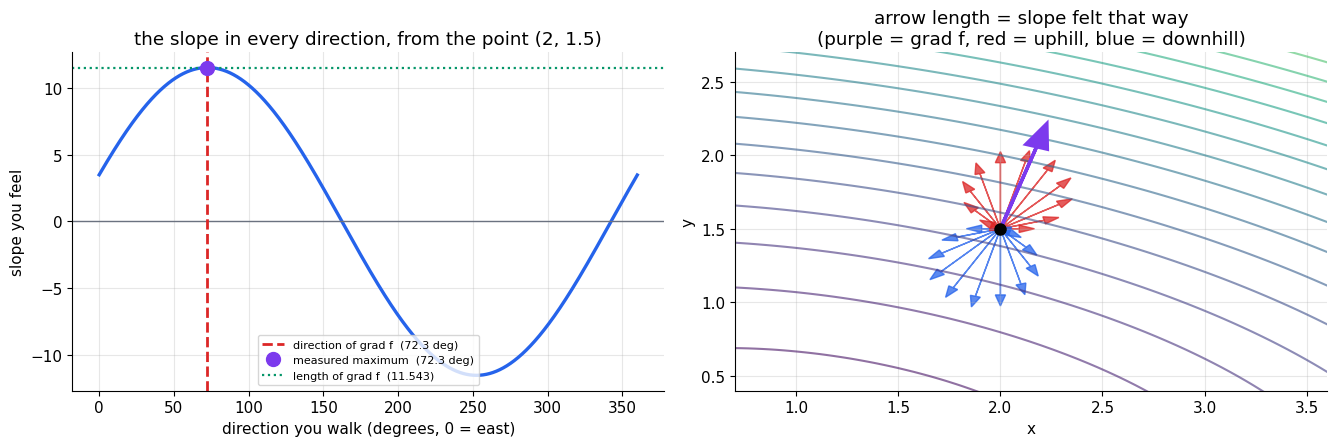

gradient at (2, 1.5), measured numerically  : [3.500000, 11.000000]
its length                                  :  11.543396

angle of the gradient                       :   72.3499 deg
angle where the MEASURED slope is biggest   :   72.3000 deg
                               disagreement :    0.0499 deg   (the angular grid step is 0.10 deg)

biggest measured slope over all directions  : 11.54339201
length of the gradient                      : 11.54339638
                               disagreement : 4.374e-06

angle of STEEPEST DESCENT (measured)        :  252.3000 deg   -> 179.95 deg from the gradient
angle where the slope is ZERO (measured)    :  162.3000 deg   -> 89.95 deg from the gradient

     direction u           D_u f (measured)      grad f . u          gap
  [-0.652, -0.758]        -10.62231171     -10.62231171     5.66e-11
  [-0.124, +0.992]        +10.48108699     +10.48108699     2.01e-10
  [+0.967, +0.255]         +6.18536193      +6.18536193     3.27e-10
  [+0.995, +0.

In [64]:
# ============================================================
#  Is the gradient really the steepest direction? MEASURE it.
#  We evaluate the directional derivative in 3600 directions
#  around the circle -- from the raw definition, with no
#  gradient involved anywhere -- and see where the maximum falls.
# ============================================================
P = np.array([2.0, 1.5])          # where we stand

def grad_numeric(p, step=1e-5):
    """Central-difference gradient: nudge each coordinate on its own."""
    p   = np.asarray(p, dtype=float)
    out = np.zeros_like(p)
    for i in range(p.size):
        e = np.zeros_like(p); e[i] = step
        out[i] = (f(*(p + e)) - f(*(p - e))) / (2 * step)
    return out

def dir_deriv(p, u, step=1e-5):
    """Slope felt walking in direction u. Raw definition; no gradient used."""
    u = np.asarray(u, dtype=float)
    u = u / np.linalg.norm(u)                     # a DIRECTION has length 1
    return (f(*(p + step*u)) - f(*(p - step*u))) / (2 * step)

thetas = np.linspace(0, 2*np.pi, 3601)[:-1]       # 0.1 degree resolution
D_meas = np.array([dir_deriv(P, [np.cos(a), np.sin(a)]) for a in thetas])

g        = grad_numeric(P)
ang_grad = np.degrees(np.arctan2(g[1], g[0])) % 360.0
ang_max  = np.degrees(thetas[np.argmax(D_meas)]) % 360.0
ang_min  = np.degrees(thetas[np.argmin(D_meas)]) % 360.0
ang_flat = np.degrees(thetas[np.argmin(np.abs(D_meas))]) % 360.0

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13.5, 4.6))

axL.plot(np.degrees(thetas), D_meas, color=C_F, lw=2.4)
axL.axhline(0, color=C_GREY, lw=1)
axL.axvline(ang_grad, color=C_SLOPE, lw=2, ls="--",
            label=f"direction of grad f  ({ang_grad:.1f} deg)")
axL.plot(ang_max, D_meas.max(), "o", color=C_EXACT, ms=10, zorder=5,
         label=f"measured maximum  ({ang_max:.1f} deg)")
axL.axhline(np.linalg.norm(g), color=C_AREA, lw=1.6, ls=":",
            label=f"length of grad f  ({np.linalg.norm(g):.3f})")
axL.set_xlabel("direction you walk (degrees, 0 = east)")
axL.set_ylabel("slope you feel")
axL.set_title("the slope in every direction, from the point (2, 1.5)")
axL.legend(fontsize=8, loc="lower center")

axR.contour(GX, GY, GZ, levels=22, cmap="viridis", alpha=0.6)
for a in np.linspace(0, 2*np.pi, 25)[:-1]:
    u = np.array([np.cos(a), np.sin(a)])
    d = dir_deriv(P, u)
    col = C_SLOPE if d > 0 else C_F
    L = 0.55 * abs(d) / np.linalg.norm(g)
    axR.arrow(P[0], P[1], L*u[0], L*u[1], head_width=0.05, color=col,
              alpha=0.75, length_includes_head=True)
gh = g / np.linalg.norm(g)
axR.arrow(P[0], P[1], 0.75*gh[0], 0.75*gh[1], head_width=0.11, color=C_EXACT,
          lw=2.5, length_includes_head=True, zorder=6)
axR.plot(P[0], P[1], "o", color="black", ms=8, zorder=7)
axR.set_xlim(0.7, 3.6); axR.set_ylim(0.4, 2.7)
axR.set_xlabel("x"); axR.set_ylabel("y")
axR.set_title("arrow length = slope felt that way\n(purple = grad f, red = uphill, blue = downhill)")

fig.tight_layout()
plt.show()

print(f"gradient at (2, 1.5), measured numerically  : [{g[0]:.6f}, {g[1]:.6f}]")
print(f"its length                                  :  {np.linalg.norm(g):.6f}")
print()
print(f"angle of the gradient                       : {ang_grad:9.4f} deg")
print(f"angle where the MEASURED slope is biggest   : {ang_max:9.4f} deg")
print(f"                               disagreement : {abs(ang_max - ang_grad):9.4f} deg"
      f"   (the angular grid step is {360/3600:.2f} deg)")
print()
print(f"biggest measured slope over all directions  : {D_meas.max():.8f}")
print(f"length of the gradient                      : {np.linalg.norm(g):.8f}")
print(f"                               disagreement : {abs(D_meas.max() - np.linalg.norm(g)):.3e}")
print()
print(f"angle of STEEPEST DESCENT (measured)        : {ang_min:9.4f} deg"
      f"   -> {abs((ang_min - ang_grad) % 360):.2f} deg from the gradient")
print(f"angle where the slope is ZERO (measured)    : {ang_flat:9.4f} deg"
      f"   -> {abs((ang_flat - ang_grad) % 360):.2f} deg from the gradient")

# ---- and the dot-product formula, on directions picked at random -------
rng   = np.random.default_rng(0)
worst = 0.0
print()
print("     direction u           D_u f (measured)      grad f . u          gap")
for k in range(6):
    a = rng.uniform(0, 2*np.pi)
    u = np.array([np.cos(a), np.sin(a)])
    lhs, rhs = dir_deriv(P, u), float(g @ u)
    worst = max(worst, abs(lhs - rhs))
    print(f"  [{u[0]:+.3f}, {u[1]:+.3f}]       {lhs:+13.8f}    {rhs:+13.8f}     {abs(lhs-rhs):.2e}")
print()
print(f"worst gap between the raw definition and grad f . u : {worst:.3e}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

**Left.** The slope you feel, plotted against the compass bearing you walk. It is a smooth wave: one direction is the best climb, the exact opposite is the best descent, and in between there are two bearings where the slope is zero — walk those and your height does not change at all.

The red dashed line is the direction the gradient points, computed from nothing but the two axis slopes. The purple dot is where the measured maximum actually fell. They land on top of each other. The green dotted line is the gradient's **length**, and the wave peaks exactly at it — that is Fact 2, measured rather than claimed.

**Right.** The same data drawn on the contour map: an arrow in each of 24 directions, its length equal to the slope felt that way, red for uphill and blue for downhill. The fat purple arrow is the gradient. It is the longest red arrow, and the blue arrows crowd the opposite side — the downhill half of the compass.

**The common misread:** thinking the two zero-slope directions mean the surface is flat there. It is not flat; you are walking **along** a contour, around the bowl at constant height, like a path traversing a hillside. Your height is unchanged, but the hill is as steep as ever — you are simply not going up it.

</div>

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

Nothing here was asserted. The directional derivative was computed 3600 times straight from its definition — nudge the point, see how $f$ changes — with the gradient playing no part in any of those 3600 numbers. Then we asked where the maximum fell.

**Fact 1, measured.** The steepest direction found by brute search agrees with the gradient's direction to within the resolution of the angular grid ($0.1°$). Steepest *descent* comes out $180°$ away, and the two zero-slope directions come out $90°$ away — every one of those numbers is a prediction of the theory that we did not build into the search.

**Fact 2, measured.** The largest slope found over all 3600 directions equals $\lVert \nabla f \rVert$ to about $10^{-6}$ — and that residue is the angular grid, not the calculus: the best of 3600 sampled bearings misses the true peak by up to $0.05°$, and a smooth peak is flat, so the value barely suffers.

**The dot product, measured.** On randomly chosen directions, the raw difference quotient and $\nabla f \cdot \mathbf{u}$ agree to around $10^{-10}$. So a two-entry vector really does contain the answer for *every* direction, not just the two we computed.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**The gradient points UPHILL.** Not downhill. Uphill.

This trips up nearly everyone, because the first thing anybody does with a gradient is minimise something, and minimising means going **down**. So the update rule carries a minus sign:

$$w \;\leftarrow\; w \;-\; \eta \, \nabla L$$

That minus is not decoration and it is not a convention you may drop. It is there precisely because $\nabla L$ points the wrong way for the job. Lose it and you have written **gradient ascent**: your loss climbs, your model gets steadily worse, and the symptom is a loss curve rising smoothly and confidently towards infinity. If you ever see that, check the sign before you check anything else.

The name is honest, at least — *ascent* is in the definition. It is our use of it that runs backwards.

</div>

### The picture that makes Part 9 obvious

One figure: a contour map, with the gradient arrow drawn at a grid of points.

Two things to watch for, both consequences of what we just measured. Every arrow
is **perpendicular to the contour line it sits on** — because along a contour the
height does not change, so the slope in that direction is zero, so the gradient
(the direction of *maximum* slope) must be at right angles to it. And every arrow
points **towards higher ground**, growing longer where the contour lines bunch
up.

Reverse every arrow and you are looking at gradient descent.


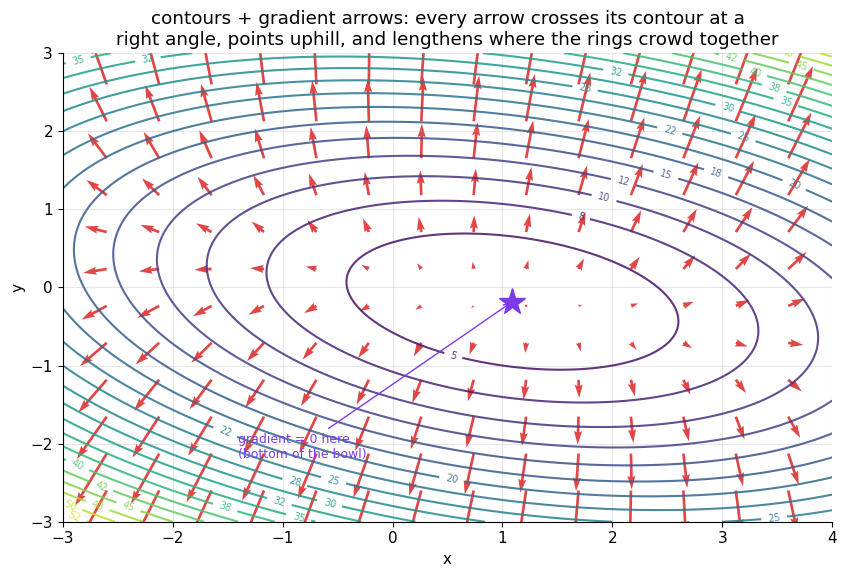

bottom of the bowl, found by solving grad f = 0 : (1.090909, -0.181818)
by hand, solving 2x + y - 2 = 0 and 6y + x = 0  : (1.090909, -0.181818)
gradient there : [0.00e+00, 0.00e+00]   (the zero vector, to numerical precision)

Stepping 0.02 ALONG the gradient, versus 0.02 ACROSS it:
     point        change in f, along      change in f, across       ratio
  (+2.0, +1.5)       +0.23210995            +0.00035797         648.4x
  (-1.0, +1.0)       +0.11743080            +0.00078824         149.0x
  (+3.0, -2.0)       +0.18546854            +0.00052235         355.1x
  (+0.0, +2.0)       +0.24120000            +0.00040000         603.0x

Along the gradient, f changes by about eps * ||grad f||.
Across it, the change is hundreds of times smaller and is pure curvature
(order eps^2). To first order, walking across the gradient does not change
your height at all -- which is exactly what 'the contour runs that way' means.


In [65]:
# ============================================================
#  The gradient field: an arrow at every point, pointing uphill.
# ============================================================
qx = np.linspace(-2.6, 3.6, 14)
qy = np.linspace(-2.6, 2.6, 12)
QX, QY = np.meshgrid(qx, qy)
U = np.zeros_like(QX)
V = np.zeros_like(QY)
for i in range(QX.shape[0]):
    for j in range(QX.shape[1]):
        U[i, j], V[i, j] = grad_numeric([QX[i, j], QY[i, j]])

fig, ax = plt.subplots(figsize=(8.6, 5.9))
csF = ax.contour(GX, GY, GZ, levels=20, cmap="viridis", alpha=0.85)
ax.clabel(csF, inline=True, fontsize=7, fmt="%.0f")
ax.quiver(QX, QY, U, V, color=C_SLOPE, alpha=0.85, width=0.0035)

# the bottom of the bowl: the point where the gradient is the zero vector
from scipy.optimize import fsolve
bottom = fsolve(lambda p: grad_numeric(p), [0.0, 0.0])
ax.plot(bottom[0], bottom[1], "*", color=C_EXACT, ms=20, zorder=6)
ax.annotate("gradient = 0 here\n(bottom of the bowl)", xy=bottom,
            xytext=(bottom[0] - 2.5, bottom[1] - 2.0), fontsize=9, color=C_EXACT,
            arrowprops=dict(arrowstyle="->", color=C_EXACT))
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("contours + gradient arrows: every arrow crosses its contour at a\n"
             "right angle, points uphill, and lengthens where the rings crowd together")
fig.tight_layout()
plt.show()

print(f"bottom of the bowl, found by solving grad f = 0 : "
      f"({bottom[0]:.6f}, {bottom[1]:.6f})")
print(f"by hand, solving 2x + y - 2 = 0 and 6y + x = 0  : "
      f"({12/11:.6f}, {-2/11:.6f})")
print(f"gradient there : [{grad_numeric(bottom)[0]:.2e}, {grad_numeric(bottom)[1]:.2e}]"
      f"   (the zero vector, to numerical precision)")
print()

# --- perpendicularity, as a number rather than an impression -----------
print("Stepping 0.02 ALONG the gradient, versus 0.02 ACROSS it:")
print("     point        change in f, along      change in f, across       ratio")
for p in ([2.0, 1.5], [-1.0, 1.0], [3.0, -2.0], [0.0, 2.0]):
    p    = np.array(p, dtype=float)
    gp   = grad_numeric(p)
    uhat = gp / np.linalg.norm(gp)
    perp = np.array([-uhat[1], uhat[0]])          # rotate 90 degrees
    eps  = 0.02
    d_along  = f(*(p + eps*uhat)) - f(*p)
    d_across = f(*(p + eps*perp)) - f(*p)
    print(f"  ({p[0]:+.1f}, {p[1]:+.1f})       {d_along:+.8f}            "
          f"{d_across:+.8f}      {abs(d_along/d_across):8.1f}x")
print()
print("Along the gradient, f changes by about eps * ||grad f||.")
print("Across it, the change is hundreds of times smaller and is pure curvature")
print("(order eps^2). To first order, walking across the gradient does not change")
print("your height at all -- which is exactly what 'the contour runs that way' means.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The contour map with $\nabla f$ drawn at each grid point. This is the single most useful picture in this notebook.

**The arrows cross the contour lines at right angles.** Not approximately — and the printed numbers make it quantitative: step $0.02$ along the gradient and the height changes; step $0.02$ across it and the change is hundreds of times smaller, and what remains is curvature, not slope.

**The arrows point outward, uphill, away from the star.** At the star itself the gradient is the zero vector: no direction is uphill, because you are at the bottom. Solving $\nabla f = \mathbf{0}$ is the multivariable version of Part 5's *set the derivative to zero and solve*, and it lands on $(12/11,\; -2/11)$ from both routes.

**The arrows grow as you move outward**, where the contour rings bunch together — steeper ground, longer arrow.

Now mentally reverse every arrow. Drop a ball anywhere on this map, let it follow the reversed arrows in small steps, and it walks to the star. **That is gradient descent**, and Part 9 does exactly this on a loss.

**The common misread:** thinking the arrows are the *path* something takes. They are not a path; each is an independent local instruction, valid only at the point where it is drawn. Gradient descent follows one arrow for a short step, then throws it away and asks for a fresh one — which is why the gradient must be recomputed after every update.

</div>

### The multivariable chain rule — this one *is* backpropagation

Part 4 gave us the chain rule for one variable: if $z$ depends on $u$ and $u$
depends on $t$, then $\dfrac{dz}{dt} = \dfrac{dz}{du}\dfrac{du}{dt}$. Effects
multiply along a chain.

Now let $z$ depend on **two** things at once, both of which depend on $t$:

$$z = f(u,\, v), \qquad u = u(t), \qquad v = v(t)$$

Nudge $t$ by a tiny $\Delta t$. Two things happen, not one:

- $u$ moves by about $\Delta u \approx u'(t)\,\Delta t$
- $v$ moves by about $\Delta v \approx v'(t)\,\Delta t$

and $z$ feels **both** nudges. For a small enough step, the effect of moving two
inputs is simply the sum of the effects of moving each — that is what "smooth"
means: up close, the surface is a plane, and on a plane, effects add.

$$\Delta z \;\approx\; \frac{\partial f}{\partial u}\,\Delta u \;+\; \frac{\partial f}{\partial v}\,\Delta v$$

Substitute the two nudges, divide by $\Delta t$, and let $\Delta t \to 0$:

$$\boxed{\;\frac{dz}{dt} \;=\; \frac{\partial f}{\partial u}\frac{du}{dt} \;+\; \frac{\partial f}{\partial v}\frac{dv}{dt}\;}$$

**Multiply along each path, add across the paths.** That sentence is the entire
algorithm of backpropagation. A neural network is a graph in which an early
weight reaches the loss along many routes; the rule says compute each route by
multiplying the local derivatives along it, then add the routes up.

The notation is doing work here: **straight $d$** on the outside, because $z$
ultimately depends on the single variable $t$, and **curly $\partial$** inside,
because $f$ itself has two inputs.


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

You are turning one knob, $t$. That knob moves two levers, $u$ and $v$. Both levers move the output.

So the total effect of the knob is: (how hard the knob pushes lever $u$) $\times$ (how much lever $u$ moves the output), **plus** (how hard the knob pushes lever $v$) $\times$ (how much lever $v$ moves the output).

**Multiply along a path, add across paths.** If there were fifty levers there would be fifty terms. If the levers pushed other levers before reaching the output, each path would simply be a longer product. That is all a deep network is: a very large number of very simple paths, each one a product, all added up.

</div>

In [66]:
# ============================================================
#  (a) the chain rule as stated, checked numerically and symbolically
# ============================================================
def u_of(tt): return np.cos(tt)
def v_of(tt): return tt**2 + 1
def F(u, v):  return u**2 * v + np.sin(v)
def z_of(tt): return F(u_of(tt), v_of(tt))

t0  = 0.7
eps = 1e-6

# LEFT SIDE: forget the structure entirely. Compose everything into one
# function of t and take an ordinary Part-3 derivative of it.
lhs = (z_of(t0 + eps) - z_of(t0 - eps)) / (2*eps)

# RIGHT SIDE: four small, separate derivatives, assembled by the rule.
u0, v0 = u_of(t0), v_of(t0)
dF_du = (F(u0 + eps, v0) - F(u0 - eps, v0)) / (2*eps)
dF_dv = (F(u0, v0 + eps) - F(u0, v0 - eps)) / (2*eps)
du_dt = (u_of(t0 + eps) - u_of(t0 - eps)) / (2*eps)
dv_dt = (v_of(t0 + eps) - v_of(t0 - eps)) / (2*eps)
rhs   = dF_du*du_dt + dF_dv*dv_dt

# SYMPY, for a third and independent opinion
z_sym = (sp.cos(st))**2 * (st**2 + 1) + sp.sin(st**2 + 1)
exact = float(sp.diff(z_sym, st).subs(st, t0))

print("z = f(u, v) = u^2 v + sin(v),    u = cos t,    v = t^2 + 1,    at t = 0.7")
print()
print(f"  df/du = {dF_du:+.8f}       du/dt = {du_dt:+.8f}")
print(f"  df/dv = {dF_dv:+.8f}       dv/dt = {dv_dt:+.8f}")
print()
print(f"  chain rule   (df/du)(du/dt) + (df/dv)(dv/dt)  = {rhs:+.8f}")
print(f"  brute force   d/dt of the composed function   = {lhs:+.8f}")
print(f"  sympy, exact                                  = {exact:+.8f}")
print(f"  worst disagreement                            = "
      f"{max(abs(rhs - exact), abs(lhs - exact)):.3e}")
print()
print(f"  Keeping ONE path only (dropping the v term) gives {dF_du*du_dt:+.8f},")
print(f"  which is wrong by {abs(dF_du*du_dt - exact):.4f}. You must add across ALL paths.")


z = f(u, v) = u^2 v + sin(v),    u = cos t,    v = t^2 + 1,    at t = 0.7

  df/du = +2.27922972       du/dt = -0.64421769
  df/dv = +0.66569202       dv/dt = +1.40000000

  chain rule   (df/du)(du/dt) + (df/dv)(dv/dt)  = -0.53635127
  brute force   d/dt of the composed function   = -0.53635127
  sympy, exact                                  = -0.53635127
  worst disagreement                            = 5.776e-11

  Keeping ONE path only (dropping the v term) gives -1.46832010,
  which is wrong by 0.9320. You must add across ALL paths.


In [67]:
# ============================================================
#  (b) the same rule on something shaped like a neural network:
#      one neuron, two inputs, a tanh, and a squared error.
#
#        z = w1*in1 + w2*in2 + b      (a linear layer)
#        a = tanh(z)                  (an activation)
#        L = (a - target)^2           (a loss)
#
#  This is a real, if tiny, forward pass. Training needs the
#  gradient of L with respect to (w1, w2, b), and the chain
#  rule is the only tool used to get it.
# ============================================================
in1, in2, target = 0.8, -0.5, 1.0

def forward(w1, w2, b):
    z = w1*in1 + w2*in2 + b
    a = np.tanh(z)
    return (a - target)**2

W = np.array([0.30, -0.70, 0.10])          # (w1, w2, b)

# ---- BY HAND: multiply the local derivatives along the chain -----------
z_val = W[0]*in1 + W[1]*in2 + W[2]
a_val = np.tanh(z_val)
dL_da = 2*(a_val - target)                 # loss    -> activation
da_dz = 1 - a_val**2                       # tanh'   = 1 - tanh^2
dz_dw1, dz_dw2, dz_db = in1, in2, 1.0      # linear layer -> its parameters
grad_hand = np.array([dL_da * da_dz * dz_dw1,
                      dL_da * da_dz * dz_dw2,
                      dL_da * da_dz * dz_db])

# ---- NUMERICALLY: knowing nothing at all about the structure -----------
def grad_by_nudging(fn, p, step=1e-6):
    p = np.asarray(p, dtype=float); out = np.zeros_like(p)
    for i in range(p.size):
        e = np.zeros_like(p); e[i] = step
        out[i] = (fn(*(p + e)) - fn(*(p - e))) / (2*step)
    return out

grad_nudged = grad_by_nudging(forward, W)

print(f"forward pass:   z = {z_val:+.6f}    a = tanh(z) = {a_val:+.6f}"
      f"    L = {forward(*W):.6f}")
print()
print("                      by the chain rule        by nudging weights          gap")
for nm, gh_, gn_ in zip(["dL/dw1", "dL/dw2", "dL/db "], grad_hand, grad_nudged):
    print(f"     {nm}          {gh_:+.10f}            {gn_:+.10f}     {abs(gh_-gn_):.2e}")
print()
rel = (np.linalg.norm(grad_hand - grad_nudged)
       / (np.linalg.norm(grad_hand) + np.linalg.norm(grad_nudged)))
print(f"relative error  ||hand - numeric|| / (||hand|| + ||numeric||) = {rel:.3e}")
print()
print("That is backpropagation. Three local derivatives, multiplied along the")
print("chain. Part 9 does exactly this on a network with a hidden layer, where")
print("the weights of the first layer reach the loss along several paths and")
print("the 'add across paths' half of the rule finally earns its keep.")


forward pass:   z = +0.690000    a = tanh(z) = +0.597982    L = 0.161618

                      by the chain rule        by nudging weights          gap
     dL/dw1          -0.4132214545            -0.4132214545     3.10e-11
     dL/dw2          +0.2582634091            +0.2582634091     5.52e-12
     dL/db           -0.5165268182            -0.5165268182     1.10e-11

relative error  ||hand - numeric|| / (||hand|| + ||numeric||) = 2.352e-11

That is backpropagation. Three local derivatives, multiplied along the
chain. Part 9 does exactly this on a network with a hidden layer, where
the weights of the first layer reach the loss along several paths and
the 'add across paths' half of the rule finally earns its keep.


<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

**The rule itself.** Two routes to $dz/dt$ at $t = 0.7$: compose everything into a single function of $t$ and take one ordinary derivative, or take four separate small derivatives and assemble them with the chain rule. They agree with each other and with sympy's exact answer to about $10^{-8}$ — central-difference noise, nothing more.

The printed line about "one path only" is the part worth remembering: keeping just the $u$ route gives a badly wrong answer. **Summing over the paths is not optional.**

**The rule on a neuron.** The hand-derived $\partial L/\partial w_1$, $\partial L/\partial w_2$ and $\partial L/\partial b$ — obtained purely by multiplying local derivatives along the chain — match the brute-force answer from nudging each weight, to a relative error around $10^{-11}$.

Nothing in that second cell is a toy version of backpropagation. It **is** backpropagation, on a network with one neuron.

</div>

<div style="background-color: #f8d7da; border-left: 5px solid #dc3545; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🤖 Why ML cares

**Why the gradient is the reason deep learning is possible at all.**

Take a network with a million weights. You need all million partial derivatives to take one training step. The obvious way to get them is the way we just did it numerically: nudge each weight in turn and re-run the network. That is two million forward passes **per step**, and a step is one of millions. It would never finish.

The chain rule buys you all of them for the price of roughly **two** forward passes. Run forwards once, keeping the intermediate values. Then sweep backwards once, and at each layer multiply the derivative you are carrying by that layer's own local derivative — the $\frac{dL}{da}$, $\frac{da}{dz}$, $\frac{dz}{dw}$ you just watched being multiplied together. Every weight's partial falls out of that single backward sweep, because every weight reuses the work already done for the layers above it.

That is the whole trick, and its name is **reverse-mode automatic differentiation** — backprop. `loss.backward()` in PyTorch is that cell, run over a graph instead of three lines. Cost of the gradient: about the cost of the function itself. Without that ratio, there is no deep learning.

</div>

### Two tables you should recognise: the Jacobian and the Hessian

Both are "all the derivatives, arranged in a grid". They differ in *which*
derivatives.

**The Jacobian** turns up when the *output* is a vector too. If
$\mathbf{F}(x, y) = \big(F_1(x,y),\; F_2(x,y)\big)$ there are four partials to
keep track of, so put them in a table with one **row per output** and one
**column per input**:

$$J \;=\; \begin{bmatrix}
\partial F_1/\partial x & \partial F_1/\partial y \\[4pt]
\partial F_2/\partial x & \partial F_2/\partial y \end{bmatrix}$$

A gradient is just the Jacobian of a function with a single output — one row.
Every layer of a neural network has a Jacobian, and backprop is what you get when
you multiply them together right to left without ever building them.

**The Hessian** is what you get by differentiating **twice**. In Part 5 the
second derivative told you about curvature: positive meant a valley, negative
meant a peak. With several inputs you can differentiate by $x$ then $y$, or $y$
then $x$, or twice by the same variable — so the second derivative is also a
table:

$$H \;=\; \begin{bmatrix}
\partial^2 f/\partial x^2 & \partial^2 f/\partial x\,\partial y \\[4pt]
\partial^2 f/\partial y\,\partial x & \partial^2 f/\partial y^2 \end{bmatrix}$$

It is symmetric for any well-behaved function — differentiating in either order
gives the same answer, which is Clairaut's theorem — and its **eigenvalues** say
what shape you are standing on: all positive is a bowl (a minimum), all negative
is a dome (a maximum), mixed signs is a **saddle**, uphill one way and downhill
another.


In [68]:
# ============================================================
#  Jacobian and Hessian with sympy, then checked with numbers.
# ============================================================
Fvec = sp.Matrix([sx**2 * sy_, sx + sp.sin(sy_)])
J    = Fvec.jacobian([sx, sy_])

print("F(x, y) = ( x^2 y ,  x + sin y )      -- two inputs, two outputs")
print()
print("Jacobian (row per output, column per input):")
print(sp.pretty(J))

pt    = {sx: 1.3, sy_: 0.4}
J_sym = np.array(J.subs(pt).evalf(), dtype=float)

def F_np(p):
    return np.array([p[0]**2 * p[1], p[0] + np.sin(p[1])])

p0    = np.array([1.3, 0.4])
J_num = np.zeros((2, 2))
for j in range(2):
    e = np.zeros(2); e[j] = 1e-6
    J_num[:, j] = (F_np(p0 + e) - F_np(p0 - e)) / 2e-6

print()
print(f"at (1.3, 0.4)   sympy   : {J_sym.round(8).tolist()}")
print(f"                numeric : {J_num.round(8).tolist()}")
print(f"                worst disagreement : {np.abs(J_sym - J_num).max():.3e}")

# ---------------- Hessian, and what its eigenvalues mean ---------------
g_expr = sx**3 + sx*sy_**2 - sy_**3
H      = sp.hessian(g_expr, (sx, sy_))
print()
print()
print("g(x, y) = x^3 + x y^2 - y^3")
print()
print("Hessian (all the second derivatives):")
print(sp.pretty(H))
mixed_ok = sp.simplify(sp.diff(g_expr, sx, sy_) - sp.diff(g_expr, sy_, sx)) == 0
print()
print(f"symmetric?  d2g/dx dy = {sp.diff(g_expr, sx, sy_)},   "
      f"d2g/dy dx = {sp.diff(g_expr, sy_, sx)}   ->  {mixed_ok}")
print()
print("     point         Hessian eigenvalues          what you are standing on")
for px, py in [(1.0, 0.0), (-1.0, 0.0), (0.4, 1.0)]:
    Hn = np.array(H.subs({sx: px, sy_: py}).evalf(), dtype=float)
    ev = np.linalg.eigvalsh(Hn)
    if   (ev > 0).all(): shape = "a bowl   (curves up every way)"
    elif (ev < 0).all(): shape = "a dome   (curves down every way)"
    else:                shape = "a SADDLE (up one way, down another)"
    print(f"   ({px:+.1f}, {py:+.1f})     [{ev[0]:+8.3f}, {ev[1]:+8.3f}]        {shape}")

# our bowl, for comparison -- a constant Hessian, both eigenvalues positive
H_bowl = np.array(sp.hessian(f_sym, (sx, sy_)), dtype=float)
print()
print(f"Our bowl f(x, y) has the constant Hessian {H_bowl.tolist()}, with")
print(f"eigenvalues {np.linalg.eigvalsh(H_bowl).round(4).tolist()} -- both positive everywhere.")
print("That is why it is a bowl everywhere and has exactly one minimum. The loss")
print("surfaces of real networks are nothing like this well behaved.")


F(x, y) = ( x^2 y ,  x + sin y )      -- two inputs, two outputs

Jacobian (row per output, column per input):
⎡          2  ⎤
⎢2⋅x⋅y    x   ⎥
⎢             ⎥
⎣  1    cos(y)⎦

at (1.3, 0.4)   sympy   : [[1.04, 1.69], [1.0, 0.92106099]]
                numeric : [[1.04, 1.69], [1.0, 0.92106099]]
                worst disagreement : 8.369e-11


g(x, y) = x^3 + x y^2 - y^3

Hessian (all the second derivatives):
⎡6⋅x     2⋅y   ⎤
⎢              ⎥
⎣2⋅y  2⋅x - 6⋅y⎦

symmetric?  d2g/dx dy = 2*y,   d2g/dy dx = 2*y   ->  True

     point         Hessian eigenvalues          what you are standing on
   (+1.0, +0.0)     [  +2.000,   +6.000]        a bowl   (curves up every way)
   (-1.0, +0.0)     [  -6.000,   -2.000]        a dome   (curves down every way)
   (+0.4, +1.0)     [  -5.694,   +2.894]        a SADDLE (up one way, down another)

Our bowl f(x, y) has the constant Hessian [[2.0, 1.0], [1.0, 6.0]], with
eigenvalues [1.7639, 6.2361] -- both positive everywhere.
That is why it is a bowl eve

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

**Jacobian** = *how does every output respond to every input?* One row per output, one column per input. When there is a single output it collapses to the gradient, written as a row.

**Hessian** = *how does the slope itself change as I move?* It is curvature, in every combination of directions. Its eigenvalues are the curvatures along the surface's own natural axes, so all-positive means every direction curves upwards and you are sitting in a bowl.

**Why ML mostly ignores the Hessian.** For $n$ weights it has $n^2$ entries. At a million weights that is a trillion numbers — you cannot store it, let alone invert it. So second-order methods, which are wonderful on small problems, get replaced by first-order ones (SGD, Adam) that use only the gradient and *approximate* curvature from its recent history. Saddle points — the mixed-eigenvalue case printed above — are a large part of why: in high dimensions they vastly outnumber genuine minima, and dealing with them is what optimiser design is really about.

</div>

### Numerical gradients, and the tool that catches your mistakes

You now have two ways to get a gradient.

**Analytically** — derive $\partial f/\partial w$ with the rules and write the
formula into code. Fast, exact, and *very* easy to get subtly wrong: one missing
factor, one sign, one index, and the model still runs, still prints a loss, and
simply learns worse than it should. No exception is raised. Nothing turns red.

**Numerically** — nudge each input a little and see what the output does. Slow,
approximate, and almost impossible to get wrong, because it barely needs to know
anything about the function.

The professional move is to use the second to **audit** the first. That is
**gradient checking**, and it is standard practice, not a classroom exercise.

Use the **central** difference, not the forward one:

$$\underbrace{\frac{f(w+h) - f(w)}{h}}_{\text{forward, error} \;\propto\; h}
\qquad\text{versus}\qquad
\underbrace{\frac{f(w+h) - f(w-h)}{2h}}_{\text{central, error} \;\propto\; h^2}$$

Both come straight from Part 3's definition; the central one is enormously more
accurate for the same $h$, because the leading errors of the two one-sided
estimates cancel each other. The cell below measures that, then builds the
checker, then deliberately breaks a gradient to prove the checker really catches
things.


In [69]:
# ============================================================
#  A gradient checker -- the tool every ML engineer reaches for
#  the moment a hand-written backward pass misbehaves.
# ============================================================
def numerical_gradient(fn, p, h=1e-5):
    """Central-difference gradient of fn at p. Knows nothing about fn."""
    p   = np.asarray(p, dtype=float)
    out = np.zeros_like(p)
    for i in range(p.size):
        e = np.zeros_like(p); e[i] = h
        out[i] = (fn(p + e) - fn(p - e)) / (2*h)
    return out

def relative_error(a, b):
    """The standard gradient-check score. Below about 1e-7: your gradient is right."""
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    return np.linalg.norm(a - b) / max(np.linalg.norm(a) + np.linalg.norm(b), 1e-15)

# ---- a deliberately awkward test function, three inputs ---------------
#   q(x, y, z) = sin(xy) + x*exp(-z^2/2) + log(1 + y^2) + x*z^3
def q(p):
    x_, y_, z_ = p
    return (np.sin(x_*y_) + x_*np.exp(-z_**2/2)
            + np.log(1 + y_**2) + x_*z_**3)

sz    = sp.symbols("z", real=True)
q_sym = (sp.sin(sx*sy_) + sx*sp.exp(-sz**2/2)
         + sp.log(1 + sy_**2) + sx*sz**3)
q_grad_exact = sp.lambdify((sx, sy_, sz),
                           [sp.diff(q_sym, v) for v in (sx, sy_, sz)], "numpy")

P3      = np.array([0.7, -1.3, 0.45])
exact_g = np.array(q_grad_exact(*P3), dtype=float)
numer_g = numerical_gradient(q, P3)

print("q(x,y,z) = sin(xy) + x*exp(-z^2/2) + log(1+y^2) + x*z^3    at (0.7, -1.3, 0.45)")
print()
print("              exact (sympy)          numerical             gap")
for nm, e_, n_ in zip("xyz", exact_g, numer_g):
    print(f"   dq/d{nm}     {e_:+.12f}      {n_:+.12f}     {abs(e_-n_):.3e}")
print()
print(f"   relative error : {relative_error(exact_g, numer_g):.3e}"
      f"    (the usual pass threshold is 1e-7)")

# ---- forward vs central, as the step size shrinks ---------------------
def forward_gradient(fn, p, h):
    p = np.asarray(p, dtype=float); out = np.zeros_like(p)
    for i in range(p.size):
        e = np.zeros_like(p); e[i] = h
        out[i] = (fn(p + e) - fn(p)) / h
    return out

print()
print("Why CENTRAL differences rather than forward ones:")
print("      h          forward rel.err     central rel.err")
for hh in [1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-8, 1e-10]:
    ef = relative_error(exact_g, forward_gradient(q, P3, hh))
    ec = relative_error(exact_g, numerical_gradient(q, P3, hh))
    print(f"   {hh:.0e}        {ef:.3e}         {ec:.3e}")
print()
print("Forward improves like h. Central improves like h^2 -- until h gets so small")
print("that subtracting two nearly equal numbers destroys the precision, and both")
print("get WORSE again. That U-shape is why 1e-5 is the usual choice.")

# ---- and now the point of the whole tool: catching a real bug ---------
def wrong_gradient(p):
    """The same gradient with ONE typo: 3*x*z^2 written as x*z^2."""
    x_, y_, z_ = p
    return np.array([y_*np.cos(x_*y_) + np.exp(-z_**2/2) + z_**3,
                     x_*np.cos(x_*y_) + 2*y_/(1 + y_**2),
                     -x_*z_*np.exp(-z_**2/2) + x_*z_**2])   # <-- bug: missing the 3

print()
print()
print(f"correct analytic gradient vs numerical : "
      f"{relative_error(exact_g, numer_g):.3e}    PASS")
print(f"buggy   analytic gradient vs numerical : "
      f"{relative_error(wrong_gradient(P3), numer_g):.3e}    FAIL")
print()
print("Note what the bug did NOT do: it raised no error, and the buggy gradient")
print("still points broadly in a plausible direction, so training on it would")
print("still make the loss go down -- just wrongly, and more slowly. The only")
print("thing that finds a bug like this is a gradient check.")


q(x,y,z) = sin(xy) + x*exp(-z^2/2) + log(1+y^2) + x*z^3    at (0.7, -1.3, 0.45)

              exact (sympy)          numerical             gap
   dq/dx     +0.196962603538      +0.196962603555     1.699e-11
   dq/dy     -0.536920726287      -0.536920726291     3.435e-12
   dq/dz     +0.140582270470      +0.140582270558     8.808e-11

   relative error : 7.621e-11    (the usual pass threshold is 1e-7)

Why CENTRAL differences rather than forward ones:
      h          forward rel.err     central rel.err
   1e-01        8.561e-02         7.307e-03
   1e-02        8.250e-03         7.325e-05
   1e-03        8.212e-04         7.325e-07
   1e-04        8.208e-05         7.325e-09
   1e-05        8.208e-06         7.621e-11
   1e-06        8.208e-07         3.815e-11
   1e-08        2.248e-08         6.899e-09
   1e-10        1.043e-06         3.926e-07

Forward improves like h. Central improves like h^2 -- until h gets so small
that subtracting two nearly equal numbers destroys the precisi

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

The exact gradient (sympy, symbolic) and the numerical gradient (nudge and look) of a genuinely awkward three-input function agree to a relative error well under the standard $10^{-7}$ threshold — even though the numerical one knows nothing whatsoever about $\sin$, $\exp$ or $\log$.

The $h$-sweep table is worth reading twice. Forward differences improve in proportion to $h$; central differences improve like $h^2$, so at $h = 10^{-5}$ they are several orders of magnitude better. But keep shrinking $h$ and both get **worse**, because $f(w+h)$ and $f(w-h)$ become so close that subtracting them cancels away most of the significant digits. There is a sweet spot, and $h \approx 10^{-5}$ is it. This is the one place in the notebook where "take the limit" is bad advice on a real computer: the mathematics wants $h \to 0$, and the hardware does not.

Finally, the deliberately sabotaged gradient — a single missing factor of 3 in one of three components — fails the check by many orders of magnitude while raising no error and producing perfectly plausible-looking numbers.

</div>

<div style="background-color: #f8d7da; border-left: 5px solid #dc3545; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🤖 Why ML cares

**Gradient checking is a habit, not an exercise.**

Any time you write a backward pass by hand — a custom loss, a custom layer, a `torch.autograd.Function`, a CUDA kernel — you check it before you trust it. PyTorch ships `torch.autograd.gradcheck` for exactly this, and it does what the cell above does: compare your analytic gradient against central differences and complain if the relative error is too large.

The reason it matters is the failure mode. A wrong gradient does not crash. It does not warn. The loss still goes down — often almost as fast — and you lose a week to "the model just does not train as well as the paper's", when a five-line check would have found it in a second.

Practical notes: check on **small** inputs (a couple of examples, a tiny layer), because it costs two forward passes *per parameter*; use `float64`, because `float32` cannot resolve the differences; and turn off dropout and any other randomness first, or you are comparing two different functions and the check will fail for the wrong reason.

</div>

### Where that leaves us

You started this part able to differentiate a function of one variable. You end
it able to differentiate a function of as many variables as you like — which is
the entire technical prerequisite for training a neural network.

| Idea | In one sentence | Written |
|---|---|---|
| Partial derivative | freeze the other variables, then it is a Part 3 derivative | $\partial f/\partial x$ |
| Gradient | all the partials in one vector; points steepest uphill | $\nabla f$ |
| Its magnitude | how steep that steepest climb is | $\lVert \nabla f \rVert$ |
| Directional derivative | the slope felt walking a chosen way; equals $\nabla f \cdot \mathbf{u}$ | $D_{\mathbf{u}} f$ |
| Multivariable chain rule | multiply along a path, add across paths | $\frac{\partial f}{\partial u}\frac{du}{dt} + \frac{\partial f}{\partial v}\frac{dv}{dt}$ |
| Jacobian | every output's response to every input | $J$ |
| Hessian | curvature; its eigenvalues say bowl, dome or saddle | $H$ |
| Gradient check | audit an analytic gradient with central differences | rel. err. $< 10^{-7}$ |

And we measured, rather than asserted, every claim that mattered: the partials,
the steepest-ascent direction, the length of the gradient, the dot-product
formula, the perpendicularity of gradient to contour, the chain rule, and the
gradients themselves.

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ➡️ Next: Part 9, where all of this starts moving

Look back at the gradient-field figure. There is a star at the bottom of the bowl, and an arrow at every other point pointing away from it, uphill.

**Part 9 turns those arrows around and takes a step.** Then another. Then a few thousand. That is gradient descent: stand somewhere, compute $\nabla L$, move a little in the direction $-\nabla L$, repeat.

Everything it needs, you now have:

- the **gradient**, to know which way is down — Fact 1, plus the minus sign from the gotcha above,
- its **magnitude**, to know how big a step is sensible,
- the **multivariable chain rule**, to get that gradient out of a network cheaply, which is backpropagation,
- a **gradient checker**, to prove that the backprop you write by hand is right.

You will build a network with a hidden layer, derive its gradients by hand, check them against the checker from this part, and watch the loss fall. No frameworks, no magic.

</div>

---


---

# 9️⃣ Calculus doing machine learning

### Gradient descent and backpropagation, by hand

Nine parts ago we asked how fast a car was going at one instant. Everything
since has been technique. This part spends all of it at once.

---

## 9.1 The problem Part 5 left open

Part 5 taught the recipe for finding a minimum: **differentiate, set the
derivative to zero, solve**. Find $w$ with $f'(w) = 0$, check the second
derivative is positive, done.

That recipe has a hidden assumption: that you can *solve* $f'(w) = 0$.

For $f(w) = w^2 - 6w + 5$ you can — $f'(w) = 2w - 6$, so $w = 3$, and you are
finished in one line. But the loss function of a neural network is not a
quadratic. It is a sum of thousands of terms, each of which pushes a few
million numbers through sigmoids and matrix products, and setting *that*
derivative to zero gives an equation nobody can rearrange.

Here is the smallest honest example of the difficulty. Let

$$f(w) \;=\; \tfrac{1}{2}w^{2} - 3w + 5 + 2\sin(2w)$$

Differentiate it (Part 4: the power rule, and $\frac{d}{dw}\sin(2w) = 2\cos(2w)$
by the chain rule):

$$f'(w) \;=\; w - 3 + 4\cos(2w)$$

Now solve $w - 3 + 4\cos(2w) = 0$ for $w$. Go on. There is a $w$ *outside* a
cosine and a $w$ *inside* one, and no amount of algebra separates them. Let us
watch a computer algebra system admit the same thing.


In [70]:
# ============================================================
#  The recipe from Part 5 -- and the wall it runs into.
# ============================================================
w_sym = sp.symbols("w", real=True)          # a fresh symbol; x, y, h, t stay as they were

f_expr  = sp.Rational(1, 2) * w_sym**2 - 3 * w_sym + 5 + 2 * sp.sin(2 * w_sym)
fp_expr = sp.diff(f_expr, w_sym)            # Part 4's rules, applied by sympy

print("f (w)  =", f_expr)
print("f'(w)  =", sp.simplify(fp_expr))
print()

print("Part 5 says: solve f'(w) = 0.  Asking sympy to do exactly that ...")
try:
    roots = sp.solve(sp.Eq(fp_expr, 0), w_sym)
    print("   solved:", roots)
except Exception as err:
    print(f"   {type(err).__name__}: {err}")
print()
print("That is not sympy being weak. No formula built from +, -, x, /, roots,")
print("exp and log solves it. The equation has no closed-form answer at all.")
print()

# We can still LOCATE the answers numerically, one at a time, from a guess.
for guess in (-1.0, 2.0, 5.0):
    r = float(sp.nsolve(fp_expr, w_sym, guess))
    print(f"   numerical root near w = {guess:+.1f}  ->  w = {r:.6f}")
print()
print("Note there are THREE places where f'(w) = 0. We will come back to that.")


f (w)  = w**2/2 - 3*w + 2*sin(2*w) + 5
f'(w)  = w + 4*cos(2*w) - 3

Part 5 says: solve f'(w) = 0.  Asking sympy to do exactly that ...


   NotImplementedError: multiple generators [w, cos(2*w)]
No algorithms are implemented to solve equation (w + 4*cos(2*w) - 3) + 0

That is not sympy being weak. No formula built from +, -, x, /, roots,
exp and log solves it. The equation has no closed-form answer at all.

   numerical root near w = -1.0  ->  w = -0.300243
   numerical root near w = +2.0  ->  w = 2.427947
   numerical root near w = +5.0  ->  w = 5.205745

Note there are THREE places where f'(w) = 0. We will come back to that.


So the recipe fails. But look at what we still have. We could not *solve*
$f'(w) = 0$, yet we can *evaluate* $f'(w)$ at any $w$ we like, instantly. And
Part 3 told us what that number means: **the slope of $f$ at that point**.

That is enough. If you are standing on a hillside in fog, you cannot see where
the bottom of the valley is — but you can feel which way the ground tilts under
your feet, and take a step the other way. Repeat. That is the entire algorithm.

$$\boxed{\,w_{\text{new}} \;=\; w_{\text{old}} \;-\; \eta \, f'(w_{\text{old}})\,}$$


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

Read the update rule one symbol at a time.

- $w_{\text{old}}$ — where you are standing now. One number (later, millions of them).
- $f'(w_{\text{old}})$ — the **slope** of the loss at that spot, from Part 3. Positive means the ground rises to the right; negative means it rises to the left.
- $\eta$ — the Greek letter **eta**, said *ay-ta*. It is the **learning rate**: how big a step to take. You choose it; nothing derives it for you. It is the one genuinely arbitrary number in the whole procedure.
- the **minus sign** — the slope points *uphill*, and we want to go *down*, so we move against it.
- $w_{\text{new}}$ — where you stand after the step. Then do it again.

In one sentence: **measure the tilt, step the other way, repeat.** The step is proportional to the tilt, so it is large where the hill is steep and small near the bottom where the ground flattens out — which is why the method slows down and settles rather than skidding past the minimum.

</div>

step |      w       |    f(w)     |   f'(w)   
-----+--------------+-------------+-----------
   0 |    4.0000000 |   2.9787165 |   0.41800
   1 |    3.9582000 |   2.9551788 |   0.70869
   2 |    3.8873312 |   2.8873900 |   1.20428
   3 |    3.7669036 |   2.6924316 |   2.02583
   5 |    3.2425321 |   0.9304317 |   4.16130
  10 |    2.4280829 |  -1.3158192 |   0.00121
  20 |    2.4279471 |  -1.3158193 |   0.00000
  40 |    2.4279471 |  -1.3158193 |  -0.00000

gradient descent landed at  w = 2.427947123
the numerical root of f'    w = 2.427947123
difference                      0.00e+00

Nobody solved anything. We only ever evaluated the slope and stepped.


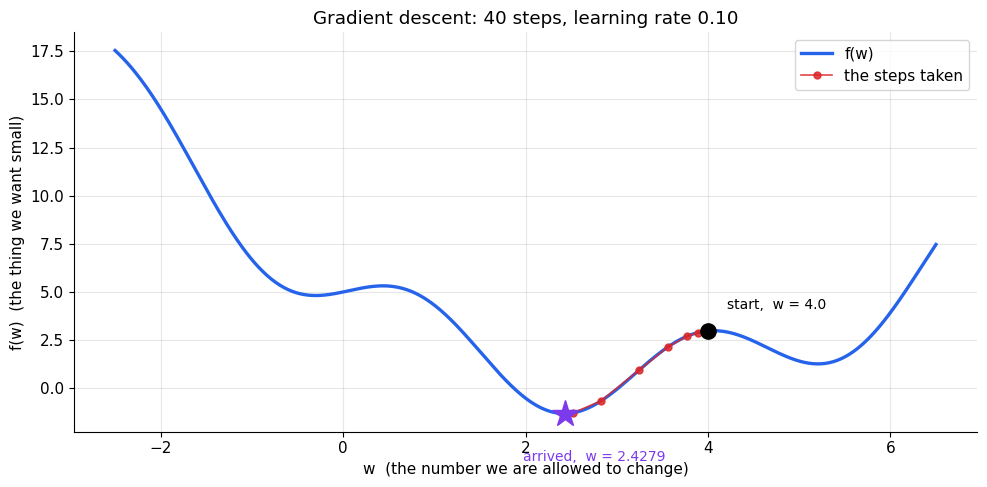

In [71]:
# ============================================================
#  Gradient descent in seven lines, and the path it walks.
# ============================================================
f  = sp.lambdify(w_sym, f_expr,  "numpy")   # f (w) as a fast numeric function
fp = sp.lambdify(w_sym, fp_expr, "numpy")   # f'(w) likewise


def gradient_descent_1d(w_start, eta, n_steps):
    """Walk downhill on f. Returns every w visited, including the start."""
    w = float(w_start)
    path = [w]
    for _ in range(n_steps):
        w = w - eta * fp(w)                 # <-- the entire algorithm
        path.append(w)
    return np.array(path)


path = gradient_descent_1d(w_start=4.0, eta=0.10, n_steps=40)

print("step |      w       |    f(w)     |   f'(w)   ")
print("-----+--------------+-------------+-----------")
for k in (0, 1, 2, 3, 5, 10, 20, 40):
    print(f"{k:4d} | {path[k]:12.7f} | {f(path[k]):11.7f} | {fp(path[k]):9.5f}")

w_star = float(sp.nsolve(fp_expr, w_sym, 2.0))
print()
print(f"gradient descent landed at  w = {path[-1]:.9f}")
print(f"the numerical root of f'    w = {w_star:.9f}")
print(f"difference                      {abs(path[-1] - w_star):.2e}")
print()
print("Nobody solved anything. We only ever evaluated the slope and stepped.")

# ---- the picture -------------------------------------------------------
grid = np.linspace(-2.5, 6.5, 600)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(grid, f(grid), color=C_F, lw=2.4, label="f(w)")
ax.plot(path, f(path), "o-", color=C_SLOPE, ms=5, lw=1.2, alpha=0.85,
        label="the steps taken")
ax.plot(path[0], f(path[0]), "o", color="black", ms=11, zorder=5)
ax.annotate("start,  w = 4.0", (path[0], f(path[0])),
            textcoords="offset points", xytext=(14, 16), fontsize=10)
ax.plot(path[-1], f(path[-1]), "*", color=C_EXACT, ms=20, zorder=5)
ax.annotate(f"arrived,  w = {path[-1]:.4f}", (path[-1], f(path[-1])),
            textcoords="offset points", xytext=(-30, -34), fontsize=10,
            color=C_EXACT)
ax.set_xlabel("w  (the number we are allowed to change)")
ax.set_ylabel("f(w)  (the thing we want small)")
ax.set_title("Gradient descent: 40 steps, learning rate 0.10")
ax.legend()
fig.tight_layout()
plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The blue curve is the loss. The red dots are the successive values of $w$, each one placed at its own height on the curve, joined in the order they were visited. The walk starts at the black dot on the right-hand slope and ends at the purple star in the valley.

Look at the **spacing** of the dots. They are far apart at the start, where the curve is steep, and crowd together near the bottom, where it is nearly flat. Nothing in the code schedules that: the step length is $\eta \, f'(w)$, and $f'(w)$ shrinks to zero at the minimum, so the steps shrink with it. The algorithm brakes automatically.

The printed table shows the same thing in numbers: $f'(w)$ falls towards zero, and the final $w$ agrees with the numerical root of $f'$ to the printed number of decimal places — two completely different methods, one answer.

**The common misread:** thinking the dots trace a path *along the curve*, as though a ball were rolling down it. They do not. Only the horizontal positions are real; the heights are drawn in afterwards so you can see which part of the curve each $w$ corresponds to. The algorithm knows nothing about the curve except the slope directly beneath it.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**The minus sign is not decoration.**

The derivative points in the direction of **increase**. Part 3 built it that way: $f'(w) > 0$ means $f$ gets bigger as $w$ gets bigger. So $w + \eta f'(w)$ climbs the hill, and $w - \eta f'(w)$ descends it.

Drop the minus sign by accident and your loss will rise smoothly and confidently forever — and because it rises *smoothly*, it looks like working code with a bad learning rate rather than a sign error. This is one of the two or three most common bugs in hand-written training loops.

The name is a warning too. *Gradient ascent* is the same formula with a plus, and it is what you run when you want to **maximise** something — a likelihood, a reward. Same calculus, opposite sign.

</div>

### The learning rate, shown as three failures and one success

$\eta$ is the one number you must choose yourself, and choosing it badly is
the most common reason a model fails to train. To see exactly what goes wrong
we drop to the simplest possible bowl,

$$f(w) = (w-3)^2, \qquad f'(w) = 2(w-3),$$

because here we can *predict* the failure and then watch it happen. Substitute
the derivative into the update rule and write $d = w - 3$ for the distance
from the minimum:

$$w_{\text{new}} - 3 \;=\; (w - 3) - \eta \cdot 2(w-3) \;=\; (1 - 2\eta)\,(w-3)$$

So every step multiplies the distance to the minimum by the fixed factor
$(1 - 2\eta)$. That one line tells you everything:

| $\eta$ | factor $1-2\eta$ | what happens |
|---|---|---|
| tiny | just under $1$ | shrinks, but agonisingly slowly |
| $0.5$ | $0$ | lands exactly on the minimum in **one** step |
| between $0.5$ and $1$ | negative, size $<1$ | overshoots each time, but by less — spirals in |
| $> 1$ | negative, size $>1$ | overshoots by **more** each time — explodes |

The threshold is $|1 - 2\eta| = 1$, i.e. $\eta = 1$. And $2$ is exactly
$f''(w)$, the curvature from Part 5, so the general rule is
$\eta < 2 / f''$: **the more sharply curved the bowl, the smaller your steps
must be.**


f''(w) = 2   ->  gradient descent diverges once eta > 2/f'' = 1.0

eta = 0.005  (too small    ) factor 1-2*eta = +0.990
    after 40 steps:  w =         6.3449   distance still to go = 3.3449e+00

eta = 0.150  (just right   ) factor 1-2*eta = +0.700
    after 40 steps:  w =         3.0000   distance still to go = 3.1834e-06

eta = 0.900  (too large    ) factor 1-2*eta = -0.800
    after 40 steps:  w =         3.0007   distance still to go = 6.6461e-04

eta = 1.150  (far too large) factor 1-2*eta = -1.300
    after 40 steps:  w =    180597.3240   distance still to go = 1.8059e+05
    w at steps 0,5,10,20,30,40:  8  -15.6  71.9  953  1.31e+04  1.81e+05



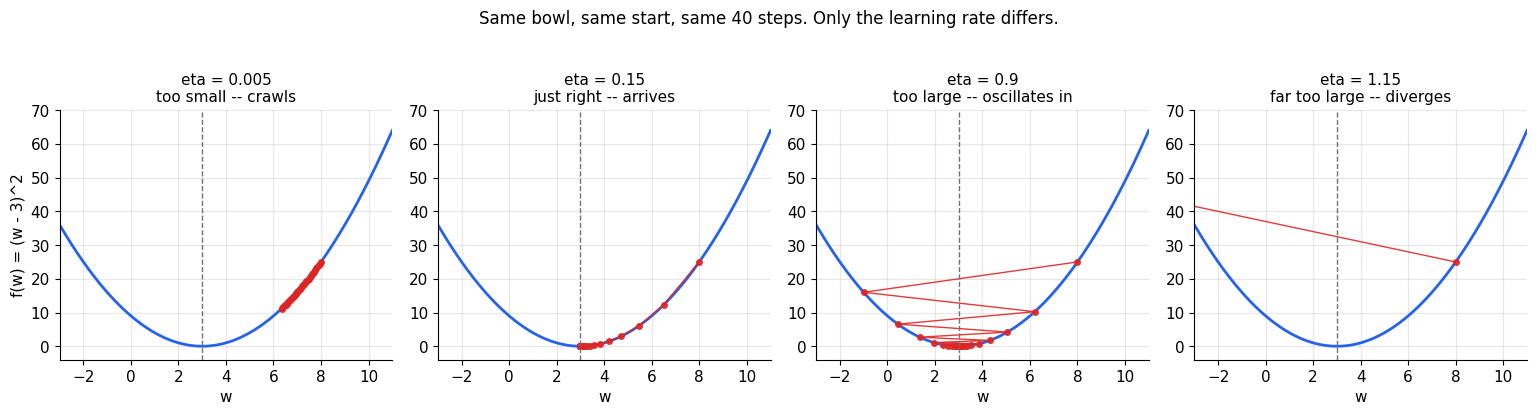

In [72]:
# ============================================================
#  One bowl, four learning rates. The most useful figure here.
# ============================================================
def f_bowl(w):  return (w - 3.0) ** 2
def fp_bowl(w): return 2.0 * (w - 3.0)

# The curvature, and the threshold it implies -- computed, not asserted.
fpp = sp.diff((w_sym - 3) ** 2, w_sym, 2)
eta_max = float(2 / fpp)
print(f"f''(w) = {fpp}   ->  gradient descent diverges once eta > 2/f'' = {eta_max:.1f}")
print()

W_START, N_STEPS = 8.0, 40
settings = [(0.005, "too small",     "crawls"),
            (0.150, "just right",    "arrives"),
            (0.900, "too large",     "oscillates in"),
            (1.150, "far too large", "diverges")]

paths = {}
for eta, label, _ in settings:
    w, hist = W_START, [W_START]
    for _ in range(N_STEPS):
        w = w - eta * fp_bowl(w)
        hist.append(w)
    paths[eta] = np.array(hist)

for eta, label, verdict in settings:
    p = paths[eta]
    print(f"eta = {eta:<6.3f} ({label:<13}) factor 1-2*eta = {1 - 2 * eta:+.3f}")
    print(f"    after {N_STEPS} steps:  w = {p[-1]:14.4f}   "
          f"distance still to go = {abs(p[-1] - 3.0):.4e}")
    if eta == 1.150:
        shown = "  ".join(f"{v:.3g}" for v in p[[0, 5, 10, 20, 30, 40]])
        print(f"    w at steps 0,5,10,20,30,40:  {shown}")
    print()

# ---- four panels -------------------------------------------------------
gw = np.linspace(-3, 11, 400)
fig, axes = plt.subplots(1, 4, figsize=(15.5, 4.0), sharey=False)
for ax, (eta, label, verdict) in zip(axes, settings):
    p = paths[eta]
    ax.plot(gw, f_bowl(gw), color=C_F, lw=2.0)
    vis = p[np.abs(p) < 11]                       # the diverging run leaves the frame
    ax.plot(vis, f_bowl(vis), "o-", color=C_SLOPE, ms=4, lw=1.0, alpha=0.9)
    ax.axvline(3.0, color=C_GREY, ls="--", lw=1.0)
    ax.set_title(f"eta = {eta}\n{label} -- {verdict}", fontsize=11)
    ax.set_xlabel("w")
    ax.set_xlim(-3, 11)
    ax.set_ylim(-4, 70)
axes[0].set_ylabel("f(w) = (w - 3)^2")
fig.suptitle("Same bowl, same start, same 40 steps. Only the learning rate differs.",
             y=1.03, fontsize=12)
fig.tight_layout()
plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Four runs of identical code from the identical starting point $w = 8$, differing only in $\eta$. The dashed grey line is the true minimum at $w = 3$.

**Panel 1** — the dots barely move. The run is not wrong, it is *unfinished*: the printed distance-still-to-go says how far short it stopped. Give it enough steps and it arrives; you may not have enough steps.

**Panel 2** — dots march down one side and settle, spacing shrinking as the slope flattens. This is what a healthy training run looks like.

**Panel 3** — dots alternate between the two walls of the bowl, each pair closer in than the last. Overshooting, but recovering. A loss curve that wobbles downward is this.

**Panel 4** — dots alternate too, but *outward*. The printed values at steps 0, 5, 10, 20, 30, 40 climb by orders of magnitude. Within a few more steps they overflow to infinity, and everything downstream becomes `nan`.

**The common misread:** reading panel 4 as "the step was too big so it jumped over the minimum". Panel 3 also jumps over the minimum, every single step, and converges perfectly well. What kills panel 4 is not overshooting but overshooting by a factor **greater than one**, so each correction is larger than the error it was correcting.

*Prediction and experiment agree, incidentally.* The algebra above said divergence begins at $|1-2\eta| = 1$, i.e. $\eta = 1$; the cell computed the same threshold independently as $2/f''$ from the second derivative sympy differentiated for it. The printed factors are $-0.800$ for panel 3 and $-1.300$ for panel 4 — one shrinks the error each step, the other grows it by 30%.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**Learning rate too large is the failure that does not look like a bug.**

A sign error, a shape mismatch, a typo — these raise exceptions. An $\eta$ past the threshold raises nothing. The loss prints a few plausible numbers, then something like `1e+38`, then `nan`, and every weight in the model is `nan` forever after because `nan` minus anything is still `nan`.

The tells, in order of appearance: loss *increasing* between early steps; loss jumping by orders of magnitude rather than percentages; loss becoming `nan` and staying there. **First response is always to divide $\eta$ by ten and re-run.** Do that before you go looking for a subtler cause — it is right far more often than it has any business being.

And note the threshold we computed, $\eta < 2/f''$: it depends on the *curvature*, which is a property of your data and your architecture. A learning rate that was fine on one problem can diverge on the next. There is no universally safe value.

</div>

### Two knobs instead of one

Nothing changes when there is more than one number to tune, because Part 8
already did the work. There, the **gradient** $\nabla f$ was defined as the
vector of partial derivatives — one slope per variable, each measured while
the others are held still — and it was shown to point in the direction of
steepest *increase*.

So the update rule is the same sentence with bold letters:

$$\mathbf{w}_{\text{new}} \;=\; \mathbf{w}_{\text{old}} \;-\; \eta \, \nabla f(\mathbf{w}_{\text{old}})$$

Take a bowl of exactly the kind Part 8 differentiated, but a *stretched* one —
much more sharply curved in one direction than the other:

$$f(a, b) = a^2 + 6b^2, \qquad
\frac{\partial f}{\partial a} = 2a, \qquad
\frac{\partial f}{\partial b} = 12b, \qquad
\nabla f = \begin{bmatrix} 2a \\ 12b \end{bmatrix}$$


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

$\nabla f$ — said "grad f" — is just the two slopes stacked into a list: *how steeply does $f$ rise if I nudge $a$?* and *how steeply if I nudge $b$?* Subtracting $\eta \nabla f$ from the pair $(a, b)$ nudges **both** knobs downhill at once, each in proportion to how much it personally matters.

The stretch is the interesting part. Here $b$ has curvature $12$ and $a$ has curvature $2$, so the safe learning rates are $\eta < 2/12 = 0.167$ for $b$ but $\eta < 2/2 = 1$ for $a$. One $\eta$ has to serve both. It gets chosen by the tightest direction, which leaves it far too timid for the loose one — so descent is nearly at its limit along $b$ and crawling along $a$. That mismatch is the origin of the zig-zag below, and it is why optimisers like Adam exist: they give every coordinate its own effective step size.

</div>

f(a,b)      = a**2 + 6*b**2
grad f      = [2*a, 12*b]
curvatures  = [2, 12]  ->  safe eta below [1.0, 0.16666666666666666]

step |     a      |     b      |  f(a,b)
-----+------------+------------+---------
   0 |   -4.50000 |    2.00000 | 44.25000
   1 |   -3.24000 |   -1.36000 | 21.59520
   2 |   -2.33280 |    0.92480 | 10.57349
   3 |   -1.67962 |   -0.62886 |  5.19393
   6 |   -0.62691 |    0.19773 |  0.62762
  12 |   -0.08734 |    0.01955 |  0.00992
  30 |   -0.00024 |    0.00002 |  0.00000

finished at (a, b) = (-0.00024, 0.00002), true minimum is (0, 0)
b flips sign every step: [ 1 -1  1 -1  1 -1] -- that is the zig-zag


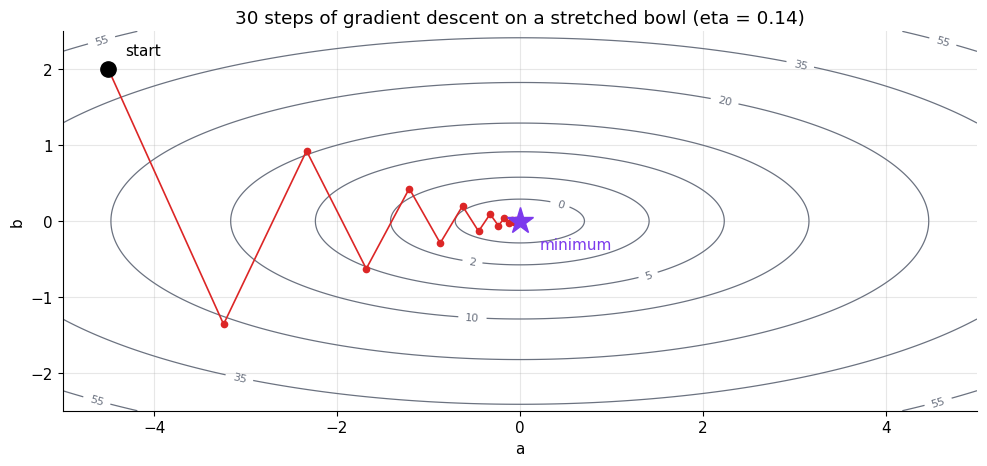

In [73]:
# ============================================================
#  Gradient descent in 2-D, on a stretched bowl.
# ============================================================
a_sym, b_sym = sp.symbols("a b", real=True)
F = a_sym**2 + 6 * b_sym**2

grad_sym = [sp.diff(F, v) for v in (a_sym, b_sym)]     # Part 8's gradient
print("f(a,b)      =", F)
print("grad f      =", grad_sym)
print("curvatures  =", [sp.diff(F, v, 2) for v in (a_sym, b_sym)],
      " ->  safe eta below", [float(2 / sp.diff(F, v, 2)) for v in (a_sym, b_sym)])
print()

F_num    = sp.lambdify((a_sym, b_sym), F, "numpy")
grad_num = sp.lambdify((a_sym, b_sym), grad_sym, "numpy")

def descend_2d(start, eta, n_steps):
    p = np.array(start, dtype=float)
    trail = [p.copy()]
    for _ in range(n_steps):
        g = np.array(grad_num(p[0], p[1]), dtype=float)
        p = p - eta * g                                # same rule, now a vector
        trail.append(p.copy())
    return np.array(trail)

trail = descend_2d(start=(-4.5, 2.0), eta=0.14, n_steps=30)

print("step |     a      |     b      |  f(a,b)")
print("-----+------------+------------+---------")
for k in (0, 1, 2, 3, 6, 12, 30):
    print(f"{k:4d} | {trail[k, 0]:10.5f} | {trail[k, 1]:10.5f} | "
          f"{F_num(trail[k, 0], trail[k, 1]):8.5f}")
print()
print(f"finished at (a, b) = ({trail[-1,0]:.5f}, {trail[-1,1]:.5f}), "
      f"true minimum is (0, 0)")
print(f"b flips sign every step: {np.sign(trail[:6,1]).astype(int)} "
      f"-- that is the zig-zag")

# ---- contour map with the path drawn on it -----------------------------
ga = np.linspace(-5, 5, 300)
gb = np.linspace(-2.5, 2.5, 300)
GA, GB = np.meshgrid(ga, gb)
fig, ax = plt.subplots(figsize=(10, 4.8))
cs = ax.contour(GA, GB, F_num(GA, GB), levels=np.array([0.5, 2, 5, 10, 20, 35, 55, 80]),
                colors=C_GREY, linewidths=0.9)
ax.clabel(cs, inline=True, fontsize=8, fmt="%.0f")
ax.plot(trail[:, 0], trail[:, 1], "o-", color=C_SLOPE, ms=4.5, lw=1.2)
ax.plot(*trail[0],  "o", color="black",  ms=11, zorder=5)
ax.plot(0, 0, "*", color=C_EXACT, ms=20, zorder=5)
ax.annotate("start", trail[0], textcoords="offset points", xytext=(12, 10))
ax.annotate("minimum", (0, 0), textcoords="offset points", xytext=(14, -20),
            color=C_EXACT)
ax.set_xlabel("a"); ax.set_ylabel("b")
ax.set_title("30 steps of gradient descent on a stretched bowl (eta = 0.14)")
fig.tight_layout()
plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The grey rings are **contours** — curves along which $f$ is constant, labelled with their value, exactly like height lines on a hiking map. They are ellipses rather than circles because the bowl is six times more sharply curved along $b$ than along $a$.

The red path starts at the black dot and works towards the purple star at the origin. It does not go straight there. It **zig-zags across the valley** — the printed signs of $b$ flip at every single step — while creeping along the valley floor towards the minimum. Every step is exactly $-\eta \nabla f$; the gradient at the wall of a narrow valley points mostly *across* it, not along it, so most of each step is spent bouncing between the walls.

The printed table shows the cost: $a$ is still visibly non-zero after 30 steps while $b$ has long since collapsed.

**The common misread:** thinking the path crosses the contour lines at odd angles because the algorithm is confused. It crosses them at exactly right angles — the gradient is always perpendicular to the contour through the point, which is Part 8's result. The zig-zag comes from the *step length* carrying it past the valley floor, not from a wrong direction.

</div>

### One honest paragraph about where this fails

Gradient descent is a local procedure. It reads the slope directly under your
feet and nothing else, so it finds *a* place where the gradient is zero — not
necessarily the best one. On the wiggly function from 9.1 there were **three**
such places. Which one you get depends entirely on where you started, and the
algorithm cannot tell you that a better valley exists two hills over, because
it has never been there.

That sounds fatal, and in one dimension it very nearly is. In the millions of
dimensions a real network lives in, the picture changes, and the change is
worth knowing about. For a point to be a local minimum, the surface must curve
*upward in every single direction at once*. With a million directions that is
an extraordinarily demanding coincidence; the overwhelmingly likelier way for
the gradient to vanish is that the surface curves up in some directions and
down in others. Such a point is a **saddle** — a mountain pass, flat underfoot,
uphill along the ridge and downhill towards the valleys on either side. Saddles
are the common obstacle in high dimensions, and they are a far kinder one:
gradient descent slows to a crawl near a saddle because the gradient is small,
but it is not stuck, because there is always a downhill direction to find.

This is a large part of why training enormous networks works at all, which
surprised people considerably when it became clear.


start w = 4.0  ->  ends at w = 2.427947, f = -1.315819
start w = 5.0  ->  ends at w = 5.205745, f = 1.264221

Identical algorithm, identical learning rate, identical number of steps.
The start at w = 4.0 found the better valley; the other did not,
and it has no way of knowing. Gap in f: 2.5800

saddle f(a,b) = a**2 - b**2;  grad = [2*a, -2*b];  at (0,0) grad = [0.0, 0.0]  <- zero, yet not a minimum
curvature along a: 2  (up)    curvature along b: -2  (down)


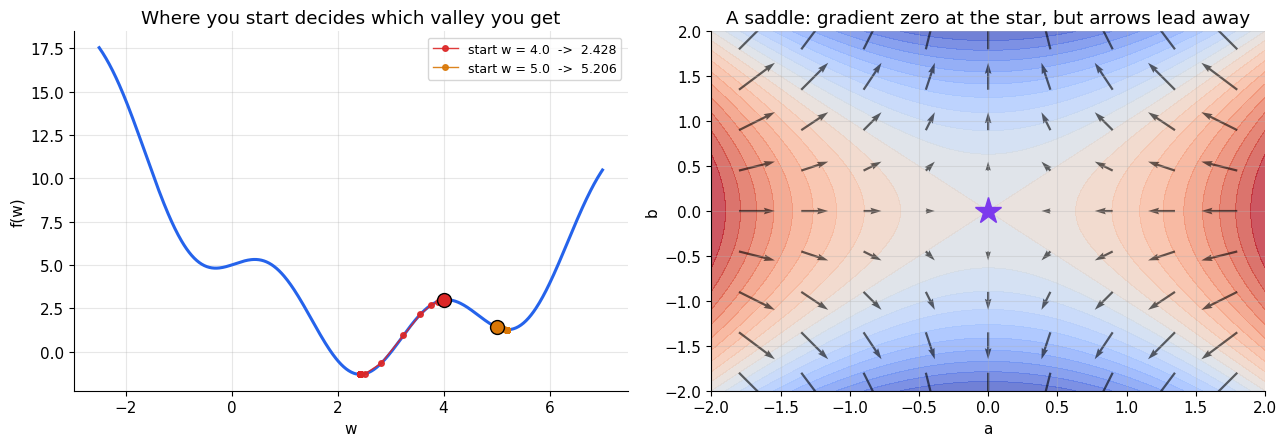

In [74]:
# ============================================================
#  Left: same code, two starting points, two different answers.
#  Right: what a saddle looks like, and why it is not a trap.
# ============================================================
starts = [4.0, 5.0]
runs   = {s: gradient_descent_1d(s, eta=0.10, n_steps=60) for s in starts}
for s in starts:
    p = runs[s]
    print(f"start w = {s:.1f}  ->  ends at w = {p[-1]:.6f}, f = {f(p[-1]):.6f}")
best = min(starts, key=lambda s: f(runs[s][-1]))
print(f"\nIdentical algorithm, identical learning rate, identical number of steps.")
print(f"The start at w = {best:.1f} found the better valley; the other did not,")
print(f"and it has no way of knowing. Gap in f: "
      f"{abs(f(runs[starts[0]][-1]) - f(runs[starts[1]][-1])):.4f}")

# a saddle: f(a,b) = a^2 - b^2. Gradient is zero at the origin, but it is
# neither a peak nor a valley.
S = a_sym**2 - b_sym**2
gS = [sp.diff(S, v) for v in (a_sym, b_sym)]
print(f"\nsaddle f(a,b) = {S};  grad = {gS};  at (0,0) grad = "
      f"{[float(g.subs({a_sym: 0, b_sym: 0})) for g in gS]}  <- zero, yet not a minimum")
print(f"curvature along a: {sp.diff(S, a_sym, 2)}  (up)    "
      f"curvature along b: {sp.diff(S, b_sym, 2)}  (down)")
S_num  = sp.lambdify((a_sym, b_sym), S, "numpy")
gS_num = sp.lambdify((a_sym, b_sym), gS, "numpy")

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.6))

gwide = np.linspace(-2.5, 7.0, 600)
axL.plot(gwide, f(gwide), color=C_F, lw=2.2)
for s, col in zip(starts, [C_SLOPE, C_APPROX]):
    p = runs[s]
    axL.plot(p, f(p), "o-", ms=4, lw=1.0, color=col, alpha=0.9,
             label=f"start w = {s:.1f}  ->  {p[-1]:.3f}")
    axL.plot(p[0], f(p[0]), "o", color=col, ms=10, mec="black", zorder=5)
axL.set_xlabel("w"); axL.set_ylabel("f(w)")
axL.set_title("Where you start decides which valley you get")
axL.legend(fontsize=9)

ga2 = np.linspace(-2, 2, 260); gb2 = np.linspace(-2, 2, 260)
GA2, GB2 = np.meshgrid(ga2, gb2)
axR.contourf(GA2, GB2, S_num(GA2, GB2), levels=24, cmap="coolwarm", alpha=0.75)
qa, qb = np.meshgrid(np.linspace(-1.8, 1.8, 9), np.linspace(-1.8, 1.8, 9))
QU, QV = gS_num(qa, qb)
axR.quiver(qa, qb, -QU, -QV, color="black", alpha=0.6, width=0.004)
axR.plot(0, 0, "*", color=C_EXACT, ms=20, zorder=5)
axR.set_xlabel("a"); axR.set_ylabel("b")
axR.set_title("A saddle: gradient zero at the star, but arrows lead away")
fig.tight_layout()
plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

**Left.** One function, one algorithm, one learning rate — two starting points. The red run slides into the deep valley; the orange run, starting only one unit further right, settles into a shallower one and stops there because the ground beneath it really is flat. The printed gap in $f$ is the price of that single unit of starting position.

**Right.** The saddle $f(a,b) = a^2 - b^2$. Colour is height: blue low, red high. The arrows are $-\nabla f$, the direction gradient descent would step. At the purple star both partial derivatives are exactly zero — the cell prints them — so Part 5's test says *stationary point*. But look at the arrows nearby: they point **away** from the star, up the valley in $b$. Nothing is trapped here. The printed curvatures say why: $+2$ along $a$, $-2$ along $b$. Up one way, down the other.

**The common misread:** taking the left panel as proof that deep learning cannot work. It is a one-dimensional picture, and one dimension is the worst case — the only way out of a valley is through a wall. Add dimensions and a valley must be walled in *every* direction to hold you, which the right panel shows is not what usually happens.

</div>

---

## 9.2 Fitting a real model, twice

Enough hills. Let us fit something.

Here is the smallest real machine-learning problem: given some points, draw the
straight line that fits them best. The model is

$$\hat{y}_i = m x_i + c$$

with two parameters — the slope $m$ and the intercept $c$ — and "best" means
the line minimising the **mean squared error**:

$$L(m, c) \;=\; \frac{1}{n}\sum_{i=1}^{n}\bigl(m x_i + c - y_i\bigr)^2$$

We will find $m$ and $c$ **twice**, by two methods that share no code:

1. **Part 5's recipe.** Take $\partial L/\partial m$ and $\partial L/\partial c$
   (Part 8), set both to zero, and solve the resulting pair of equations
   exactly. This one *is* solvable — $L$ is a quadratic in $m$ and $c$, so the
   derivatives are linear, so the equations are a $2 \times 2$ linear system.
2. **Gradient descent.** Start at $m = c = 0$ and walk downhill, never solving
   anything.

If calculus is telling the truth, the two answers are the same number.


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

Why setting *both* partial derivatives to zero is the right move: at the bottom of a bowl, the surface is flat in **every** direction at once. Flat along $m$ means $\partial L / \partial m = 0$; flat along $c$ means $\partial L / \partial c = 0$. Two conditions, two unknowns — and because $L$ is built from squares, differentiating brings the powers down to $1$ and leaves two straight lines in $(m, c)$, which cross at exactly one point.

In words the loss says: *for each point, measure how far my line misses it vertically, square that so misses above and below count the same and big misses count much worse, then average.* The squaring is what makes the calculus easy, and it is very nearly the only reason it is used.

</div>

40 points generated from y = 2.3x + 1.7 plus noise of sd 2.0
(the model does not know those numbers, and noise means it should not
 recover them exactly -- it recovers the best line THROUGH THIS DATA.)



dL/dm = 0  ->   Eq(10.73*c + 75.71*m - 197.4, 0)
dL/dc = 0  ->   Eq(2.0*c + 10.73*m - 29.29, 0)

Two linear equations in two unknowns. Part 5 says solve them.

ANALYTIC   m = 2.218569752618   c = 2.739278244669   L = 4.628779869948
start          m = 0.0000000000   c = 0.0000000000   L = 263.677735
after     1    m = 3.9472214240   c = 0.5858375893   L = 82.423056
after    10    m = 2.5209855327   c = 0.5774177142   L = 5.746825
after   100    m = 2.3506544201   c = 1.8134344756   L = 4.833748
after  1000    m = 2.2185972721   c = 2.7390853480   L = 4.628780
after  4000    m = 2.2185697526   c = 2.7392782447   L = 4.628780

            slope m               intercept c
analytic    2.218569752618      2.739278244669
descent     2.218569752618      2.739278244670
difference  3.952e-14          2.358e-13

loss, analytic 4.628779869948   descent 4.628779869948
numpy's polyfit, as a third opinion: [2.21856975 2.73927824]


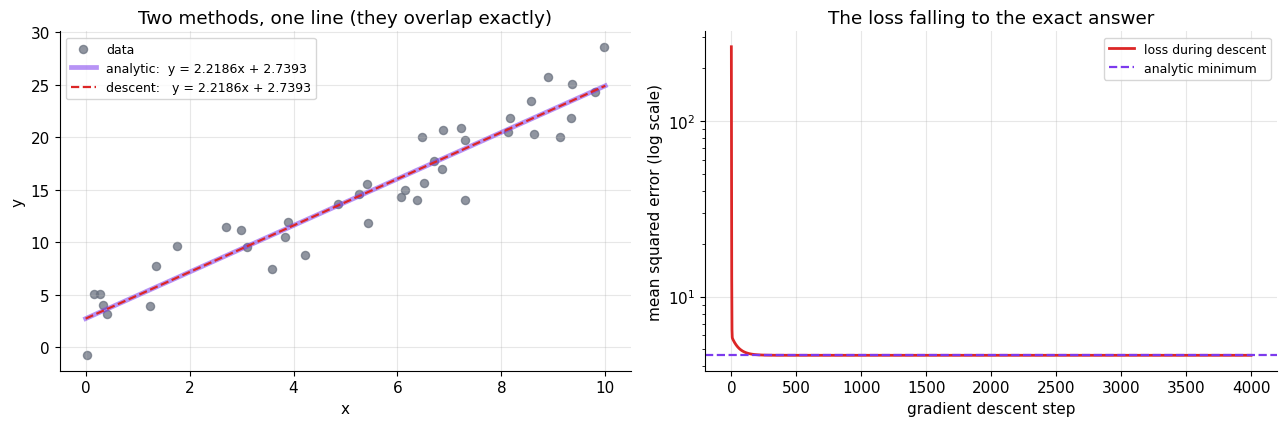

In [75]:
# ============================================================
#  Method 1 -- Part 5's recipe, done symbolically, exactly.
# ============================================================
rng = np.random.default_rng(0)
n_pts = 40
X_data = np.sort(rng.uniform(0, 10, n_pts))
Y_data = 2.3 * X_data + 1.7 + rng.normal(0, 2.0, n_pts)   # true line + noise
print(f"{n_pts} points generated from y = 2.3x + 1.7 plus noise of sd 2.0")
print("(the model does not know those numbers, and noise means it should not")
print(" recover them exactly -- it recovers the best line THROUGH THIS DATA.)")
print()

m_sym, c_sym = sp.symbols("m c", real=True)
L_sym = sum((m_sym * float(xi) + c_sym - float(yi))**2
            for xi, yi in zip(X_data, Y_data)) / n_pts

dL_dm = sp.simplify(sp.diff(L_sym, m_sym))     # partial derivatives, Part 8
dL_dc = sp.simplify(sp.diff(L_sym, c_sym))
print("dL/dm = 0  ->  ", sp.Eq(sp.nsimplify(dL_dm, rational=False).evalf(4), 0))
print("dL/dc = 0  ->  ", sp.Eq(sp.nsimplify(dL_dc, rational=False).evalf(4), 0))
print()
print("Two linear equations in two unknowns. Part 5 says solve them.")

sol = sp.solve([sp.Eq(dL_dm, 0), sp.Eq(dL_dc, 0)], [m_sym, c_sym], dict=True)[0]
m_exact, c_exact = float(sol[m_sym]), float(sol[c_sym])

def mse(m, c):
    return float(np.mean((m * X_data + c - Y_data) ** 2))

print(f"\nANALYTIC   m = {m_exact:.12f}   c = {c_exact:.12f}   L = {mse(m_exact, c_exact):.12f}")

# ============================================================
#  Method 2 -- gradient descent. No solving, only stepping.
#  (Same cell, so the two answers can be compared on the spot.)
# ============================================================
# The gradient, differentiated by hand from L = mean((m*x + c - y)^2):
#     dL/dm = mean( 2 * (m*x + c - y) * x )      [chain rule, Part 4]
#     dL/dc = mean( 2 * (m*x + c - y) * 1 )
def mse_grad(m, c):
    resid = m * X_data + c - Y_data
    return 2.0 * np.mean(resid * X_data), 2.0 * np.mean(resid)

m_gd, c_gd, eta_fit, n_iter = 0.0, 0.0, 0.02, 4000
loss_hist, m_hist, c_hist = [mse(m_gd, c_gd)], [m_gd], [c_gd]
for _ in range(n_iter):
    gm, gc = mse_grad(m_gd, c_gd)
    m_gd -= eta_fit * gm
    c_gd -= eta_fit * gc
    loss_hist.append(mse(m_gd, c_gd)); m_hist.append(m_gd); c_hist.append(c_gd)

print(f"start          m = {m_hist[0]:.10f}   c = {c_hist[0]:.10f}   L = {loss_hist[0]:.6f}")
for k in (1, 10, 100, 1000, n_iter):
    print(f"after {k:5d}    m = {m_hist[k]:.10f}   c = {c_hist[k]:.10f}   L = {loss_hist[k]:.6f}")

print()
print("            slope m               intercept c")
print(f"analytic    {m_exact:.12f}      {c_exact:.12f}")
print(f"descent     {m_gd:.12f}      {c_gd:.12f}")
print(f"difference  {abs(m_gd - m_exact):.3e}          {abs(c_gd - c_exact):.3e}")
print(f"\nloss, analytic {mse(m_exact, c_exact):.12f}   descent {loss_hist[-1]:.12f}")
print(f"numpy's polyfit, as a third opinion: {np.polyfit(X_data, Y_data, 1)}")

# ---- the fitted line, and the descent ----------------------------------
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.4))
axA.scatter(X_data, Y_data, s=34, color=C_GREY, alpha=0.75, label="data")
xs = np.linspace(0, 10, 50)
axA.plot(xs, m_exact * xs + c_exact, color=C_EXACT, lw=3.4, alpha=0.55,
         label=f"analytic:  y = {m_exact:.4f}x + {c_exact:.4f}")
axA.plot(xs, m_gd * xs + c_gd, color=C_SLOPE, lw=1.6, ls="--",
         label=f"descent:   y = {m_gd:.4f}x + {c_gd:.4f}")
axA.set_xlabel("x"); axA.set_ylabel("y")
axA.set_title("Two methods, one line (they overlap exactly)")
axA.legend(fontsize=9)

axB.plot(loss_hist, color=C_SLOPE, lw=2.0, label="loss during descent")
axB.axhline(mse(m_exact, c_exact), color=C_EXACT, ls="--", lw=1.6,
            label="analytic minimum")
axB.set_yscale("log")
axB.set_xlabel("gradient descent step")
axB.set_ylabel("mean squared error (log scale)")
axB.set_title("The loss falling to the exact answer")
axB.legend(fontsize=9)
fig.tight_layout()
plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

**Left.** The grey dots are the data. The thick purple line is the exact answer from solving $\partial L/\partial m = \partial L/\partial c = 0$; the thin dashed red line is what 4000 downhill steps found. You cannot see two lines because there is, to drawing accuracy, only one — the printed coefficients agree to around a dozen decimal places, and `np.polyfit` agrees as an independent third opinion.

**Right.** The loss during descent, on a logarithmic vertical axis so the whole descent fits in one picture. It falls steeply at first, then flattens onto the dashed purple line — the loss of the exact solution. It approaches that line and never crosses it, because no line can beat the best line.

**The common misread:** expecting the fitted slope to come out at exactly $2.3$, the number the data was generated from. It does not, and it should not. Noise was added, so the best line **through these 40 points** is not the line the points came from. Both methods find the best line through the data they were given, which is all any fitting procedure can do — and the fact that they find the *same* one is the point of the exercise.

</div>

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

Two procedures with nothing in common — sympy solving a linear system in exact arithmetic, and 4000 floating-point subtractions that never form an equation — landed on the same slope and the same intercept to roughly the precision of `float64`, and on the same loss. `np.polyfit`, a third implementation, agrees too.

That agreement is the whole justification for gradient descent. On this problem we could check it against the exact answer. On a network with a hundred million parameters we cannot — there is no exact answer to compare to. We use the method there because we watched it be right here.

</div>

---

## 9.3 Backpropagation, by hand

Everything so far needed the gradient of the loss. For a straight line we
differentiated it in one step. For a neural network, the loss is a function of
a function of a function, and getting its gradient is the job of
**backpropagation** — which is not a new piece of mathematics. It is the chain
rule from Part 4, applied to the multivariable case of Part 8, bookkept
carefully.

Our network, which is as small as a network can be while still being one:

| symbol | what it is | how many |
|---|---|---|
| $x_1, x_2$ | the inputs | 2 |
| $W^{(1)}_{jk}$ | weight from input $k$ into hidden unit $j$ | 4 |
| $b^{(1)}_j$ | bias of hidden unit $j$ | 2 |
| $W^{(2)}_j$ | weight from hidden unit $j$ into the output | 2 |
| $b^{(2)}$ | bias of the output | 1 |

Nine numbers to learn. The forward pass, in order:

$$z^{(1)}_j = W^{(1)}_{j1}x_1 + W^{(1)}_{j2}x_2 + b^{(1)}_j
\qquad\text{(a weighted sum)}$$

$$a^{(1)}_j = \sigma\!\left(z^{(1)}_j\right), \qquad
\sigma(z) = \frac{1}{1 + e^{-z}}
\qquad\text{(squash it between 0 and 1)}$$

$$z^{(2)} = W^{(2)}_1 a^{(1)}_1 + W^{(2)}_2 a^{(1)}_2 + b^{(2)}, \qquad o = z^{(2)}$$

$$L = (o - y)^2 \qquad\text{(how wrong we were, squared)}$$

That is the whole model. Nine numbers, one sigmoid, one squared error.


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

The network is a **pipeline**, and each stage does one simple thing.

Each hidden unit takes the two inputs, multiplies each by its own weight, adds them up with a bias, and gets a single number $z$. That number could be anything from very negative to very positive, so the **sigmoid** $\sigma$ squashes it into the range $0$ to $1$ — big negative goes to nearly $0$, big positive to nearly $1$, and zero goes to exactly a half. That squash is the only non-straight-line thing in the model, and without it the whole network would collapse into a single straight line no matter how many layers you stacked.

The output unit does the same weighted-sum trick to the two squashed numbers, without a squash this time, and that is the prediction $o$. The loss squares the gap between $o$ and the truth $y$.

Training means: nudge those nine numbers so that $L$ gets smaller. Which needs nine partial derivatives — one per number — which is what backprop computes.

</div>

FORWARD PASS, node by node


--------------------------------------------------------------
inputs        x1 = 0.6000      x2 = 0.9000
hidden 1      z1[0] = +0.50*0.60 -1.20*0.90 +0.10 = -0.680000
              a1[0] = sigmoid(-0.680000)           = 0.336261
hidden 2      z1[1] = +0.80*0.60 +0.30*0.90 -0.40 = +0.350000
              a1[1] = sigmoid(+0.350000)           = 0.586618
output        z2    = +1.10*0.336261 -0.70*0.586618 +0.25 = +0.209255
prediction    o     = 0.209255        target y = 1.0000
loss          L     = (o - y)^2 = (0.209255 - 1.0000)^2 = 0.625277


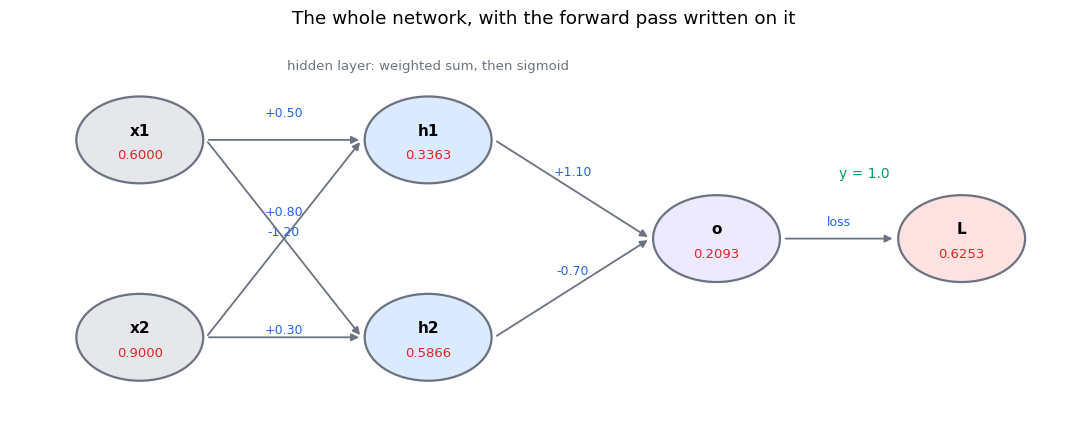

In [76]:
# ============================================================
#  The forward pass, with every intermediate number printed,
#  and the network drawn with those numbers on it.
# ============================================================
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

# Fixed, hand-chosen values so the arithmetic below is reproducible and small.
W1 = np.array([[0.50, -1.20],
               [0.80,  0.30]])         # W1[j, k]: input k -> hidden j
b1 = np.array([0.10, -0.40])
W2 = np.array([1.10, -0.70])           # hidden j -> output
b2 = 0.25
x_in  = np.array([0.60, 0.90])         # one training example
y_true = 1.0                           # ... and its correct answer

# ---- forward, one node at a time --------------------------------------
z1 = W1 @ x_in + b1
a1 = sigmoid(z1)
z2 = float(W2 @ a1 + b2)
o  = z2                                # output unit is linear
L  = (o - y_true) ** 2

print("FORWARD PASS, node by node")
print("-" * 62)
print(f"inputs        x1 = {x_in[0]:.4f}      x2 = {x_in[1]:.4f}")
for j in (0, 1):
    print(f"hidden {j+1}      z1[{j}] = {W1[j,0]:+.2f}*{x_in[0]:.2f} "
          f"{W1[j,1]:+.2f}*{x_in[1]:.2f} {b1[j]:+.2f} = {z1[j]:+.6f}")
    print(f"              a1[{j}] = sigmoid({z1[j]:+.6f})           = {a1[j]:.6f}")
print(f"output        z2    = {W2[0]:+.2f}*{a1[0]:.6f} {W2[1]:+.2f}*{a1[1]:.6f} "
      f"{b2:+.2f} = {z2:+.6f}")
print(f"prediction    o     = {o:.6f}        target y = {y_true:.4f}")
print(f"loss          L     = (o - y)^2 = ({o:.6f} - {y_true:.4f})^2 = {L:.6f}")

# ---- draw it, labelled with the numbers just computed ------------------
fig, ax = plt.subplots(figsize=(11, 4.6))
pos = {"x1": (0, 1.0), "x2": (0, -1.0),
       "h1": (2, 1.0), "h2": (2, -1.0),
       "o":  (4, 0.0), "L":  (5.7, 0.0)}
vals = {"x1": x_in[0], "x2": x_in[1], "h1": a1[0], "h2": a1[1], "o": o, "L": L}
face = {"x1": C_SOFT, "x2": C_SOFT, "h1": "#DBEAFE", "h2": "#DBEAFE",
        "o": "#EDE9FE", "L": "#FEE2E2"}
for (k, (px, py)) in pos.items():
    ax.add_patch(plt.Circle((px, py), 0.44, facecolor=face[k],
                            edgecolor=C_GREY, lw=1.6, zorder=3))
    ax.text(px, py + 0.10, k, ha="center", va="center", fontsize=11,
            fontweight="bold", zorder=4)
    ax.text(px, py - 0.15, f"{vals[k]:.4f}", ha="center", va="center",
            fontsize=9.5, color=C_SLOPE, zorder=4)

def arrow(p, q, label, dy=0.0):
    (x0, y0), (x1_, y1_) = pos[p], pos[q]
    ax.annotate("", xy=(x1_ - 0.46, y1_), xytext=(x0 + 0.46, y0),
                arrowprops=dict(arrowstyle="-|>", color=C_GREY, lw=1.3))
    ax.text((x0 + x1_) / 2, (y0 + y1_) / 2 + 0.14 + dy, label,
            ha="center", fontsize=9, color=C_F)

for j, hk in enumerate(("h1", "h2")):
    arrow("x1", hk, f"{W1[j,0]:+.2f}",  0.10)
    arrow("x2", hk, f"{W1[j,1]:+.2f}", -0.10)
    arrow(hk, "o", f"{W2[j]:+.2f}")
arrow("o", "L", "loss")
ax.text(2.0, 1.72, "hidden layer: weighted sum, then sigmoid",
        ha="center", fontsize=9.5, color=C_GREY)
ax.text(4.85, 0.62, f"y = {y_true:.1f}", fontsize=10, color=C_AREA)
ax.set_xlim(-0.9, 6.5); ax.set_ylim(-2.0, 2.1)
ax.axis("off"); ax.grid(False)
ax.set_title("The whole network, with the forward pass written on it")
fig.tight_layout()
plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Every circle is a node, labelled with its name and — in red — the value it actually took for this one training example. Every arrow is a weight, labelled in blue with its value. Information flows strictly left to right: inputs, two hidden units, one output, one loss. Nothing loops back.

The printed trace is the same computation written out in full arithmetic, so you can follow any single number back to the multiplications and additions that produced it. Notice that both hidden activations sit strictly between $0$ and $1$ — that is the sigmoid doing its job — while the output $o$ is free to be anything, because the output unit has no squash.

**The common misread:** reading the circles as *storing* the weights. They do not. The weights live on the **arrows** — they belong to connections, not to units. Each circle holds only the one number that arrived there. The nine numbers we are about to differentiate are all written on arrows and biases, never inside a circle.

</div>

### The backward pass, derived one node at a time

Now the derivation. We want $\partial L / \partial(\text{each of the nine
numbers})$. The trick is to **work backwards**, computing the derivative of $L$
with respect to each intermediate node first, and reusing it.

**Step 1 — the output.** $L = (o - y)^2$, and $y$ is a constant. This is the
chain rule from Part 4 with the outer function $u^2$ and the inner function
$u = o - y$:

$$\frac{\partial L}{\partial o} = 2(o - y) \cdot 1 = 2(o - y)$$

Since $o = z^{(2)}$ exactly, $\dfrac{\partial o}{\partial z^{(2)}} = 1$, so

$$\delta^{(2)} \;\equiv\; \frac{\partial L}{\partial z^{(2)}}
= \frac{\partial L}{\partial o}\cdot\frac{\partial o}{\partial z^{(2)}}
= 2(o - y)$$

We give it the name $\delta^{(2)}$ (*delta two*) because it is about to be used
four times, and naming it is the entire reason backpropagation is cheap.

**Step 2 — the output layer's parameters.** $z^{(2)} = W^{(2)}_1 a^{(1)}_1 +
W^{(2)}_2 a^{(1)}_2 + b^{(2)}$. Differentiating a sum with respect to one of
its weights, everything else held fixed (Part 8's partial derivative), leaves
only the factor that multiplied it:

$$\frac{\partial z^{(2)}}{\partial W^{(2)}_j} = a^{(1)}_j,
\qquad \frac{\partial z^{(2)}}{\partial b^{(2)}} = 1$$

so by the chain rule

$$\frac{\partial L}{\partial W^{(2)}_j} = \delta^{(2)} \, a^{(1)}_j,
\qquad
\frac{\partial L}{\partial b^{(2)}} = \delta^{(2)}$$

**Step 3 — back through the weights, into the hidden activations.**

$$\frac{\partial z^{(2)}}{\partial a^{(1)}_j} = W^{(2)}_j
\qquad\Longrightarrow\qquad
\frac{\partial L}{\partial a^{(1)}_j} = \delta^{(2)} \, W^{(2)}_j$$

**Step 4 — back through the sigmoid.** We need $\sigma'$. Derive it once, from
$\sigma(z) = (1 + e^{-z})^{-1}$, by the chain rule:

$$\sigma'(z) = -\left(1 + e^{-z}\right)^{-2}\cdot\left(-e^{-z}\right)
= \frac{e^{-z}}{\left(1 + e^{-z}\right)^{2}}
= \frac{1}{1+e^{-z}}\cdot\frac{e^{-z}}{1+e^{-z}}
= \sigma(z)\bigl(1 - \sigma(z)\bigr)$$

which is a small miracle of convenience: the derivative is built out of the
value we already computed on the way forward. So, writing
$a^{(1)}_j = \sigma(z^{(1)}_j)$,

$$\delta^{(1)}_j \;\equiv\; \frac{\partial L}{\partial z^{(1)}_j}
= \frac{\partial L}{\partial a^{(1)}_j}\cdot\frac{\partial a^{(1)}_j}{\partial z^{(1)}_j}
= \delta^{(2)}\, W^{(2)}_j \, a^{(1)}_j\bigl(1 - a^{(1)}_j\bigr)$$

**Step 5 — the hidden layer's parameters.** Same shape as step 2, one layer
down, since $z^{(1)}_j = W^{(1)}_{j1}x_1 + W^{(1)}_{j2}x_2 + b^{(1)}_j$:

$$\frac{\partial L}{\partial W^{(1)}_{jk}} = \delta^{(1)}_j \, x_k,
\qquad
\frac{\partial L}{\partial b^{(1)}_j} = \delta^{(1)}_j$$

All nine, derived. And notice the shape of it: **every parameter's gradient is
(the delta of the node it feeds) times (the value that came in along that
wire)**. That single sentence is backpropagation.


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

Backpropagation is the chain rule with a memo pad.

The chain rule says: to find how much a wiggle at the far end of a chain affects the near end, multiply the sensitivities of every link. The naive way is to redo that whole product for each of the nine parameters, re-walking the same links again and again.

Instead we walk **backwards once**, and at each node we write down a single number, $\delta$ — *how much would the loss change if this node's value went up by one?* Once you know a node's $\delta$, every parameter feeding into it gets its gradient for one multiplication: $\delta$ times whatever came in along that wire. Nothing is computed twice.

That is why the backward pass costs about the same as the forward pass, no matter how many parameters there are — and why training networks with billions of them is arithmetic rather than fantasy.

</div>

In [77]:
# ============================================================
#  The backward pass. Every gradient printed as an EXPRESSION
#  first, then as a number -- then checked against Part 8's
#  numerical gradient, which knows nothing about our algebra.
# ============================================================
print("BACKWARD PASS")
print("=" * 74)

# --- step 1 -------------------------------------------------------------
dL_do  = 2.0 * (o - y_true)
delta2 = dL_do * 1.0
print(f"dL/do    = 2*(o - y)            = 2*({o:.6f} - {y_true:.4f}) = {dL_do:+.6f}")
print(f"delta2   = dL/do * do/dz2       = {dL_do:+.6f} * 1 = {delta2:+.6f}")
print()

# --- steps 2 and 3 ------------------------------------------------------
gW2 = delta2 * a1
gb2 = delta2
for j in (0, 1):
    print(f"dL/dW2[{j}] = delta2 * a1[{j}]        = {delta2:+.6f} * {a1[j]:.6f} "
          f"= {gW2[j]:+.6f}")
print(f"dL/db2   = delta2               = {gb2:+.6f}")
print()

# --- step 4: back through the sigmoid ----------------------------------
sig_prime = a1 * (1.0 - a1)                 # sigma'(z) = sigma(z)(1 - sigma(z))
dL_da1    = delta2 * W2
delta1    = dL_da1 * sig_prime
for j in (0, 1):
    print(f"dL/da1[{j}] = delta2 * W2[{j}]        = {delta2:+.6f} * {W2[j]:+.2f} "
          f"= {dL_da1[j]:+.6f}")
    print(f"sigma'(z1[{j}]) = a1[{j}]*(1-a1[{j}])   = {a1[j]:.6f}*{1-a1[j]:.6f} "
          f"= {sig_prime[j]:.6f}")
    print(f"delta1[{j}] = dL/da1[{j}] * sigma'   = {dL_da1[j]:+.6f} * "
          f"{sig_prime[j]:.6f} = {delta1[j]:+.6f}")
print()

# --- step 5 -------------------------------------------------------------
gW1 = np.outer(delta1, x_in)                # gW1[j,k] = delta1[j] * x[k]
gb1 = delta1
for j in (0, 1):
    for k in (0, 1):
        print(f"dL/dW1[{j},{k}] = delta1[{j}] * x[{k}]    = {delta1[j]:+.6f} * "
              f"{x_in[k]:.2f} = {gW1[j,k]:+.6f}")
for j in (0, 1):
    print(f"dL/db1[{j}] = delta1[{j}]           = {gb1[j]:+.6f}")

# --- sanity: sigma' really is sigma(1-sigma), checked symbolically ------
z_s = sp.symbols("z_s", real=True)
sig_s = 1 / (1 + sp.exp(-z_s))
print("\nsympy on sigma':", sp.simplify(sp.diff(sig_s, z_s) - sig_s * (1 - sig_s)),
      " (zero means the identity we derived is exact)")

# ============================================================
#  ... and now the verification, in the SAME cell, because a
#  derivation you have not checked is a derivation you are
#  taking on faith. Part 8's numerical gradient nudges one
#  number, sees how much the loss moves, divides. It uses no
#  algebra at all -- so if it agrees with the hand derivation,
#  the hand derivation is right.
# ============================================================
print()
def numerical_gradient(fn, params, eps=1e-6):
    """Central difference, one entry at a time:  (f(p+e) - f(p-e)) / 2e."""
    p = np.array(params, dtype=float)
    grad = np.zeros_like(p)
    it = np.nditer(p, flags=["multi_index"])
    while not it.finished:
        idx = it.multi_index
        keep = p[idx]
        p[idx] = keep + eps; f_plus  = fn(p)
        p[idx] = keep - eps; f_minus = fn(p)
        p[idx] = keep
        grad[idx] = (f_plus - f_minus) / (2 * eps)
        it.iternext()
    return grad


def loss_of(W1_, b1_, W2_, b2_):
    """The forward pass again, as one function of the nine numbers."""
    a = sigmoid(W1_ @ x_in + b1_)
    return float((W2_ @ a + b2_ - y_true) ** 2)


num_W1 = numerical_gradient(lambda A: loss_of(A,  b1, W2, b2), W1)
num_b1 = numerical_gradient(lambda A: loss_of(W1, A,  W2, b2), b1)
num_W2 = numerical_gradient(lambda A: loss_of(W1, b1, A,  b2), W2)
num_b2 = numerical_gradient(lambda A: loss_of(W1, b1, W2, float(A[0])),
                            np.array([b2]))

rows = [("W1[0,0]", gW1[0, 0], num_W1[0, 0]), ("W1[0,1]", gW1[0, 1], num_W1[0, 1]),
        ("W1[1,0]", gW1[1, 0], num_W1[1, 0]), ("W1[1,1]", gW1[1, 1], num_W1[1, 1]),
        ("b1[0]",   gb1[0],    num_b1[0]),    ("b1[1]",   gb1[1],    num_b1[1]),
        ("W2[0]",   gW2[0],    num_W2[0]),    ("W2[1]",   gW2[1],    num_W2[1]),
        ("b2",      gb2,       num_b2[0])]

TOL = 1e-7
print("parameter |  by hand (calculus) |  numerical (nudging) |  |difference| | verdict")
print("-" * 84)
n_pass = 0
for name, hand, numeric in rows:
    diff = abs(hand - numeric)
    ok = diff < TOL
    n_pass += ok
    print(f"{name:<9} | {hand:+19.12f} | {numeric:+20.12f} | {diff:12.3e} | "
          f"{'PASS' if ok else 'FAIL'}")
print("-" * 84)
print(f"{n_pass} / {len(rows)} gradients agree to better than {TOL:.0e}   "
      f"(largest disagreement {max(abs(h - n) for _, h, n in rows):.3e})")


BACKWARD PASS
dL/do    = 2*(o - y)            = 2*(0.209255 - 1.0000) = -1.581490
delta2   = dL/do * do/dz2       = -1.581490 * 1 = -1.581490

dL/dW2[0] = delta2 * a1[0]        = -1.581490 * 0.336261 = -0.531794
dL/dW2[1] = delta2 * a1[1]        = -1.581490 * 0.586618 = -0.927730
dL/db2   = delta2               = -1.581490

dL/da1[0] = delta2 * W2[0]        = -1.581490 * +1.10 = -1.739639
sigma'(z1[0]) = a1[0]*(1-a1[0])   = 0.336261*0.663739 = 0.223190
delta1[0] = dL/da1[0] * sigma'   = -1.739639 * 0.223190 = -0.388269
dL/da1[1] = delta2 * W2[1]        = -1.581490 * -0.70 = +1.107043
sigma'(z1[1]) = a1[1]*(1-a1[1])   = 0.586618*0.413382 = 0.242497
delta1[1] = dL/da1[1] * sigma'   = +1.107043 * 0.242497 = +0.268455

dL/dW1[0,0] = delta1[0] * x[0]    = -0.388269 * 0.60 = -0.232962
dL/dW1[0,1] = delta1[0] * x[1]    = -0.388269 * 0.90 = -0.349442
dL/dW1[1,0] = delta1[1] * x[0]    = +0.268455 * 0.60 = +0.161073
dL/dW1[1,1] = delta1[1] * x[1]    = +0.268455 * 0.90 = +0.241610
dL/db1[0] = del

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

This is the moment the notebook has been building to.

The middle column was produced by hand, using nothing but Part 4's chain rule and Part 8's partial derivatives: symbols pushed around on paper, then evaluated. The right-hand column was produced by a routine that understands none of that — it simply moves one of the nine numbers up by $10^{-6}$, moves it down by $10^{-6}$, measures how far the loss shifted, and divides. It is Part 3's difference quotient with a small-but-finite $h$, applied blindly.

Nine parameters, nine agreements, to roughly ten decimal places. The algebra was not asserted; it was **confirmed by an independent measurement**. This is also, unglamorously, how you debug a real backward pass: if you ever write gradients by hand, run exactly this check before you trust them.

The residual disagreement is not error in either method — it is the $O(h^2)$ truncation of the finite difference plus floating-point round-off, and it is why the tolerance is $10^{-7}$ and not zero.

</div>

sigma'(z) = sigma(z)*(1 - sigma(z)).  Its largest possible value:
   d/dz of sigma' is zero at z = [0], where sigma' = 0.2500
   so EVERY factor the chain rule contributes through a sigmoid is at
   most 0.25, and usually a good deal less.

depth | product of sigma' along the chain | dLoss/d(first weight)
------+-----------------------------------+----------------------
    1 |                         2.350e-01 |            1.175e-01
    2 |                         5.341e-02 |            2.670e-02
    3 |                         1.203e-02 |            6.016e-03
    4 |                         2.705e-03 |            1.353e-03
    6 |                         1.366e-04 |            6.831e-05
    8 |                         6.898e-06 |            3.449e-06
   10 |                         3.483e-07 |            1.742e-07
   12 |                         1.759e-08 |            8.793e-09

Best case, all factors at the maximum 0.25:  0.25^12 = 5.960e-08


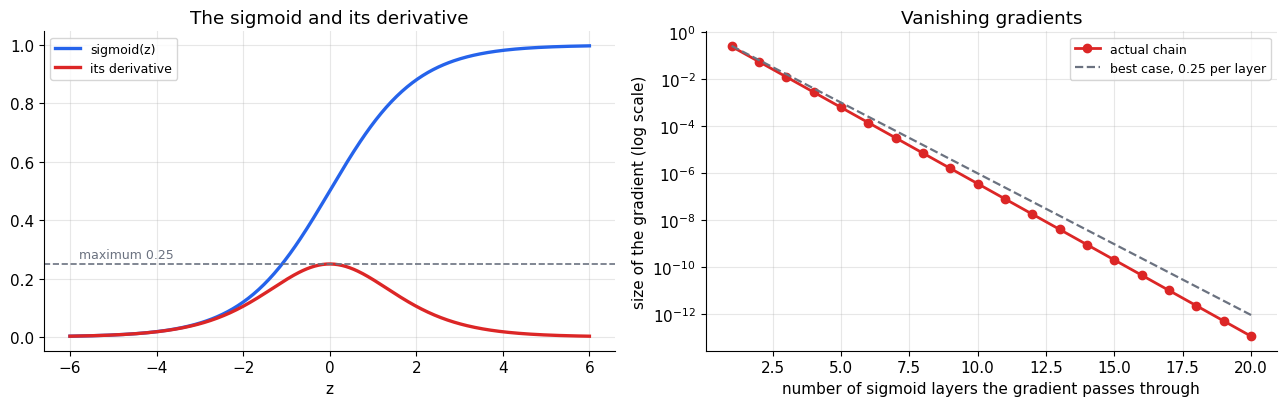

In [78]:
# ============================================================
#  Why deep sigmoid stacks stopped working, in one product.
# ============================================================
zs = np.linspace(-6, 6, 400)
print("sigma'(z) = sigma(z)*(1 - sigma(z)).  Its largest possible value:")
z_s2 = sp.symbols("z_s2", real=True)
sig2 = 1 / (1 + sp.exp(-z_s2))
crit = sp.solve(sp.diff(sig2 * (1 - sig2), z_s2), z_s2)
print(f"   d/dz of sigma' is zero at z = {crit}, where sigma' = "
      f"{float((sig2*(1-sig2)).subs(z_s2, crit[0])):.4f}")
print("   so EVERY factor the chain rule contributes through a sigmoid is at")
print("   most 0.25, and usually a good deal less.\n")

# A chain of L sigmoid layers, each with weight 1, input 0.5.
print("depth | product of sigma' along the chain | dLoss/d(first weight)")
print("------+-----------------------------------+----------------------")
val, product = 0.5, 1.0
for depth in range(1, 13):
    z = val                       # weight 1, no bias: z of this layer = previous a
    a = sigmoid(z)
    product *= a * (1 - a)
    val = a
    if depth in (1, 2, 3, 4, 6, 8, 10, 12):
        print(f"{depth:5d} | {product:33.3e} | {product * 0.5:20.3e}")
print(f"\nBest case, all factors at the maximum 0.25:  0.25^12 = {0.25**12:.3e}")

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.2))
axL.plot(zs, sigmoid(zs), color=C_F, lw=2.4, label="sigmoid(z)")
axL.plot(zs, sigmoid(zs) * (1 - sigmoid(zs)), color=C_SLOPE, lw=2.4,
         label="its derivative")
axL.axhline(0.25, color=C_GREY, ls="--", lw=1.2)
axL.text(-5.8, 0.27, "maximum 0.25", fontsize=9, color=C_GREY)
axL.set_xlabel("z"); axL.set_title("The sigmoid and its derivative")
axL.legend(fontsize=9)

depths = np.arange(1, 21)
prods, v, pr = [], 0.5, 1.0
for _ in depths:
    a = sigmoid(v); pr *= a * (1 - a); v = a; prods.append(pr)
axR.semilogy(depths, prods, "o-", color=C_SLOPE, lw=2.0, label="actual chain")
axR.semilogy(depths, 0.25 ** depths, "--", color=C_GREY, lw=1.6,
             label="best case, 0.25 per layer")
axR.set_xlabel("number of sigmoid layers the gradient passes through")
axR.set_ylabel("size of the gradient (log scale)")
axR.set_title("Vanishing gradients")
axR.legend(fontsize=9)
fig.tight_layout()
plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

**Left.** The sigmoid in blue, its derivative in red. The derivative is a hump that peaks at $z = 0$ — the cell finds that peak symbolically and prints its height, $0.25$ — and falls away to nothing in both directions. Wherever the sigmoid is doing its most characteristic work, saturating near $0$ or near $1$, its derivative is *almost exactly zero*.

**Right.** What that costs when gradients have to cross many such layers. The chain rule multiplies one such factor per layer, so the gradient reaching an early weight is a product of numbers all below $0.25$. On the logarithmic axis it is a straight line heading downward: the printed table shows the size at depth $12$, and the grey dashed line is the impossibly optimistic best case where every layer contributes the full $0.25$.

**The common misread:** blaming the depth. Depth is not the problem — modern networks are far deeper than this and train fine. The problem is **multiplying by something smaller than one, repeatedly**. Change the activation so its derivative is $1$ over half its range (ReLU), or add a path that skips layers so the chain has an uninterrupted route back (residual connections), and the same depth becomes trainable. Both fixes are direct responses to this one picture.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**Vanishing gradients: the network that trains, but only at one end.**

The failure is quiet and asymmetric. The last layer gets a healthy gradient and learns normally. The first layer gets that same gradient multiplied by a dozen numbers below $0.25$, so it receives something near the printed value at depth $12$, and effectively does not move. The loss goes down — the top of the network is learning — so nothing looks broken, but the early layers are still close to their random initial values and the features they extract are noise.

The symptom to watch for is the loss improving quickly and then plateauing well above where it should. The diagnostic is to print the size of the gradient layer by layer and see whether it shrinks by orders of magnitude as you walk backwards.

This is not a historical curiosity. It is why sigmoids were largely abandoned for hidden layers, why ReLU took over, and why residual connections were invented — the whole shape of modern architecture is partly an answer to a fact about $\sigma'$.

</div>

epoch |    mean squared loss
------+---------------------
    0 | 3.36718311
    1 | 1.11249528
   10 | 0.32580029
  100 | 0.20564502
  500 | 0.00000000
 2000 | 0.00000000
 5999 | 0.00000000

loss fell from 3.367183 to 1.701e-30  (a factor of 1.98e+30)

 x1  x2 | target | prediction
--------+--------+-----------
0   0  |  0     | +0.000000
0   1  |  1     | +1.000000
1   0  |  1     | +1.000000
1   1  |  0     | +0.000000


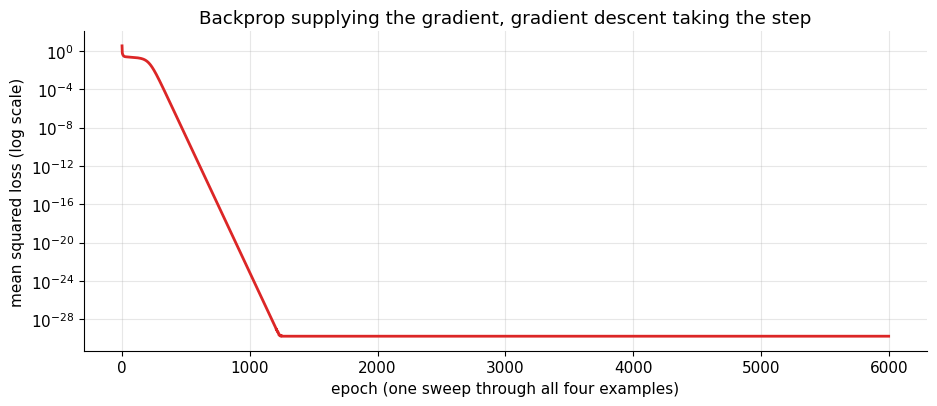

In [79]:
# ============================================================
#  Put it together: gradient descent driven by backprop.
#  Four training examples -- exclusive-or, the classic problem
#  a network without a hidden layer cannot solve at all.
# ============================================================
X_train = np.array([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])
y_train = np.array([0., 1., 1., 0.])          # XOR

rng2 = np.random.default_rng(3)
A1 = rng2.normal(0, 1.2, (2, 2)); B1 = rng2.normal(0, 1.2, 2)
A2 = rng2.normal(0, 1.2, 2);      B2 = 0.0

eta_net, n_epochs = 0.5, 6000
loss_curve = []
for epoch in range(n_epochs):
    gA1 = np.zeros((2, 2)); gB1 = np.zeros(2)
    gA2 = np.zeros(2);      gB2 = 0.0
    total = 0.0
    for xv, yv in zip(X_train, y_train):
        # --- forward (exactly the pass we drew above) ---
        a  = sigmoid(A1 @ xv + B1)
        oo = float(A2 @ a + B2)
        total += (oo - yv) ** 2
        # --- backward (exactly the five steps we derived) ---
        d2 = 2.0 * (oo - yv)
        gA2 += d2 * a
        gB2 += d2
        d1 = d2 * A2 * a * (1 - a)
        gA1 += np.outer(d1, xv)
        gB1 += d1
    n = len(X_train)
    A1 -= eta_net * gA1 / n                    # the update rule from 9.1
    B1 -= eta_net * gB1 / n
    A2 -= eta_net * gA2 / n
    B2 -= eta_net * gB2 / n
    loss_curve.append(total / n)

print("epoch |    mean squared loss")
print("------+---------------------")
for k in (0, 1, 10, 100, 500, 2000, n_epochs - 1):
    print(f"{k:5d} | {loss_curve[k]:.8f}")
print(f"\nloss fell from {loss_curve[0]:.6f} to {loss_curve[-1]:.3e}  "
      f"(a factor of {loss_curve[0] / loss_curve[-1]:.3g})")
print("\n x1  x2 | target | prediction")
print("--------+--------+-----------")
for xv, yv in zip(X_train, y_train):
    pred = float(A2 @ sigmoid(A1 @ xv + B1) + B2)
    print(f"{xv[0]:.0f}   {xv[1]:.0f}  |  {yv:.0f}     | {pred:+.6f}")

fig, ax = plt.subplots(figsize=(9.5, 4.2))
ax.semilogy(loss_curve, color=C_SLOPE, lw=2.0)
ax.set_xlabel("epoch (one sweep through all four examples)")
ax.set_ylabel("mean squared loss (log scale)")
ax.set_title("Backprop supplying the gradient, gradient descent taking the step")
fig.tight_layout()
plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The loss over 6000 sweeps, on a logarithmic vertical axis. It starts at the printed initial value, sits on a **plateau** for a while — the network has found the easy answer of predicting roughly the average and cannot yet see how to do better — then drops off a cliff and keeps falling, ending many orders of magnitude lower. The printed prediction table shows the four outputs sitting essentially on their targets.

Nothing in that loop is new. The forward pass is the one drawn on the diagram. The backward pass is the five steps derived above, verified nine times over against a numerical check. The update is $w \leftarrow w - \eta \nabla L$ from 9.1. That is a working neural network, and there is no calculus in it that this notebook has not derived.

**The common misread:** reading the flat plateau as "stuck" and killing the run. The gradient there is small but not zero, and it is still pointing somewhere useful; the network is slowly rotating its hidden units into a configuration from which progress becomes possible. Plateaus followed by sudden drops are completely ordinary in training curves. Patience is sometimes a hyperparameter.

</div>

---

## 9.4 Where every idea ended up

| Calculus idea | Built in | Where it shows up in machine learning |
|---|---|---|
| Limit | Part 2 | The definition of every derivative; the meaning of a learning rate going to zero; why the finite-difference check has a tolerance and not an equals sign |
| Derivative as a slope | Part 3 | The single number that tells a weight which way to move |
| Difference quotient with finite $h$ | Part 3 | `numerical_gradient` — the check that caught your backprop bug |
| Power rule | Part 4 | Differentiating the squared-error loss; every $L^2$ regulariser |
| Product rule | Part 4 | Gates in LSTMs, attention scores, anywhere two learned quantities multiply |
| **Chain rule** | Part 4 | **Backpropagation.** The whole of it. There is nothing else in there |
| Second derivative, curvature | Part 5 | Why $\eta < 2/f''$; Newton's method; why sharp minima generalise worse |
| $f'=0$ at a minimum | Part 5 | The closed-form least-squares fit; the definition of "converged"; the reason saddle points are a problem at all |
| Integral as accumulated area | Part 6 | Expected values; the area under an ROC curve; the normalising constant of any probability density |
| Fundamental Theorem | Part 7 | Continuous normalising flows; diffusion models integrating a learned velocity field back to an image |
| Partial derivative | Part 8 | One weight at a time, everything else held still — every entry of every gradient |
| Gradient $\nabla f$ | Part 8 | The direction the entire parameter vector moves each step |
| Multivariable chain rule | Part 8 | Summing contributions when one node feeds several others — the reason a `+=` appears in the backward pass |
| Gradient descent | Part 9 | Every training run there has ever been |

### The list from Part 0, ticked off

| | You said you would be able to | Delivered in |
|---|---|---|
| ✅ | Say what a limit is without epsilons | Part 2 |
| ✅ | Derive the derivative from the difference quotient, and compute one by hand | Part 3 |
| ✅ | Derive the power, product, quotient and chain rules, and know which applies when | Part 4 |
| ✅ | Read a function's shape from its derivatives | Part 5 |
| ✅ | Explain an integral as a sum of infinitely many thin slivers, and compute one | Part 6 |
| ✅ | State and use the Fundamental Theorem, and say why it is surprising | Part 7 |
| ✅ | Take partial derivatives and assemble a gradient | Part 8 |
| ✅ | Run gradient descent by hand, and follow backpropagation through a tiny network | Part 9 |

You have now differentiated a neural network by hand and had the answer
confirmed by an independent numerical measurement, nine times over. When
`loss.backward()` runs, you know precisely what it did: it walked the graph
backwards, wrote a $\delta$ on every node, and multiplied each one by whatever
came in along the wire.

It is no longer a black box. It is Part 4's chain rule with good bookkeeping.


---

## 🏋️ Exercises

No solutions. Every one is checkable against something already in this notebook.

**1 — Find the learning-rate cliff yourself.**
Take $f(w) = 3(w-2)^2$. Predict the threshold $\eta$ at which gradient descent
diverges, using $\eta < 2/f''$ and computing $f''$ with sympy. Then run descent
at $0.9\times$ and $1.1\times$ your threshold for 50 steps and print the final
$w$ in each case.
*Scaffolding:* copy the four-panel cell in 9.1 and change only `f_bowl`,
`fp_bowl` and the four learning rates.

**2 — Momentum, in three extra lines.**
Modify `gradient_descent_1d` so that instead of `w -= eta*fp(w)` it keeps a
running velocity: `v = beta*v - eta*fp(w)` then `w += v`, starting from
`v = 0.0`, with `beta = 0.9`. Run it on the stretched bowl of the 2-D cell and
plot the path beside the original. Does the zig-zag get better or worse?
*Scaffolding:* you will need one `v` per coordinate, so make it a numpy array
of the same shape as `p`.

**3 — Break the check on purpose.**
In the backward-pass cell, change `delta1 = dL_da1 * sig_prime` to
`delta1 = dL_da1` (a plausible slip: forgetting the sigmoid's derivative). Re-run
the verification table. Exactly which rows fail, and which still pass? Explain
why the failures are the ones they are.
*Scaffolding:* trace which of the nine gradients depend on `delta1` at all.

**4 — Add a third hidden unit.**
Change the hidden layer from two units to three. `W1` becomes $3\times 2$, `b1`
has three entries, `W2` has three. Every backward formula is unchanged — that is
the point. Re-run the numerical check and confirm all **eleven** gradients pass.
*Scaffolding:* if you wrote the forward pass with `@` and `np.outer`, nothing but
the array shapes needs to change.

**5 — Replace the sigmoid with ReLU and re-derive.**
$\text{ReLU}(z) = \max(0, z)$. Its derivative is $1$ for $z > 0$ and $0$ for
$z < 0$ (and undefined at exactly $0$ — say what you will do there and why it
does not matter in practice). Swap it into the tiny network, derive the new
$\delta^{(1)}_j$, and verify numerically. Then re-run the vanishing-gradient
chain with ReLU and describe how the picture changes.
*Scaffolding:* the only line of the backward pass that changes is the one
containing `a1 * (1 - a1)`.

**6 — Fit a quadratic instead of a line.**
Change the model to $\hat{y} = a x^2 + b x + c$ and redo **both** methods of
9.2: solve the three simultaneous equations $\partial L/\partial a =
\partial L/\partial b = \partial L/\partial c = 0$ with sympy, and run gradient
descent on the same loss. Print the two answers and their difference, as we did.
Warning: you will need a much smaller learning rate. Explain, using $\eta < 2/f''$,
why introducing an $x^2$ term forced that on you.
*Scaffolding:* build the sympy loss the same way, with three symbols instead of two.


---

## 📚 References

**On this part specifically**

- Rumelhart, Hinton & Williams (1986), *Learning representations by
  back-propagating errors*, **Nature** 323, 533–536. The paper that made
  backpropagation famous. It is four pages and you can now read all of it.
- Karpathy, *Yes you should understand backprop* (2016) — the argument for
  doing by hand exactly what 9.3 did.
- Karpathy, **micrograd** — backpropagation in about 100 lines of Python, and
  the natural next thing to read after this notebook.
- Goodfellow, Bengio & Courville, *Deep Learning*, chapters 4 (numerical
  computation), 6.5 (back-propagation) and 8 (optimisation). Free online.
- Nielsen, *Neural Networks and Deep Learning*, chapter 2 — the same derivation
  as 9.3, in matrix form, with more examples.
- Dauphin et al. (2014), *Identifying and attacking the saddle point problem in
  high-dimensional non-convex optimization* — the source of the claim in 9.1
  about saddles outnumbering local minima.

**On the calculus underneath**

- Spivak, *Calculus* — if you want the real thing, with proofs, after this.
- Strang, *Calculus* (MIT OpenCourseWare, free) — friendlier, and full of
  applications.
- 3Blue1Brown, *Essence of Calculus* — the visual companion to Parts 1–8.

**Where to go next**

Linear algebra, then probability. The gradient you assembled in Part 8 is a
vector; the second derivatives of a multivariable function form a matrix (the
Hessian); a layer of a network is a matrix product. Everything you have just
learned gets shorter and clearer once those are in place.

---
## 🗺️ The Ten Parts

This is a **refresher that assumes you have forgotten everything**. Part 1 starts at what a function is. Nothing later depends on anything we did not build earlier, and every rule is derived before it is used.

| Part | What it covers | |
|---|---|---|
| **0** | Why calculus, and the one question behind all of it |
| **1** | Functions, graphs, and average rate of change |
| **2** | Limits, without the epsilons |
| **3** | The derivative, built from scratch |
| **4** | The rules, each one derived and checked |
| **5** | What a derivative tells you: shape, peaks, and optimisation |
| **6** | Integrals: adding up infinitely many slivers |
| **7** | The Fundamental Theorem: why the two halves are one subject |
| **8** | Many variables: partial derivatives and the gradient |
| **9** | Calculus doing ML: gradient descent and backprop by hand |  &larr; **you are here**

Parts 1-3 are the ideas. Parts 4-5 make derivatives usable. Parts 6-7 do the same for integrals and then show the two are one idea. Parts 8-9 are where it becomes machine learning.


<div style="background: linear-gradient(135deg, #0F2027 0%, #2C5364 100%); padding: 28px; border-radius: 18px; color: white; margin: 12px 0;">


### 🎓 That is the whole subject.

Ten parts ago the problem was that speed at an instant means dividing zero by
zero. The fix was to shrink an interval and watch where the answer went — a
**limit**. Everything since has been consequences of that one move.

You derived the rules rather than memorising them. You checked every derivation
with numbers rather than trusting the algebra. You found the area under a curve
by adding up slivers, and then discovered it was the same question as the slope,
running backwards. You differentiated with respect to one variable at a time and
stacked the answers into a gradient. And then you walked downhill on a real loss,
differentiated a neural network by hand, and watched nine hand-derived gradients
agree with nine independent numerical measurements.

`loss.backward()` is the chain rule. `optimizer.step()` is
$w \leftarrow w - \eta \nabla L$. You have written both.

**Go and train something.**


</div>